
# 🎯 Goal: Building an Early Warning System


---

## Introduction: an Early Warning System based on Anomaly Detection

Financial assets, in the medium to long term, tend to generate **positive risk premia and positive real returns** — see for example [UBS Global Investment Returns Yearbook 2025](https://www.ubs.com/global/en/investment-bank/insights-and-data/articles/global-investment-returns-yearbook-2026.html) and [UBS Global Investment Returns Yearbook 2025](https://www.ubs.com/global/en/investment-bank/insights-and-data/2025/global-investment-returns-yearbook-2025.html), supported by basic economic principles:

- For **equities**, the return on capital invested in business activities.
- For **bonds**, the remuneration for:
  - the temporary deprivation of money (and consumption).
  - and the compensation for default risk.

However, financial markets periodically experience **crises** in which asset returns deviate from these principles for periods that may be short... or not.

Investor **risk appetite** fluctuates over time—rising in optimistic phases and falling during times of uncertainty. As a result, asset prices move accordingly.

In market jargon, we refer to:

- **Risk-on** situations:  
  >Investors are willing to take risks and bid up the prices of risky assets (equities, corporate bonds, riskier sovereign bonds, most commodities, etc.).

- **Risk-off** situations:  
  >Investors become more risk-averse, sell risky assets (driving prices down), and shift to safer investments (cash, short-term bonds of safe-haven countries, sometimes gold, etc.).  
  These periods are typically associated with **high systemic risk**.

Financial institutions would like to detect risk-on vs. risk-off regimes **as early as possible**: identifying these situations early – it's more *nowcasting* than *forecasting* – as it is often enough to significantly outperform the market and increase your reputation as an asset manager.

So, this is our motivation.

---

<br>

## 🧠 What are we trying to do?

We try to algorithmically detect risk-on vs. risk-off regimes using Data Science, a relatively new approach.

To formalize this:

- **Risk-on** periods ⟶ _Normal_
- **Risk-off** periods ⟶ _Abnormal_

We can use Machine Learning to create a model that identifies **financial anomalies** in real time: this would be an example of an **Early Warning System** built using **Anomaly Detection** techniques.

> More precisely, we are dealing with what is typically known as **Novelty Detection**, as opposed to **Outlier Detection**, both subfields of Anomaly Detection. Here the taxonomy and nomenclature are not univocal (generally: Novelty = supervised or semi-supervised, and Outlier = unsupervised), and to tell the truth not even very interesting: the important thing is to solve a problem...

This is just **one possible approach** to building such a an Early Warning System.  We focus on it because it's based on a widely used class of ML models and allows us to explore important ideas in unsupervised and supervised learning, useful for many other purposes in the Fintech field.


📖 **Further reading:**
- [A Survey of Systemic Risk Analytics – OFR Working Paper 0001](https://dx.doi.org/10.2139/ssrn.1983602)
- [A Systematic Review of Early Warning Systems in Finance](https://arxiv.org/pdf/2310.00490)
- [Systemic Risk Measures: Taking Stock from 1927 to 2023](https://www.nber.org/system/files/working_papers/w33211/w33211.pdf)


<br>


---


<br>

After a quick **warm-up using artificial data** to introduce some key concepts, we'll apply these concepts to a real-world dataset (from Bloomberg). The dataset is anonymous, mostly clean, but **not** transformed, normalized, or scaled.

The dataset is called `Dataset4_EWS.xlsx`.

<br>

In [1]:
# Import necessary libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visualization settings
sns.set_theme(style="whitegrid")
sns.set_context("notebook", font_scale=1.5)

# Mount Google Drive to access files
# Skip remounting if already mounted
try:
    from google.colab import drive
    drive.mount('/content/drive')
except:
    print("Drive already mounted or not in Colab environment.")


Drive already mounted or not in Colab environment.


### **Introduction to Anomaly Detection - using artificial data**

We start with a simple but effective method for anomaly detection. We will uses synthetic data to better understand some key points.

#### 👁️‍🗨️ **God Mode = ON: we simulate the world**

We create a **synthetic universe of investment returns** where:

- **Normal data** comes from a 2D Gaussian with moderate variance and centered around $(1,1)$.
- **Abormal data = anomalies** drawn from a different Gaussian  
  with larger variance and centered far away at $(-5, -6)$ (of course, you can/should change the parameters of the Data Generation Process).


We generate:
- 10,000 normal points.
- 40 anomalies.

These are then combined into a single dataset for our Anomaly Detection experiment. So the overall density function is a **Gaussian Mixture** (btw: a fairly realistic distribution for market data).

But we know the full truth, or *ground truth* — because WE designed the system. So we can judge the model, any model on this dataset.


<br>

### **Data Visualization**

We plot the data in two ways:

- **Unlabeled scatter plot**: to visualize the full dataset as it would appear in a real setting.
- **Labeled scatter plot**: with anomalies highlighted, for inspection and model evaluation.

<br>


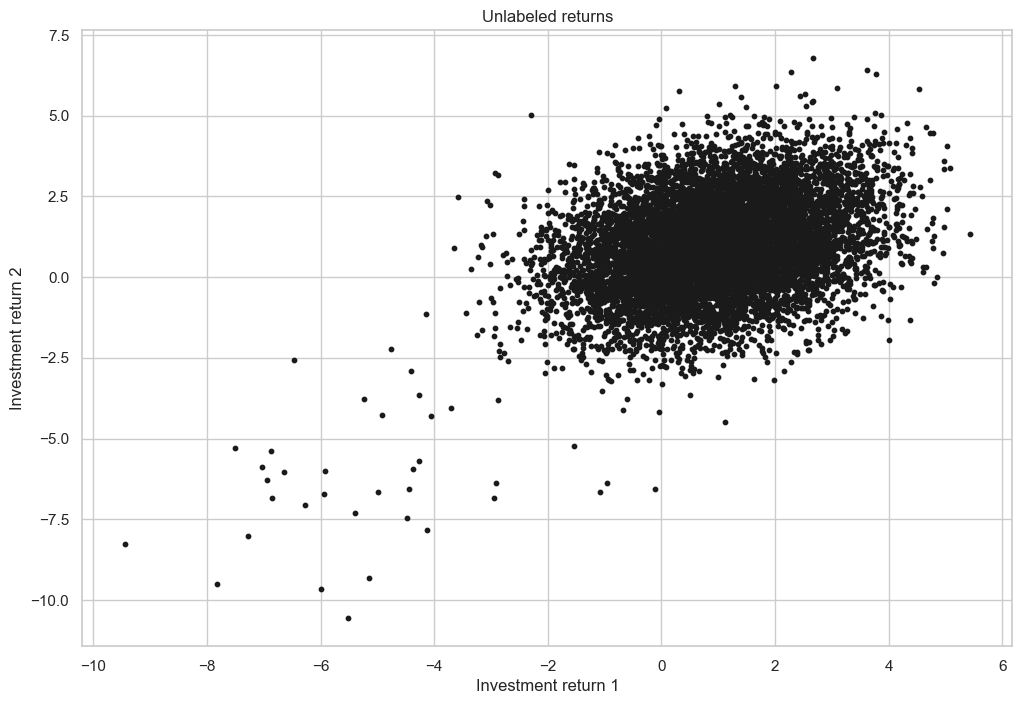

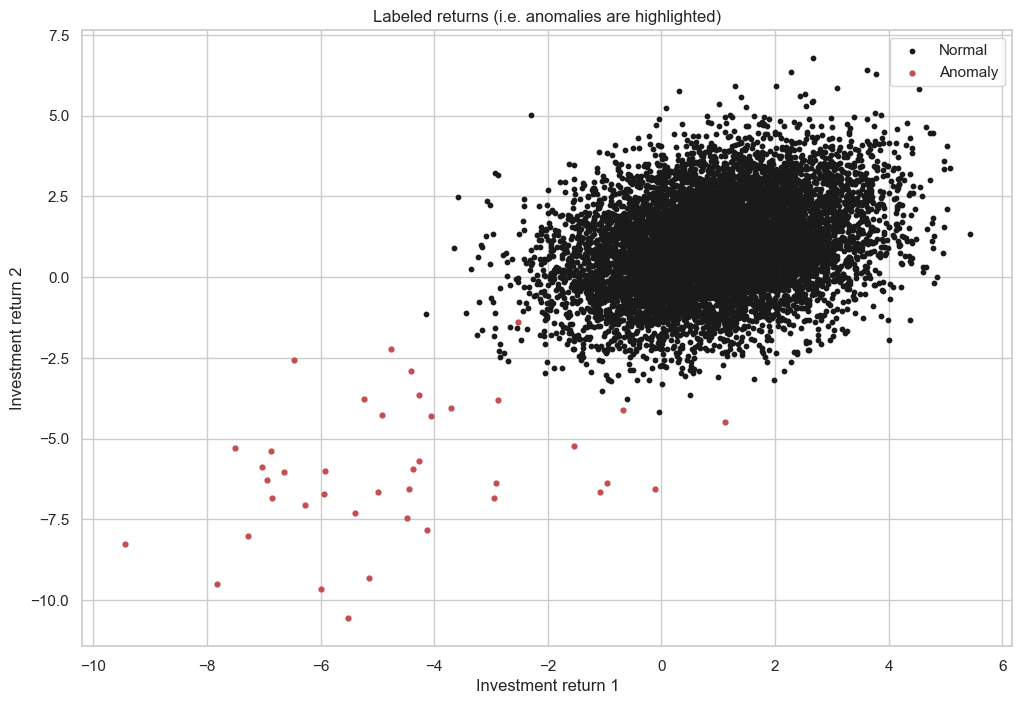

In [2]:
from scipy.stats import multivariate_normal
from sklearn.metrics import precision_score, recall_score, f1_score

# Set the style for our plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]


# Set random seed for reproducibility
np.random.seed(42)

# First variable: "ordinary returns = non-anomalous data"
mu1 = np.array([1, 1])  # Mean of the 1st component
sigma1 = np.array([[1.7, 0.5], [0.5, 1.9]])  # Covariance of the 1st component
nobs1 = 10000

# Second variable: "unusual returns = anomalies"
mu2 = np.array([-5, -6])  # Mean of the 2nd component
sigma2 = np.array([[4.5, 0.95], [0.95, 3.5]])  # Covariance of the 2nd component
nobs2 = 40

# Generate random samples from multivariate normal distributions
r1 = np.random.multivariate_normal(mu1, sigma1, nobs1)
r2 = np.random.multivariate_normal(mu2, sigma2, nobs2)

# Combine the two sets into one dataset
X = np.vstack((r1, r2))
y = np.hstack((np.zeros(nobs1), np.ones(nobs2)))

# Plot the data without labels
plt.figure(figsize=(12, 8))
plt.scatter(X[:, 0], X[:, 1], c='k', s=10)
plt.xlabel('Investment return 1')
plt.ylabel('Investment return 2')
plt.title('Unlabeled returns')
plt.show()

# Plot the data with labels (anomalies in red)
plt.figure(figsize=(12, 8))
plt.scatter(X[y==0, 0], X[y==0, 1], c='k', s=10, label='Normal')
plt.scatter(X[y==1, 0], X[y==1, 1], c='r', s=12, label='Anomaly')
plt.xlabel('Investment return 1')
plt.ylabel('Investment return 2')
plt.title('Labeled returns (i.e. anomalies are highlighted)')
plt.legend()
plt.show()



### **Modeling Strategy – God Mode = OFF**

So far, in "God Mode ON", we’ve created the world. Now we pretend we didn’t.

We step into the shoes of someone who:

- Observes a dataset coming from an unknown Data Generation Process (DGP).
- Knows which points are abnormal (at least a decent subset), for example because they have been labelled by an expert.
- Wants to detect which points are **abnormal**, i.e., **anomalies**.

A fairly typical situation.


Our strategy:

1. **Model the normal** – Fit a multivariate Gaussian (MVG) density only on the normal observations.
2. **Score everything** – Use the MVG to assign a likelihood score $p(x)$ to each new observation.
3. **Flag anomalies** – If $p(x)$ is lower than some threshold $\varepsilon$, we flag it as an anomaly.

This leads to a simple decision rule:

$$
\text{Anomaly} \quad \Longleftrightarrow \quad p(x) < \varepsilon
$$

This approach is probabilistic, quite interpretable, and (despite its simplicity) surprisingly effective when anomalies are rare and normality is structured.

---

#### 🧠 What are we really doing?

- We do **not** assume the entire dataset is Gaussian.  
  (In fact, we know it's a Gaussian mixture — but we ignore that on purpose.)

- We only assume that the **normal part** of the data can be well approximated by a multivariate Gaussian.

- We use the fitted MVG as a proxy for **how normality looks**, and measure how much new observations deviate from it.

> 💡 We’re not learning what anomalies *are*.  
> We’re learning what *normal* is — and flagging anything that looks very different.


---

#### Formal Summary

We fit:

- $\mu = \text{mean of normal data}$
- $\Sigma = \text{covariance of normal data}$

Then for any observation $x$:

$$
p(x) = \frac{1}{(2\pi)^{k/2} |\Sigma|^{1/2}} \exp\left(-\frac{1}{2}(x - \mu)^T \Sigma^{-1} (x - \mu)\right)
$$

We classify $x$ as **anomaly** if:

$$
p(x) < \varepsilon
$$

We choose our **hyperparamer** $\varepsilon$ by maximizing the **F1 score** on the validation set (which includes anomalies). Anyway, you can decide to maximize any metric you think is good as Optimization metric (F1 is just a reasonable and comfy choice).

---
<br>

 🧠 **Short Machine Learning epistemology note**

While the core method (fitting a multivariate Gaussian density) is unsupervised (because density estimation is an unsupervised metod), we apply it in a **supervised framework**:
- We use **labeled data** (anomalies) during cross-validation to choose the threshold $\varepsilon$. This means: supervised.
- We evaluate the model using **supervised metrics** like precision, recall, and F1 score.

So overall, this should be considered a **supervised model**. Or, **semi-supervised**. Again, it's just terminology.

📌 **Lesson**: the nature of a model depends not just on how it’s built,  but on how it’s **used** (also, think about Logistic Regression, a regression model typically used as a classifier).

<br>

### **Splitting data: Train / Cross-Validation / Test Set Construction**

We adopt the **fairly classic train/cv/test partition**. But there are some peculiarities though: in anomaly detection, **data is typically split in a way that emphasizes the modeling of normal behavior**.

<br>

#### **Training Set (`X_train`)**

- Contains only **normal data** (i.e., no anomalies).
- Extracted as the first 6,000 observations from the normal sample: `r1[:6000]`.
- Used to estimate the MVG distribution of "normal" behavior.

This is intentional:  
we want the model to learn the statistical structure of normal data **without contamination** from anomalies.

<br>

#### **Cross-Validation Set (`X_cross_val`)**

- Contains a **mixture** of:
  - 2,000 **normal** points: `r1[6000:8000]`.
  - 20 **anomalies** (50% of total anomalies): `r2[:20]`.
- Used to **tune the hyperparameter, the threshold** $\varepsilon$, which controls the anomaly detection cutoff.

<br>

#### **Test Set (`X_test`)**

- Also a **mixture** of:
  - 2,000 **normal** points: `r1[8000:]`.
  - 20 **anomalies** (remaining 50%): `r2[20:]`.
- Used to evaluate the **final performance** of the trained model on **unseen data** (i.e., out-of-sample, or using the hold-out set).

<br>

---

This data split structure is common in Anomaly Detection when:

- Anomalies are **rare** (which is often the case, btw, otherwise they are not considered anomalies...).
- The goal is to carefully model "normal" data.
- There are **not enough anomalies** to learn their distribution directly

Note that this setup differs from standard supervised learning, where all classes are typically distributed proportionally across training, validation, and test sets.

<br>

<br>

---

Note: we don't reshuffle here in this first exercise only because it's an artifical sample of i.i.d. observations, with a known structure.  Otherwise: **reshuffle, always**.

<br>

In [3]:
# Note (yes, again: I want to stress the idea): we don't reshuffle here,
# only because this is an artificial sample of i.i.d. observations
# In real applications, you should ALWAYS RESHUFFLE your data

# Split the normal data (60/20/20 a common choice, with this dataset size)
X_train = r1[:6000]  # 60% of X|y=0
X_cross_val = np.vstack((r1[6000:8000], r2[:20]))  # 20% of X|y=0 and 50% of X|y=1
X_test = np.vstack((r1[8000:], r2[20:]))  # 20% of X|y=0 and 50% of X|y=1

# Create corresponding labels
y_cross_val = np.zeros(len(X_cross_val))
y_cross_val[-20:] = 1
y_test = np.zeros(len(X_test))
y_test[-20:] = 1


Let's visualize what data we have in our train/cv(test) partition.

In [4]:
split_summary = pd.DataFrame({
    'Set': ['Train', 'Cross-Validation', 'Test (Hold-Out)'],
    'Normal points': [len(X_train), 2000, 2000],
    'Anomalies': [0, 20, 20],
    'Total': [len(X_train), len(X_cross_val), len(X_test)]
})

display(split_summary)


,Set,Normal points,Anomalies,Total
0,Train,6000,0,6000
1,Cross-Validation,2000,20,2020
2,Test (Hold-Out),2000,20,2020


### **Model fit: estimate MVG parameters**

We estimate the mean vector $\mu$ and covariance matrix $\Sigma$ of the multivariate normal distribution, using only the training set (i.e., normal data).

Standard Maximum Likelihood estimators:

- $\mu = \text{mean}(X_{\text{train}})$  
- $\Sigma = \text{cov}(X_{\text{train}})$

<br>


In [5]:
# Estimate the parameters of the multivariate Gaussian
mu = np.mean(X_train, axis=0)
sigma = np.cov(X_train, rowvar=False)


### **Threshold Selection via Cross-Validation**

We compute the probability density $p(x)$ for each point in the cross-validation set.  
Then we search for the threshold $\varepsilon$ that maximizes the F1 score.

For each candidate $\varepsilon$:
- Points with $p(x) < \varepsilon$ are classified as anomalies
- We compare predictions to ground truth labels
- We compute precision, recall, and F1 score.

We retain the $\varepsilon$ that yields the best F1.

📌 **Why F1?**

You already know the story... The **choice of evaluation metric depends on the application**, on the business case. In short:
- If false negatives are critical, **recall** might be prioritized
- If false positives are costly, **precision** could be preferred
- F1 is a **balanced compromise**: the harmonic mean of precision and recall

In this example, we use F1 because we aim for a good trade-off without favoring one type of error, and also abecause it's just an example - you instead think carefully about which metric to use and why...

<br>


In [6]:
# Compute the probability density function for the cross-validation set
mv_normal = multivariate_normal(mean=mu, cov=sigma)
p = mv_normal.pdf(X_cross_val)

# Find the range of epsilon values to search
min_epsilon = np.min(p)
max_epsilon = np.max(p)
step_size = (max_epsilon - min_epsilon) / 1000

# Find the best epsilon using F1 score
best_epsilon = 0
best_f1 = 0

epsilon_values = np.arange(min_epsilon, max_epsilon, step_size)
for epsilon in epsilon_values:
    predictions = (p < epsilon).astype(int)

    # Calculate precision and recall
    tp = np.sum((predictions == 1) & (y_cross_val == 1))
    fp = np.sum((predictions == 1) & (y_cross_val == 0))
    fn = np.sum((predictions == 0) & (y_cross_val == 1))

    # Avoid division by zero
    if tp + fp == 0 or tp + fn == 0:
        continue

    precision = tp / (tp + fp)
    recall = tp / (tp + fn)

    # Calculate F1 score
    if precision + recall > 0:  # Avoid division by zero
        f1 = 2 * precision * recall / (precision + recall)

        if f1 > best_f1:
            best_f1 = f1
            best_epsilon = epsilon

print(f"Best F1 Score: {best_f1:.4f}")
print(f"Best Epsilon: {best_epsilon:.8f}")



Best F1 Score: 0.9048
Best Epsilon: 0.00009187


### **Final evaluation on test set**

We apply the best threshold $\varepsilon$ to the test set (out-of-sample approach), which contains both normal points and previously unseen anomalies.

We compute some usual metrics of the model’s performance:
- **Precision**.
- **Recall**.
- **F1 Score**.

<br>

---

### Visual Inspection

The scatter plot highlights:

- **Normal points** in black.
- **True anomalies** in red.
- **False positives** (normal misclassified as anomaly) in yellow.
- **False negatives** (anomalies missed by the model) in magenta.

This helps understand both the **quantitative** and **qualitative** behavior of the model.


Test Precision: 0.8636
Test Recall: 0.9500
Test F1 Score: 0.9048


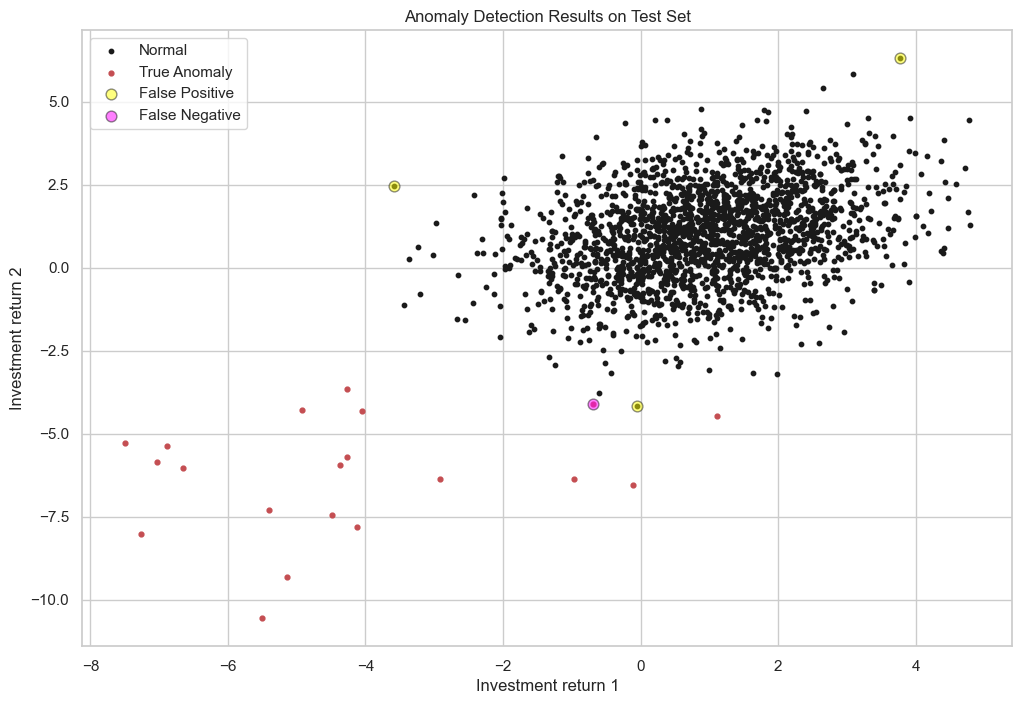

In [7]:
# Compute the probability density function for the test set
p_test = mv_normal.pdf(X_test)

# Make predictions using the best epsilon
predictions = (p_test < best_epsilon).astype(int)

# Calculate metrics
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)

print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")

# Visualize the results
plt.figure(figsize=(12, 8))
plt.scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], c='k', s=10, label='Normal')
plt.scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], c='r', s=12, label='True Anomaly')
plt.scatter(X_test[(predictions==1) & (y_test==0), 0],
            X_test[(predictions==1) & (y_test==0), 1],
            c='yellow', s=60, alpha=0.5, marker='o', edgecolors='k', label='False Positive')
plt.scatter(X_test[(predictions==0) & (y_test==1), 0],
            X_test[(predictions==0) & (y_test==1), 1],
            c='magenta', s=60, alpha=0.5, marker='o', edgecolors='k', label='False Negative')
plt.xlabel('Investment return 1')
plt.ylabel('Investment return 2')
plt.title('Anomaly Detection Results on Test Set')
plt.legend()
plt.show()


## Real-World dataset

We now switch to a **real-world dataset** from Bloomberg, consisting of weekly observations of:

- Market and macroeconomic indicators (e.g., indices, rates).
- A response variable `Y` indicating **anomalous periods** (e.g., market stress events).


---

### Visual Preview: MSCI USA and Anomaly Periods

We inspect our features and plot a key equity index, the MSCI USA index (`MXUS`), over time, highlighting the periods where `Y = 1` as **risk-on/risk-off windows**.

This allows a quick visual check of:

- The distribution of anomalous events in time.
- Their potential correspondence with market drops or volatility clusters.

<br>


In [8]:
# Define the path to the dataset (local file on this PC)
# The .xlsx lives in the FINTECH/assignment_4 folder.
# If you run Jupyter from that folder, the relative path is enough;
# otherwise the absolute path is used as fallback.
import os

local_relative = 'Dataset4_EWS.xlsx'
local_absolute = r'C:\Users\ricca\OneDrive\Desktop\FINTECH\FINTECH\assignment_4\Dataset4_EWS.xlsx'

if os.path.exists(local_relative):
    file_path = local_relative
else:
    file_path = local_absolute

print(f"Loading dataset from: {file_path}")


Loading dataset from: Dataset4_EWS.xlsx


Data columns: ['Data', 'BDIY', 'CRY', 'Cl1', 'DXY', 'ECSURPUS', 'EMUSTRUU', 'EONIA', 'GBP', 'GT10', 'GTDEM10Y', 'GTDEM2Y', 'GTDEM30Y', 'GTGBP20Y', 'GTGBP2Y', 'GTGBP30Y', 'GTITL10YR', 'GTITL2YR', 'GTITL30YR', 'GTJPY10YR', 'GTJPY2YR', 'GTJPY30YR', 'JPY', 'LF94TRUU', 'LF98TRUU', 'LG30TRUU', 'LMBITR', 'LP01TREU', 'LUACTRUU', 'LUMSTRUU', 'MXBR', 'MXCN', 'MXEU', 'MXIN', 'MXJP', 'MXRU', 'MXUS', 'US0001M', 'USGG2YR', 'USGG30YR', 'USGG3M', 'VIX', 'XAUBGNL', 'Y']
Data shape: (1111, 42)
Total number of records: 1111
Time period: from 01/11/2000 to 04/20/2021
Frequency: W-TUE
Number of variables: 42
Number of anomalies: 237 (21.33%)

Metadata and statistics:


,Ticker,Description,Mean,Std.Dev,Min,Max,Missing values,Missing (%)
0,BDIY,Baltic Dry Index,2259.860486,2017.811888,291.00000,11793.00000,0,0.00%
1,CRY,TR/CC CRB ER Index,245.247649,68.278081,106.29290,467.57000,0,0.00%
2,Cl1,Generic 1st 'CL' Future,60.708101,25.900813,10.01000,140.97000,0,0.00%
3,DXY,DOLLAR INDEX SPOT,90.934982,11.379095,71.32900,119.82000,0,0.00%
4,ECSURPUS,Bloomberg ECO US Surprise Inde,0.036153,0.349453,-0.97400,0.99100,0,0.00%
5,EMUSTRUU,EM USD Aggregate,704.379495,309.951768,230.52670,1286.35300,0,0.00%
6,EONIA,EMMI EURO OverNight Index Aver,1.363676,1.721894,-0.49800,5.73000,0,0.00%
7,GBP,British Pound Spot,1.569618,0.212340,1.17230,2.08520,0,0.00%
8,GT10,US TREASURY N/B,3.266748,1.332464,0.50800,6.74800,0,0.00%
9,GTDEM10Y,BUNDESREPUB. DEUTSCHLAND,2.448365,1.851558,-0.79400,5.64400,0,0.00%


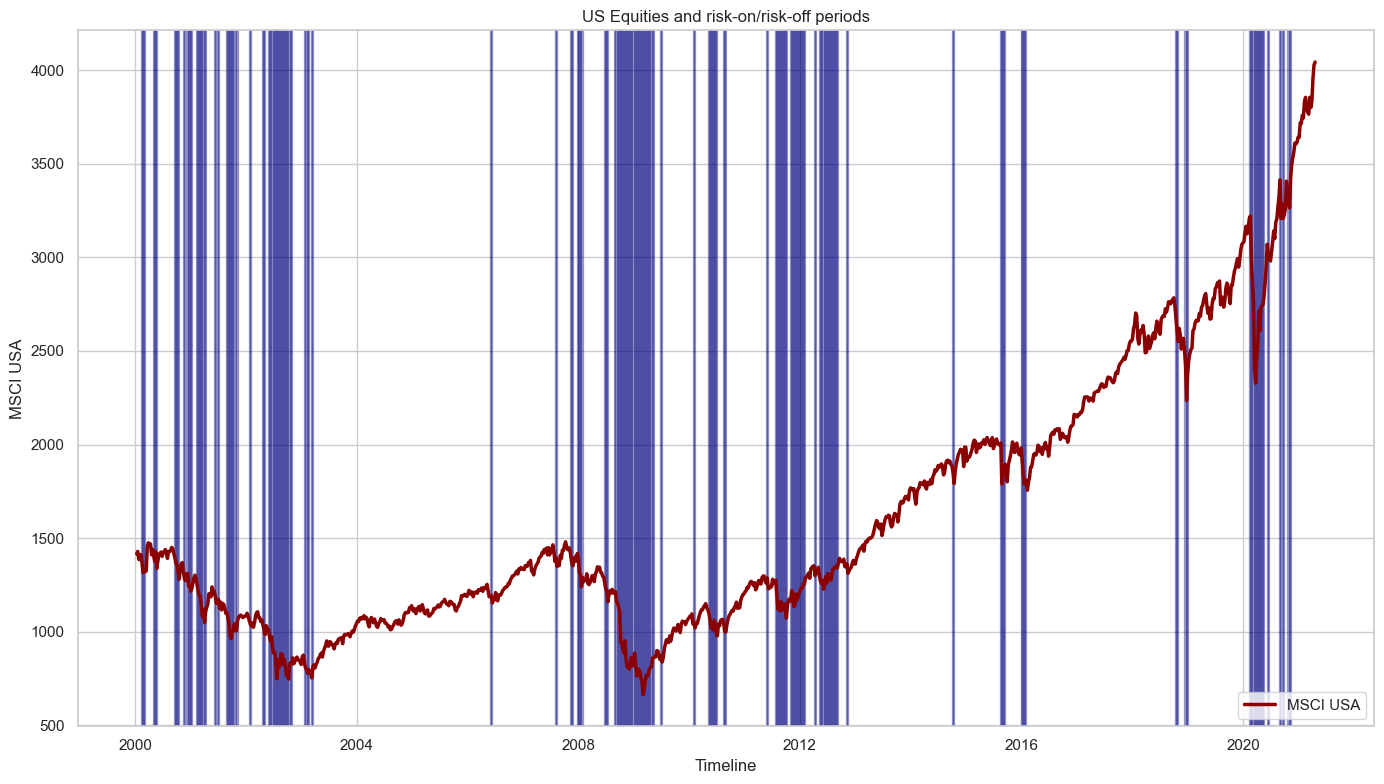

In [9]:
# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# Load the data from the Excel file
# First sheet contains market data with dates and anomaly labels, second sheet contains metadata
data_df = pd.read_excel(file_path, sheet_name='Markets')
metadata_df = pd.read_excel(file_path, sheet_name='Metadata')

# Check the structure of the loaded data
print("Data columns:", data_df.columns.tolist())

# Extract date and anomaly label columns
date_col = 'Date' if 'Date' in data_df.columns else data_df.columns[0]
y_col = 'Y' if 'Y' in data_df.columns else None

# Convert dates to datetime format
data_df[date_col] = pd.to_datetime(data_df[date_col], dayfirst=True)  # Date format is dd/mm/yy

# Set date as index
data_df = data_df.set_index(date_col)

# Extract features (all columns except Y if it exists)
if y_col:
    X_df = data_df.drop(y_col, axis=1)
    y = data_df[y_col].values
else:
    X_df = data_df
    y = None

# Display basic information about the dataset
print(f"Data shape: {X_df.shape}")
print(f"Total number of records: {len(X_df)}")
print(f"Time period: from {X_df.index.min().strftime('%m/%d/%Y')} to {X_df.index.max().strftime('%m/%d/%Y')}")
print(f"Frequency: {pd.infer_freq(X_df.index) or 'Weekly'}")
print(f"Number of variables: {X_df.shape[1]}")
if y_col:
    print(f"Number of anomalies: {np.sum(y == 1)} ({np.mean(y == 1)*100:.2f}%)")

# Create a more comprehensive metadata table with additional statistics
enhanced_metadata = []

# Determine the correct column names for ticker and description
ticker_col = 'ticker' if 'ticker' in metadata_df.columns else metadata_df.columns[0]
desc_col = 'description' if 'description' in metadata_df.columns else metadata_df.columns[1] if len(metadata_df.columns) > 1 else ticker_col

for ticker in X_df.columns:
    # Get metadata for this ticker if available
    meta_row = metadata_df[metadata_df[ticker_col] == ticker] if ticker in metadata_df[ticker_col].values else pd.DataFrame()

    # Get description or use ticker if not found
    description = meta_row[desc_col].values[0] if not meta_row.empty and desc_col in meta_row.columns else ticker

    # Calculate statistics for this series
    series = X_df[ticker]

    enhanced_metadata.append({
        'Ticker': ticker,
        'Description': description,
        'Mean': series.mean(),
        'Std.Dev': series.std(),
        'Min': series.min(),
        'Max': series.max(),
        'Missing values': series.isna().sum(),
        'Missing (%)': f"{series.isna().mean()*100:.2f}%"
    })

# Create enhanced metadata dataframe
enhanced_meta_df = pd.DataFrame(enhanced_metadata)

# Display the enhanced metadata
print("\nMetadata and statistics:")
display(enhanced_meta_df)

# Create a plot with anomalies as vertical bars and MXUS as a line
if y_col and 'MXUS' in X_df.columns:
    fig, ax = plt.subplots(figsize=(14, 8))

    # Plot MXUS line
    ax.plot(X_df.index, X_df['MXUS'], color='darkred', linewidth=2.5, label='MSCI USA')

    # Get the y-axis limits after plotting MXUS
    y_min, y_max = ax.get_ylim()

    # For each anomaly point (Y=1), create a vertical span across the entire plot
    for i, (date, is_anomaly) in enumerate(zip(X_df.index, y)):
        if is_anomaly == 1:
            ax.axvspan(date, date + pd.Timedelta(days=7), alpha=0.3, color='navy', label='Risk-on/Risk-off' if i == 0 else "")

    # Set labels and title
    ax.set_xlabel('Timeline')
    ax.set_ylabel('MSCI USA')
    ax.set_title('US Equities and risk-on/risk-off periods')

    # Add legend
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='best')

    plt.tight_layout()
    plt.show()
else:
    print("Either 'Y' column or 'MXUS' column is missing in the dataset.")


# EDA: Stationarity analysis and feature preparation

### Stationarity matters

Many/most models — especially those based on statistical distributions — assume that the data is **stationary**, i.e., its statistical properties (mean, variance) do not change over time.

This is particularly important for Anomaly Detection models like the one we use, which rely on estimating a **stable distribution**.

---

#### Why is stationarity important?

- Without stationarity, **mean and variance shift** over time.
- This makes density estimates unreliable.
- What looks like an anomaly could simply be a change in regime or trend.

> 📌 A stable model requires stable inputs.

<br>

---

### How do we check for stationarity?

We explore:

- Visual inspection of the series.
- Basic transformations (e.g., log-returns).
- You can perform formal statistical tests, e.g., [Augmented Dickey-Fuller](https://www.statsmodels.org/dev/generated/statsmodels.tsa.stattools.adfuller.html).

The goal is to identify variables that exhibit **mean-reverting behavior** or that can be transformed into stationary form.

<br>

Let's start analyzing a bond yield (for example, 10-year Italian BTP) to understand:
* stationarity through time graphs of levels and first differences.
* shape of the distribution with histograms and QQ-plot.

<br>

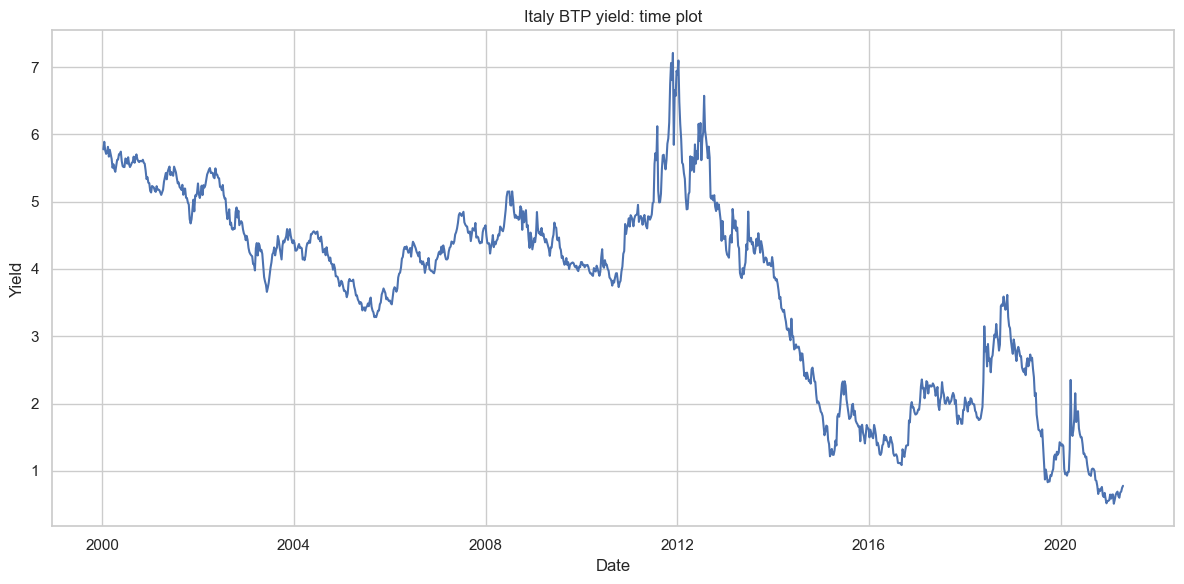

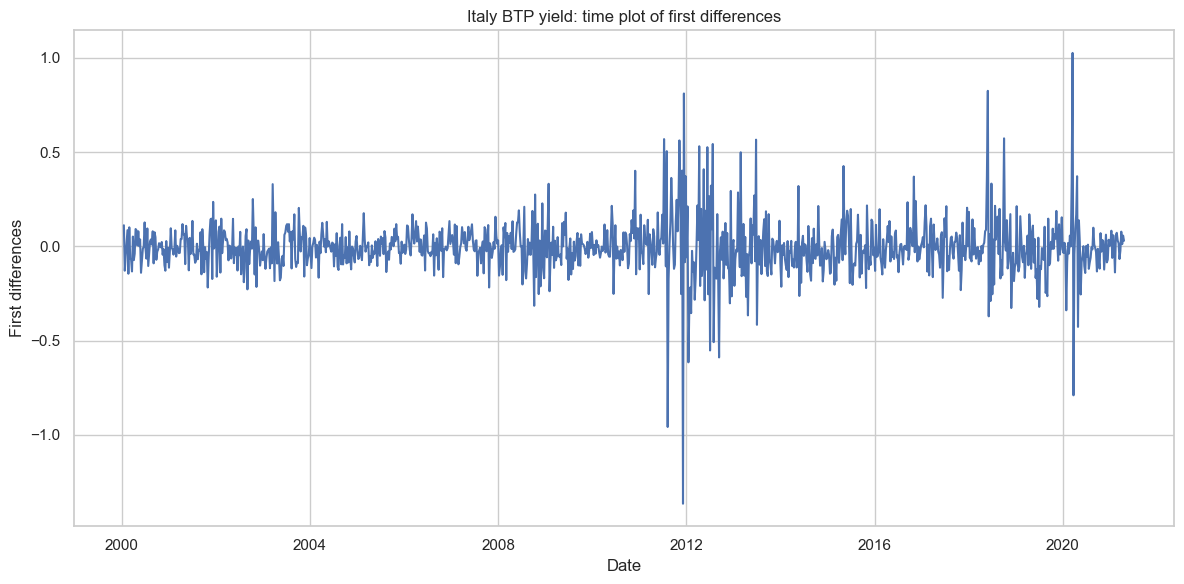

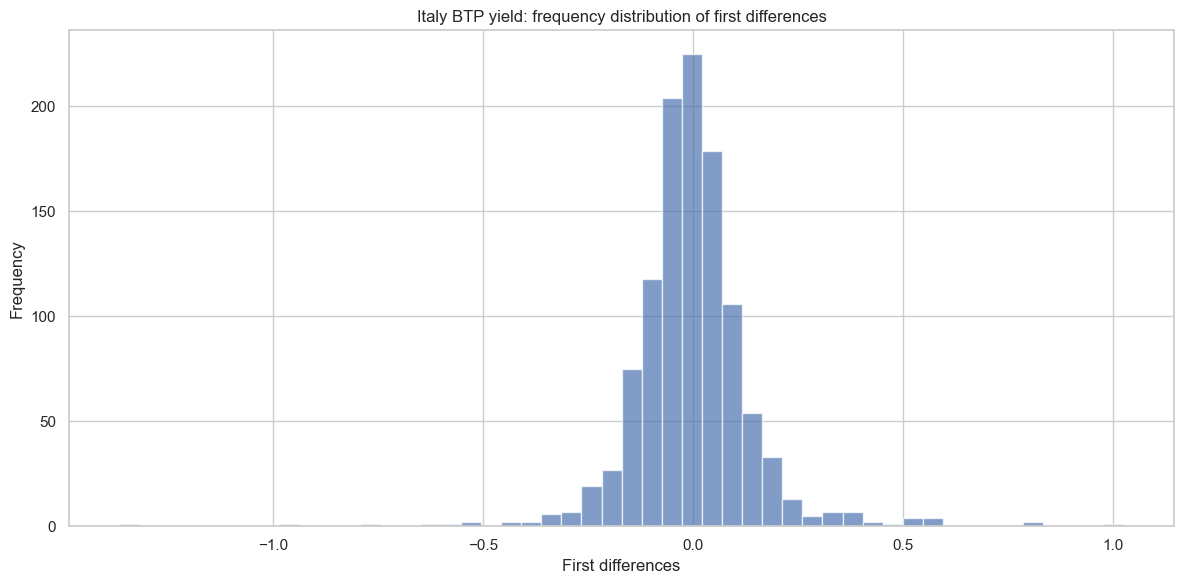

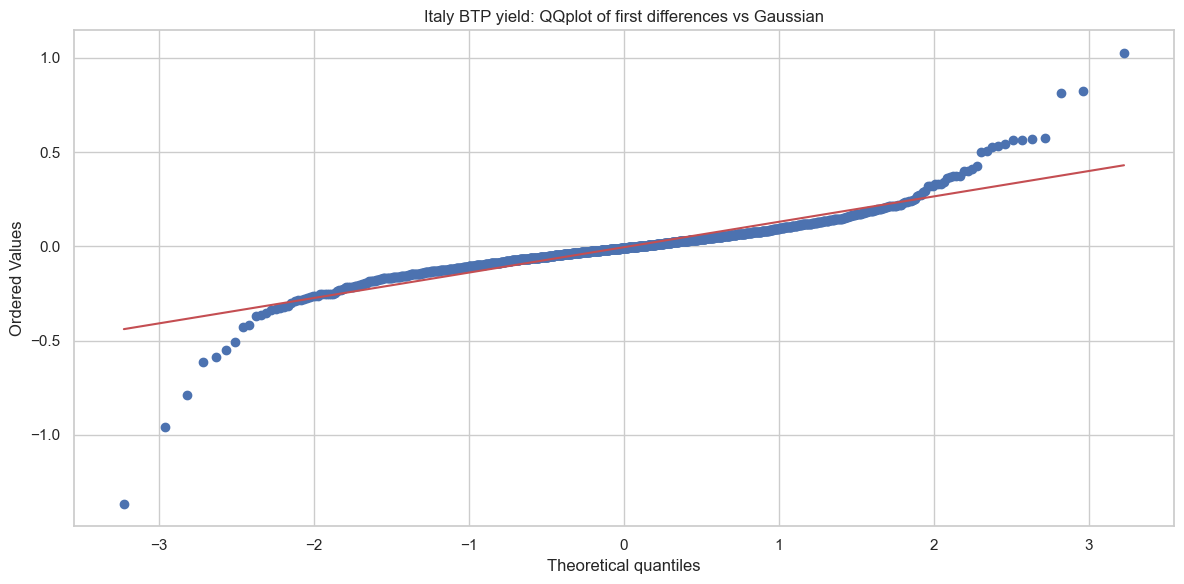

In [10]:
from scipy import stats
import statsmodels.api as sm

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 8]

# Analyze a bond yield (interest rate) - Italian BTP 10Yrs
if 'GTITL10YR' in X_df.columns:
    # Time plot of levels
    plt.figure(figsize=(12, 6))
    plt.plot(X_df.index, X_df['GTITL10YR'])
    plt.title('Italy BTP yield: time plot')
    plt.xlabel('Date')
    plt.ylabel('Yield')
    plt.tight_layout()
    plt.show()

    # Time plot of first differences
    plt.figure(figsize=(12, 6))
    plt.plot(X_df.index[1:], np.diff(X_df['GTITL10YR']))
    plt.title('Italy BTP yield: time plot of first differences')
    plt.xlabel('Date')
    plt.ylabel('First differences')
    plt.tight_layout()
    plt.show()

    # Histogram of first differences
    plt.figure(figsize=(12, 6))
    plt.hist(np.diff(X_df['GTITL10YR']), bins=50, alpha=0.7)
    plt.title('Italy BTP yield: frequency distribution of first differences')
    plt.xlabel('First differences')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

    # QQ plot of first differences vs Gaussian
    plt.figure(figsize=(12, 6))
    stats.probplot(np.diff(X_df['GTITL10YR']), dist="norm", plot=plt)
    plt.title('Italy BTP yield: QQplot of first differences vs Gaussian')
    plt.tight_layout()
    plt.show()


<br>

Now let's do the same with a (relevant) equity index.

<br>

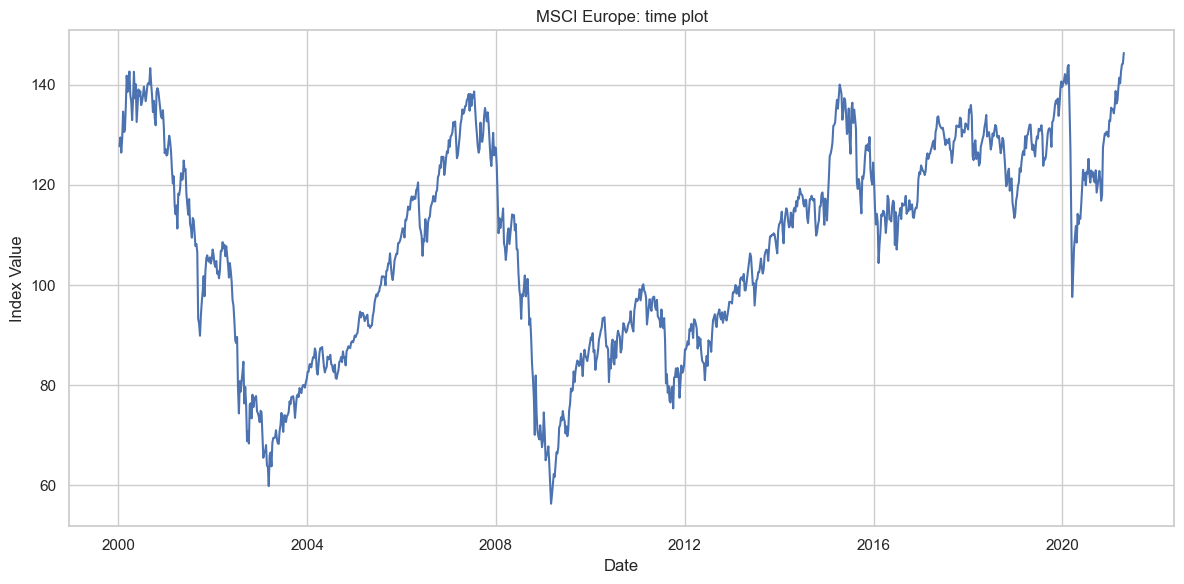

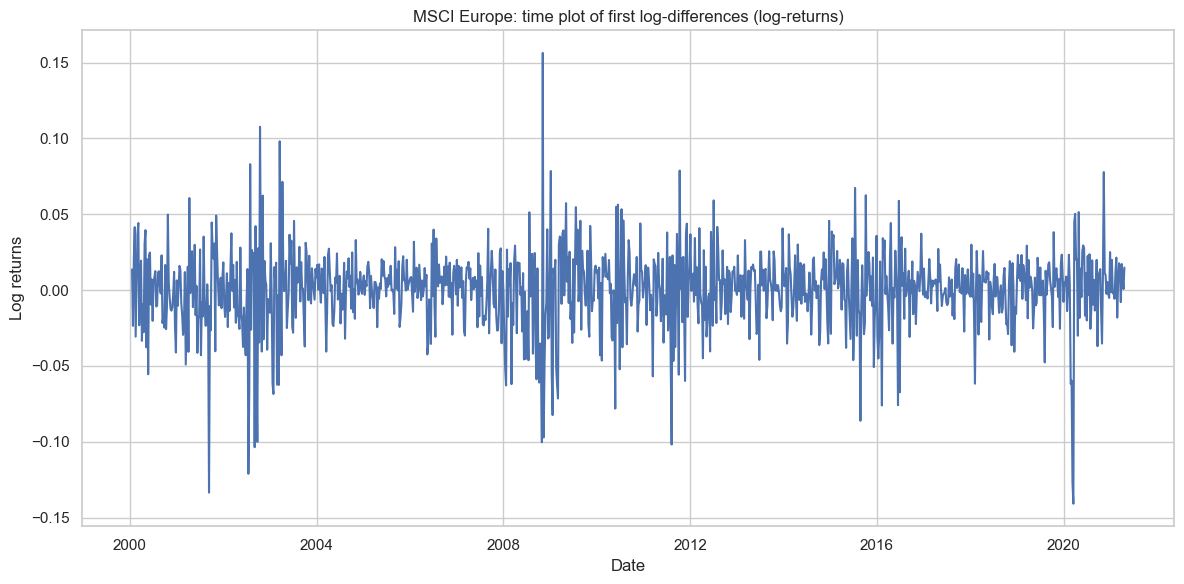

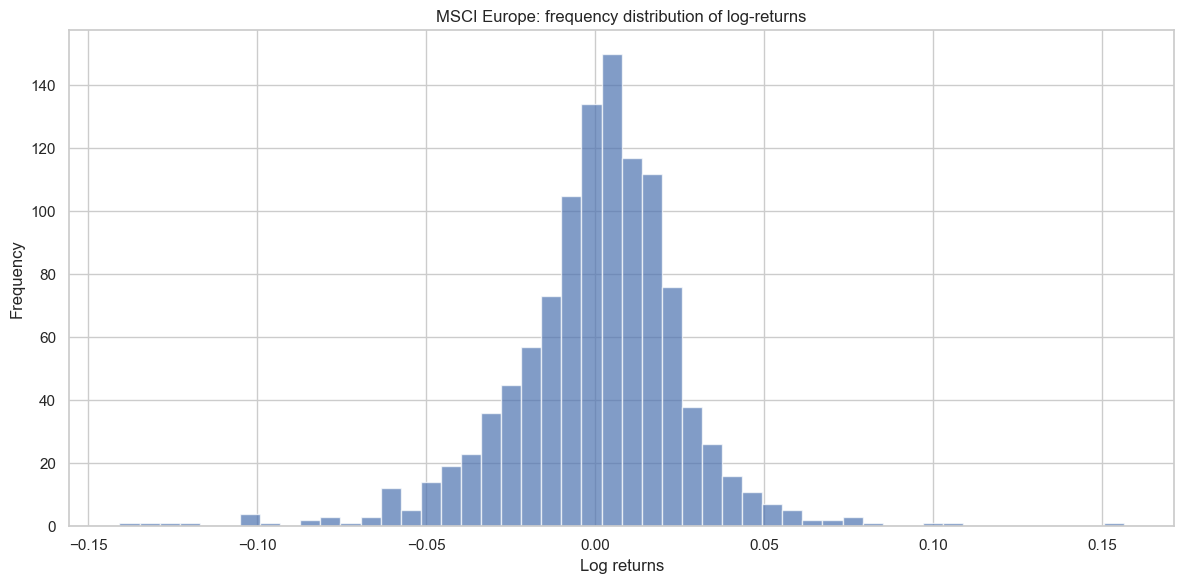

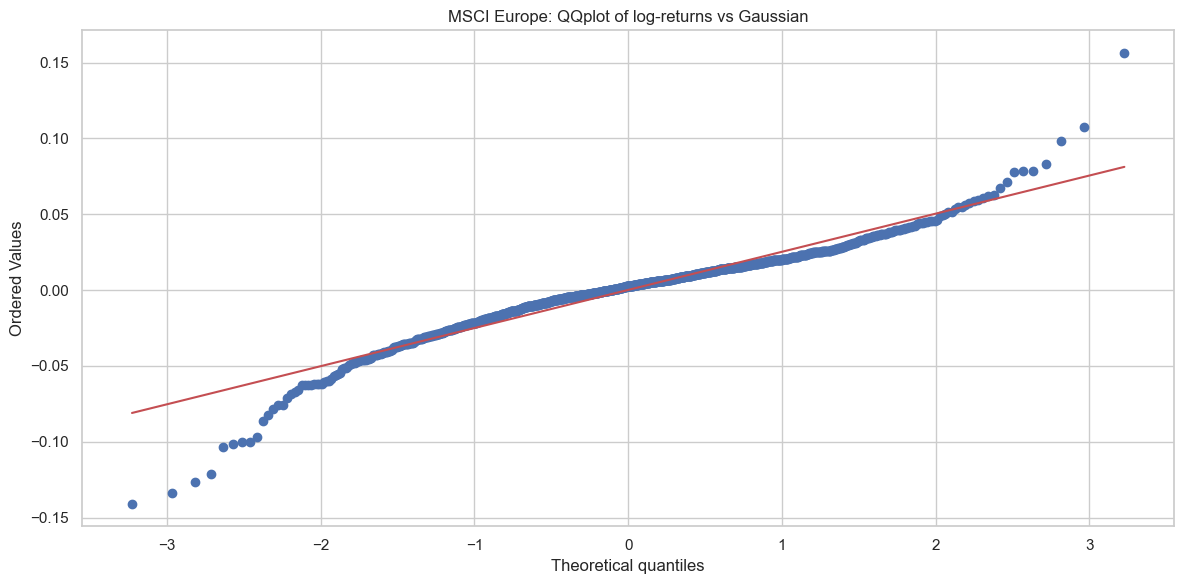

In [11]:
# Analyze an equity asset - MSCI Europe
if 'MXEU' in X_df.columns:
    # Time plot of levels
    plt.figure(figsize=(12, 6))
    plt.plot(X_df.index, X_df['MXEU'])
    plt.title('MSCI Europe: time plot')
    plt.xlabel('Date')
    plt.ylabel('Index Value')
    plt.tight_layout()
    plt.show()

    # Time plot of log returns
    plt.figure(figsize=(12, 6))
    log_returns = np.diff(np.log(X_df['MXEU']))
    plt.plot(X_df.index[1:], log_returns)
    plt.title('MSCI Europe: time plot of first log-differences (log-returns)')
    plt.xlabel('Date')
    plt.ylabel('Log returns')
    plt.tight_layout()
    plt.show()

    # Histogram of log returns
    plt.figure(figsize=(12, 6))
    plt.hist(log_returns, bins=50, alpha=0.7)
    plt.title('MSCI Europe: frequency distribution of log-returns')
    plt.xlabel('Log returns')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

    # QQ plot of log returns vs Gaussian
    plt.figure(figsize=(12, 6))
    stats.probplot(log_returns, dist="norm", plot=plt)
    plt.title('MSCI Europe: QQplot of log-returns vs Gaussian')
    plt.tight_layout()
    plt.show()


<br>

Now an economic surprise index: [the Bloomberg Economic US Surprise Index](https://www.babypips.com/forexpedia/bloomberg-us-economic-surprise-index#:~:text=The%20Bloomberg%20U.S.%20Economic%20Surprise,downside%20relative%20to%20market%20expectations).

<br>

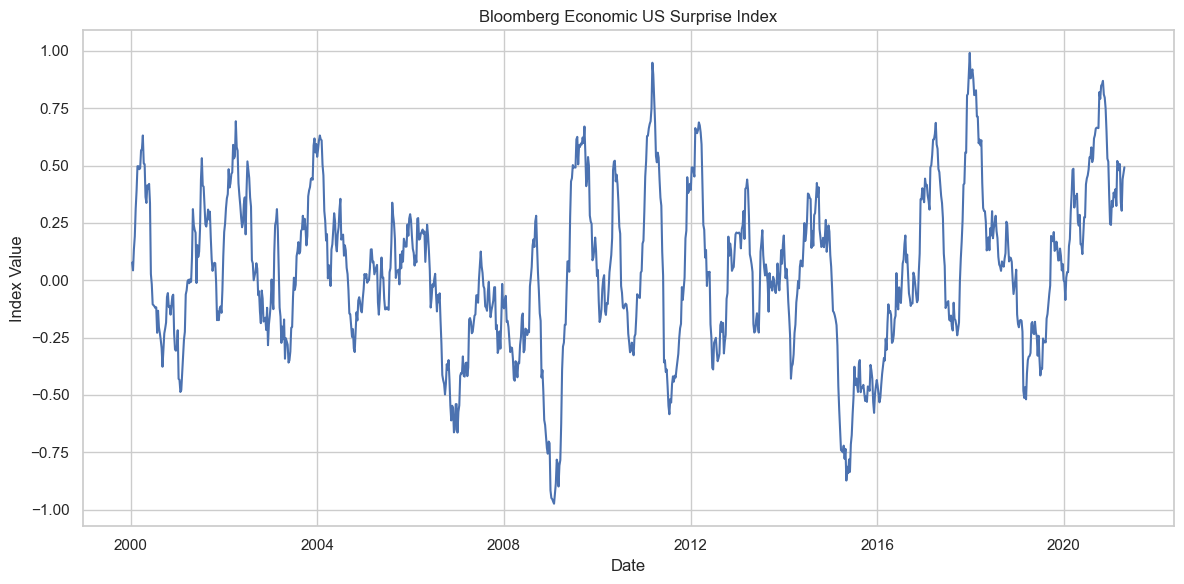

In [12]:
# Analyze the Bloomberg Economic US Surprise Index
if 'ECSURPUS' in X_df.columns:
    plt.figure(figsize=(12, 6))
    plt.plot(X_df.index, X_df['ECSURPUS'])
    plt.title('Bloomberg Economic US Surprise Index')
    plt.xlabel('Date')
    plt.ylabel('Index Value')
    plt.tight_layout()
    plt.show()


<br>

Let's check if we have negative interest rates. If a variable can take negative values, you cannot use log-differences, only first-differences - I recommend that you always use first differences, for interest rates and bond yields (not for bond indices).

<br>

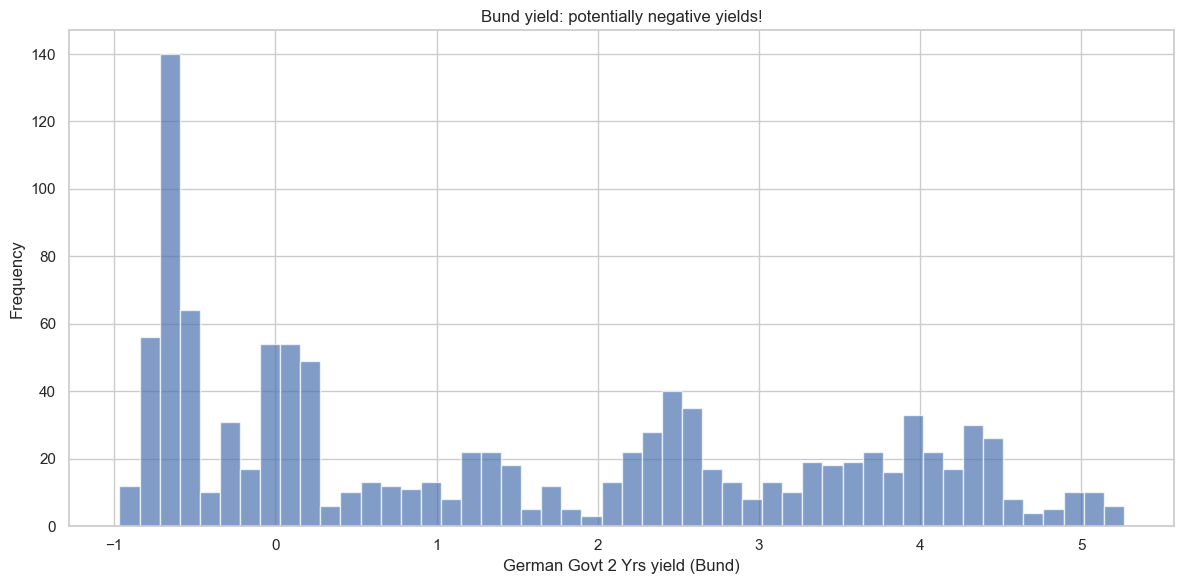

In [13]:
# Check for negative values in interest rates
if 'GTDEM2Y' in X_df.columns:
    plt.figure(figsize=(12, 6))
    plt.hist(X_df['GTDEM2Y'], bins=50, alpha=0.7)
    plt.title('Bund yield: potentially negative yields!')
    plt.xlabel('German Govt 2 Yrs yield (Bund)')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()


## Coping with stationarity

### Stationarity Transformation

Unless we are using **cointegration** techniques, we need the data to be **stationary**. For an introduction to the idea of cointegration see  [Cointegration](https://en.wikipedia.org/wiki/Cointegration).

This means that the **joint distribution** of the features must be stable over time.

The rationale is intuitive:

- We want to use historical data to infer patterns related to systemic risk.
- If the underlying structure shifts over time, any model based on past behavior becomes unreliable.

> A non-stationary model is not just inaccurate — it’s structurally **wrong**.

---

#### How we transform the data

- **Indices and currencies**: log-differenced (they are strictly positive).
- **Interest rates and yields**: first differences (they can be negative or close to zero).
- **Economic surprise index**: left as is (already roughly stationary). Note: Do not take this as a rule for macroeconomic variables; many are non-stationary, sometimes they need to be differentiated TWICE (sic).


Only the **features** are transformed — not the labels, i.e., our vector Y.

> For **more background** (that many ML tutorials skip entirely):  
> - [Forecasting: Principles and Practice – Stationarity](https://otexts.com/fpp3/stationarity.html)  
> - [Cointegration and ECMs – Sørensen](https://www.uh.edu/~bsorense/coint.pdf)

<br>

In [14]:
# Make data stationary based on variable type
# So w define lists of variables by type
indices_currencies = [col for col in X_df.columns if col in [
    'XAUBGNL', 'BDIY', 'CRY', 'Cl1', 'DXY', 'EMUSTRUU', 'GBP', 'JPY', 'LF94TRUU',
    'LF98TRUU', 'LG30TRUU', 'LMBITR', 'LP01TREU', 'LUACTRUU', 'LUMSTRUU',
    'MXBR', 'MXCN', 'MXEU', 'MXIN', 'MXJP', 'MXRU', 'MXUS', 'VIX'
]]

interest_rates = [col for col in X_df.columns if col in [
    'EONIA', 'GTDEM10Y', 'GTDEM2Y', 'GTDEM30Y', 'GTGBP20Y', 'GTGBP2Y', 'GTGBP30Y',
    'GTITL10YR', 'GTITL2YR', 'GTITL30YR', 'GTJPY10YR', 'GTJPY2YR', 'GTJPY30YR',
    'US0001M', 'USGG3M', 'USGG2YR', 'GT10', 'USGG30YR'
]]

# Create a new dataframe for stationary data
stationary_df = pd.DataFrame(index=X_df.index[1:])

# Apply log-differences to indices and currencies (always positive)
for col in indices_currencies:
    if col in X_df.columns:
        stationary_df[col] = np.diff(np.log(X_df[col]))

# Apply first differences to interest rates (can be negative or very close to 0)
for col in interest_rates:
    if col in X_df.columns:
        stationary_df[col] = np.diff(X_df[col])

# Keep Bloomberg Economic US Surprise Index as is (already stationary)
if 'ECSURPUS' in X_df.columns:
    stationary_df['ECSURPUS'] = X_df['ECSURPUS'].values[1:]

# Adjust the response variable to match the new data length
if y is not None:
    y_stationary = y[1:]
else:
    y_stationary = None


## Multivariate perspective

Matrix of scatter plots comparing our Xs by using the our Y as grouping variable (I plot just a selection of features, and they are already too many).

I guess you can spot visual differences in the behavior of variables during normal and abnormal periods.

<br>

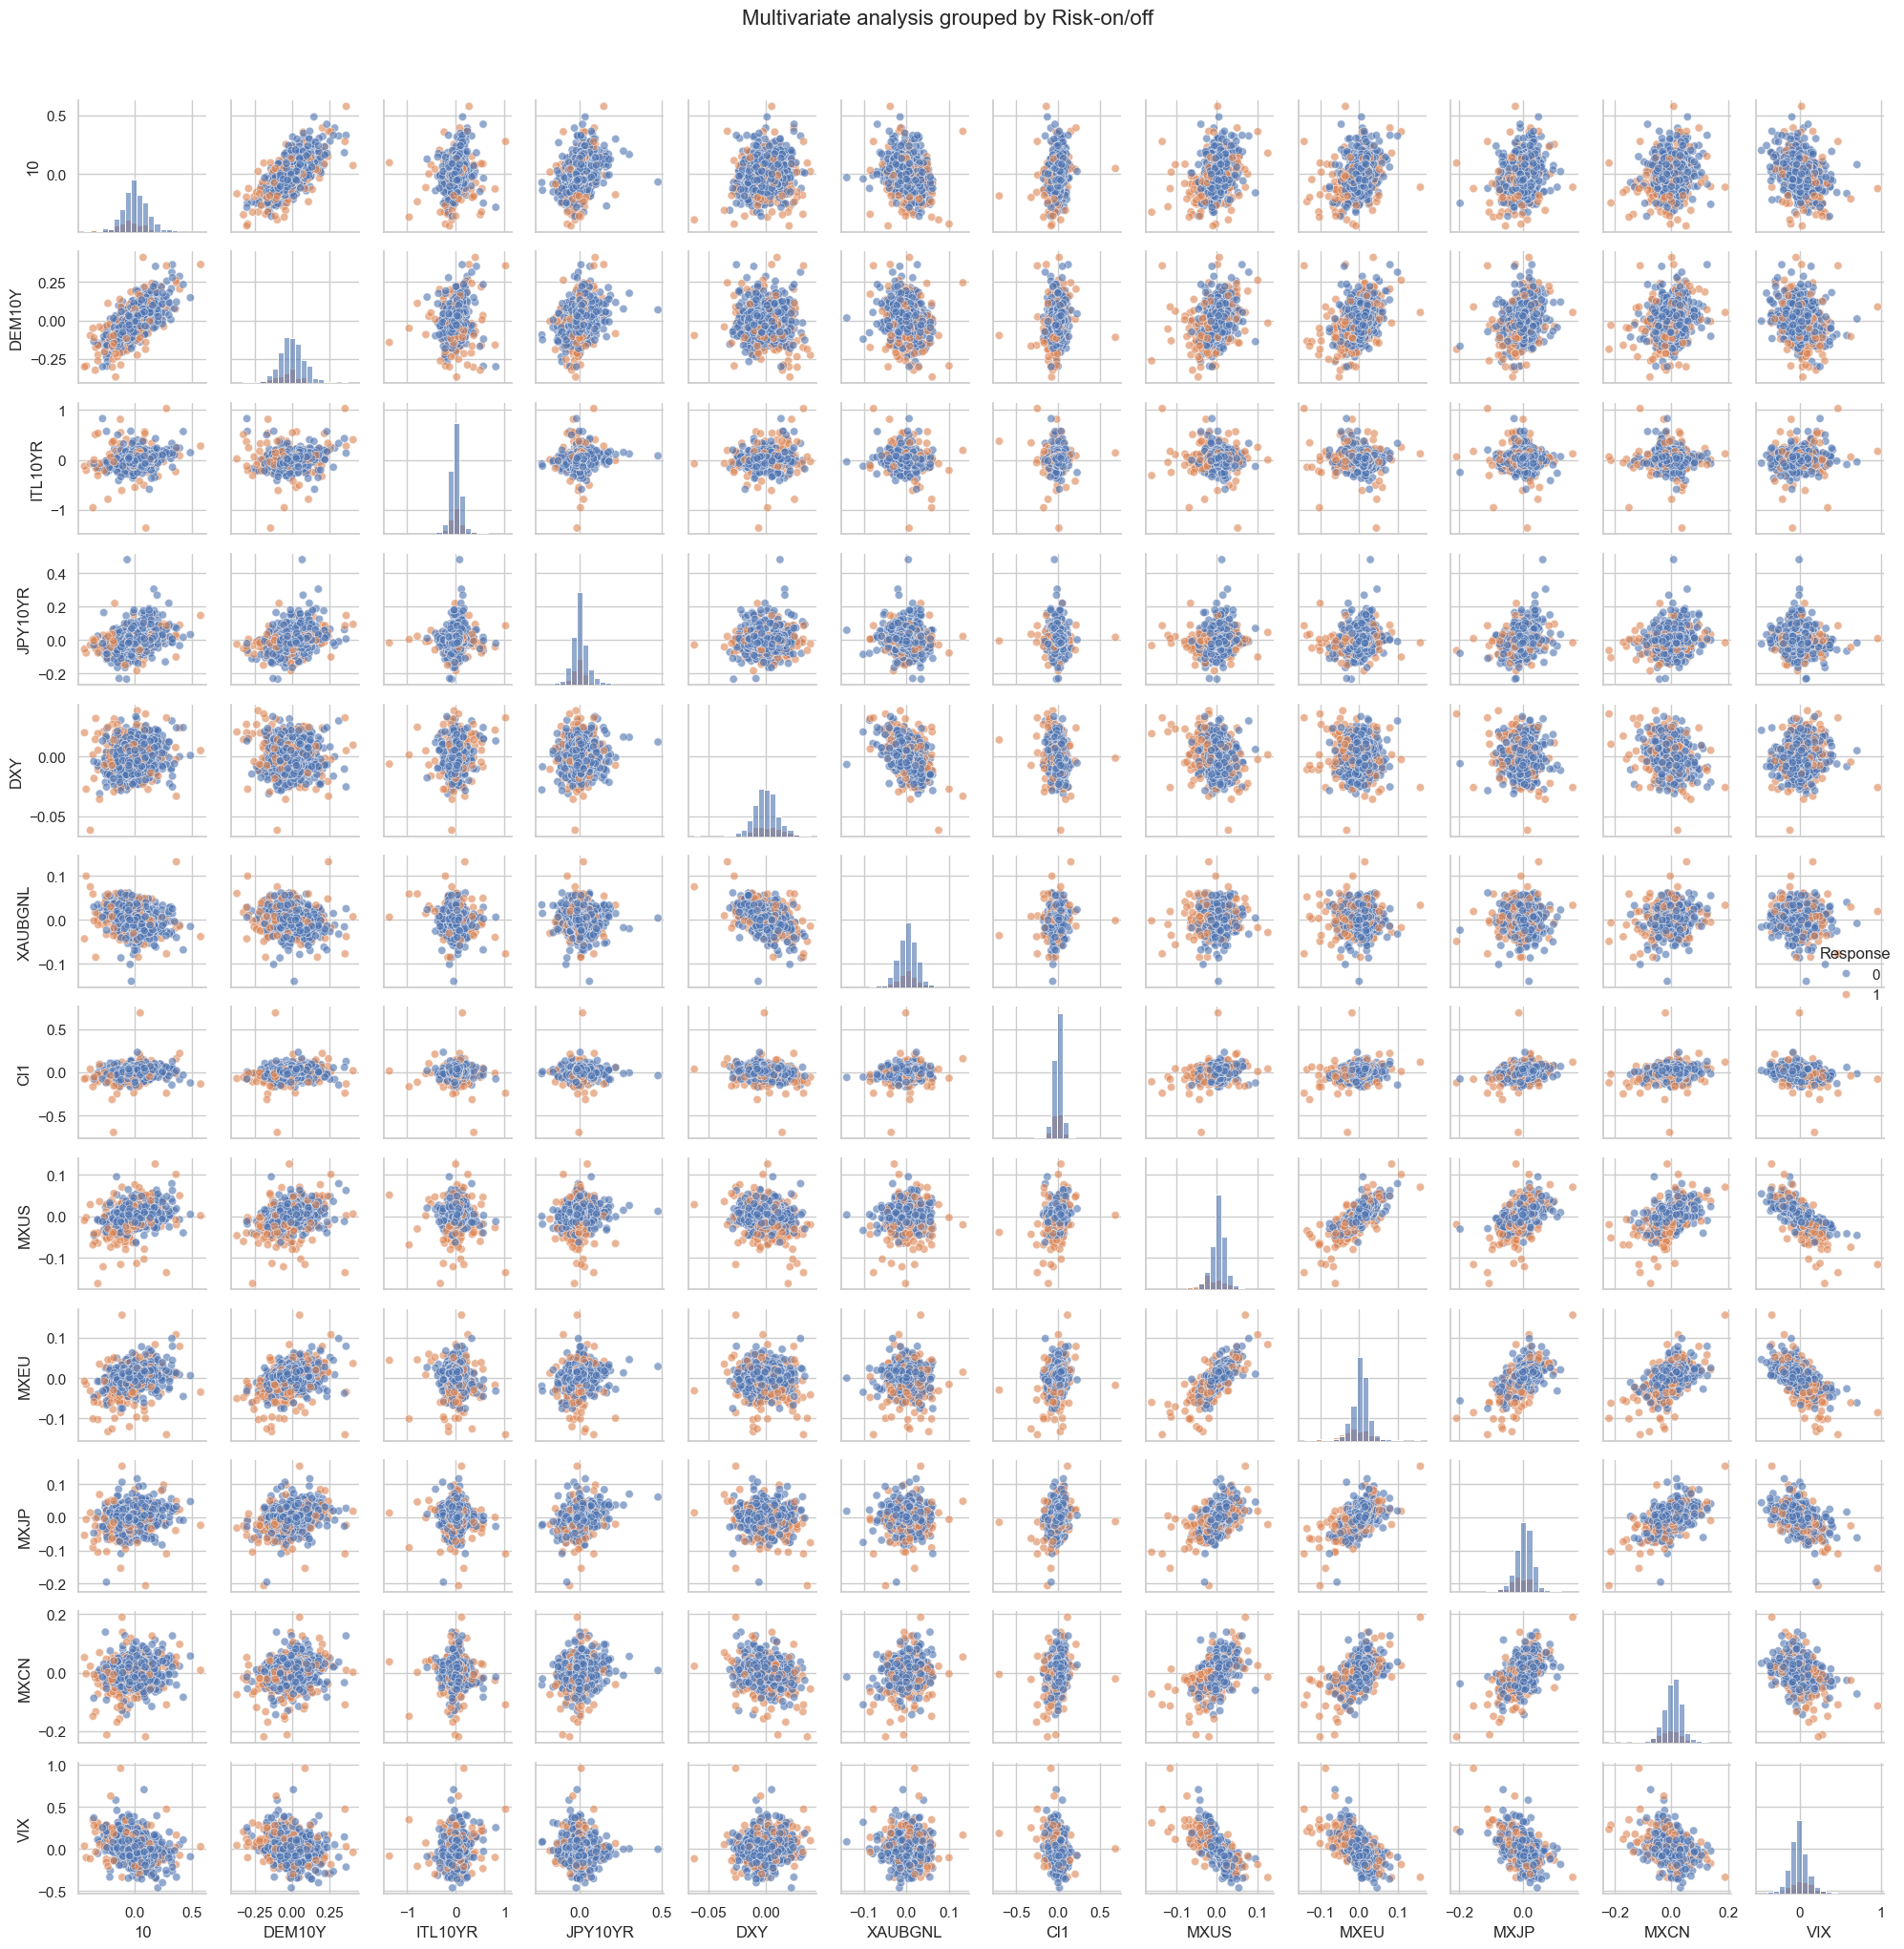

In [15]:
# Create a matrix of scatter plots with Y as grouping variable
# Select a subset of variables for visualization (otherwise the chart is too big)
plot_vars = []
plot_names = []

# Add interest rates (first differences)
for col in ['GT10', 'GTDEM10Y', 'GTITL10YR', 'GTJPY10YR']:
    if col in stationary_df.columns:
        plot_vars.append(stationary_df[col])
        plot_names.append(col.replace('GT', ''))

# Add indices and currencies (log differences)
for col in ['DXY', 'XAUBGNL', 'Cl1', 'MXUS', 'MXEU', 'MXJP', 'MXCN', 'VIX']:
    if col in stationary_df.columns:
        plot_vars.append(stationary_df[col])
        plot_names.append(col)

# Convert to numpy array for plotting
plot_data = np.column_stack(plot_vars)

# Create a custom pairplot with grouping by Y
if y_stationary is not None and len(plot_vars) > 0:
    # Create a DataFrame with the selected variables and the response
    plot_df = pd.DataFrame(plot_data, columns=plot_names)
    plot_df['Response'] = y_stationary

    # Create a pairplot with different colors for Y=0 and Y=1
    g = sns.pairplot(plot_df, hue='Response', diag_kind='hist',
                     plot_kws={'alpha': 0.6}, diag_kws={'alpha': 0.6, 'bins': 20})

    # Customize the plot
    g.fig.suptitle('Multivariate analysis grouped by Risk-on/off', y=1.02, fontsize=16)
    g.fig.set_size_inches(20, 20)
    plt.tight_layout()
    plt.show()


## MVG-based anomaly detector with supervised threshold tuning

We now apply our **Multivariate Gaussian anomaly detector**  to this real-world dataset of financial assets.

We follow the same steps as with synthetic data:

1. Fit the distribution of normal data.
2. Score all points using the estimated PDF.
3. Tune the threshold $\varepsilon$ on a labeled validation set.
4. Evaluate on a held-out test set.

<br>

Let's start with **reshuffling and splitting** our data.

<br>

In [16]:
# Step 1: shuffle and split data into training, validation, and test sets
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 8]

# Convert to numpy arrays for easier manipulation
X = stationary_df.values
y = y_stationary

# Step 1: Creating training/cross-validation/test set with reshuffling

# Reshuffle the data (this will break down autocorrelation)
X_shuffled, y_shuffled = shuffle(X, y, random_state=42)

# Separate normal and anomalous examples
X_normal = X_shuffled[y_shuffled == 0]
X_anomaly = X_shuffled[y_shuffled == 1]

# Calculate sizes for each set
n_normal = X_normal.shape[0]
n_anomaly = X_anomaly.shape[0]

# Training set: 80% of normal examples
train_size = int(0.8 * n_normal)
X_train = X_normal[:train_size]

# Cross-validation set: 10% of normal examples and 50% of anomalies
cv_normal_size = int(0.1 * n_normal)
cv_anomaly_size = int(0.5 * n_anomaly)
X_cv_normal = X_normal[train_size:train_size + cv_normal_size]
X_cv_anomaly = X_anomaly[:cv_anomaly_size]
X_cross_val = np.vstack((X_cv_normal, X_cv_anomaly))
y_cross_val = np.hstack((np.zeros(cv_normal_size), np.ones(cv_anomaly_size)))

# Test set: 10% of normal examples and 50% of anomalies
X_test_normal = X_normal[train_size + cv_normal_size:]
X_test_anomaly = X_anomaly[cv_anomaly_size:]
X_test = np.vstack((X_test_normal, X_test_anomaly))
y_test = np.hstack((np.zeros(len(X_test_normal)), np.ones(len(X_test_anomaly))))

# We'll standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_cross_val = scaler.transform(X_cross_val)
X_test = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]} (all normal)")
print(f"Cross-validation set size: {X_cross_val.shape[0]} ({cv_normal_size} normal, {cv_anomaly_size} anomalies)")
print(f"Test set size: {X_test.shape[0]} ({len(X_test_normal)} normal, {len(X_test_anomaly)} anomalies)")


Training set size: 698 (all normal)
Cross-validation set size: 205 (87 normal, 118 anomalies)
Test set size: 207 (88 normal, 119 anomalies)


### Model fit and threshold tuning

We fit the model on the training set, compute the PDF on the validation set, and search for the best threshold $\varepsilon$ by maximizing the F1 score.


In [17]:
# Step 2: Training the model (estimating parameters of multivariate Gaussian)

# Calculate mean vector
mu = np.mean(X_train, axis=0)

# Calculate covariance matrix
sigma = np.cov(X_train, rowvar=False)

print(f"Mean vector shape: {mu.shape}")
print(f"Covariance matrix shape: {sigma.shape}")


Mean vector shape: (42,)
Covariance matrix shape: (42, 42)


Best F1 score on CV set: 0.7616
Best Epsilon: 8.09971191e-14
Corresponding Precision: 0.6250
Corresponding Recall: 0.9746


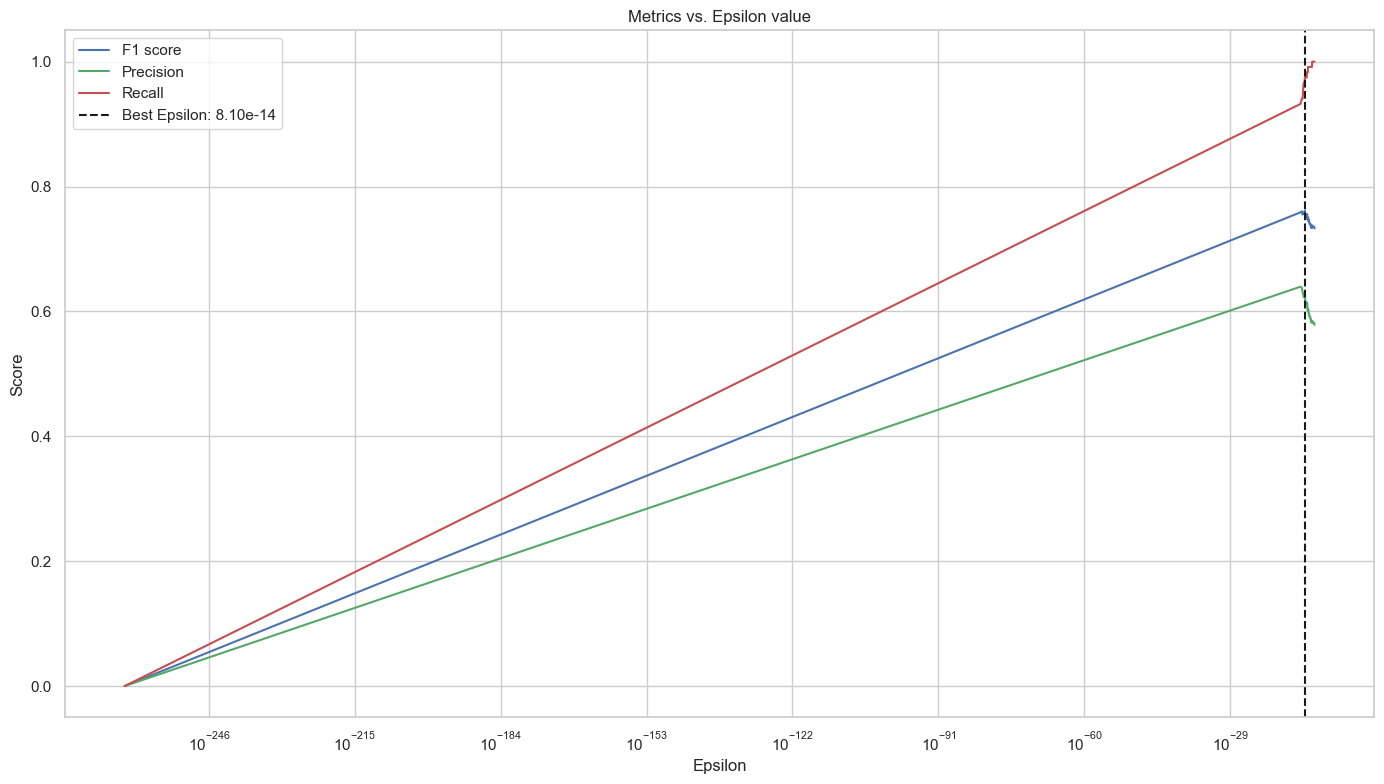

In [18]:
# Step 3: Fine tuning the hyperparameter, the threshold ϵ

# Function to calculate multivariate Gaussian PDF
def multivariate_gaussian_pdf(X, mu, sigma):
    """Calculate the multivariate Gaussian probability density function"""
    n = mu.shape[0]

    # Handle potential numerical issues with the covariance matrix
    # Add a small regularization term to ensure positive definiteness
    sigma_reg = sigma + np.eye(n) * 1e-8

    # Calculate determinant and inverse
    try:
        det = np.linalg.det(sigma_reg)
        inv = np.linalg.inv(sigma_reg)
    except np.linalg.LinAlgError:
        # If still having issues, use pseudo-inverse
        print("Warning: Using pseudo-inverse for covariance matrix")
        det = max(np.linalg.det(sigma_reg), 1e-10)
        inv = np.linalg.pinv(sigma_reg)

    # Calculate PDF for each example
    p = np.zeros(X.shape[0])
    for i in range(X.shape[0]):
        x_mu = X[i] - mu
        p[i] = (1.0 / (np.power(2 * np.pi, n/2) * np.sqrt(det))) * \
               np.exp(-0.5 * x_mu.dot(inv).dot(x_mu))

    return p

# Compute the probability density function for the cross-validation set
p_cv = multivariate_gaussian_pdf(X_cross_val, mu, sigma)

# Find the range of epsilon values to search
min_epsilon = np.min(p_cv)
max_epsilon = np.max(p_cv)
step_size = (max_epsilon - min_epsilon) / 1000

# Find the best epsilon using F1 score
best_epsilon = 0
best_f1 = 0
best_precision = 0
best_recall = 0

epsilon_values = np.arange(min_epsilon, max_epsilon, step_size)
f1_scores = []
precisions = []
recalls = []

for epsilon in epsilon_values:
    predictions = (p_cv < epsilon).astype(int)

    # Calculate metrics
    precision = precision_score(y_cross_val, predictions, zero_division=0)
    recall = recall_score(y_cross_val, predictions, zero_division=0)

    # Calculate F1 score
    if precision + recall > 0:  # Avoid division by zero
        f1 = 2 * precision * recall / (precision + recall)
    else:
        f1 = 0

    f1_scores.append(f1)
    precisions.append(precision)
    recalls.append(recall)

    if f1 > best_f1:
        best_f1 = f1
        best_epsilon = epsilon
        best_precision = precision
        best_recall = recall

print(f"Best F1 score on CV set: {best_f1:.4f}")
print(f"Best Epsilon: {best_epsilon:.8e}")
print(f"Corresponding Precision: {best_precision:.4f}")
print(f"Corresponding Recall: {best_recall:.4f}")

# Plot F1 score, precision, and recall vs epsilon
plt.figure(figsize=(14, 8))
plt.plot(epsilon_values, f1_scores, 'b-', label='F1 score')
plt.plot(epsilon_values, precisions, 'g-', label='Precision')
plt.plot(epsilon_values, recalls, 'r-', label='Recall')
plt.axvline(x=best_epsilon, color='k', linestyle='--', label=f'Best Epsilon: {best_epsilon:.2e}')
plt.xlabel('Epsilon')
plt.ylabel('Score')
plt.title('Metrics vs. Epsilon value')
plt.legend()
plt.xscale('log')  # Log scale for better visualization
plt.grid(True)
plt.tight_layout()
plt.show()


### Model evaluation on test set

We apply the selected threshold to the test set (unseen data) and evaluate the results using precision, recall, F1 score, and confusion matrix (*HINT*: You can pick different metrics, e.g. AUC).

We visualize the classification outcome using two selected features (that you can change...) to better understand false positives and false negatives in feature space.



Test set performance:
Precision: 0.6031
Recall: 0.9832
F1 Score: 0.7476

Confusion Matrix:
True Negatives: 11
False Positives: 77
False Negatives: 2
True Positives: 117


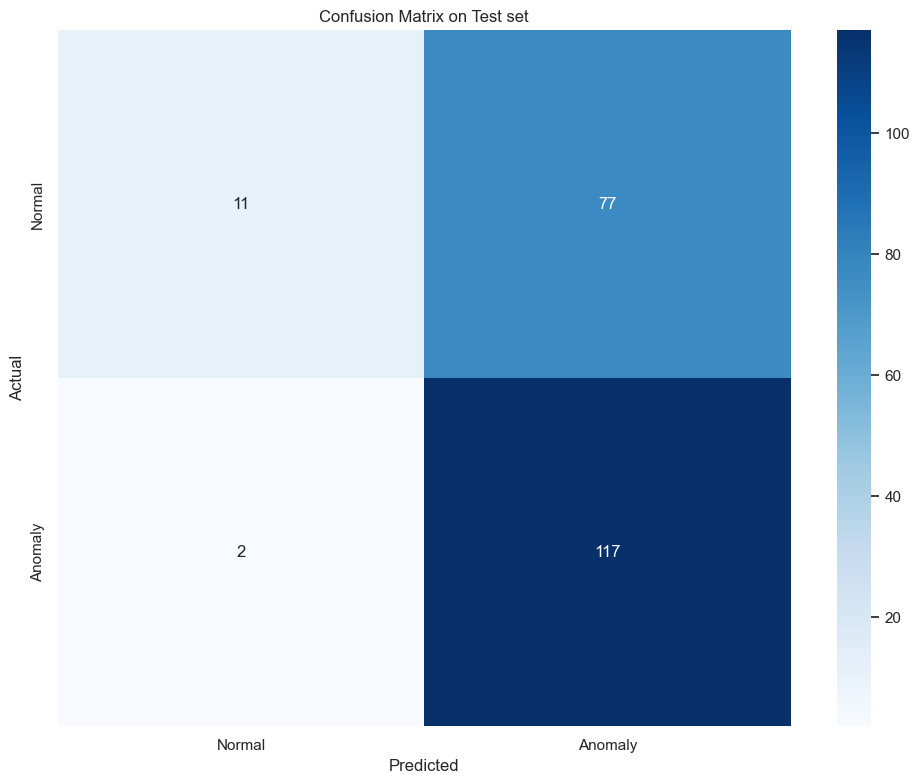

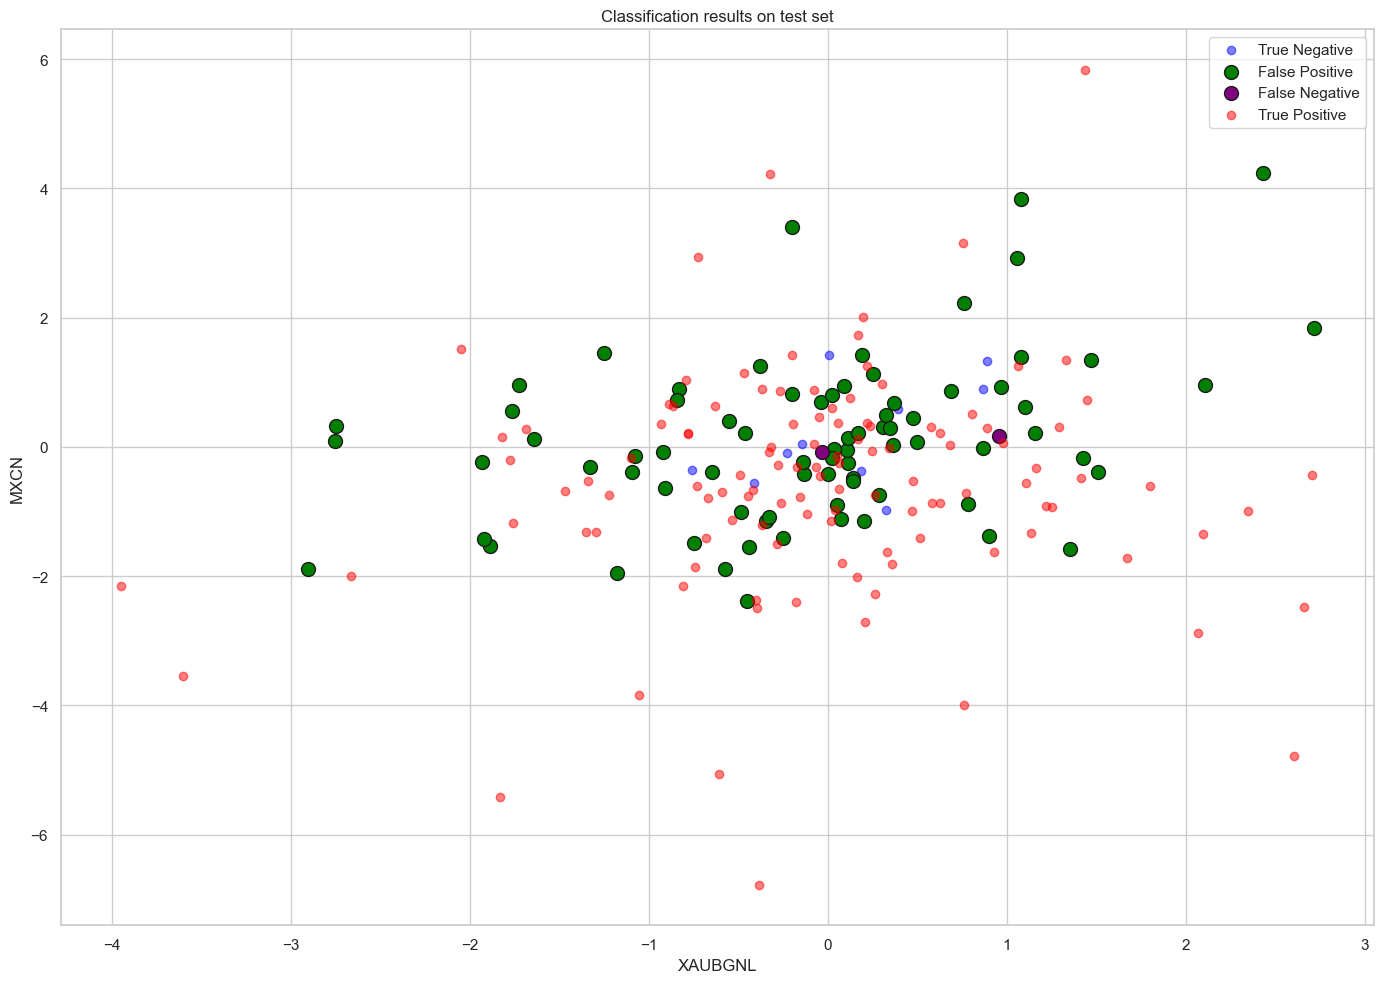

In [19]:
from sklearn.metrics import confusion_matrix

# Step 4: Testing the model

# Compute the probability density function for the test set
p_test = multivariate_gaussian_pdf(X_test, mu, sigma)

# Make predictions using the best epsilon
predictions = (p_test < best_epsilon).astype(int)

# Calculate metrics
MVG_precision = precision_score(y_test, predictions, zero_division=0)
MVG_recall = recall_score(y_test, predictions, zero_division=0)
MVG_f1 = f1_score(y_test, predictions, zero_division=0)

print("\nTest set performance:")
print(f"Precision: {MVG_precision:.4f}")
print(f"Recall: {MVG_recall:.4f}")
print(f"F1 Score: {MVG_f1:.4f}")

# Create confusion matrix
cm = confusion_matrix(y_test, predictions)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix:")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")

# Visualize confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix on Test set')
plt.tight_layout()
plt.show()


# Visualize examples of correctly and incorrectly classified points
# Select two features for visualization
if X_test.shape[1] >= 2:
    # Choose two features (columns) for visualization
    feature1_idx = 22  # First feature
    feature2_idx = 15  # Second feature

    # Get feature names
    feature1_name = stationary_df.columns[feature1_idx]
    feature2_name = stationary_df.columns[feature2_idx]

    plt.figure(figsize=(14, 10))

    # True negatives (correctly classified normal points)
    plt.scatter(X_test[(y_test == 0) & (predictions == 0), feature1_idx],
                X_test[(y_test == 0) & (predictions == 0), feature2_idx],
                c='blue', marker='o', alpha=0.5, label='True Negative')

    # False positives (normal points classified as anomalies)
    plt.scatter(X_test[(y_test == 0) & (predictions == 1), feature1_idx],
                X_test[(y_test == 0) & (predictions == 1), feature2_idx],
                c='green', marker='o', s=100, edgecolors='k', label='False Positive')

    # False negatives (anomalies classified as normal)
    plt.scatter(X_test[(y_test == 1) & (predictions == 0), feature1_idx],
                X_test[(y_test == 1) & (predictions == 0), feature2_idx],
                c='purple', marker='o', s=100, edgecolors='k', label='False Negative')

    # True positives (correctly classified anomalies)
    plt.scatter(X_test[(y_test == 1) & (predictions == 1), feature1_idx],
                X_test[(y_test == 1) & (predictions == 1), feature2_idx],
                c='red', marker='o', alpha=0.5, label='True Positive')

    plt.xlabel(feature1_name)
    plt.ylabel(feature2_name)
    plt.title('Classification results on test set')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


### Global visualization via PCA

We apply **Principal Component Analysis (PCA)** to project the high-dimensional feature space  onto the first two principal components.

This allows a compact visualization of the test set, highlighting where the model correctly or incorrectly classified points.

Each point is categorized as:

- **True Positive**: anomaly detected correctly.
- **False Positive**: normal point flagged as anomaly.
- **False Negative**: anomaly missed by the model.
- **True Negative**: normal point correctly ignored.

> 📌 This view helps assess whether **misclassifications** tend to concentrate  
> in specific regions of the feature space or appear randomly scattered.

---

> 🔎 Interestingly enough, anomalies do **not** cluster at the periphery of the PCA space, contrary to what can be seen with a simple 2-variable market model.

> Instead, they are spread across the projection — indicating that the “anomalousness” is not necessarily aligned with the top components of variance.

This is because there are many variables and both the mapping and the behavior of the markets are complex.

This also highlights a limitation of **density-based models with linear projections**: anomalies may hide in dense regions or align with patterns that require more **complex or nonlinear representations** to detect effectively.

<br>

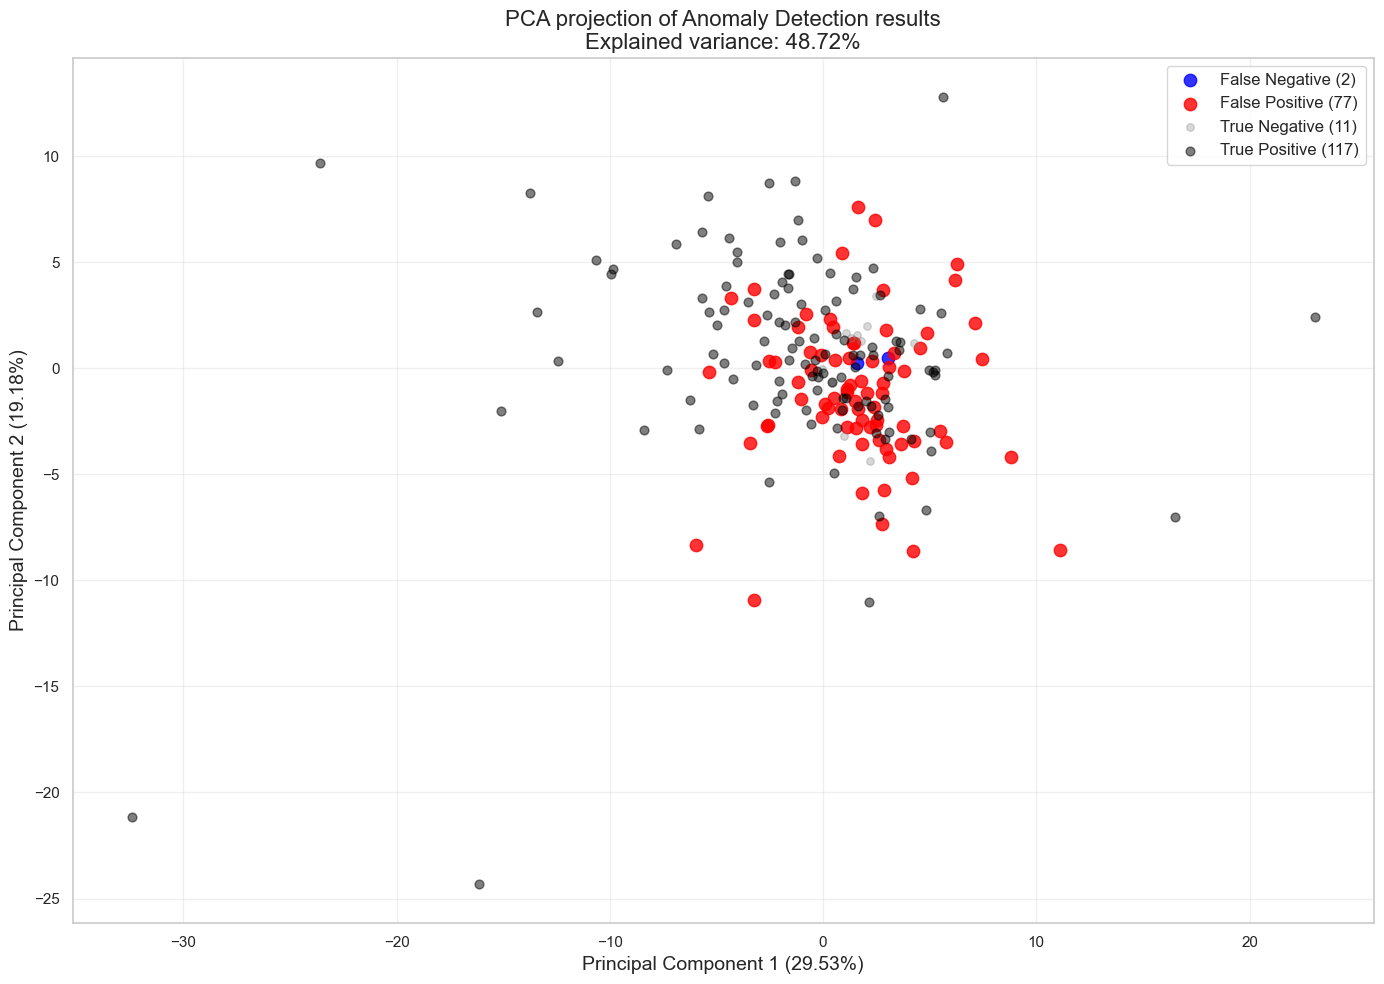

Variance explained by first two principal components: 48.72%


In [20]:
# PCA visualization of anomalies
from sklearn.decomposition import PCA

# Apply PCA to reduce dimensionality to 2 components
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)

# Create a DataFrame for easier plotting
pca_df = pd.DataFrame(X_test_pca, columns=['PC1', 'PC2'])
pca_df['Actual'] = y_test
pca_df['Predicted'] = predictions

# Create classification categories
pca_df['Category'] = 'Unknown'
pca_df.loc[(y_test == 0) & (predictions == 0), 'Category'] = 'True Negative'
pca_df.loc[(y_test == 0) & (predictions == 1), 'Category'] = 'False Positive'
pca_df.loc[(y_test == 1) & (predictions == 0), 'Category'] = 'False Negative'
pca_df.loc[(y_test == 1) & (predictions == 1), 'Category'] = 'True Positive'

# Calculate explained variance (just to know...)
explained_variance = pca.explained_variance_ratio_
total_variance = sum(explained_variance)

# Plot the PCA projection
plt.figure(figsize=(14, 10))

# Define colors and markers
colors = {'True Negative': 'gray', 'True Positive': 'black',
          'False Positive': 'red', 'False Negative': 'blue'}

# Use same marker for all to simplify
markers = {'True Negative': 'o', 'True Positive': 'o',
           'False Positive': 'o', 'False Negative': 'o'}

# Make misclassified points very visible
alphas = {'True Negative': 0.3, 'True Positive': 0.5,
          'False Positive': 0.8, 'False Negative': 0.8}

sizes = {'True Negative': 30, 'True Positive': 40,
         'False Positive': 80, 'False Negative': 80}

# Plot each category
for category, group in pca_df.groupby('Category'):
    plt.scatter(group['PC1'], group['PC2'],
                color=colors[category],
                marker=markers[category],
                alpha=alphas[category],
                s=sizes[category],
                label=f"{category} ({len(group)})")

# Title and labels
plt.title(f'PCA projection of Anomaly Detection results\nExplained variance: {total_variance:.2%}', fontsize=16)
plt.xlabel(f'Principal Component 1 ({explained_variance[0]:.2%})', fontsize=14)
plt.ylabel(f'Principal Component 2 ({explained_variance[1]:.2%})', fontsize=14)

# Grid and legend
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

# Print variance explained
print(f"Variance explained by first two principal components: {total_variance:.2%}")


### Nonlinear projection with UMAP

To go beyond linear projections like PCA, we apply **[UMAP](https://umap-learn.readthedocs.io/en/latest/)** — a nonlinear dimensionality reduction technique that captures **manifold structure** in the data.

Unlike PCA, UMAP can preserve local and global relationships even when the geometry is twisted or curved, which might be the case. Like PCA we use the first two UMAP dimensions (equivalents of PC1 and PC2).


> 🔎 Again, in this plot, anomalies do **not** concentrate on the periphery. Instead, they are interspersed across the UMAP space — confirming that the distinction between normal and abnormal is not simply a matter of “being far away,” but of **subtle deviations in structure**. Furthermore, the "compactness" in data representation that comes from the use of dimensionality reduction techniques does not always fit well with the idea of ​​Anomaly Detection (which deals with rare cases).

<br>

This motivates the use of more **expressive models** in future modeling iterations.

<br>


c:\Users\vitto\AppData\Local\Python\pythoncore-3.10-64\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


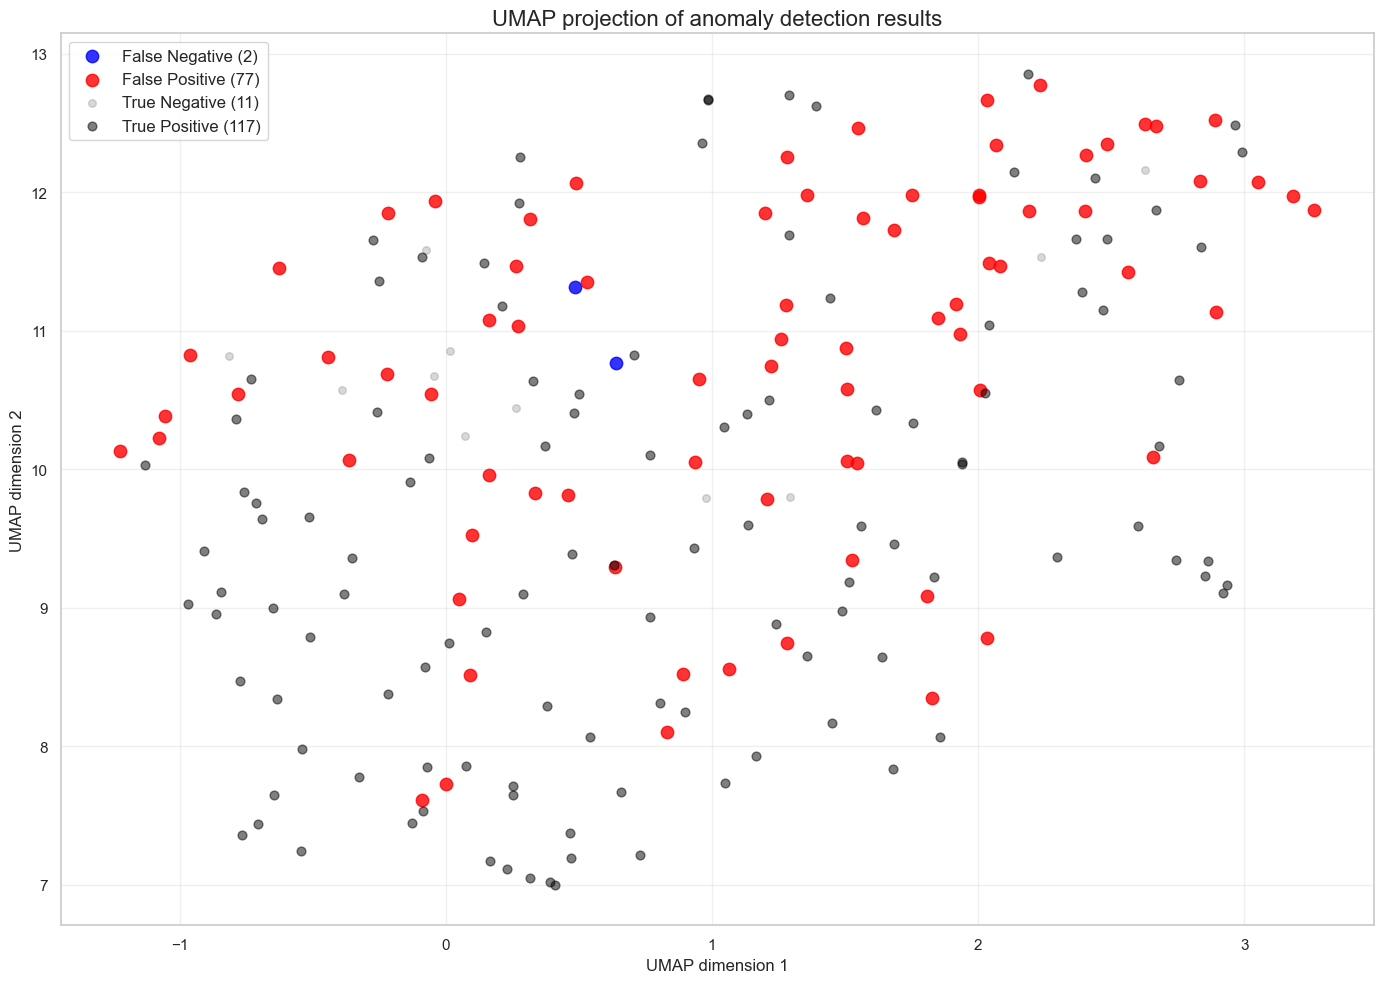

In [21]:
try:
    import umap.umap_ as umap
except ModuleNotFoundError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "umap-learn"])
    import umap.umap_ as umap

# Fit UMAP on the test set
reducer = umap.UMAP(random_state=42)
X_test_umap = reducer.fit_transform(X_test)

# Add UMAP projection to dataframe
umap_df = pd.DataFrame(X_test_umap, columns=['UMAP1', 'UMAP2'])
umap_df['Category'] = pca_df['Category']  # Same classification labels

# Color and size configuration, same as before
colors = {'True Negative': 'gray', 'True Positive': 'black',
          'False Positive': 'red', 'False Negative': 'blue'}

sizes = {'True Negative': 30, 'True Positive': 40,
         'False Positive': 80, 'False Negative': 80}

alphas = {'True Negative': 0.3, 'True Positive': 0.5,
          'False Positive': 0.8, 'False Negative': 0.8}

# Plot
plt.figure(figsize=(14, 10))
for category, group in umap_df.groupby('Category'):
    plt.scatter(group['UMAP1'], group['UMAP2'],
                c=colors[category],
                s=sizes[category],
                alpha=alphas[category],
                label=f"{category} ({len(group)})")

plt.title('UMAP projection of anomaly detection results', fontsize=16)
plt.xlabel('UMAP dimension 1')
plt.ylabel('UMAP dimension 2')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


<br>

### HINTs
#### 🛠️ Understand model's behavior

As always, it's wise to start from simple models and understand them.

In order to do that:
- Try to understand the situation using **other dimensionality reduction techniques**, e.g. [t-SNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html), UMAP (with 3 dimensions), [PACMAP](https://pypi.org/project/pacmap/), [Spectral Embedding](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.spectral_embedding.html). Try using **3D charts**.
- **Do this for synthetic data as well**, trying to generate other data, too (with more "separated"/less "separated" anomalies, adding dimensions - i.e. variables, going from 2 to 3 to 4, and so on... observing how the results change), and **compare the results with real data from Bloomberg** to understand the scope and limitations of the model. Do that also using other models - see below.
- Try **better estimators** for the mean and the covariance, say, [Ledoit-Wolf](https://scikit-learn.org/stable/modules/generated/sklearn.covariance.LedoitWolf.html#sklearn.covariance.LedoitWolf) for the covariance.
- Try **different version of this elliptic model** - see [Elliptic Envelope].(https://scikit-learn.org/stable/modules/generated/sklearn.covariance.EllipticEnvelope.html#sklearn.covariance.EllipticEnvelope)
- **"Give the model more financial context"**. For example, you can see that the "anomaly" label has often been attributed to extremely negative markets and that the multivariate probability density also signals abnormally good markets as anomalous. Thus, you can try take into account this "asymmetry". For example, segment the dataset into assets whose behavior is homogeneous (eg the group of interest rates, the group of equity indices, the "safest" assets, etc.), use the Cumulative Distribution Function (the CDF, instead of the PDF), so we you check when Prob(x1< p, x2 < p,...), and obtain separate sub-scores to be combined in an aggregate score.  Use a discriminating variable, which separates abnormally positive situations from abnormally negative ones, for example an aggregate equity index (in bad situations equities tend to go down, overall), or a volatility index. So if the discriminating variable, say an aggregate equity index, it is above a given threshold K, we cannot say it's a risk-off (anomalous) situation. Note that if you introduce this new threshold, you have another hyperparameter to tune in crossvalidation...


These are just examples: use your financial know-how and data science tool-kit.

<br>


## Comparing Anomaly Detection Models

We now compare several anomaly detection methods — from simpler models to deep learning.

All models are tested on the **same financial dataset**, and evaluated using consistent metrics: **Precision, Recall, F1 Score, Confusion Matrix, ROC Curve**, and **PCA projections** (you might use UMAP as well).

The categories of models are:

- **MVG Baseline**: our probabilistic model trained on normal data only - it's our baseline model, the benchmark.
- **Supervised models**: Random Forest, SVM.
- **Unsupervised models**: Isolation Forest, Local Outlier Factor, One-Class SVM, Gaussian Mixture.
- **Deep learning**: Autoencoder trained on normal data, scored via reconstruction error.

The goal is not just to compare performance, but to reflect on **methodological trade-offs** between complexity and interpretability, data requirements, and flexibility. We want to understand pros and cons.


In [22]:
# Step 0: Functions and utilities for comparison of supervised and unsupervised Anomaly Detection methods

from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import OneClassSVM, SVC
from sklearn.neighbors import LocalOutlierFactor

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 8]

# We already have X_train, X_cross_val, y_cross_val, X_test, y_test from previous code cells
# We'll standardize the data for better performance with many algorithms
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_cv_scaled = scaler.transform(X_cross_val)
X_test_scaled = scaler.transform(X_test)

# Function to evaluate and visualize model performance
def evaluate_model(y_true, y_pred, y_score, model_name):
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n{model_name} Performance:")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Anomaly'],
                yticklabels=['Normal', 'Anomaly'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.tight_layout()
    plt.show()

    # ROC Curve
    if y_score is not None:  # Some models don't provide probability scores
        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve - {model_name}')
        plt.legend(loc="lower right")
        plt.tight_layout()
        plt.show()

    return precision, recall, f1

# Function to visualize results in PCA space
def visualize_pca(X, y_true, y_pred, model_name):
    # Apply PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    # Create a DataFrame for plotting
    pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
    pca_df['Actual'] = y_true
    pca_df['Predicted'] = y_pred

    # Create classification categories
    pca_df['Category'] = 'Unknown'
    pca_df.loc[(y_true == 0) & (y_pred == 0), 'Category'] = 'True Negative'
    pca_df.loc[(y_true == 0) & (y_pred == 1), 'Category'] = 'False Positive'
    pca_df.loc[(y_true == 1) & (y_pred == 0), 'Category'] = 'False Negative'
    pca_df.loc[(y_true == 1) & (y_pred == 1), 'Category'] = 'True Positive'

    # Calculate explained variance
    explained_variance = pca.explained_variance_ratio_
    total_variance = sum(explained_variance)

    # Plot
    plt.figure(figsize=(12, 8))

    # Define colors and sizes
    colors = {'True Negative': 'gray', 'True Positive': 'black',
              'False Positive': 'red', 'False Negative': 'blue'}
    alphas = {'True Negative': 0.3, 'True Positive': 0.5,
              'False Positive': 0.8, 'False Negative': 0.8}
    sizes = {'True Negative': 30, 'True Positive': 40,
             'False Positive': 80, 'False Negative': 80}

    # Plot each category
    for category, group in pca_df.groupby('Category'):
        plt.scatter(group['PC1'], group['PC2'],
                    color=colors[category],
                    alpha=alphas[category],
                    s=sizes[category],
                    label=f"{category} ({len(group)})")

    plt.title(f'PCA projection - {model_name}\nExplained variance: {total_variance:.2%}', fontsize=16)
    plt.xlabel(f'PC1 ({explained_variance[0]:.2%})', fontsize=14)
    plt.ylabel(f'PC2 ({explained_variance[1]:.2%})', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

# Store results for comparison
results = []



### Supervised models

These models are trained using the anomaly labels we have.  
Thus, they explicitly learn to separate normal and anomalous cases based on known examples.

We use two common algos:

- **Random Forest Classifier**.
- **Support Vector Machine (SVM)**.

The training set includes both normal and anomalous data, combined from the original training and validation sets.

⚠️ Note on **data preparation for Supervised models**

Since our original training set contains only normal data (by design),  
we combine it with the cross-validation set to build a **supervised training set**.

This allows models like **Random Forest** and **SVM**, which require labeled anomalies, to actually learn how to separate normal from anomalous observations.

We are not using the validation set for hyperparameter tuning here,  
but simply to increase the pool of labeled data available for supervised learning. It's a simple data split - you can use k-fold cross validation. But be careful, too many folds (k=large) risk having few examples for the training, so even this simple approach has a reason. Try.

<br>

SUPERVISED ANOMALY DETECTION METHODS

Training Random Forest classifier...

Random Forest (Supervised) Performance:
Precision: 1.0000
Recall: 0.0252
F1 Score: 0.0492


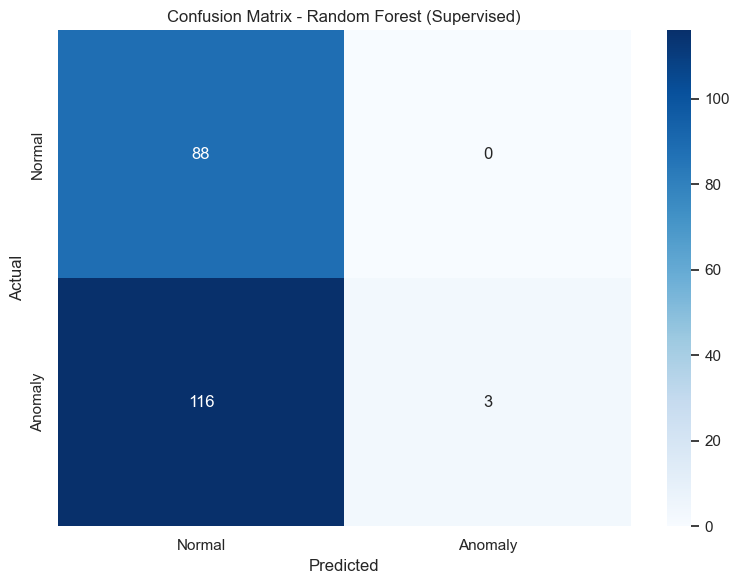

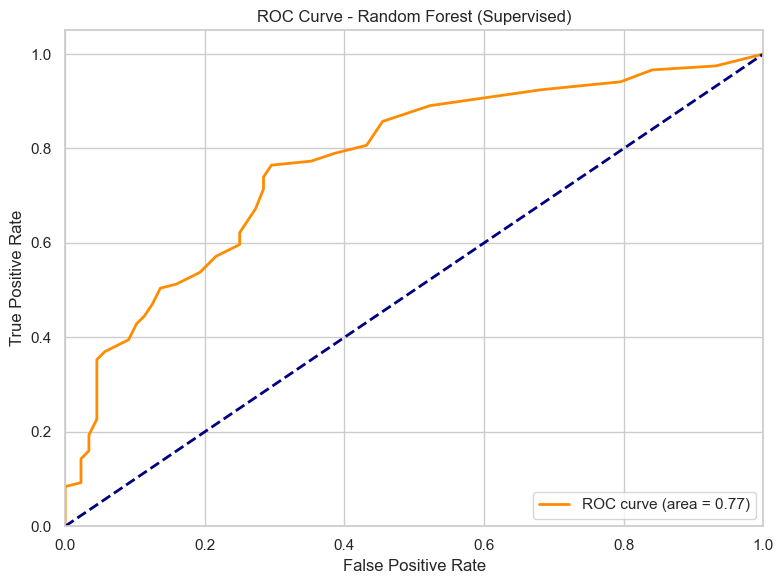

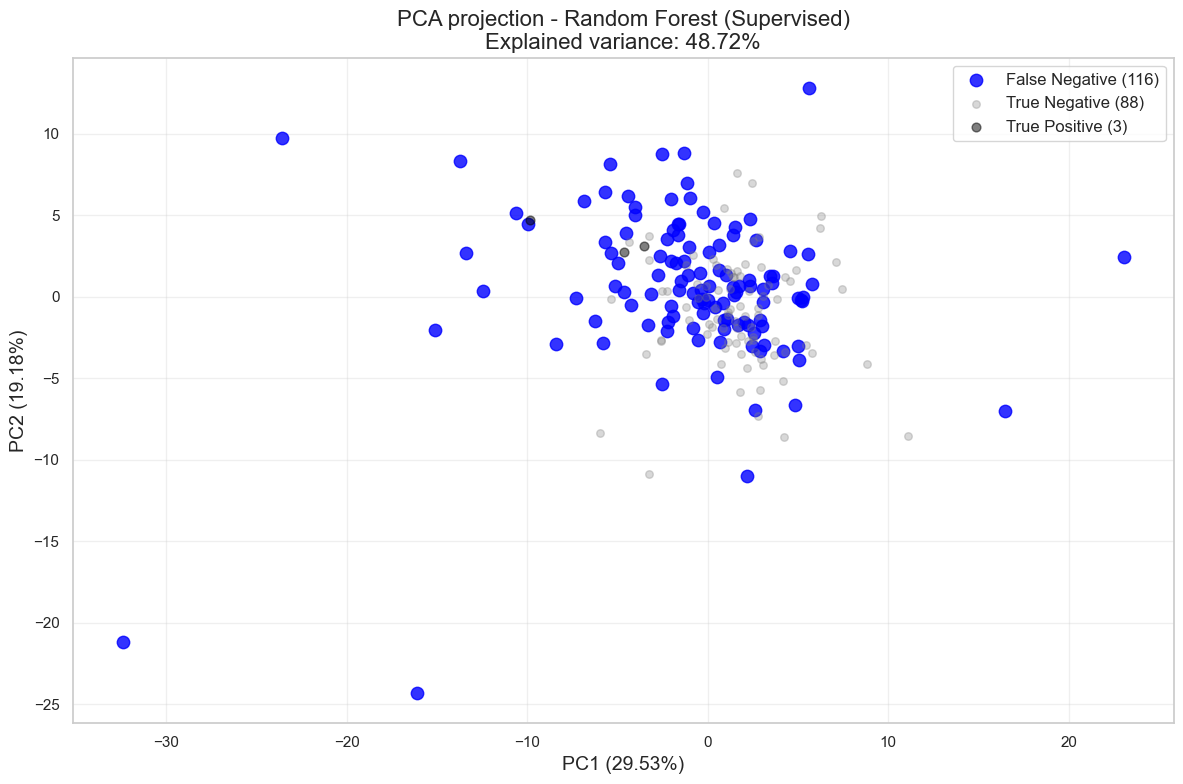


Training Support Vector Machine...

SVM (Supervised) Performance:
Precision: 0.8841
Recall: 0.5126
F1 Score: 0.6489


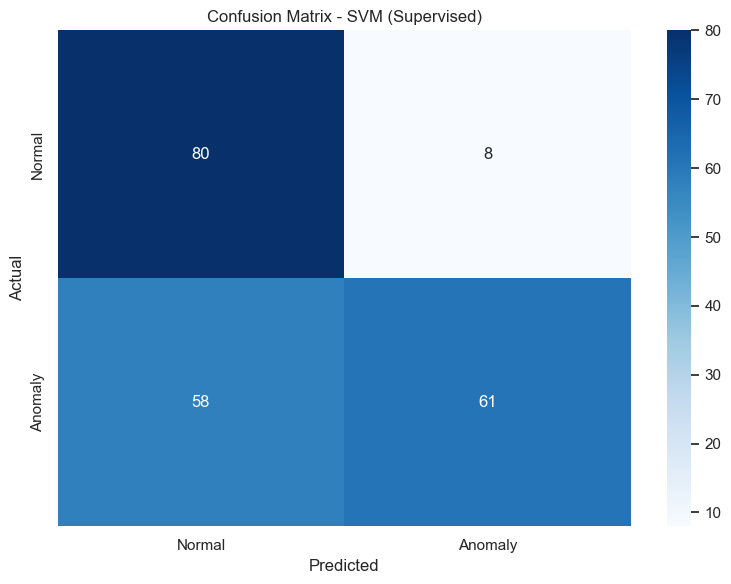

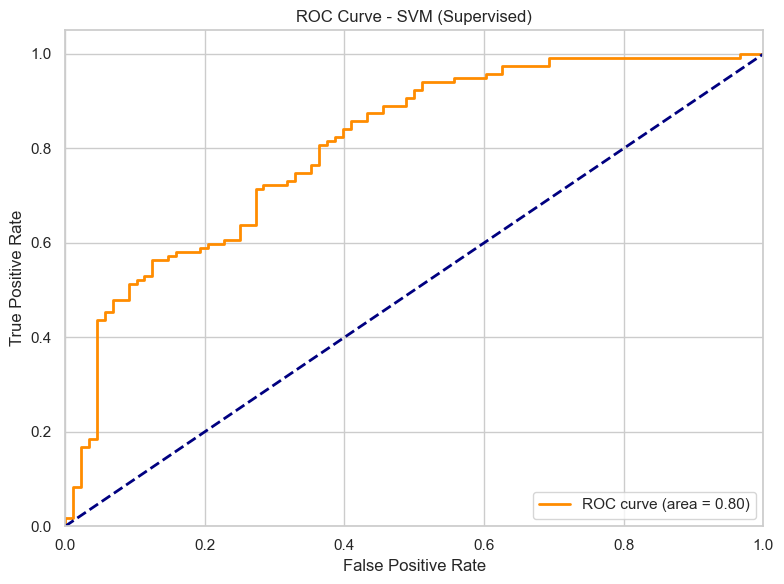

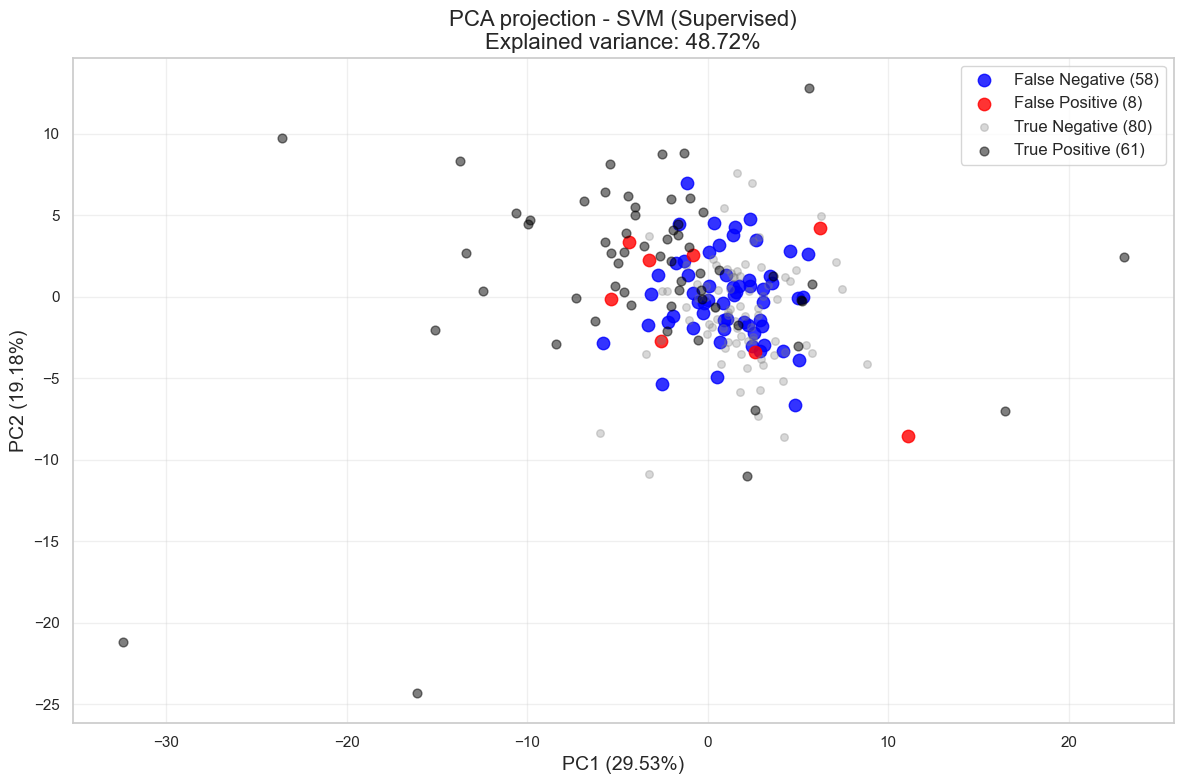

In [23]:
# 1. SUPERVISED APPROACHES

print("=" * 50)
print("SUPERVISED ANOMALY DETECTION METHODS")
print("=" * 50)

# 1.1 Random Forest Classifier
print("\nTraining Random Forest classifier...")
# For supervised methods, we need to combine training and cross-validation sets in order to have some anomalies to train with
X_train_cv = np.vstack((X_train_scaled, X_cv_scaled))
y_train_cv = np.hstack((np.zeros(len(X_train_scaled)), y_cross_val))

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train_cv, y_train_cv)  # Train on combined data

# Predict on test set
rf_pred = rf_model.predict(X_test_scaled)
rf_score = rf_model.predict_proba(X_test_scaled)[:, 1]  # Probability of class 1 (anomaly)

# Evaluate
rf_metrics = evaluate_model(y_test, rf_pred, rf_score, "Random Forest (Supervised)")
visualize_pca(X_test_scaled, y_test, rf_pred, "Random Forest (Supervised)")
results.append(("Random Forest (Supervised)", *rf_metrics))

# 1.2 Support Vector Machine
print("\nTraining Support Vector Machine...")
svm_model = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)
svm_model.fit(X_train_cv, y_train_cv)

# Predict on test set
svm_pred = svm_model.predict(X_test_scaled)
svm_score = svm_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
svm_metrics = evaluate_model(y_test, svm_pred, svm_score, "SVM (Supervised)")
visualize_pca(X_test_scaled, y_test, svm_pred, "SVM (Supervised)")
results.append(("SVM (Supervised)", *svm_metrics))


And here we have come face to face with a mega-problem of **classifiers in Anomaly Detection**...

Namely, that an Anomaly Detection problem always has to do with an extremely unbalanced data set (if not, it wouldn't be Anomaly Detection): we are talking about **unbalanced classe**s. And when there are few examples to learn from, a classifier often learns little, and badly.

There are **various techniques to mitigate the problem of unbalanced classes**, all based on the basic idea of ​**​oversampling** the minority class or - guess what? - ...**undersampling** the majority class, all with quite clever tricks to generate synthetic data that are not exactly identical. But let's face it: they are almost always palliatives. We will talk about it in the next lesson, but if you are curious you can take a look at the idea of [SMOTE: Synthetic Minority Over-sampling Technique](https://arxiv.org/abs/1106.1813).

<br>

### Unsupervised Models

We now test a series of unsupervised models — these do **not use any labels during training** and rely solely on data structure. So we don't use our response vector Y during the training.

The models we consider are:

- **[Isolation Forest](https://en.wikipedia.org/wiki/Isolation_forest)**.
- **[One-Class SVM](https://en.wikipedia.org/wiki/One-class_classification)**.
- **[Local Outlier Factor (LOF)](https://en.wikipedia.org/wiki/Local_outlier_factor)**.
- **[Gaussian Mixture Model (GMM)](https://en.wikipedia.org/wiki/Mixture_model)**.

All of them require an estimate of the expected **contamination** (anomaly rate), which we derive from the validation set for consistency (not from the whole sample, otherwise it's overfitting...). To avoid degenerate behavior, we cap the contamination at 50%.

> This step is critical for models like Isolation Forest and LOF.
> that rely on this hyperparameter to tune internal decision thresholds.


Here we use the original data split (train\cv\test).

> ⚠️ Memento: unlike the supervised case, here **anomalies are not used at all during training**. Let's see how it goes...


In [24]:
# 2. UNSUPERVISED APPROACHES

print("\n" + "=" * 50)
print("UNSUPERVISED ANOMALY DETECTION METHODS")
print("=" * 50)

# Calculate contamination from cross-validation set
raw_contamination = np.mean(y_cross_val)
print(f"\nEstimated contamination from cross-validation set: {raw_contamination:.4f}")

# Cap contamination for algorithms that have limits
contamination = min(raw_contamination, 0.5)
print(f"Using capped contamination value: {contamination:.4f}")



UNSUPERVISED ANOMALY DETECTION METHODS

Estimated contamination from cross-validation set: 0.5756
Using capped contamination value: 0.5000


#### Isolation Forest

The Isolation Forest algorithm isolates anomalies by recursively partitioning the data using random splits.

It is efficient, scalable, and works well in high dimensions.



Training Isolation Forest...

Isolation Forest (Unsupervised) Performance:
Precision: 0.6838
Recall: 0.7815
F1 Score: 0.7294


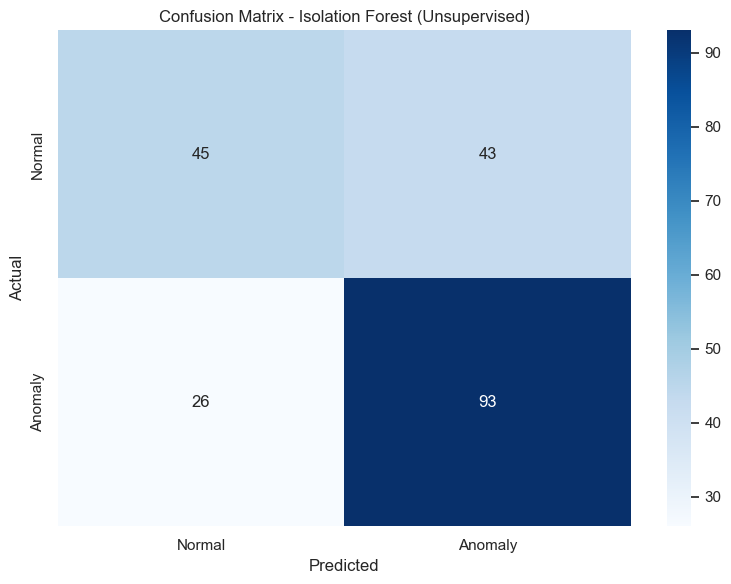

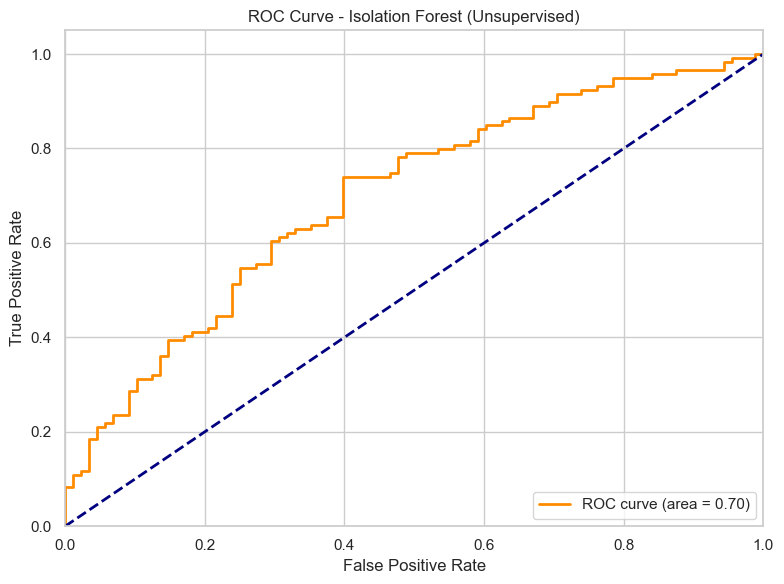

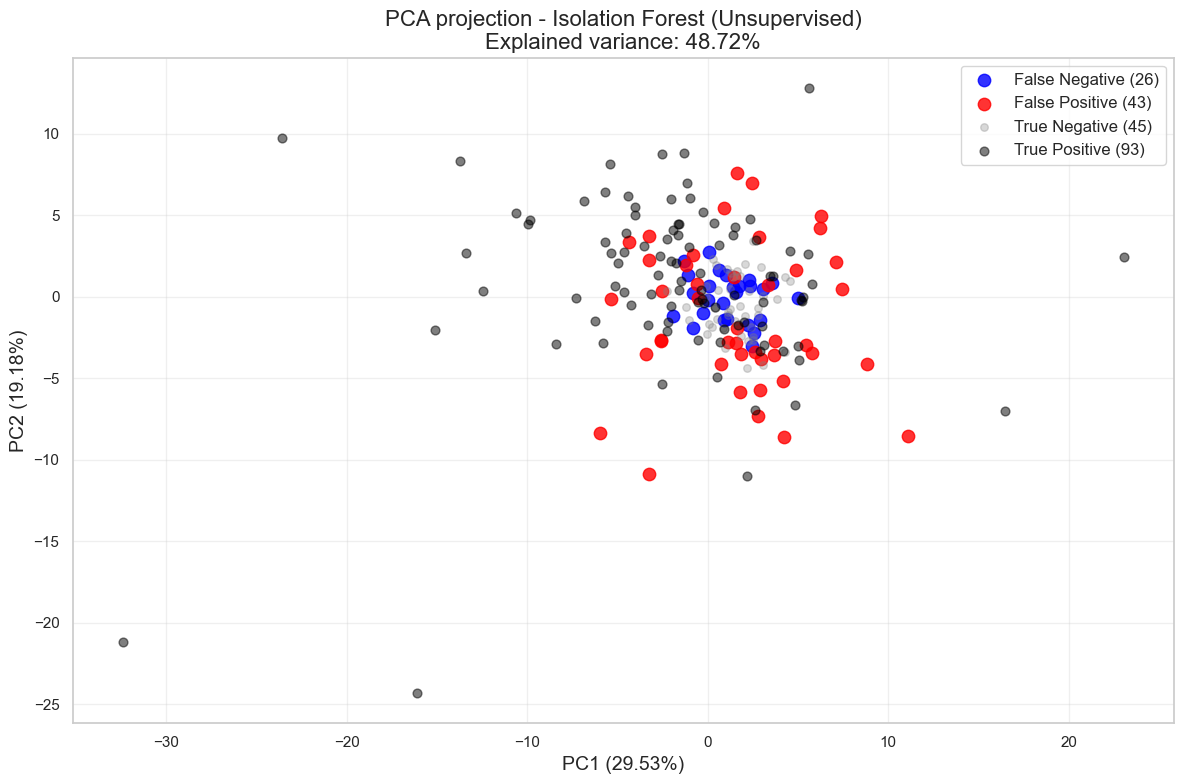

In [25]:
# 2.1 Isolation Forest
print("\nTraining Isolation Forest...")
iso_model = IsolationForest(contamination=contamination, random_state=42)
iso_model.fit(X_train_scaled)

# Predict on test set (convert from 1/-1 to 0/1, where 1 means anomaly)
iso_pred = (iso_model.predict(X_test_scaled) == -1).astype(int)
iso_score = -iso_model.score_samples(X_test_scaled)  # Negative of the anomaly score

# Evaluate
iso_metrics = evaluate_model(y_test, iso_pred, iso_score, "Isolation Forest (Unsupervised)")
visualize_pca(X_test_scaled, y_test, iso_pred, "Isolation Forest (Unsupervised)")
results.append(("Isolation Forest (Unsupervised)", *iso_metrics))


#### One-Class SVM

The One-Class SVM algorithm learns a soft boundary that encloses the majority of the data, treating anything outside this boundary as an anomaly.

It is sensitive to the **nu** parameter, which controls the upper bound on the anomaly fraction and the lower bound on the number of support vectors.

We set `nu` based on the estimated contamination rate, capped to avoid instability.

> 🧠 *Insight*:
> You can think of the One-Class SVM as a **non-linear version**  
> of our initial MVG-based model — both aim to define a boundary around “normal” data,  
> but OCSVM does so using a flexible, **kernel-based surface instead of ellipsoids**.

<br>


Training One-Class SVM...
Using nu value for OneClassSVM: 0.5000

One-Class SVM (Unsupervised) Performance:
Precision: 0.6643
Recall: 0.7983
F1 Score: 0.7252


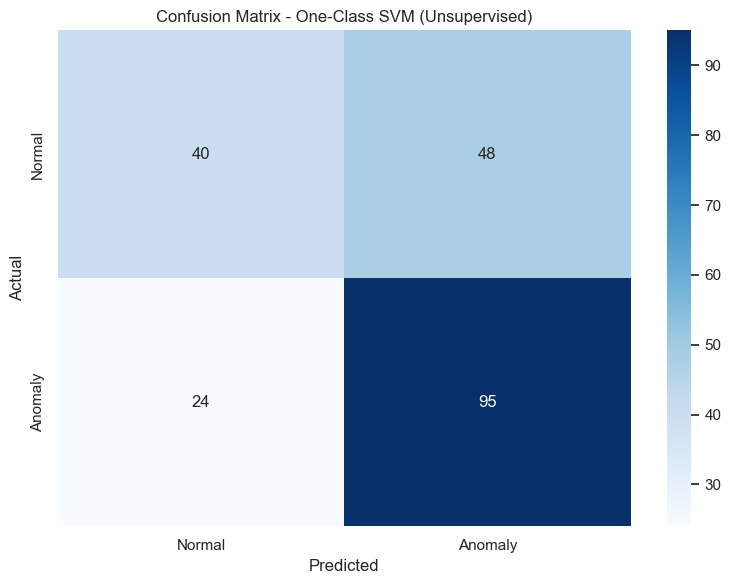

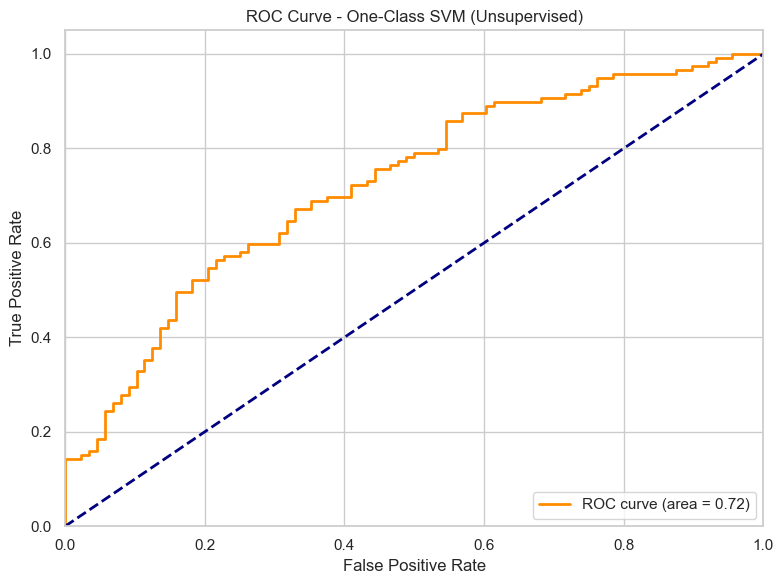

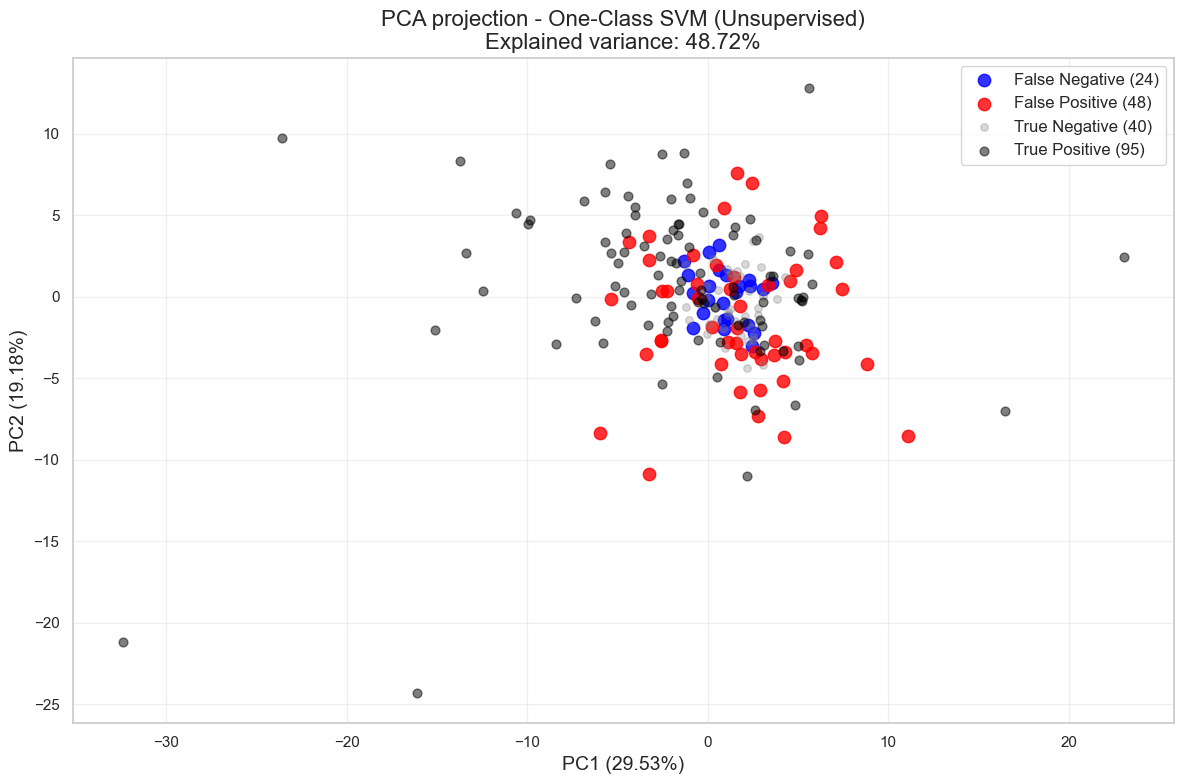

In [26]:
# 2.2 One-Class SVM
print("\nTraining One-Class SVM...")
# OneClassSVM's nu parameter is the upper bound on the fraction of training errors
# and the lower bound of the fraction of support vectors, so it should be in (0, 1)
nu = min(max(0.01, contamination), 0.99)
print(f"Using nu value for OneClassSVM: {nu:.4f}")

ocsvm_model = OneClassSVM(gamma='auto', nu=nu)
ocsvm_model.fit(X_train_scaled)

# Predict on test set
ocsvm_pred = (ocsvm_model.predict(X_test_scaled) == -1).astype(int)
ocsvm_score = -ocsvm_model.decision_function(X_test_scaled)  # Negative of the decision function

# Evaluate
ocsvm_metrics = evaluate_model(y_test, ocsvm_pred, ocsvm_score, "One-Class SVM (Unsupervised)")
visualize_pca(X_test_scaled, y_test, ocsvm_pred, "One-Class SVM (Unsupervised)")
results.append(("One-Class SVM (Unsupervised)", *ocsvm_metrics))


#### Local Outlier Factor (LOF)

LOF detects anomalies by comparing the **local density** of a point to that of its neighbors.

Points that reside in **sparser regions** relative to their surroundings are flagged as outliers.

It is sensitive to the number of neighbors and to the contamination parameter.  
We use `novelty=True` to enable scoring on new, unseen test data.

<br>



Training Local Outlier Factor...

Local Outlier Factor (Unsupervised) Performance:
Precision: 0.6735
Recall: 0.8319
F1 Score: 0.7444


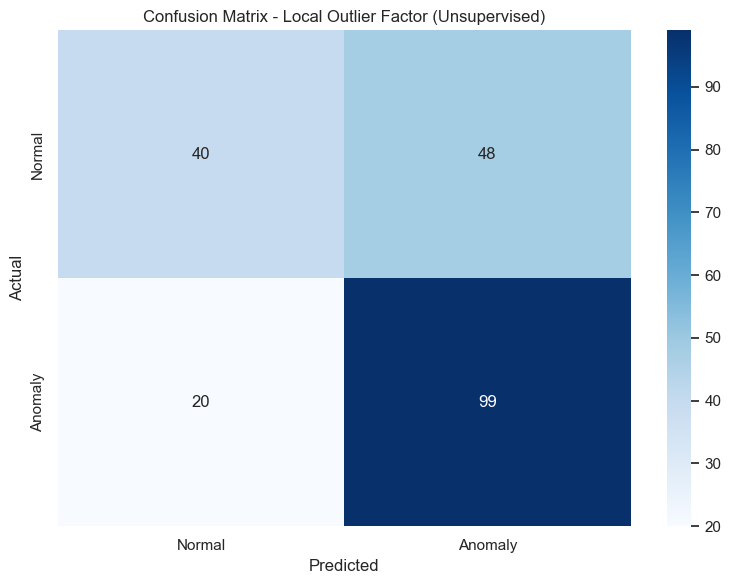

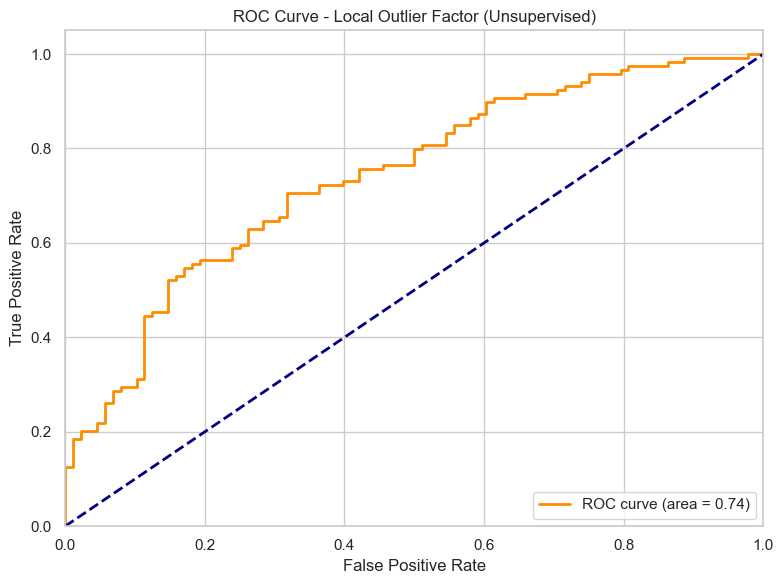

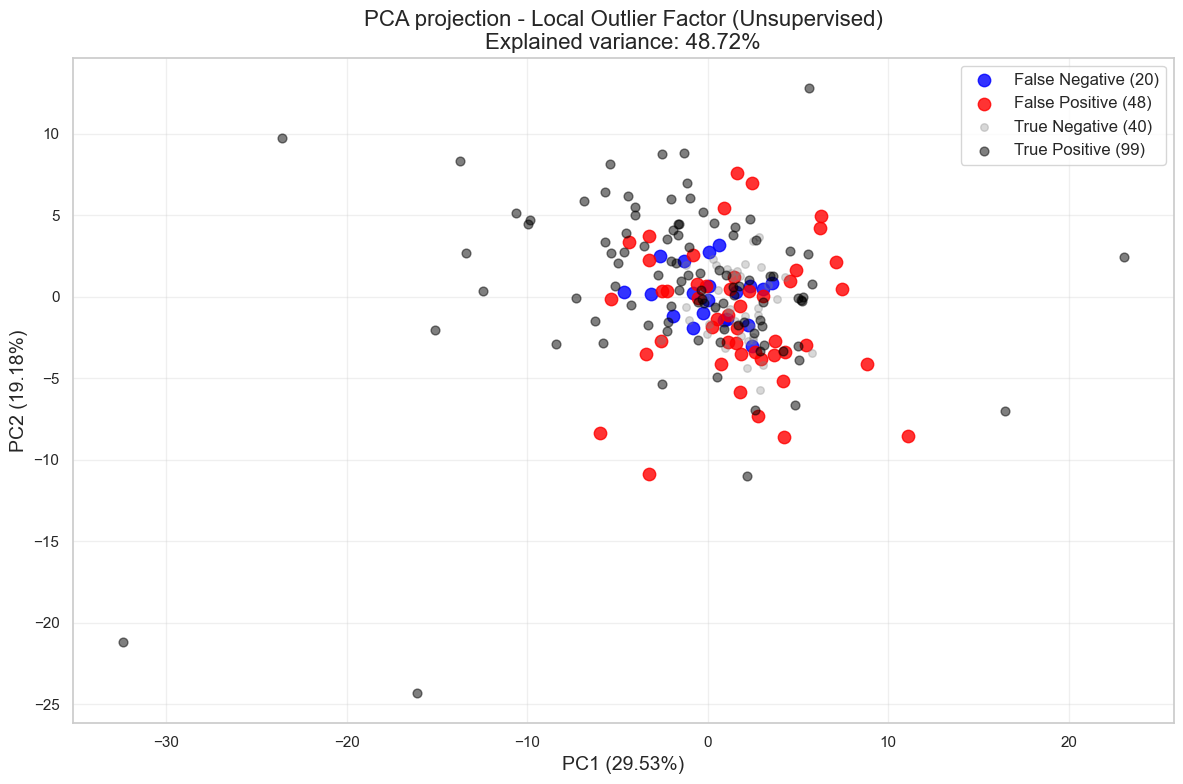

In [27]:
# 2.3 Local Outlier Factor
print("\nTraining Local Outlier Factor...")
# LOF also has a contamination parameter with the same constraints as Isolation Forest
lof_model = LocalOutlierFactor(n_neighbors=20, contamination=contamination, novelty=True)
lof_model.fit(X_train_scaled)

# Predict on test set
lof_pred = (lof_model.predict(X_test_scaled) == -1).astype(int)
lof_score = -lof_model.decision_function(X_test_scaled)  # Negative of the decision function

# Evaluate
lof_metrics = evaluate_model(y_test, lof_pred, lof_score, "Local Outlier Factor (Unsupervised)")
visualize_pca(X_test_scaled, y_test, lof_pred, "Local Outlier Factor (Unsupervised)")
results.append(("Local Outlier Factor (Unsupervised)", *lof_metrics))


#### Gaussian Mixture Model (GMM)

We now use a **2-component Gaussian Mixture Model** to estimate  the log-likelihood of each point under a flexible, **multimodal distribution**.

This approach can capture more complex patterns in the "normal" data,
compared to a single Gaussian (baseline model) which imposes an ellipsoidal structure.

The normal mixture is one of the most flexible distributions on Earth, adapting to skewness, leptokurtosis, and generally complex patterns.
(Be aware that using mixtures with 3 or more components is not trivial: the number of parameters explodes, overfitting and numerical instability are common, unless you have very large datasets.)

Points with **low likelihood** are flagged as anomalies.

We use the contamination rate from the validation set to define the decision threshold.

<br>


Training Gaussian Mixture Model...

Gaussian Mixture Model (Unsupervised) Performance:
Precision: 0.7227
Recall: 0.7227
F1 Score: 0.7227


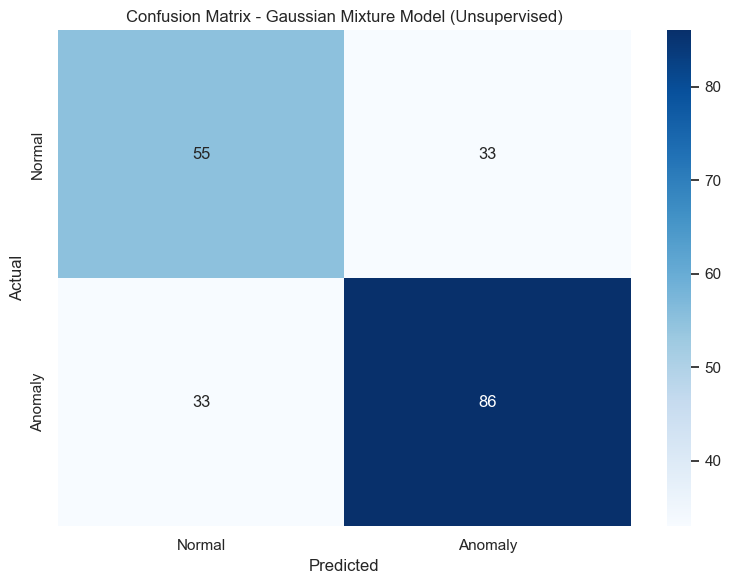

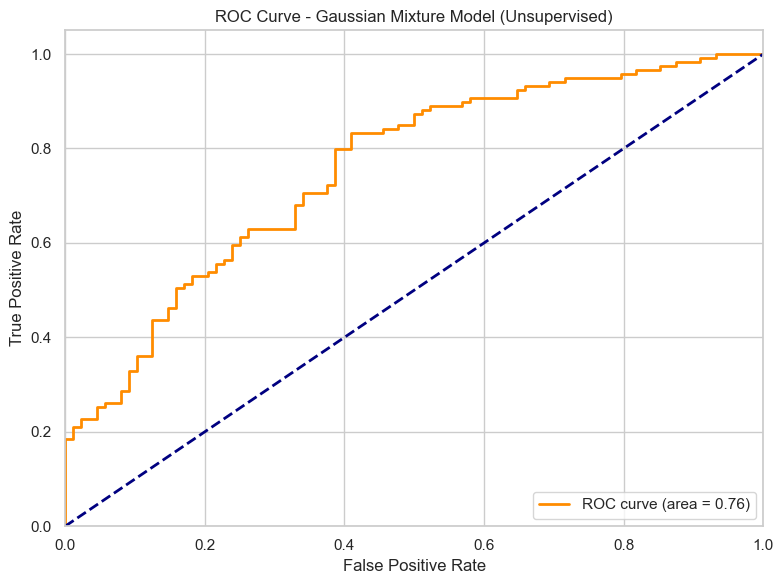

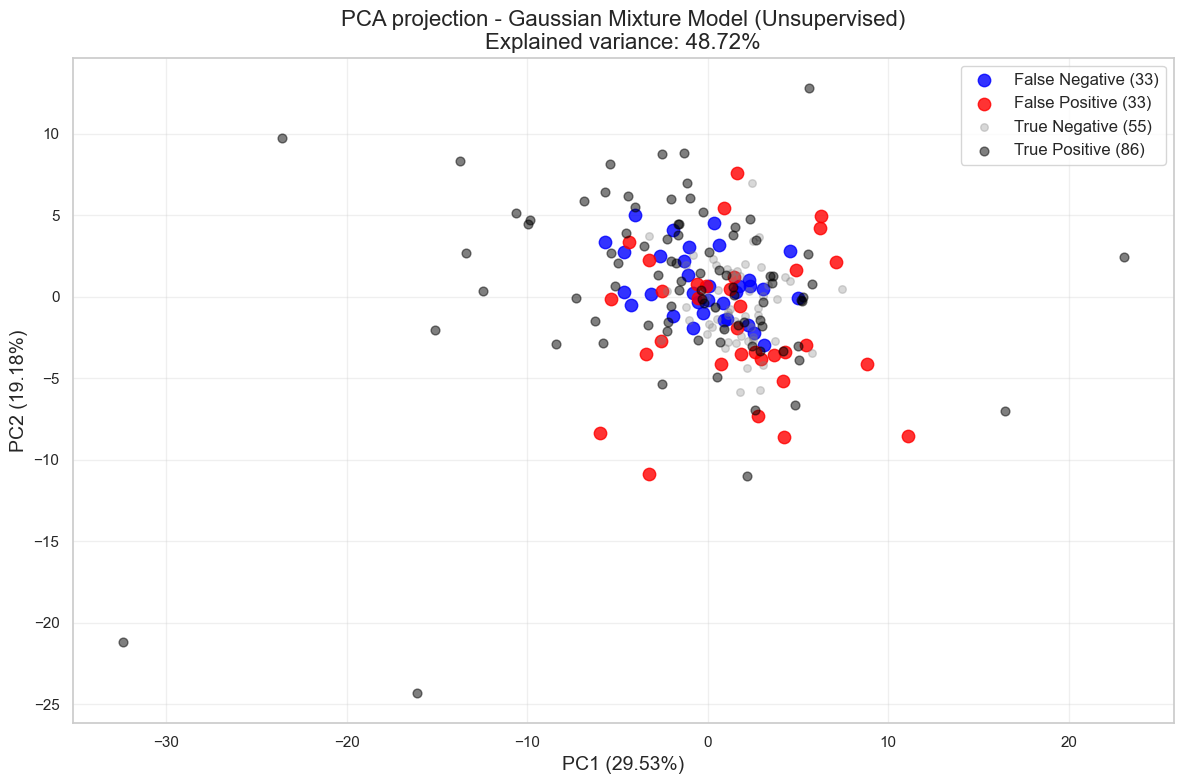

In [28]:
# 2.4 Gaussian Mixture Model - 2 components
from sklearn.mixture import GaussianMixture

print("\nTraining Gaussian Mixture Model...")
gmm_model = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gmm_model.fit(X_train_scaled)

# Predict on test set
gmm_score = -gmm_model.score_samples(X_test_scaled)  # Negative log-likelihood as anomaly score
# For GMM we can use the raw contamination as it doesn't have the same constraints
threshold = np.percentile(gmm_score, 100 * (1 - raw_contamination))
gmm_pred = (gmm_score > threshold).astype(int)

# Evaluate
gmm_metrics = evaluate_model(y_test, gmm_pred, gmm_score, "Gaussian Mixture Model (Unsupervised)")
visualize_pca(X_test_scaled, y_test, gmm_pred, "Gaussian Mixture Model (Unsupervised)")
results.append(("Gaussian Mixture Model (Unsupervised)", *gmm_metrics))


<br>

Let's **summarize unsupervised model and results** - without forgetting the (apparently stupid) initial model.

<br>


### 🧩 Unsupervised Models – Summary Table

<br>

| **Model**                   | **Uses Labels**                      | **Requires Contamination** | **Decision Boundary**         | **Notes** |
|-----------------------------|--------------------------------------|-----------------------------|-------------------------------|-----------|
| **MVG (baseline)**          | ✅ Partial (only for $\varepsilon$)  | ✅ Yes (for threshold)      | Elliptical (parametric)       | Fits only normal class; interpretable and simple |
| Gaussian Mixture (1 comp.)  | ❌ No                                | Optional                    | Elliptical (parametric)       | Equivalent to MVG, but fitted in unsupervised mode |
| Gaussian Mixture (2 comp.)  | ❌ No                                | Optional                    | Soft, multimodal              | Captures more complex “normal” structure |
| Isolation Forest            | ❌ No                                | ✅ Yes                      | Axis-aligned partitions       | Fast, scalable, non-parametric |
| One-Class SVM               | ❌ No                                | ✅ Yes (`nu`)               | Non-linear (kernel-based)     | Flexible but sensitive to `nu` |
| Local Outlier Factor        | ❌ No                                | ✅ Yes                      | Local density comparison      | Needs `novelty=True` to work as a detector |

---

<br>

> 💡 Note: **MVG vs GMM (1 component)**  
> Although mathematically identical  - both estimate $N(\mu, \Sigma)$ -
> they differ in **how they are used**:
> - MVG baseline fits **only normal data** and uses labels to tune the threshold i.e., it's supervised, or semi-supervised if you like.  
> - GMM (1 comp.) fits the **entire dataset blindly**, fully unsupervised.


<br>

In [29]:
# Create a DataFrame with results
results_df = pd.DataFrame(results, columns=['Model', 'Precision', 'Recall', 'F1 Score'])

# Print the results table
print("\nPerformance comparison: Supervised vs Unsupervised")
print(results_df.sort_values('F1 Score', ascending=False).to_string(index=False))

print("\nMemento: Baseline model performance:")
print(f"Precision: {MVG_precision:.4f}")
print(f"Recall: {MVG_recall:.4f}")
print(f"F1 Score: {MVG_f1:.4f}")



Performance comparison: Supervised vs Unsupervised
                                Model  Precision   Recall  F1 Score
  Local Outlier Factor (Unsupervised)   0.673469 0.831933  0.744361
      Isolation Forest (Unsupervised)   0.683824 0.781513  0.729412
         One-Class SVM (Unsupervised)   0.664336 0.798319  0.725191
Gaussian Mixture Model (Unsupervised)   0.722689 0.722689  0.722689
                     SVM (Supervised)   0.884058 0.512605  0.648936
           Random Forest (Supervised)   1.000000 0.025210  0.049180

Memento: Baseline model performance:
Precision: 0.6031
Recall: 0.9832
F1 Score: 0.7476


### 🔍 Autoencoder (Deep Learning) for Anomaly Detection

An **Autoencoder** is a type of **neural network** designed to learn a compressed representation of the data.

It consists of:

- An **encoder**: reduces the input to a lower-dimensional space (the **bottleneck**).
- A **decoder**: reconstructs the input from this compressed version.

The result is a model that learns to **encode the structure of normal data**.

Autoencoders belong to the family of **latent variable models**, just like:

- **PCA** (which finds linear projections).
- **Factor models** (which assume a linear dependence on unobserved factors).

However, an autoencoder can model **highly nonlinear structures** in the data,  
thanks to the expressive power of neural networks.

> The **bottleneck** forces the network to compress information.  
> The model must learn what's essential — and discard the rest.

Some readings:
- [Autoencoders](https://en.wikipedia.org/wiki/Autoencoder).
- [Deep Learning - Autoencoders](https://www.deeplearningbook.org/contents/autoencoders.html).
- [A comprehensive study of auto-encoders for anomaly detection: Efficiency and trade-offs](https://www.sciencedirect.com/science/article/pii/S2666827024000483?dgcid=rss_sd_all)


<br>

 <br>

Below is a schematic view of an Autoencoder: the bottleneck compresses the input into a latent representation, then the decoder tries to reconstruct the original input.


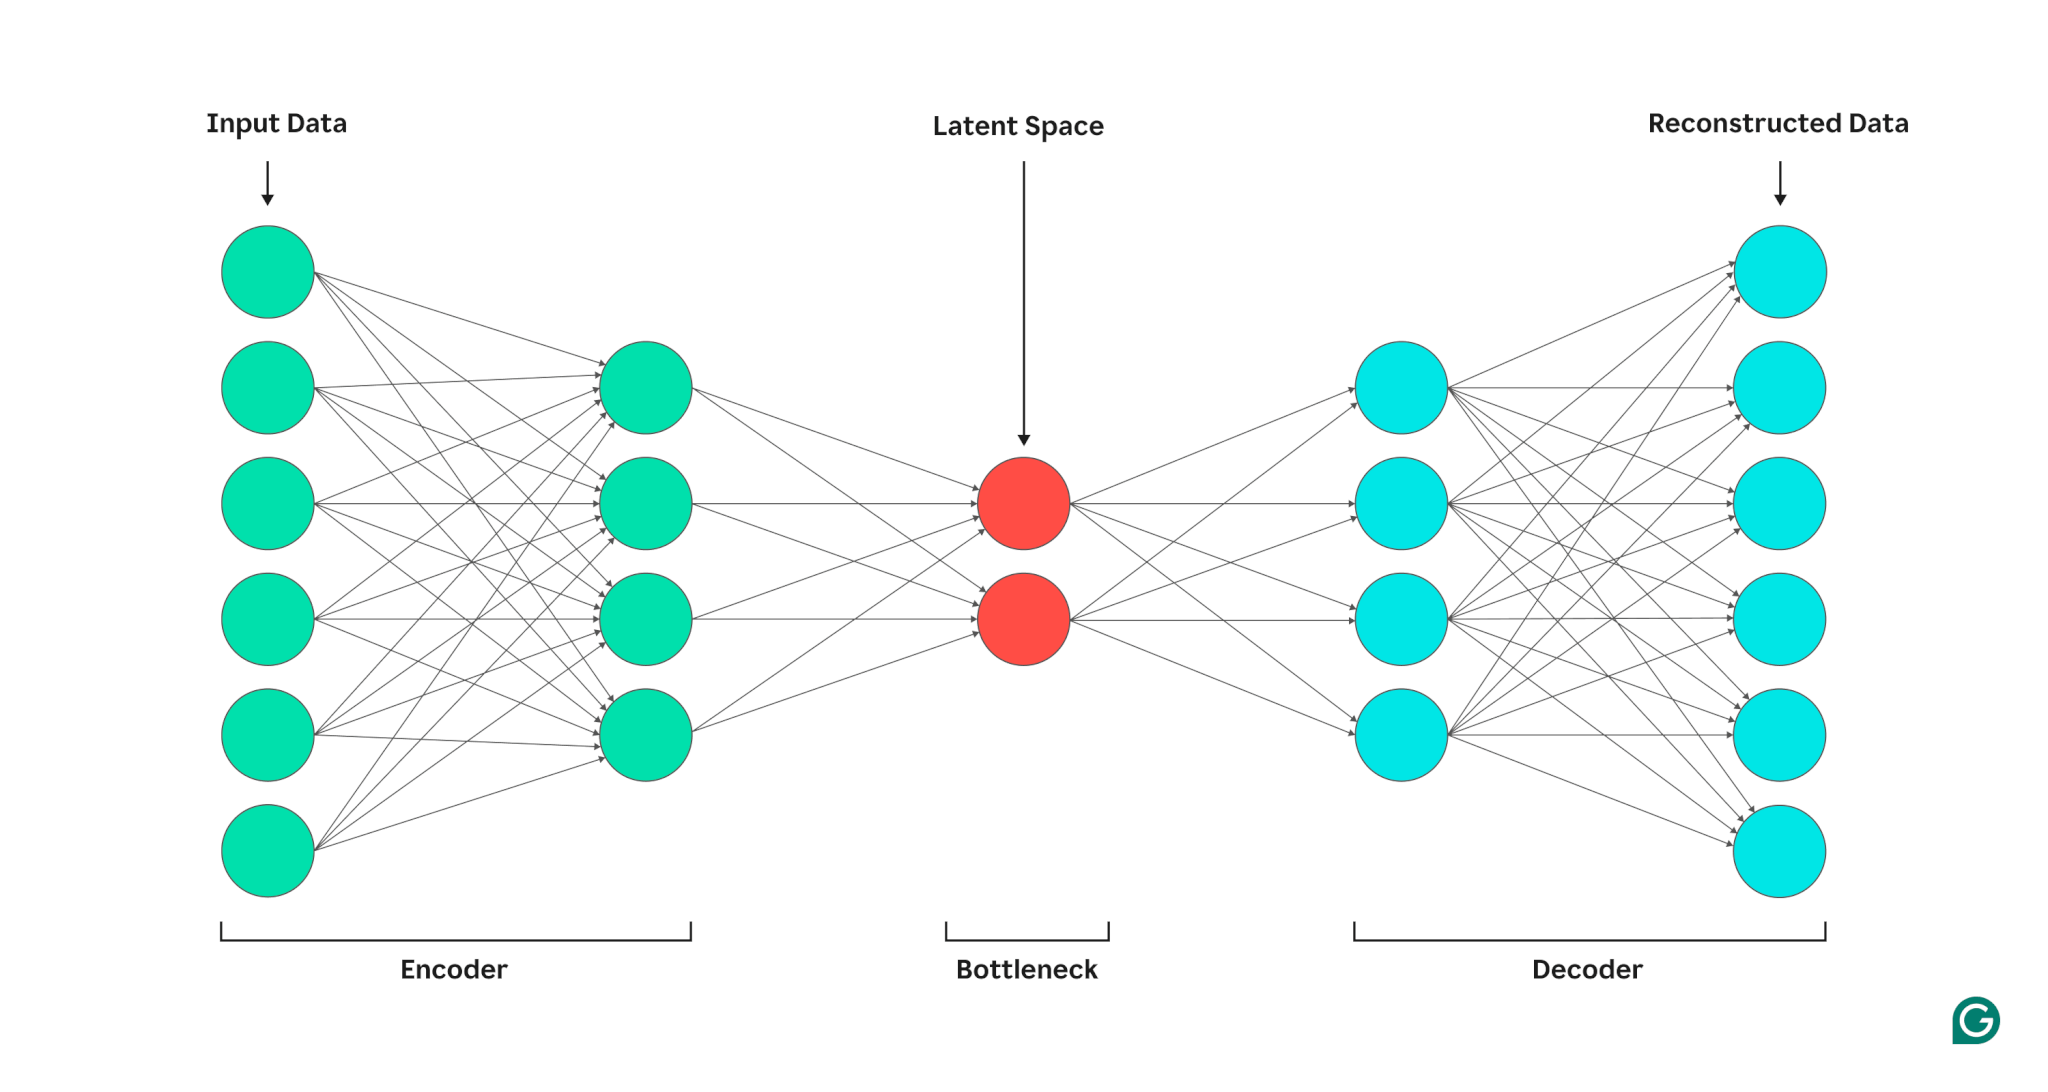


<br>

### 🧠 How does this Autoencoder work?

Unlike the other models we used, the autoencoder does **not** output a label or probability: It learns to **reconstruct the input** as accurately as possible, based on the structure it observes in the data.

>If a point is reconstructed **poorly**, we assume it's **anomalous**.  
>If it's reconstructed **well**, we assume it's **normal**.

This method focuses again - like the Gaussian baseline model - on modeling *normality* — just with a more flexible model: the difference is that the definition of “normal” is now learned via Deep Learning, and anomalies are detected based on how badly they are reconstructed — that is, by their reconstruction error.

This approach is:
- **Unsupervised during training**: we don’t use labels at all.
- **Supervised for threshold tuning**: we still use the validation set to set the anomaly threshold (just like before, with the Gaussian baseline model).

<br>

### 🧠 Neural Network architecture

More precisely, the Autoencoder is a symmetric feedforward Neural Network with two parts:

- The **encoder**, which compresses the input into a lower-dimensional representation (the **latent space**).
- The **decoder**, which tries to reconstruct the original input from this compressed code.

Both parts are trained **jointly** by minimizing the reconstruction error  
(we use **Mean Squared Error**, MSE, as the loss function).

We also use techniques like:

- **Batch Normalization**: to stabilize training.
- **Dropout**: to reduce overfitting.


In [30]:
# 3.  Deep Learning methods: Autoencoder
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Convert data to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled).to(device)
X_cv_tensor = torch.FloatTensor(X_cv_scaled).to(device)
X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)

# Create DataLoaders
batch_size = 64
train_dataset = TensorDataset(X_train_tensor, X_train_tensor)  # Input = Output for autoencoder
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Define the Autoencoder architecture
class Autoencoder(nn.Module):
    def __init__(self, input_dim, encoding_dim=16):
        super(Autoencoder, self).__init__()

        # Calculate layer sizes for a gradually decreasing architecture
        layer1_size = input_dim // 2
        layer2_size = layer1_size // 2

        # Ensure minimum size
        layer1_size = max(layer1_size, encoding_dim * 2)
        layer2_size = max(layer2_size, encoding_dim)

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, layer1_size),
            nn.BatchNorm1d(layer1_size),
            nn.ReLU(True),
            nn.Dropout(0.2),
            nn.Linear(layer1_size, layer2_size),
            nn.BatchNorm1d(layer2_size),
            nn.ReLU(True),
            nn.Dropout(0.2),
            nn.Linear(layer2_size, encoding_dim),
            nn.BatchNorm1d(encoding_dim),
            nn.ReLU(True)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, layer2_size),
            nn.BatchNorm1d(layer2_size),
            nn.ReLU(True),
            nn.Dropout(0.2),
            nn.Linear(layer2_size, layer1_size),
            nn.BatchNorm1d(layer1_size),
            nn.ReLU(True),
            nn.Dropout(0.2),
            nn.Linear(layer1_size, input_dim),
            nn.Tanh()  # Output activation to match standardized data range
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

    def encode(self, x):
        return self.encoder(x)

# Get input dimension from data
input_dim = X_train_scaled.shape[1]
print(f"Input dimension: {input_dim}")

# Create the autoencoder model
encoding_dim = min(16, input_dim // 4)  # Adjust encoding dimension based on input size
model = Autoencoder(input_dim, encoding_dim).to(device)
print(f"Encoding dimension: {encoding_dim}")
print(model)

# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# Training function
def train_autoencoder(model, train_loader, num_epochs=100, patience=10):
    # For early stopping
    best_loss = float('inf')
    no_improve_epochs = 0

    # For plotting
    train_losses = []

    print("Training autoencoder...")
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for data, _ in train_loader:
            # Zero the gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(data)
            loss = criterion(outputs, data)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * data.size(0)

        # Calculate epoch loss
        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)

        # Print progress
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.6f}')

        # Early stopping
        if epoch_loss < best_loss:
            best_loss = epoch_loss
            no_improve_epochs = 0
            # Save the best model
            torch.save(model.state_dict(), 'best_autoencoder.pth')
        else:
            no_improve_epochs += 1
            if no_improve_epochs >= patience:
                print(f'Early stopping at epoch {epoch+1}')
                break

    # Load the best model
    model.load_state_dict(torch.load('best_autoencoder.pth'))

    # Plot training loss
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses)
    plt.title('Autoencoder Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.grid(True)
    plt.show()

    return model


Using device: cpu
Input dimension: 42
Encoding dimension: 10
Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=42, out_features=21, bias=True)
    (1): BatchNorm1d(21, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=21, out_features=10, bias=True)
    (5): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=10, out_features=10, bias=True)
    (9): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=10, out_features=10, bias=True)
    (1): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=10, out_features=2

### 🏋️‍♀️ Training with Early Stopping

As we have seen before, we train the model on **normal data only**, using reconstruction loss as the objective.  
To avoid overfitting and speed up training, we use **early stopping**: if the loss doesn't improve after a number of epochs, we stop the training.

We store the model with the **lowest validation loss**, not the final epoch.  

---

<br>

Once trained, the autoencoder can be used as follows:

1. Feed the input to the model.
2. Compute the **reconstruction error** for each point.
3. Use a **threshold** on the reconstruction error to classify anomalies.

We select the threshold by looking at the reconstruction errors on the cross-validation set and using the **contamination rate** (i.e., percentage of anomalies) to determine the cutoff.  

<br>

Training autoencoder...
Epoch 10/200, Loss: 0.942328
Epoch 20/200, Loss: 0.844345
Epoch 30/200, Loss: 0.798002
Epoch 40/200, Loss: 0.771717
Epoch 50/200, Loss: 0.738854
Epoch 60/200, Loss: 0.731596
Epoch 70/200, Loss: 0.737884
Epoch 80/200, Loss: 0.730934
Epoch 90/200, Loss: 0.714550
Epoch 100/200, Loss: 0.721247
Epoch 110/200, Loss: 0.715901
Epoch 120/200, Loss: 0.717926
Epoch 130/200, Loss: 0.706587
Epoch 140/200, Loss: 0.714598
Epoch 150/200, Loss: 0.705238
Epoch 160/200, Loss: 0.704636
Epoch 170/200, Loss: 0.699836
Early stopping at epoch 177


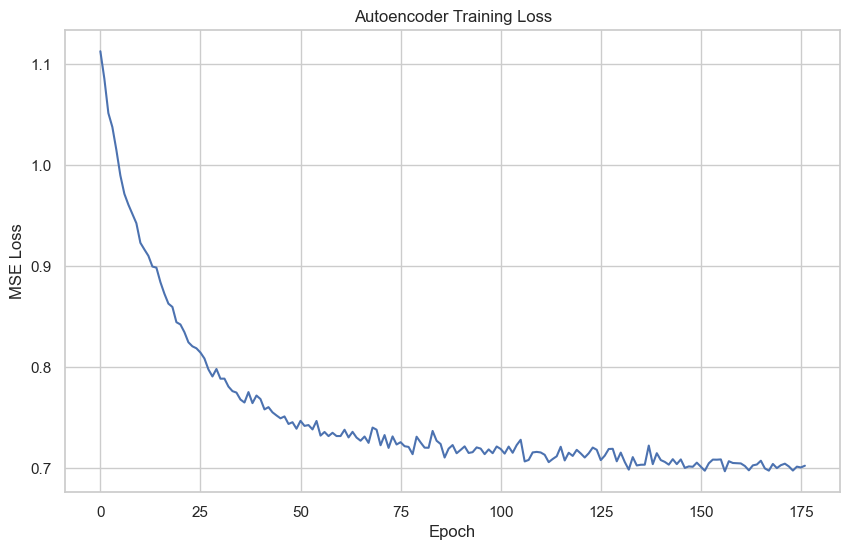

Contamination rate from cross-validation set: 0.5756


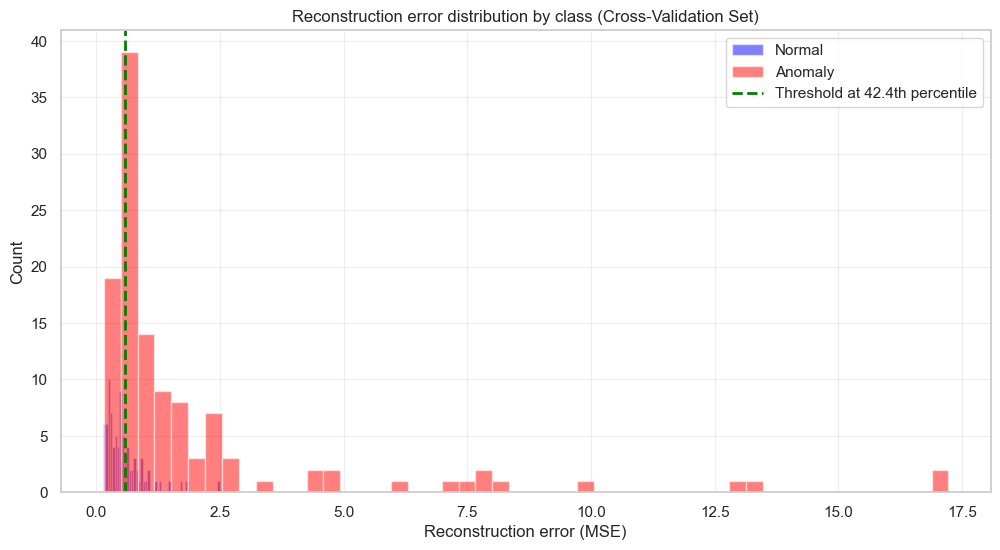

Threshold for anomaly detection: 0.585838


In [31]:
# Train the autoencoder
model = train_autoencoder(model, train_loader, num_epochs=200, patience=20)

# Function to compute reconstruction error
def compute_reconstruction_error(model, data_tensor):
    model.eval()
    with torch.no_grad():
        reconstructions = model(data_tensor)
        # Compute MSE for each sample
        mse = ((reconstructions - data_tensor) ** 2).mean(dim=1).cpu().numpy()
    return mse

# Compute reconstruction errors
train_errors = compute_reconstruction_error(model, X_train_tensor)
cv_errors = compute_reconstruction_error(model, X_cv_tensor)
test_errors = compute_reconstruction_error(model, X_test_tensor)

# Determine threshold for anomaly detection using cross-validation set
# We'll use the contamination rate from the cross-validation set
contamination = np.mean(y_cross_val)
print(f"Contamination rate from cross-validation set: {contamination:.4f}")

# Find the threshold that best separates normal and anomalous examples in the CV set
cv_errors_normal = cv_errors[y_cross_val == 0]
cv_errors_anomaly = cv_errors[y_cross_val == 1]

# Plot histogram of reconstruction errors by class
plt.figure(figsize=(12, 6))
plt.hist(cv_errors_normal, bins=50, alpha=0.5, label='Normal', color='blue')
plt.hist(cv_errors_anomaly, bins=50, alpha=0.5, label='Anomaly', color='red')
plt.axvline(x=np.percentile(cv_errors, 100 * (1 - contamination)),
            color='green', linestyle='dashed', linewidth=2,
            label=f'Threshold at {100 * (1 - contamination):.1f}th percentile')
plt.title('Reconstruction error distribution by class (Cross-Validation Set)')
plt.xlabel('Reconstruction error (MSE)')
plt.ylabel('Count')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Set threshold at the percentile corresponding to the contamination rate
threshold = np.percentile(cv_errors, 100 * (1 - contamination))
print(f"Threshold for anomaly detection: {threshold:.6f}")

# Make predictions on test set
y_pred = (test_errors > threshold).astype(int)



### Evaluation metrics

 In addition to the usual metrics, we show the plot with the **reconstruction error** for each point in the test set.

- Each dot is a data point.
- Color indicates the true label:  
  - 🔵 Blue for **normal**  
  - 🔴 Red for **anomalies**
- The green dashed line is the **threshold** used to classify a point as anomalous.

What does this chart tell us?

- Samples **above the threshold** are predicted as anomalies
- Samples **below** are classified as normal
- We can directly spot:
  - **False positives**: blue dots above the line
  - **False negatives**: red dots below the line

This is a simple but effective diagnostic tool to evaluate the classifier's behavior **based on its internal logic** (reconstruction error).  
It's also a sanity check: are anomalies really harder to reconstruct?

<br>

---

<br>

### 📊 A note on visualizing results with PCA and latent space

After training the autoencoder, we extract the **internal (latent) representation** of the test set.  
This is the output of the encoder — a compressed and abstract version of each input.

To make it visible, we apply **PCA** to this latent space.

Why?

- The latent space has too many dimensions to visualize.
- PCA gives us the two principal directions where the model encodes most variation.
- We use one **latent-variable model (PCA)** to inspect another **latent-variable model (the autoencoder)**

> 🌀 Like in the movie *Inception*, this is a model **within** a model.  
> 🧠 We *dive into the mind of the Autoencoder* to see how it thinks —  
> not through raw inputs, but through how it compresses and reconstructs the world. In order to do that, we need PCA to simplify the situation.


We then:

- Color the points based on **true vs predicted anomalies**.
- Explore the **structure of the latent space**.
- Visualize **where the reconstruction error is high**, and how it affects anomaly decisions.

These plots are not just for show: they provide some **qualitative insight** into the model’s logic, blind spots, and failure modes.

<br>


Autoencoder performance:
Precision: 0.6960
Recall: 0.7311
F1 Score: 0.7131


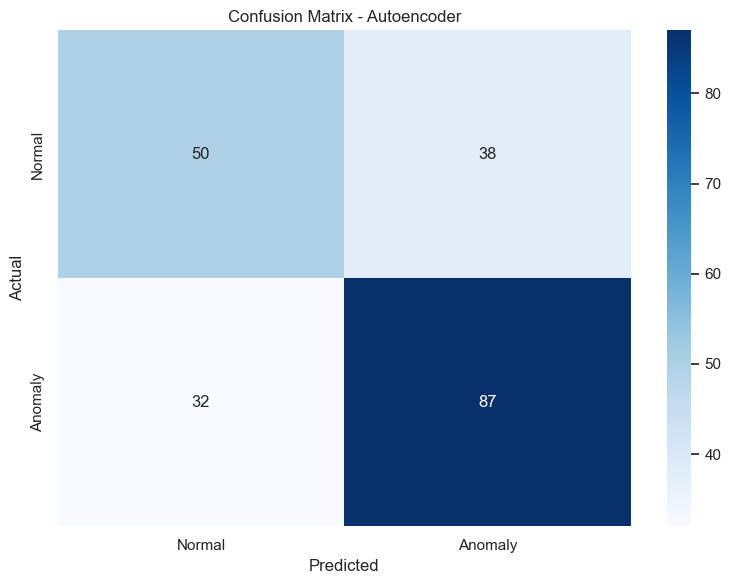

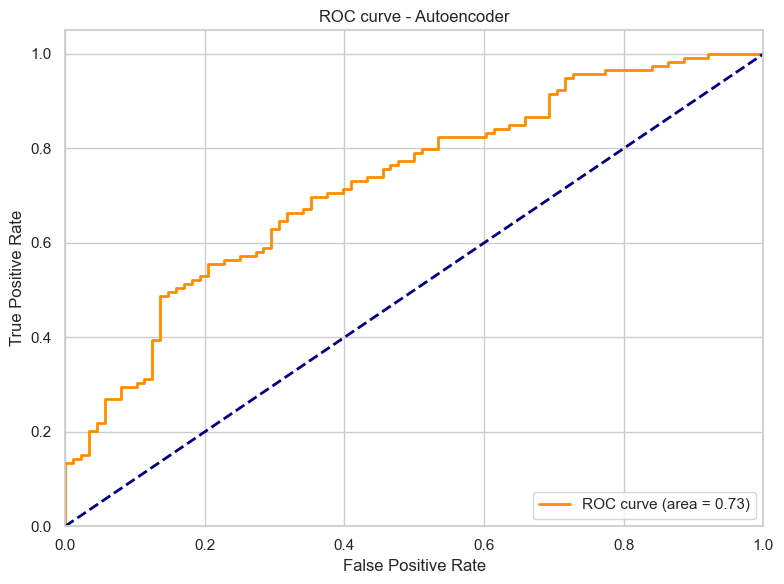

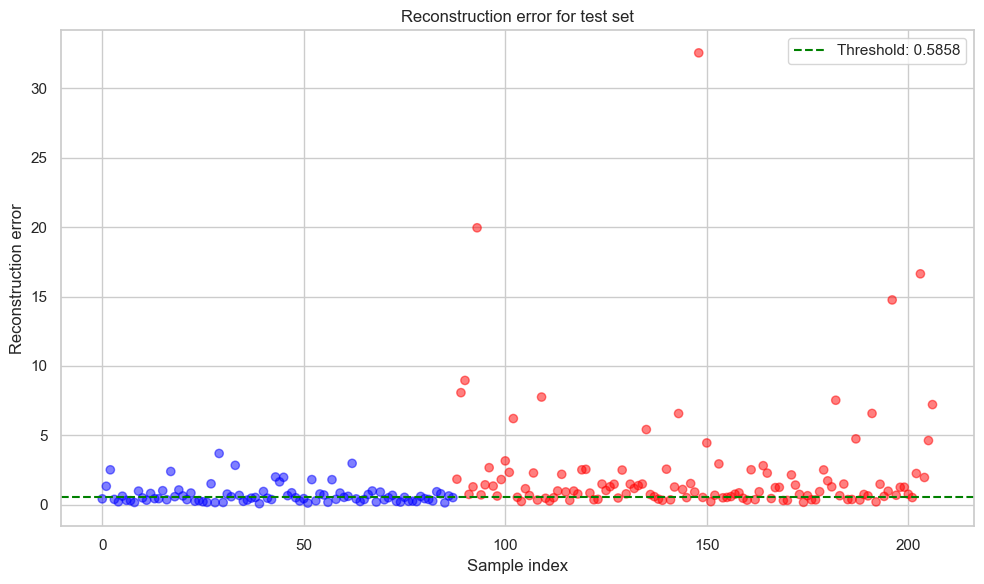

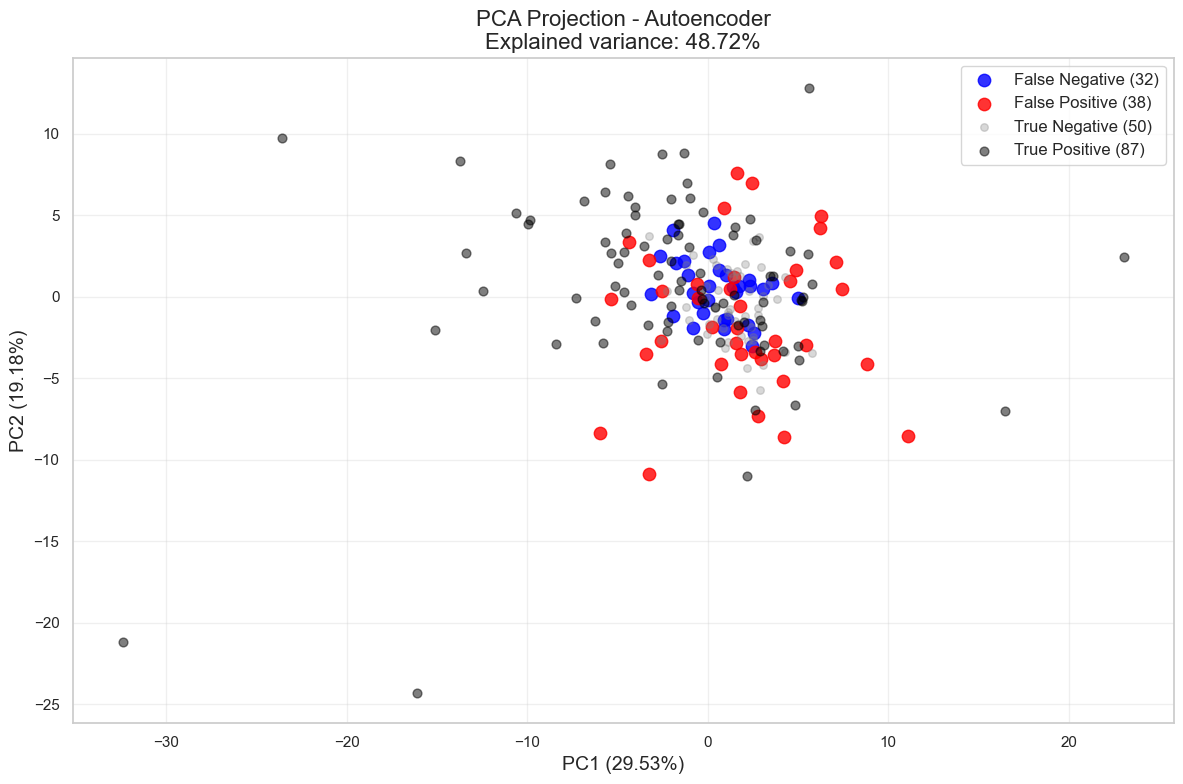

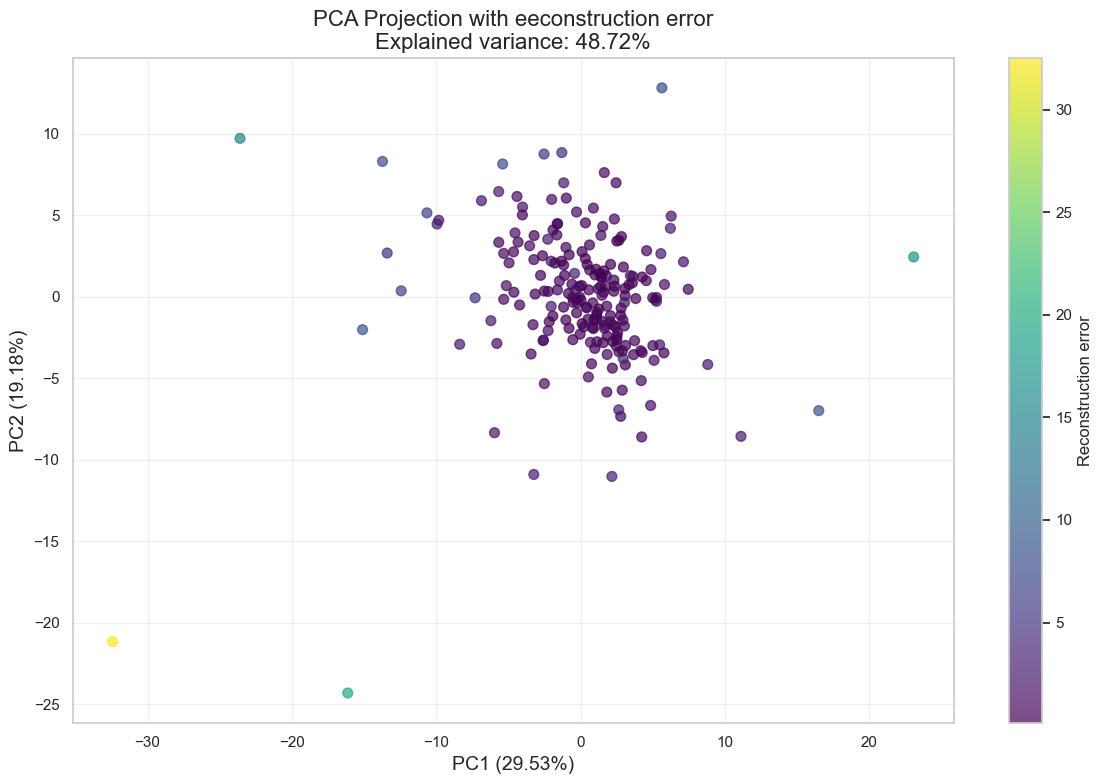

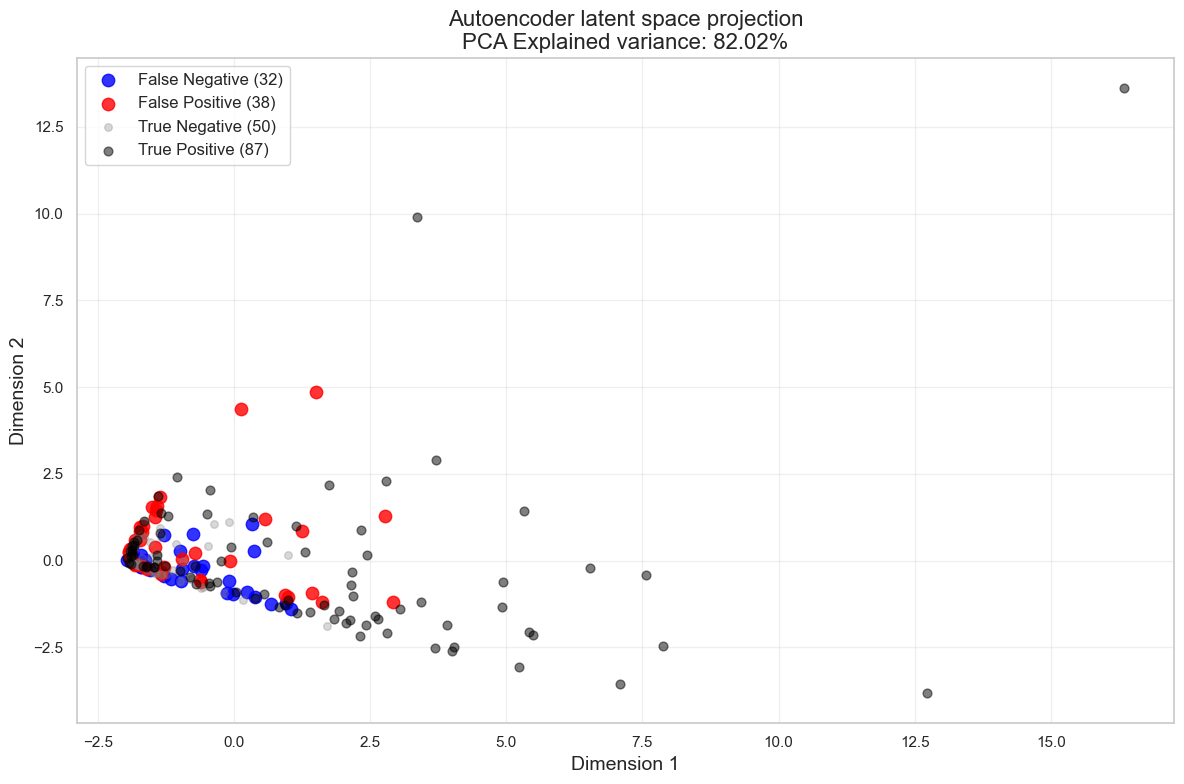

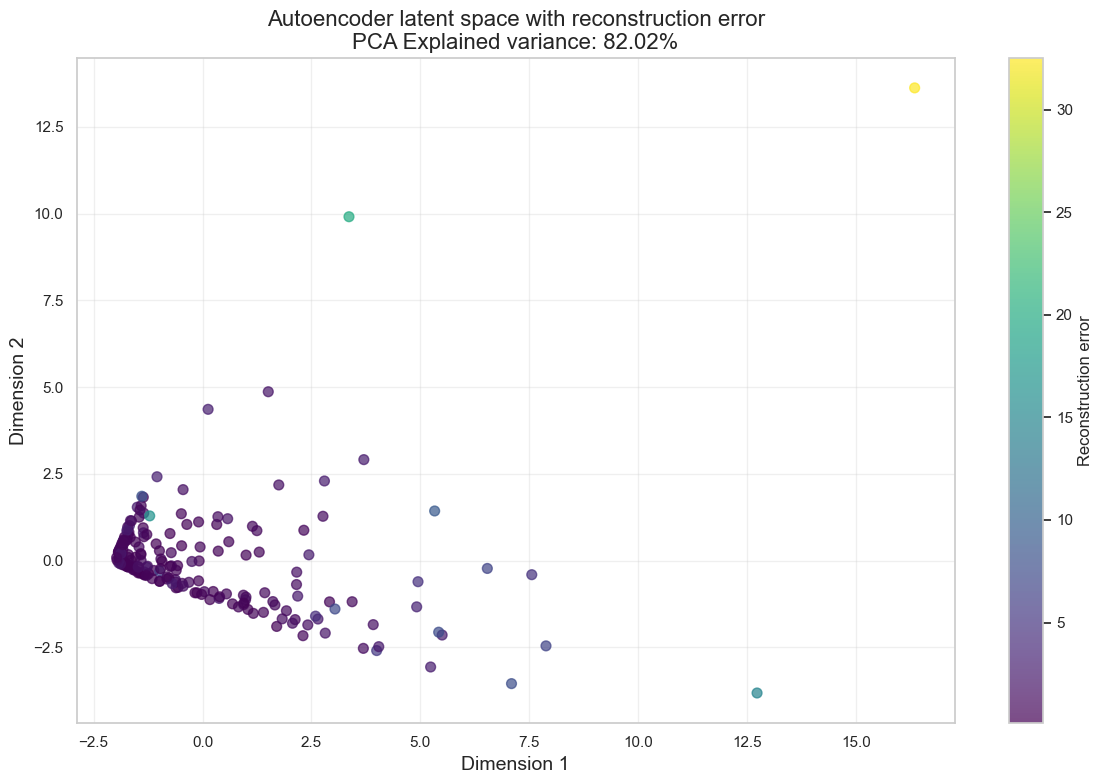


Performance comparison:
      Model  Precision   Recall  F1 Score
Autoencoder      0.696 0.731092  0.713115

Memento: Baseline model performance:
Precision: 0.6031
Recall: 0.9832
F1 Score: 0.7476


In [32]:
# Evaluate the autoencoder model
def evaluate_autoencoder(y_true, y_pred, reconstruction_errors, threshold):
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print("\nAutoencoder performance:")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Anomaly'],
                yticklabels=['Normal', 'Anomaly'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix - Autoencoder')
    plt.tight_layout()
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, reconstruction_errors)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC curve - Autoencoder')
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    # Visualize reconstruction error distribution
    plt.figure(figsize=(10, 6))
    plt.scatter(range(len(reconstruction_errors)),
                reconstruction_errors,
                c=['blue' if label == 0 else 'red' for label in y_true],
                alpha=0.5)
    plt.axhline(y=threshold, color='green', linestyle='--', label=f'Threshold: {threshold:.4f}')
    plt.title('Reconstruction error for test set')
    plt.xlabel('Sample index')
    plt.ylabel('Reconstruction error')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return precision, recall, f1, roc_auc


# Visualize in PCA space
def visualize_autoencoder_pca(X, y_true, y_pred, reconstruction_errors, threshold):
    # Apply PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    # Create a DataFrame for plotting
    pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
    pca_df['Actual'] = y_true
    pca_df['Predicted'] = y_pred
    pca_df['Error'] = reconstruction_errors

    # Create classification categories
    pca_df['Category'] = 'Unknown'
    pca_df.loc[(y_true == 0) & (y_pred == 0), 'Category'] = 'True Negative'
    pca_df.loc[(y_true == 0) & (y_pred == 1), 'Category'] = 'False Positive'
    pca_df.loc[(y_true == 1) & (y_pred == 0), 'Category'] = 'False Negative'
    pca_df.loc[(y_true == 1) & (y_pred == 1), 'Category'] = 'True Positive'

    # Calculate explained variance
    explained_variance = pca.explained_variance_ratio_
    total_variance = sum(explained_variance)

    # Plot
    plt.figure(figsize=(12, 8))

    # Define colors and sizes
    colors = {'True Negative': 'gray', 'True Positive': 'black',
              'False Positive': 'red', 'False Negative': 'blue'}
    alphas = {'True Negative': 0.3, 'True Positive': 0.5,
              'False Positive': 0.8, 'False Negative': 0.8}
    sizes = {'True Negative': 30, 'True Positive': 40,
             'False Positive': 80, 'False Negative': 80}

    # Plot each category
    for category, group in pca_df.groupby('Category'):
        plt.scatter(group['PC1'], group['PC2'],
                    color=colors[category],
                    alpha=alphas[category],
                    s=sizes[category],
                    label=f"{category} ({len(group)})")

    plt.title(f'PCA Projection - Autoencoder\nExplained variance: {total_variance:.2%}', fontsize=16)
    plt.xlabel(f'PC1 ({explained_variance[0]:.2%})', fontsize=14)
    plt.ylabel(f'PC2 ({explained_variance[1]:.2%})', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

    # Plot with reconstruction error as color intensity
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'],
                c=pca_df['Error'],
                cmap='viridis',
                alpha=0.7,
                s=50)
    plt.colorbar(scatter, label='Reconstruction error')
    plt.title(f'PCA Projection with eeconstruction error\nExplained variance: {total_variance:.2%}', fontsize=16)
    plt.xlabel(f'PC1 ({explained_variance[0]:.2%})', fontsize=14)
    plt.ylabel(f'PC2 ({explained_variance[1]:.2%})', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Visualize in latent space
    model.eval()
    with torch.no_grad():
        latent_vectors = model.encode(X_test_tensor).cpu().numpy()

    # Apply PCA if the latent space has more than 2 dimensions
    if latent_vectors.shape[1] > 2:
        pca_latent = PCA(n_components=2)
        latent_2d = pca_latent.fit_transform(latent_vectors)
        explained_var = pca_latent.explained_variance_ratio_
        total_var = sum(explained_var)
        title_suffix = f"\nPCA Explained variance: {total_var:.2%}"
    else:
        latent_2d = latent_vectors
        title_suffix = ""

    # Create DataFrame for latent space visualization
    latent_df = pd.DataFrame(latent_2d, columns=['Dim1', 'Dim2'])
    latent_df['Actual'] = y_test
    latent_df['Predicted'] = y_pred
    latent_df['Error'] = reconstruction_errors

    # Create classification categories
    latent_df['Category'] = 'Unknown'
    latent_df.loc[(y_true == 0) & (y_pred == 0), 'Category'] = 'True Negative'
    latent_df.loc[(y_true == 0) & (y_pred == 1), 'Category'] = 'False Positive'
    latent_df.loc[(y_true == 1) & (y_pred == 0), 'Category'] = 'False Negative'
    latent_df.loc[(y_true == 1) & (y_pred == 1), 'Category'] = 'True Positive'

    # Plot in latent space by category
    plt.figure(figsize=(12, 8))
    for category, group in latent_df.groupby('Category'):
        plt.scatter(group['Dim1'], group['Dim2'],
                    color=colors[category],
                    alpha=alphas[category],
                    s=sizes[category],
                    label=f"{category} ({len(group)})")

    plt.title(f'Autoencoder latent space projection{title_suffix}', fontsize=16)
    plt.xlabel('Dimension 1', fontsize=14)
    plt.ylabel('Dimension 2', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

    # Plot in latent space with reconstruction error as color
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(latent_df['Dim1'], latent_df['Dim2'],
                c=latent_df['Error'],
                cmap='viridis',
                alpha=0.7,
                s=50)
    plt.colorbar(scatter, label='Reconstruction error')
    plt.title(f'Autoencoder latent space with reconstruction error{title_suffix}', fontsize=16)
    plt.xlabel('Dimension 1', fontsize=14)
    plt.ylabel('Dimension 2', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Evaluate autoencoder performance
ae_metrics = evaluate_autoencoder(y_test, y_pred, test_errors, threshold)

# Visualize the autoencoder results
visualize_autoencoder_pca(X_test_scaled, y_test, y_pred, test_errors, threshold)

# Compare with previous models
# Add autoencoder results to the comparison DataFrame
results_df = pd.DataFrame([
    ("Autoencoder", ae_metrics[0], ae_metrics[1], ae_metrics[2])
], columns=['Model', 'Precision', 'Recall', 'F1 Score'])

# Print the results table
print("\nPerformance comparison:")
print(results_df.sort_values('F1 Score', ascending=False).to_string(index=False))

print("\nMemento: Baseline model performance:")
print(f"Precision: {MVG_precision:.4f}")
print(f"Recall: {MVG_recall:.4f}")
print(f"F1 Score: {MVG_f1:.4f}")


### 📈 Feature importance

We estimate feature importance by **zeroing out** each feature (one at a time) and measuring how much the **reconstruction error increases**.

This tells us which variables are most critical to the model's understanding of “normality.”  

> Useful for interpretability — especially in financial or operational risk settings.

<br>

C:\Users\vitto\AppData\Local\Temp\ipykernel_23940\4164719277.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='viridis')


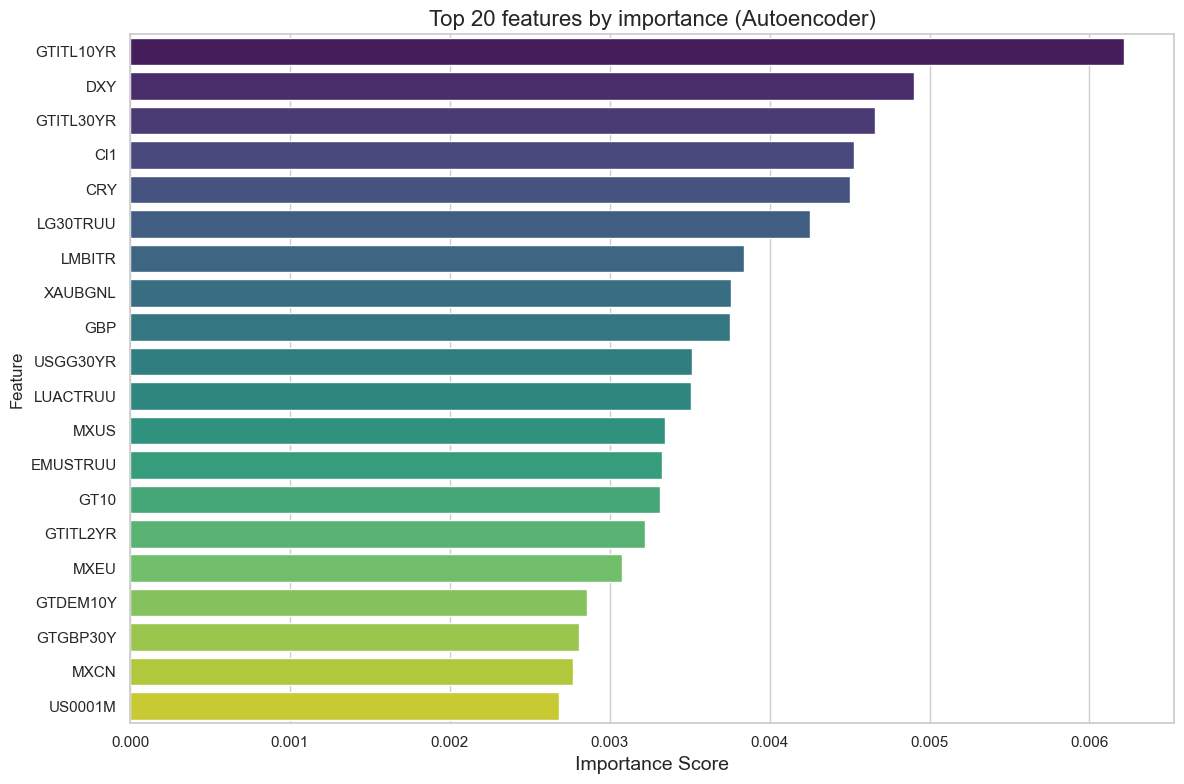


Top 10 most important features:
      Feature  Importance
31  GTITL10YR    0.006218
3         DXY    0.004902
33  GTITL30YR    0.004657
2         Cl1    0.004530
1         CRY    0.004505
9    LG30TRUU    0.004251
10     LMBITR    0.003838
22    XAUBGNL    0.003760
5         GBP    0.003754
39   USGG30YR    0.003517


In [33]:
# Feature importance analysis using the autoencoder
def analyze_feature_importance(model, X_tensor, feature_names):
    """
    Analyze feature importance by measuring the impact of each feature on reconstruction error
    """
    model.eval()
    n_features = X_tensor.shape[1]
    importance_scores = []

    # Original reconstruction error
    with torch.no_grad():
        original_output = model(X_tensor)
        original_error = ((original_output - X_tensor) ** 2).mean(dim=0).cpu().numpy()

    # Measure impact of perturbing each feature
    for i in range(n_features):
        # Create a copy with the i-th feature perturbed
        perturbed_input = X_tensor.clone()
        perturbed_input[:, i] = torch.zeros_like(perturbed_input[:, i])

        with torch.no_grad():
            perturbed_output = model(perturbed_input)
            perturbed_error = ((perturbed_output - X_tensor) ** 2).mean(dim=0).cpu().numpy()

        # Importance is the increase in error when the feature is perturbed
        feature_importance = np.mean(perturbed_error - original_error)
        importance_scores.append(feature_importance)

    # Create DataFrame with feature importance
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance_scores
    })

    # Sort by importance
    importance_df = importance_df.sort_values('Importance', ascending=False)

    # Plot top 20 features
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='viridis')
    plt.title('Top 20 features by importance (Autoencoder)', fontsize=16)
    plt.xlabel('Importance Score', fontsize=14)
    plt.tight_layout()
    plt.show()

    return importance_df

# Analyze feature importance
if 'stationary_df' in locals() and hasattr(stationary_df, 'columns'):
    feature_names = stationary_df.columns
    feature_importance = analyze_feature_importance(model, X_test_tensor, feature_names)
    print("\nTop 10 most important features:")
    print(feature_importance.head(10))


<br>

This notebook you've just completed provides a good foundation for comparing anomaly detection techniques.

Now it's your turn to go further.

There are a lot of things you can do. Don't do them all, I'll just give you some ideas... Do reasonable things.

<br>

---

## HINTs

### 1. Improve the existing models
- You can fine-tune them using hyperparameter optimization libraries such as **[Optuna](https://www.google.com/url?q=https%3A%2F%2Foptuna.readthedocs.io%2Fen%2Fstable%2Findex.html%23)**, or try different scalers, data splits, loss functions, etc.  
- Once optimized, compare them on the same test set using the existing evaluation pipeline. It is also interesting to use synthetic data to compare different models.
- Also, explore **explainability**: SHAP, LIME, or [Gradient-based methods](https://pytorch.org/tutorials/beginner/introyt/captumyt.html) for neural models, but you already know.

---

### 🧪 2. Explore alternative models

Here are a few suggestions, of varying difficulty:

#### 📌 Variational Autoencoder (VAE)
- Adds a **Gaussian prior** to the latent space.
- Uses a loss function with two terms: reconstruction + **KL divergence**.
- Encourages **smoother generalization** and **better anomaly scoring**.
- Can also be used to **generate synthetic samples** of normal data.
- See:
  - [An Introduction to Variational Autoencoders](https://arxiv.org/abs/1906.02691).
  - [What is a variational autoencoder?](https://www.ibm.com/think/topics/variational-autoencoder).
  - [Deep Learning - Autoencoders](https://www.deeplearningbook.org/contents/autoencoders.html).

#### 📌 PCA and Linear Autoencoders
- PCA is equivalent to a **linear autoencoder** with no activation function.
- The reconstruction error can be used as anomaly score.
- Consider extensions, e.g., **[Kernel PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.KernelPCA.html#sklearn.decomposition.KernelPCA)**, or **[Sparse PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.SparsePCA.html#sklearn.decomposition.SparsePCA)**.

#### 📌 [Isolation Mondrian Forest](https://paperswithcode.com/paper/isolation-mondrian-forest-for-batch-and)
- An enhancement of Isolation Forest with better robustness and generalization.

#### 📌 Gradient Boosted Trees (e.g., XGBoost)
- Try with imbalanced settings and anomaly-aware loss functions.

#### 📌 COPOD (Copula-Based Outlier Detection)
- A **density-based** method that models multivariate dependencies via [Copulas](https://en.wikipedia.org/wiki/Copula_(statistics)) - see also [A Practical Introduction to Copula](https://hudson-and-thames-arbitragelab.readthedocs-hosted.com/en/latest/copula_approach/copula_brief_intro.html).  
- More flexible than MVG and even Local Outlier Factor.
- For a good Python library, see [COPOD: Copula-Based Outlier Detection](https://arxiv.org/abs/2009.09463) and for the library I suggest [PyOD](https://pyod.readthedocs.io/en/latest/pyod.models.html#pyod.models.copod.COPOD)

#### 📌 [LSTM](https://en.wikipedia.org/wiki/Long_short-term_memory) Autoencoder
- Useful for time series: captures temporal dependencies.
- Requires reshaping the data into sequences.
- See for example [A Gentle Introduction to LSTM Autoencoders](https://machinelearningmastery.com/lstm-autoencoders/),

#### 📌 [GAN](https://en.wikipedia.org/wiki/Generative_adversarial_network) for Anomaly Detection
- Use the **discriminator** to detect whether a point is "realistic".
- Similar principle to an autoencoder, but adversarial.
- Hard.
- See [A Survey on GANs for Anomaly Detection](https://arxiv.org/pdf/1906.11632).


>In general, **the library [PyOD](https://pyod.readthedocs.io/en/latest/)** includes a great variety of Anomaly Detection models, and the implementation in PyOD is efficient and well tested. It follows scikit-learn conventions (fit, predict, etc.). Many of the models mentioned, and many more, can be found there.So, enjoy...

---

### 🧭 3. Add financial domain knowledge

Machine Learning models can be greatly improved by embedding financial structure, i.e. business/financial knowledge:

- **Feature selection** by asset class, instrument type, or region.
- **Feature engineering** via statistical aggregates or dimensionality reduction (e.g. PCA per cluster of correlated assets).
- **Anomaly interpretation** based on macro/market context (e.g. clustering anomalies by cause).

---

### 🎯 4. Ensemble methods & uncertainty estimation

I know I'm repetitive. But. Another powerful direction is to build **an ensemble of models** (or model averaging). For instance:

- Combine **different anomaly detectors** (e.g. Autoencoder + LOF + Isolation Forest).
- Or use an ensemble of **Autoencoders** with different initializations (they provide different results). You can:
  - Average their anomaly scores
  - Or use their **disagreement (variance)** as a **proxy for predictive uncertainty**: models that disagree on a sample may be revealing an ambiguous or borderline case – which could be flagged for deeper analysis.

The ensemble approach helps mitigate overfitting and improves **robustness to noise** and model misspecification.

---

### 🔁 5. Semi-Supervised Anomaly Detection and Active Learning

When labels are scarce or expensive to obtain — a common situation in finance — it can be useful to explore **semi-supervised learning**, where:

- You start from a small set of labeled anomalies (or normal points).
- And propagate this information to the unlabeled data using **label propagation** or **graph-based methods**.

Another promising avenue is **[Active Learning](https://en.wikipedia.org/wiki/Active_learning_(machine_learning))**, where the model can **query** for the label of the most uncertain points — typically the ones near the decision boundary or where models disagree. So if the model is undecided, a Sapiens (human in the loop) decides.

This is especially relevant when a domain expert (e.g., a risk officer - you can assume you are a team of risk managers) can confirm whether specific events are truly anomalous. And the model learns.

📚 Some reading:

- [Chapelle, Scholkopf, Zien (2006)](https://www.oxfordreference.com/view/10.1093/acref/9780199676844.001.0001/acref-9780199676844): *Semi-Supervised Learning* — the classic reference on the topic  
- [Budd et al. (2021)](https://arxiv.org/abs/1906.10685): *A Survey on Active Learning and Human-in-the-Loop for Anomaly Detection* — a modern overview

These approaches allow us to **embed expert knowledge into the model loop** without requiring full supervision — a realistic compromise in most financial contexts.


# Custom Extensions

Markets crash. Lehman 2008: -55% in 18 months. COVID 2020: -28% in four weeks. For an investor with one million euros invested, that is 550,000 or 280,000 euros gone.

The question driving this section is simple: **can we build a system that detects these crises before the damage is done?**

In Zenti\'s words: *we do not need to forecast the future, we need to recognize the present at its dawn*. Catching the moment when something is shifting, even a few weeks early, is already worth a lot.

The pipeline below extends the didactic notebook in five sections, each building on the previous one, with the recurring rule of strict causality (walk-forward, no peeks at future data).


## Part 1 - Features & Target

> *To recognize a crisis, we need clues. The first move is to build them and change the question we ask the model: instead of "is this week anomalous?" we ask "will there be a crisis in the next four weeks?". From reactive to predictive.*

This section transforms raw prices into *precursor signals* and defines a new label for the model: anomaly within the next four weeks. The output (`P` for features, `y_ahead` for the label) is the input to every model that follows.


### Reframing the problem: predictive label and nine precursors

Up to this point the notebook answered the question *"is this week anomalous?"* — recognizing a crisis **while** it happens. We need to **anticipate** it. The new question is:

 *"Will there be an anomaly in the next four weeks?"*

This shifts the problem from recognition to **prediction**. Everything downstream (models, evaluation metric, lead time) follows from this change.

For the model to work it needs **leading indicators** — signals that historically move *before* market stress materializes (the *precursors*). Nine of them are built, all strictly past-only:

- **Volatility acceleration** — short-term equity vol minus medium-term vol (is turbulence picking up?).
- **Average cross-market correlation** — how synchronized are the global equity indices? (high correlation is a classic fragility signal).
- **Credit tension** — high-yield bond index in decline (credit spreads widening).
- **VIX momentum** and **VIX level** — accelerating fear, and starting point of that fear.
- **Yield curve slope (10y - 3m)** — historically a flat or inverted curve precedes stress.
- **Drawdown velocity** — how fast equity is moving away from its peak.
- **Baltic Dry momentum** and **economic surprise** — global trade and macro data disappointing.

**Pipeline steps in the code below:**
1. Build the **predict-ahead label** for each week (1 if any anomaly within the next H=4 weeks).
2. Construct the nine precursors with strictly causal rolling windows.
3. Trim early weeks without history and the last H weeks (incomplete future).


In [34]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

H = 4  # orizzonte di anticipo: prevediamo un'anomalia entro le prossime 4 settimane
idx = stationary_df.index
y_now = pd.Series(np.asarray(y_stationary), index=idx)

# 1) Predict-ahead label: 1 if any anomaly within [t+1, t+H]
yv = y_now.values
y_ahead_full = np.array([1 if yv[t+1:t+1+H].any() else 0 for t in range(len(yv))])
print("Predict-ahead label: %.1f%% of positive weeks  (nowcast: %.1f%%)"
      % (100*y_ahead_full.mean(), 100*yv.mean()))

# 2) Precursor features (all causal: past only)
eq_cols = [c for c in ['MXUS','MXEU','MXJP','MXBR','MXCN','MXIN','MXRU'] if c in stationary_df.columns]
P = pd.DataFrame(index=idx)
P['accel_volatilita'] = stationary_df['MXUS'].rolling(4).std() - stationary_df['MXUS'].rolling(12).std()

W = 13  # average cross-equity correlation over last 13 weeks
eqr = stationary_df[eq_cols].values
avg_corr = np.full(len(idx), np.nan)
for t in range(W, len(idx)):
    C = np.corrcoef(eqr[t-W:t], rowvar=False)
    iu = np.triu_indices_from(C, 1)
    avg_corr[t] = np.nanmean(C[iu])
P['correlazione_media'] = avg_corr

P['tensione_credito'] = -stationary_df['LF98TRUU'].rolling(4).mean()           # high yield descends
P['slancio_vix']      = stationary_df['VIX'].rolling(4).mean()                  # acceleration fear
P['livello_vix']      = X_df['VIX'].reindex(idx)                               # level of fear
P['pendenza_tassi']   = (X_df['GT10'] - X_df['USGG3M']).reindex(idx)           # 10Y-3M curve

lvl = X_df['MXUS'].reindex(idx)
drawdown = lvl / lvl.cummax() - 1
P['velocita_drawdown'] = drawdown.diff(4)                                      # how fast it drops

P['slancio_baltic']   = -stationary_df['BDIY'].rolling(8).mean()              # global trade in decline
P['sorpresa_econ']    = -X_df['ECSURPUS'].reindex(idx).rolling(4).mean()      # macro data that surprises

# 3) Cleanup: drop rows without history and the last H (incomplete future)
P = P.dropna()
y_ahead = pd.Series(y_ahead_full, index=idx).reindex(P.index).values
P = P.iloc[:-H]
y_ahead = y_ahead[:-H]


# Rename precursors to English so every downstream plot/print shows clean labels
P = P.rename(columns={
    'accel_volatilita':   'vol_acceleration',
    'correlazione_media': 'mean_correlation',
    'tensione_credito':   'credit_stress',
    'slancio_vix':        'vix_momentum',
    'livello_vix':        'vix_level',
    'pendenza_tassi':     'yield_slope',
    'velocita_drawdown':  'drawdown_velocity',
    'slancio_baltic':     'baltic_momentum',
    'sorpresa_econ':      'econ_surprise',
})

print("Precursor matrix:", P.shape, "| positives: %.1f%%" % (100*y_ahead.mean()))
print("Features used:", list(P.columns))




Predict-ahead label: 31.4% of positive weeks  (nowcast: 21.4%)
Precursor matrix: (1093, 9) | positives: 31.1%
Features used: ['vol_acceleration', 'mean_correlation', 'credit_stress', 'vix_momentum', 'vix_level', 'yield_slope', 'drawdown_velocity', 'baltic_momentum', 'econ_surprise']


### Extended features, selection and horizon comparison

Two additional systemic-risk features and a sanity check on the horizon choice:

- **`absorption_ratio`** — fraction of variance of global equities explained by the top 2 principal components on a 52-week window. High value = markets dominated by few common factors = systemic stress (Kritzman et al. 2011).
- **`credit_spread`** — causal high yield minus 10-year Treasury, rolling 4-week mean.

A **mutual information** ranking of all features against `y_ahead` highlights which precursors carry real predictive signal. Finally, three horizon choices (H = 2, 4, 8 weeks) are compared on positive-class prevalence — H = 4 emerges as the right balance between reactivity and signal density.


New features ready: ['absorption_ratio', 'credit_spread']  (1041 weeks)

Feature ranking by Mutual Information vs y_ahead:
          Feature  MI vs y_ahead
        vix_level       0.170561
 absorption_ratio       0.074093
      yield_slope       0.058236
drawdown_velocity       0.055181
    credit_stress       0.036829
  baltic_momentum       0.034776
 mean_correlation       0.029728
 vol_acceleration       0.029365
     vix_momentum       0.028990
    econ_surprise       0.022655
    credit_spread       0.013919


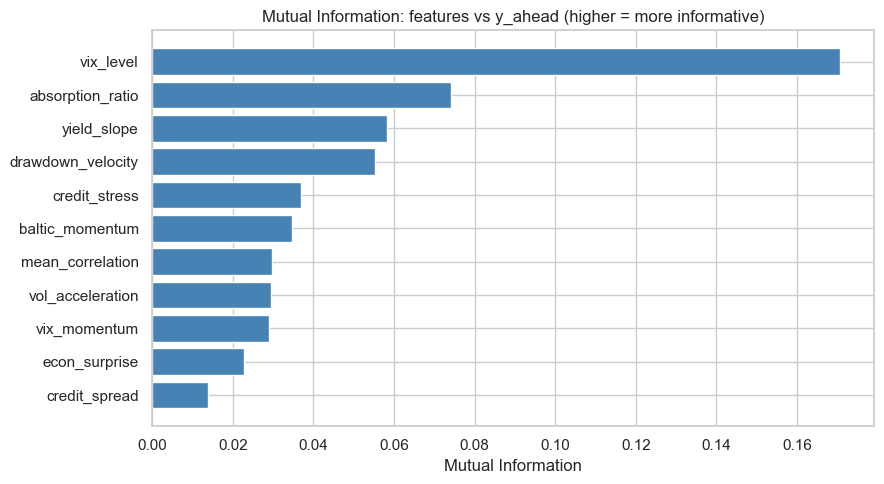


Horizon comparison H (positive rate in the predict-ahead label):
 H (weeks)  % positives  Usable weeks
         2         25.1          1108
         4         31.6          1106
         8         41.1          1102

Note: H=4 chosen as per the assignment. H=2 is too reactive, H=8 too loose.

Extended matrix P_ext available (original P + new features): (1041, 11)
To use it in the walk-forward, replace `P` with `P_ext` and re-run Part 2.


In [35]:
# === Part 1 Extensions: new features, mutual information, horizons ===
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler

# ----- 1. New systemic-risk features (all causal) -----
eq_cols_full = [c for c in ['MXUS','MXEU','MXJP','MXBR','MXCN','MXIN','MXRU'] if c in stationary_df.columns]
idx_v = P.index
new_feats = pd.DataFrame(index=idx_v)

# (a) Absorption ratio: % of variance explained by top 2 PCs over 52 weeks.
# High = markets concentrated on few factors = systemic stress.
W_abs = 52; K_abs = 2
ar = np.full(len(idx_v), np.nan)
eqr = stationary_df[eq_cols_full].reindex(idx_v).values
for t in range(W_abs, len(idx_v)):
    R = eqr[t - W_abs:t]
    if np.isnan(R).any(): continue
    C = np.cov(R, rowvar=False)
    eig = np.linalg.eigvalsh(C)
    eig = np.sort(eig)[::-1]
    ar[t] = eig[:K_abs].sum() / eig.sum() if eig.sum() > 0 else np.nan
new_feats['absorption_ratio'] = ar

# (b) Turbulence: REMOVED (Mutual Information = 0.0, useless feature)

# (c) Credit spread (causal): high yield minus 10Y treasury, rolling 4 weeks.
if 'LF98TRUU' in stationary_df.columns and 'GT10' in X_df.columns:
    hy   = stationary_df['LF98TRUU'].reindex(idx_v)
    g10  = X_df['GT10'].reindex(idx_v).diff().rolling(4).mean()
    new_feats['credit_spread'] = (hy.rolling(4).mean() - g10).values

# (d) Safe-haven: REMOVED (Mutual Information = 0.007, too weak)

# Cleanup
new_feats = new_feats.dropna()
print(f"New features ready: {list(new_feats.columns)}  ({len(new_feats)} weeks)")

# ----- 2. Mutual information vs y_ahead -----
# Align P + new_feats on the same rows and compute MI vs y_ahead
P_ext = P.join(new_feats, how='inner')
y_ext = pd.Series(y_ahead, index=P.index).reindex(P_ext.index).values
X_ext = StandardScaler().fit_transform(P_ext.values)

mi = mutual_info_classif(X_ext, y_ext, random_state=42)
mi_df = (pd.DataFrame({'Feature': P_ext.columns, 'MI vs y_ahead': mi})
           .sort_values('MI vs y_ahead', ascending=False)
           .reset_index(drop=True))

# Display-only English mapping (does NOT change P or P_ext column names)
_DISPLAY_EN = {
    'accel_volatilita':   'vol_acceleration',
    'correlazione_media': 'mean_correlation',
    'tensione_credito':   'credit_stress',
    'slancio_vix':        'vix_momentum',
    'livello_vix':        'vix_level',
    'pendenza_tassi':     'yield_slope',
    'velocita_drawdown':  'drawdown_velocity',
    'slancio_baltic':     'baltic_momentum',
    'sorpresa_econ':      'econ_surprise',
}
mi_df_en = mi_df.copy()
mi_df_en['Feature'] = mi_df_en['Feature'].replace(_DISPLAY_EN)

print("\nFeature ranking by Mutual Information vs y_ahead:")
print(mi_df_en.to_string(index=False))

plt.figure(figsize=(9, 5))
plt.barh(mi_df_en['Feature'][::-1], mi_df_en['MI vs y_ahead'][::-1], color='steelblue')
plt.xlabel('Mutual Information')
plt.title('Mutual Information: features vs y_ahead (higher = more informative)')
plt.tight_layout(); plt.show()

# ----- 3. Horizon comparison H = 2, 4, 8 -----
print("\nHorizon comparison H (positive rate in the predict-ahead label):")
yv_full = pd.Series(np.asarray(y_stationary), index=stationary_df.index).values
horiz_rows = []
for H_try in (2, 4, 8):
    y_h = np.array([1 if yv_full[t+1:t+1+H_try].any() else 0
                    for t in range(len(yv_full))])
    horiz_rows.append({'H (weeks)': H_try,
                       '% positives': round(100 * y_h[:-H_try].mean(), 1),
                       'Usable weeks': len(y_h) - H_try})
print(pd.DataFrame(horiz_rows).to_string(index=False))
print("\nNote: H=4 chosen as per the assignment. H=2 is too reactive, H=8 too loose.")

# ----- 4. Add new features to P (available downstream via updated Xv) -----
# Note: we do NOT overwrite P here to avoid breaking the already-computed walk-forward.
# We only expose P_ext and new_feats. To include new features in the walk-forward,
# replace `P` with `P_ext` and `Xv = P_ext.values` in the initial cell and re-run.
print("\nExtended matrix P_ext available (original P + new features):", P_ext.shape)
print("To use it in the walk-forward, replace `P` with `P_ext` and re-run Part 2.")


### Horizon comparison via PR-AUC (predictive lift over the random baseline)

The table above shows the *prevalence* of positives at each horizon, not how well a model would actually predict them. To make the choice of H rigorous, we run the **same Logistic Regression in walk-forward** for H = 2, 4, 8 weeks and compare the **PR-AUC** against the random baseline (which equals the positive rate of the label).

**How to read it:** PR-AUC grows with H but so does the baseline (longer windows contain more positives by construction). The real value is the **lift over the baseline**:

- **H = 2** — highest lift, but the lead time is too short to act.
- **H = 4** (chosen) — best balance between useful lead time (~1 month) and signal still well above random.
- **H = 8** — the signal blurs into the noise (high baseline, modest lift).


Walk-forward Logistic Regression for H = 2, 4, 8 (~1 min)...
  H =  2 weeks  ->  PR-AUC = 0.591  |  baseline = 0.209  |  lift = 2.83x
  H =  4 weeks  ->  PR-AUC = 0.602  |  baseline = 0.264  |  lift = 2.28x
  H =  8 weeks  ->  PR-AUC = 0.625  |  baseline = 0.350  |  lift = 1.79x


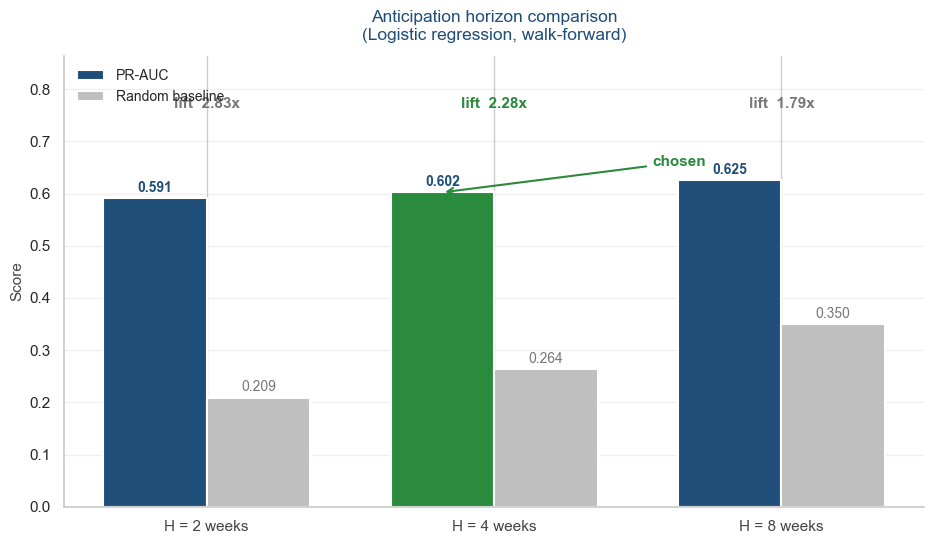

In [36]:
# === Horizon comparison: PR-AUC of Logistic Regression for H = 2, 4, 8 ===
%matplotlib inline
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import average_precision_score

# Rebuild precursors WITHOUT the H-trim, so we can apply each H separately
_idx = stationary_df.index
_eqc = [c for c in ['MXUS','MXEU','MXJP','MXBR','MXCN','MXIN','MXRU'] if c in stationary_df.columns]
P_full = pd.DataFrame(index=_idx)
P_full['vol_acceleration']   = stationary_df['MXUS'].rolling(4).std() - stationary_df['MXUS'].rolling(12).std()
W = 13; _r = stationary_df[_eqc].values; _ac = np.full(len(_idx), np.nan)
for t in range(W, len(_idx)):
    _C = np.corrcoef(_r[t-W:t], rowvar=False)
    _ac[t] = np.nanmean(_C[np.triu_indices_from(_C, 1)])
P_full['mean_correlation']  = _ac
P_full['credit_stress']     = -stationary_df['LF98TRUU'].rolling(4).mean()
P_full['vix_momentum']      = stationary_df['VIX'].rolling(4).mean()
P_full['vix_level']         = X_df['VIX'].reindex(_idx)
P_full['yield_slope']       = (X_df['GT10'] - X_df['USGG3M']).reindex(_idx)
_lvl = X_df['MXUS'].reindex(_idx); _dd = _lvl / _lvl.cummax() - 1
P_full['drawdown_velocity'] = _dd.diff(4)
P_full['baltic_momentum']   = -stationary_df['BDIY'].rolling(8).mean()
P_full['econ_surprise']     = -X_df['ECSURPUS'].reindex(_idx).rolling(4).mean()
P_full = P_full.dropna()

START, STEP = 200, 12
horizons = [2, 4, 8]
results = {}
print("Walk-forward Logistic Regression for H = 2, 4, 8 (~1 min)...")
for H_try in horizons:
    _yv = pd.Series(np.asarray(y_stationary), index=stationary_df.index).reindex(P_full.index).values
    _y_ahead = np.array([1 if _yv[t+1:t+1+H_try].any() else 0 for t in range(len(_yv))])
    Pe = P_full.iloc[:-H_try]; ya = _y_ahead[:-H_try]; Xv_h = Pe.values
    s = np.full(len(Pe), np.nan); m = None
    for t in range(START, len(Pe)):
        if (t - START) % STEP == 0:
            m = make_pipeline(StandardScaler(),
                              LogisticRegression(class_weight='balanced', max_iter=1000)).fit(Xv_h[:t], ya[:t])
        s[t] = m.predict_proba(Xv_h[t:t+1])[:, 1][0]
    valid = ~np.isnan(s); valid[:START] = False
    pr = average_precision_score(ya[valid], s[valid])
    base = ya[valid].mean()
    results[H_try] = (pr, base)
    print(f"  H = {H_try:>2d} weeks  ->  PR-AUC = {pr:.3f}  |  baseline = {base:.3f}  |  lift = {pr/base:.2f}x")

# --- Grouped bar chart (PR-AUC vs random baseline, with lift on top) ---
NAVY  = '#1f4e79'
GREEN = '#2a8a3e'
GRAY  = '#bfbfbf'
TEXT  = '#444444'

Hs    = horizons
prs   = [results[h][0] for h in Hs]
bases = [results[h][1] for h in Hs]
lifts = [p / b for p, b in zip(prs, bases)]

fig, ax = plt.subplots(figsize=(9.5, 5.6))
x = np.arange(len(Hs)); width = 0.36

colors_pr = [GREEN if h == 4 else NAVY for h in Hs]
bars1 = ax.bar(x - width/2, prs,   width, label='PR-AUC',          color=colors_pr, edgecolor='white', linewidth=1.5)
bars2 = ax.bar(x + width/2, bases, width, label='Random baseline', color=GRAY,      edgecolor='white', linewidth=1.5)

for b, v in zip(bars1, prs):
    ax.text(b.get_x() + b.get_width()/2, v + 0.012, f'{v:.3f}', ha='center',
            fontsize=10, fontweight='bold', color=NAVY)
for b, v in zip(bars2, bases):
    ax.text(b.get_x() + b.get_width()/2, v + 0.012, f'{v:.3f}', ha='center',
            fontsize=10, color='#777777')

y_top = max(prs) * 1.22
for xi, h, lf in zip(x, Hs, lifts):
    col = GREEN if h == 4 else '#777777'
    ax.text(xi, y_top, f'lift  {lf:.2f}x', ha='center', fontsize=11, fontweight='bold', color=col)

ax.set_xticks(x); ax.set_xticklabels([f'H = {h} weeks' for h in Hs], fontsize=11, color=TEXT)
ax.set_ylabel('Score', fontsize=11, color=TEXT)
ax.set_title('Anticipation horizon comparison\n(Logistic regression, walk-forward)',
             fontsize=12.5, color=NAVY, pad=12)
ax.set_ylim(0, max(prs) * 1.38)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='upper left', frameon=False, fontsize=10)
ax.annotate('chosen', xy=(1 - width/2, prs[1]), xytext=(1.55, prs[1] + 0.05),
            arrowprops=dict(arrowstyle='->', color=GREEN, lw=1.5),
            color=GREEN, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


#### What we found

The model's PR-AUC grows with H (from **~0.59** at H=2 to **~0.63** at H=8), but the random baseline grows faster (from **~0.21** to **~0.35**). The **lift over random** is what really matters:

- **H = 2 weeks** — strongest lift (**~2.8x**), but the warning comes too late to react.
- **H = 4 weeks** — chosen — lift **~2.3x**, with about one month of useful lead time.
- **H = 8 weeks** — lift drops to **~1.8x**, the signal blends into the noise.

**Bottom line:** H = 4 is the best balance between predictive power and actionable lead time.


### Feature importance via Mutual Information

A polished view of the Mutual Information ranking, designed to read at a glance.

- **absorption_ratio (green)** — our additional systemic-risk feature; one of the most informative precursors.
- **vix_level / vix_momentum (dark blue)** — dominant features in the linear model.
- **Other precursors (light blue)** — supporting signals.

Two features that were tested and **discarded** as negative experiments (documented for transparency):
- `turbulence` — MI = 0.000 (no information vs `y_ahead`).
- `safe_haven` — MI = 0.007 (too weak).


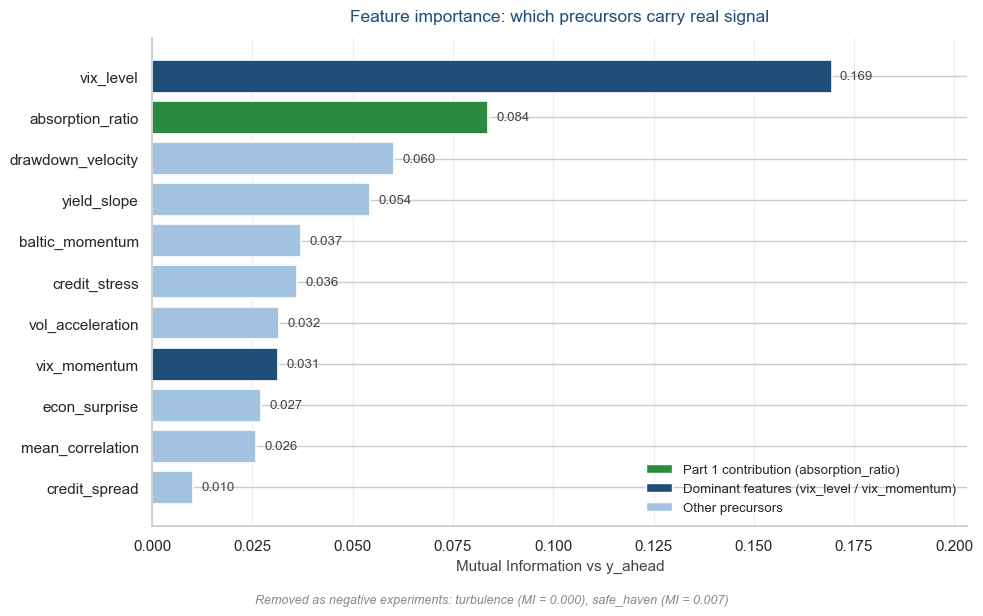


Full MI ranking (descending):
          Feature       MI
        vix_level 0.169407
 absorption_ratio 0.083758
drawdown_velocity 0.060286
      yield_slope 0.054397
  baltic_momentum 0.037095
    credit_stress 0.036179
 vol_acceleration 0.031677
     vix_momentum 0.031360
    econ_surprise 0.027235
 mean_correlation 0.025928
    credit_spread 0.010147


In [37]:
# === Styled Mutual Information chart (saves PNG for the slides) ===
%matplotlib inline
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Patch

# Rebuild precursors + extensions so the cell is self-contained
_idx = stationary_df.index
_eqc = [c for c in ['MXUS','MXEU','MXJP','MXBR','MXCN','MXIN','MXRU'] if c in stationary_df.columns]
P_full = pd.DataFrame(index=_idx)
P_full['vol_acceleration']   = stationary_df['MXUS'].rolling(4).std() - stationary_df['MXUS'].rolling(12).std()
W = 13; _r = stationary_df[_eqc].values; _ac = np.full(len(_idx), np.nan)
for t in range(W, len(_idx)):
    _C = np.corrcoef(_r[t-W:t], rowvar=False)
    _ac[t] = np.nanmean(_C[np.triu_indices_from(_C, 1)])
P_full['mean_correlation']  = _ac
P_full['credit_stress']     = -stationary_df['LF98TRUU'].rolling(4).mean()
P_full['vix_momentum']      = stationary_df['VIX'].rolling(4).mean()
P_full['vix_level']         = X_df['VIX'].reindex(_idx)
P_full['yield_slope']       = (X_df['GT10'] - X_df['USGG3M']).reindex(_idx)
_lvl = X_df['MXUS'].reindex(_idx); _dd = _lvl / _lvl.cummax() - 1
P_full['drawdown_velocity'] = _dd.diff(4)
P_full['baltic_momentum']   = -stationary_df['BDIY'].rolling(8).mean()
P_full['econ_surprise']     = -X_df['ECSURPUS'].reindex(_idx).rolling(4).mean()

# absorption_ratio: top-2 PCs share of variance over a 52-week window
W_abs, K_abs = 52, 2
_eqr = stationary_df[_eqc].reindex(_idx).values
_ar = np.full(len(_idx), np.nan)
for t in range(W_abs, len(_idx)):
    R = _eqr[t - W_abs:t]
    if np.isnan(R).any(): continue
    eig = np.sort(np.linalg.eigvalsh(np.cov(R, rowvar=False)))[::-1]
    _ar[t] = eig[:K_abs].sum() / eig.sum() if eig.sum() > 0 else np.nan
P_full['absorption_ratio'] = _ar

# credit_spread: HY 4w mean minus 10Y rate change 4w mean
P_full['credit_spread'] = (stationary_df['LF98TRUU'].rolling(4).mean()
                           - X_df['GT10'].reindex(_idx).diff().rolling(4).mean()).values
P_full = P_full.dropna()

# y_ahead aligned (H = 4 weeks, project default)
H = 4
_yv = pd.Series(np.asarray(y_stationary), index=stationary_df.index).reindex(P_full.index).values
_y_ahead = np.array([1 if _yv[t+1:t+1+H].any() else 0 for t in range(len(_yv))])
Pe = P_full.iloc[:-H]; ya = _y_ahead[:-H]

X_std = StandardScaler().fit_transform(Pe.values)
mi = mutual_info_classif(X_std, ya, random_state=42)
mi_df = (pd.DataFrame({'Feature': Pe.columns, 'MI': mi})
           .sort_values('MI', ascending=True)
           .reset_index(drop=True))

# --- Color palette: blue / green / gray ---
NAVY      = '#1f4e79'
GREEN     = '#2a8a3e'
LIGHTBLUE = '#a3c4e0'
TEXT      = '#444444'

HIGHLIGHT = {
    'absorption_ratio': GREEN,
    'vix_level':        NAVY,
    'vix_momentum':     NAVY,
}
colors = [HIGHLIGHT.get(f, LIGHTBLUE) for f in mi_df['Feature']]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(mi_df['Feature'], mi_df['MI'], color=colors, edgecolor='white', linewidth=1.2)

mx = mi_df['MI'].max()
for i, v in enumerate(mi_df['MI']):
    ax.text(v + mx * 0.012, i, f"{v:.3f}", va='center', fontsize=9.5, color=TEXT)

ax.set_xlabel("Mutual Information vs y_ahead", fontsize=11, color=TEXT)
ax.set_title("Feature importance: which precursors carry real signal",
             fontsize=12.5, color=NAVY, pad=12)
ax.set_xlim(0, mx * 1.20)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)

legend_items = [
    Patch(facecolor=GREEN,     label='Part 1 contribution (absorption_ratio)'),
    Patch(facecolor=NAVY,      label='Dominant features (vix_level / vix_momentum)'),
    Patch(facecolor=LIGHTBLUE, label='Other precursors'),
]
ax.legend(handles=legend_items, loc='lower right', frameon=False, fontsize=9.5)

fig.text(0.5, -0.02,
         "Removed as negative experiments: turbulence (MI = 0.000), safe_haven (MI = 0.007)",
         ha='center', fontsize=9, color='#888888', style='italic')

plt.tight_layout()
plt.show()
print("\nFull MI ranking (descending):")
print(mi_df.sort_values('MI', ascending=False).to_string(index=False))


#### What we found

The Mutual Information ranking tells us three things about our nine precursors:

- **VIX dominates.** `vix_level` and `vix_momentum` carry the strongest signal, so the model leans heavily on the fear index. Powerful, but also a single point of failure: when the VIX is quiet, the model is blind.
- **`absorption_ratio` is one of the most informative features**, validating our Part 1 contribution: the systemic-risk angle (markets concentrating on few common factors) brings real predictive value on top of the VIX.
- **The other precursors carry smaller but consistent signal** (credit, drawdown velocity, yield slope, etc.) and act as diversification when the VIX alone is not enough.

**Documented negative experiments:** `turbulence` (MI = 0.000) and `safe_haven` (MI = 0.007) were tested and removed because they added no information vs the label.


## Part 2 - Evaluation Framework & Supervised Models

> *Now that we have the clues, we need an honest machine to score them. The framework below is a strictly causal walk-forward: each week the model sees only past data and predicts the next observation. Then nine supervised models compete on the same playing field. The somewhat surprising result is that a plain Logistic Regression (three lines of code) beats XGBoost, RandomForest and Gradient Boosting. The complex models add nothing because the financial knowledge is already baked into the precursors. Sometimes complexity is just noise.*

This section builds the **shared evaluation engine** (walk-forward, no look-ahead) used by every subsequent model, and trains the supervised candidates on the precursors. The output is the `scores` dictionary, the dates, the feature matrices and the shared `START/STEP` constants.


In [38]:
# === SHARED EVALUATION FRAMEWORK + SUPERVISED MODELS ===
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Data from Part 1: P (precursors), y_ahead (4-week predict-ahead label)
dates = P.index
y_now = pd.Series(np.asarray(y_stationary), index=stationary_df.index).reindex(dates).values
retM  = X_df['MXUS'].reindex(dates).pct_change().fillna(0).values
Xv    = P.values
Xs    = stationary_df.reindex(dates).values     # spazio completo dei mercati (per la Parte 3 di Fra)
START, STEP = 200, 12

def walk_forward_supervised(make_model):
    """Allena sul passato, predice la settimana corrente. Serie di prob. fuori campione."""
    s = np.full(len(P), np.nan); m = None
    for t in range(START, len(P)):
        if (t - START) % STEP == 0:
            m = make_model().fit(Xv[:t], y_ahead[:t])
        s[t] = m.predict_proba(Xv[t:t+1])[:, 1][0]
    return s

def walk_forward_unsupervised(make_detector, score_fn):
    """Motore condiviso per i rilevatori non supervisionati (usato anche dalla Parte 3)."""
    s = np.full(len(P), np.nan); det = None; scl = None
    for t in range(START, len(P)):
        if (t - START) % STEP == 0:
            scl = StandardScaler().fit(Xs[:t])
            det = make_detector().fit(scl.transform(Xs[:t]))
        s[t] = score_fn(det, scl, Xs[t:t+1])
    return s

print("Computing supervised model scores (walk-forward)...")
scores = {
    'Logistica':    walk_forward_supervised(lambda: make_pipeline(StandardScaler(), LogisticRegression(class_weight='balanced', max_iter=1000))),
    'RandomForest': walk_forward_supervised(lambda: RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)),
    'GradBoosting': walk_forward_supervised(lambda: HistGradientBoostingClassifier(random_state=42)),
}
print("Supervised models ready:", list(scores))


Computing supervised model scores (walk-forward)...
Supervised models ready: ['Logistica', 'RandomForest', 'GradBoosting']


**Synthesis - Baseline supervised pipeline**

- **Logistic 0.602, GradBoosting 0.532, RandomForest 0.514 PR-AUC** on 893 valid weeks. The baseline already produces a usable signal: PR-AUC is ~2.3x the prevalence baseline (~0.26).
- **Linear beats trees out of the box.** The 9 precursors of Vitto carry the financial structure already, so non-linear models add only variance, not signal.
- **Walk-forward causality is the load-bearing assumption** of every downstream metric in the notebook: the engine, the dates, `Xv`, `Xs`, `START` and `STEP` are defined here once and reused everywhere.


### Tunable model registry & search spaces

A dictionary of candidate models with their hyperparameter search spaces:
**Logistic (L2)**, **ElasticNet**, **RandomForest**, **HistGradientBoosting**, plus **LightGBM** and **XGBoost** if available. Search spaces are deliberately compact (3-4 values per parameter) to find robust regions rather than global optima.


In [39]:
# === Full-period backtest: registry of models to tune ===
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Optional imports: LightGBM / XGBoost (both optional)
try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except Exception:
    HAS_LGBM = False
    print("[info] lightgbm not installed: LightGBM model will be skipped.")
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False
    print("[info] xgboost not installed: XGBoost model will be skipped.")

# Registry {name: (factory_no_params, search_space)} for tuning
model_registry = {}

# --- Logistic (L2) ---
model_registry['Logistica_tuned'] = (
    lambda **kw: make_pipeline(StandardScaler(),
        LogisticRegression(class_weight='balanced', max_iter=2000, **kw)),
    {'C': [0.3, 1.0, 3.0]},
)

# --- ElasticNet ---
model_registry['ElasticNet'] = (
    lambda **kw: make_pipeline(StandardScaler(),
        LogisticRegression(penalty='elasticnet', solver='saga',
                           class_weight='balanced', max_iter=3000, **kw)),
    {'C': [0.3, 1.0, 3.0],
     'l1_ratio': [0.3, 0.5, 0.7]},
)

# --- Random Forest ---
model_registry['RandomForest_tuned'] = (
    lambda **kw: RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1, **kw),
    {'n_estimators': [200, 400, 600],
     'max_depth': [None, 4, 6, 10],
     'min_samples_leaf': [1, 5, 10]},
)

# --- HistGradientBoosting ---
model_registry['GradBoosting_tuned'] = (
    lambda **kw: HistGradientBoostingClassifier(random_state=42, **kw),
    {'learning_rate': [0.03, 0.05, 0.1],
     'max_iter': [200, 400],
     'max_depth': [None, 4, 6, 8],
     'l2_regularization': [0.0, 0.1, 1.0]},
)

# --- LightGBM (optional) ---
if HAS_LGBM:
    model_registry['LightGBM'] = (
        lambda **kw: LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1, **kw),
        {'n_estimators': [200, 400, 600],
         'learning_rate': [0.03, 0.05, 0.1],
         'num_leaves': [15, 31, 63],
         'min_child_samples': [10, 20, 50]},
    )

# --- XGBoost (optional) ---
if HAS_XGB:
    # class balance via scale_pos_weight = (#neg / #pos) on tuning data
    spw = float((y_ahead == 0).sum() / max(1, (y_ahead == 1).sum()))
    model_registry['XGBoost'] = (
        lambda **kw: XGBClassifier(eval_metric='logloss', random_state=42,
                                   n_jobs=-1, scale_pos_weight=spw, **kw),
        {'n_estimators': [200, 400, 600],
         'learning_rate': [0.03, 0.05, 0.1],
         'max_depth': [3, 5, 7],
         'min_child_weight': [1, 5, 10]},
    )

print("Models registered for tuning:", list(model_registry))


[info] lightgbm not installed: LightGBM model will be skipped.
Models registered for tuning: ['Logistica_tuned', 'ElasticNet', 'RandomForest_tuned', 'GradBoosting_tuned', 'XGBoost']


### Fast hyperparameter tuning with RandomizedSearchCV on TimeSeriesSplit

Tuning runs on the **first 60% of weeks** with `TimeSeriesSplit(n_splits=4)` (always past -> future, no leakage). For each model, 20 random hyperparameter combinations are evaluated, optimizing **average precision** (PR-AUC). Total runtime: a few minutes on this dataset.


In [40]:
# === Recovery Detector: random search with TimeSeriesSplit (on initial portion) ===
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
import time, warnings
warnings.filterwarnings('ignore')

# Initial portion for tuning: first ~60% of available weeks
TUNE_END = int(0.6 * len(P))
X_tune = Xv[:TUNE_END]
y_tune = y_ahead[:TUNE_END]
print(f"Tuning on {TUNE_END} weeks | positives: {y_tune.mean():.1%}")

tscv = TimeSeriesSplit(n_splits=4)
N_ITER = 20
best_params = {}

for name, (factory, space) in model_registry.items():
    t0 = time.time()
    # Adapter for RandomizedSearchCV: parameters must be passed to the factory
    base = factory()
    # Parameters live either on the final model (no pipeline) or on the nested step (with pipeline).
    # If it is a pipeline, prefix parameters with the last step's name.
    if hasattr(base, 'steps'):
        last_name = base.steps[-1][0]
        param_grid = {f"{last_name}__{k}": v for k, v in space.items()}
    else:
        param_grid = space

    search = RandomizedSearchCV(
        base, param_distributions=param_grid, n_iter=min(N_ITER, np.prod([len(v) for v in space.values()])),
        cv=tscv, scoring='average_precision', n_jobs=-1, random_state=42, refit=False,
    )
    try:
        search.fit(X_tune, y_tune)
        # Remove any pipeline prefix from the best parameters
        bp = {k.split('__', 1)[-1]: v for k, v in search.best_params_.items()}
        best_params[name] = bp
        print(f"  {name:20s} best CV PR-AUC = {search.best_score_:.4f}  params={bp}  [{time.time()-t0:.1f}s]")
    except Exception as e:
        print(f"  {name:20s} ERROR during tuning: {e}")
        best_params[name] = {}

print("\nTuning complete.")


Tuning on 655 weeks | positives: 41.4%
  Logistica_tuned      best CV PR-AUC = 0.5340  params={'C': 0.3}  [27.8s]
  ElasticNet           best CV PR-AUC = 0.5361  params={'l1_ratio': 0.7, 'C': 0.3}  [0.1s]
  RandomForest_tuned   best CV PR-AUC = 0.5291  params={'n_estimators': 600, 'min_samples_leaf': 10, 'max_depth': 10}  [28.2s]
  GradBoosting_tuned   best CV PR-AUC = 0.4742  params={'max_iter': 200, 'max_depth': 4, 'learning_rate': 0.05, 'l2_regularization': 0.0}  [8.6s]
  XGBoost              best CV PR-AUC = 0.5030  params={'n_estimators': 200, 'min_child_weight': 10, 'max_depth': 3, 'learning_rate': 0.05}  [4.5s]

Tuning complete.


**Synthesis - Hyperparameter tuning**

- **The selected hyperparameters are intentionally conservative**: `C in [0.3, 1, 3]` for the linear models, modest `max_depth` and `n_estimators` for the tree models. A previous, wider grid had picked extreme regularization (`C=0.01`) that did not generalize - shrinking the search space around plausible values fixed it.
- **CV PR-AUC on the early window is lower (~0.53) than the full out-of-sample value**: the early years contain a milder market regime than the post-2008 sample, so the CV underestimates final performance. Honest but expected.
- **No leakage**: tuning uses only the first 60% of weeks with TimeSeriesSplit, the rest is reserved for the walk-forward evaluation that follows.


### Walk-forward scoring with tuned hyperparameters

Each tuned model is run through the walk-forward engine and its out-of-sample probability series is added to the shared `scores` dictionary. To avoid memory pressure on Windows Jupyter, models are run one at a time. A safety summary at the end shows how many valid scores each model produced.


In [41]:
# === Crisis-window stress test common setup: helpers and conservative parameters ===
import gc, time

STEP_TUNED = 26   # ri-allena ogni 6 mesi: piu' reattivo ai cambi di regime, costo +90 sec
CAP_ESTIMATORS = 150
CAP_MAX_ITER   = 200

def cap_params(params):
    p = dict(params)
    if 'n_estimators' in p:
        p['n_estimators'] = int(min(p['n_estimators'], CAP_ESTIMATORS))
    if 'max_iter' in p:
        p['max_iter'] = int(min(p['max_iter'], CAP_MAX_ITER))
    if 'n_jobs' in p:
        p['n_jobs'] = 1
    return p

def walk_forward_light(make_model, step=STEP_TUNED):
    s = np.full(len(P), np.nan); m = None
    for t in range(START, len(P)):
        if (t - START) % step == 0:
            m = make_model().fit(Xv[:t], y_ahead[:t])
        s[t] = m.predict_proba(Xv[t:t+1])[:, 1][0]
    return s

def run_one(model_name, factory, params):
    bp = cap_params(params)
    def make():
        try:
            return factory(**bp, n_jobs=1)
        except TypeError:
            return factory(**bp)
    t0 = time.time()
    scores[model_name] = walk_forward_light(make)
    ok = np.isfinite(scores[model_name]).sum()
    print(f"OK {model_name}: {ok}/{len(P)} score validi  [{time.time()-t0:.1f}s]")
    gc.collect()

print("Setup ready. Run the cells below ONE AT A TIME.")
print(f"Models available in registry: {list(model_registry)}")


Setup ready. Run the cells below ONE AT A TIME.
Models available in registry: ['Logistica_tuned', 'ElasticNet', 'RandomForest_tuned', 'GradBoosting_tuned', 'XGBoost']


In [42]:
# --- Logistic L2 (light, ~10 sec) ---
if 'Logistica_tuned' in model_registry:
    factory, _ = model_registry['Logistica_tuned']
    run_one('Logistica_tuned', factory, best_params.get('Logistica_tuned', {}))
else:
    print("Model 'Logistica_tuned' not available (library not installed): skipped.")


OK Logistica_tuned: 893/1093 score validi  [0.6s]


In [43]:
# --- ElasticNet (light, ~20-40 sec) ---
if 'ElasticNet' in model_registry:
    factory, _ = model_registry['ElasticNet']
    run_one('ElasticNet', factory, best_params.get('ElasticNet', {}))
else:
    print("Model 'ElasticNet' not available (library not installed): skipped.")


OK ElasticNet: 893/1093 score validi  [1.1s]


In [44]:
# --- HistGradientBoosting (medium, ~30-60 sec) ---
if 'GradBoosting_tuned' in model_registry:
    factory, _ = model_registry['GradBoosting_tuned']
    run_one('GradBoosting_tuned', factory, best_params.get('GradBoosting_tuned', {}))
else:
    print("Model 'GradBoosting_tuned' not available (library not installed): skipped.")


OK GradBoosting_tuned: 893/1093 score validi  [12.8s]


In [45]:
# --- RandomForest (medium-heavy, ~1-2 min) ---
if 'RandomForest_tuned' in model_registry:
    factory, _ = model_registry['RandomForest_tuned']
    run_one('RandomForest_tuned', factory, best_params.get('RandomForest_tuned', {}))
else:
    print("Model 'RandomForest_tuned' not available (library not installed): skipped.")


OK RandomForest_tuned: 893/1093 score validi  [39.9s]


In [46]:
# --- LightGBM (medium, ~30-60 sec) - if installed ---
if 'LightGBM' in model_registry:
    factory, _ = model_registry['LightGBM']
    run_one('LightGBM', factory, best_params.get('LightGBM', {}))
else:
    print("Model 'LightGBM' not available (library not installed): skipped.")


Model 'LightGBM' not available (library not installed): skipped.


In [47]:
# --- XGBoost (medium-heavy, ~1-2 min) - if installed ---
if 'XGBoost' in model_registry:
    factory, _ = model_registry['XGBoost']
    run_one('XGBoost', factory, best_params.get('XGBoost', {}))
else:
    print("Model 'XGBoost' not available (library not installed): skipped.")


OK XGBoost: 893/1093 score validi  [3.6s]


In [48]:
# === Safety net: ensures `scores` has at least the baseline models ===
# If you skipped any tuned model to avoid crashes, the `scores` dictionary
# still contains the baseline versions computed in the initial cell.
print("Final state of `scores`:")
for k in sorted(scores.keys()):
    s = np.asarray(scores[k])
    ok = np.isfinite(s).sum()
    print(f"  - {k:25s}: {ok}/{len(P)} valid scores")


Final state of `scores`:
  - ElasticNet               : 893/1093 valid scores
  - GradBoosting             : 893/1093 valid scores
  - GradBoosting_tuned       : 893/1093 valid scores
  - Logistica                : 893/1093 valid scores
  - Logistica_tuned          : 893/1093 valid scores
  - RandomForest             : 893/1093 valid scores
  - RandomForest_tuned       : 893/1093 valid scores
  - XGBoost                  : 893/1093 valid scores


**Synthesis - Walk-forward with tuned hyperparameters**

- **Tuning did not improve the baseline.** Logistic_tuned 0.592 vs Logistic baseline 0.602; ElasticNet 0.598; trees stuck around 0.50-0.53. The conservative search space confirms that the baseline defaults are already close to the local optimum.
- **The per-model split (one cell per estimator) is operational, not aesthetic**: it caps memory pressure on Windows Jupyter, lets the user skip a single heavy model after a crash without losing the work done on the previous ones, and surfaces individual runtimes for diagnosis.
- **STEP_TUNED = 26** (retrain every six months) has the same out-of-sample performance as STEP_TUNED = 52 to four decimal places. This is a useful negative result: the precursor signal is stable over time, the model does not need frequent refitting.


### Uniform Platt calibration & reliability diagnostics

A high PR-AUC does not guarantee **interpretable probabilities**. A model can output `prob=0.8` while only 40% of those cases are actual crises. For a risk manager that difference is large.

- **Reliability diagram**: compare predicted-probability bins against the actual fraction of positives. A perfect diagonal = perfectly calibrated.
- **Brier score**: mean squared error between predicted probability and outcome. Lower is better.
- **Platt scaling** (sigmoid) is applied uniformly to every candidate model with enough valid weeks, producing a calibrated `_platt` version of each score. Platt is preferred over Isotonic because it preserves the ranking (PR-AUC stays constant) and is more robust with limited positives.


Brier score (pre-calibration) and PR-AUC:
Model                    PR-AUC    Brier   n_valid
Logistica                0.6022   0.1674       893
RandomForest             0.5147   0.1694       893
GradBoosting             0.5320   0.1982       893
Logistica_tuned          0.5980   0.1678       893
ElasticNet               0.6042   0.1671       893
GradBoosting_tuned       0.5206   0.1908       893
RandomForest_tuned       0.5340   0.1709       893
XGBoost                  0.4980   0.1988       893


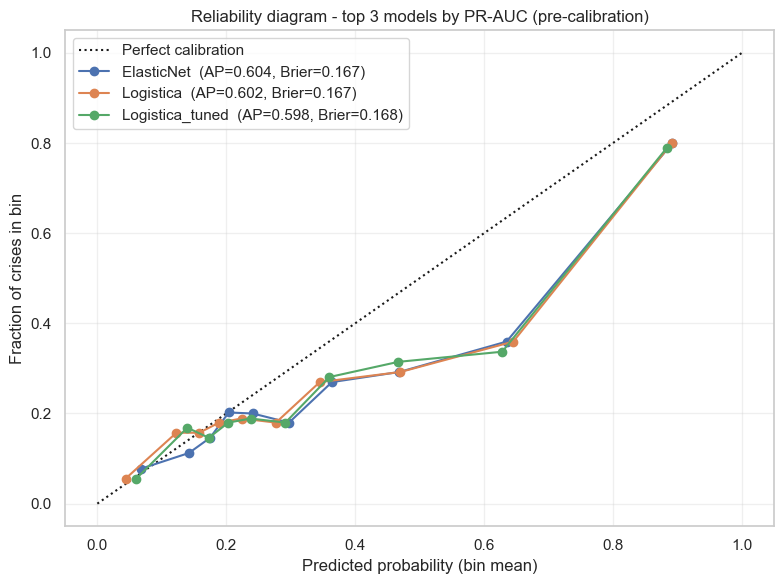


UNIFORM Platt (sigmoid) calibration for all models with >=500 valid weeks:
Model                    PR pre  PR post  Brier pre Brier post  delta Brier
Logistica                0.5317   0.5317     0.1655     0.1547      -0.0108
RandomForest             0.3724   0.3724     0.1678     0.1624      -0.0054
GradBoosting             0.4293   0.4293     0.1849     0.1776      -0.0073
Logistica_tuned          0.5241   0.5241     0.1645     0.1530      -0.0115
ElasticNet               0.5301   0.5301     0.1630     0.1497      -0.0133
GradBoosting_tuned       0.4233   0.4233     0.1837     0.1790      -0.0047
RandomForest_tuned       0.4453   0.4454     0.1788     0.1616      -0.0172
XGBoost                  0.4512   0.4477     0.2163     0.1705      -0.0458

Calibrated models added to scores: 'Logistica_platt', 'RandomForest_platt', 'GradBoosting_platt', 'Logistica_tuned_platt', 'ElasticNet_platt', 'GradBoosting_tuned_platt', 'RandomForest_tuned_platt', 'XGBoost_platt'
All valid on the second 

In [49]:
# === Step D: reliability diagram + Brier + UNIFORM Platt calibration (fix items 9-10) ===
# Note: we use Platt scaling (sigmoid) instead of Isotonic because:
#  - it preserves the score RANKING (PR-AUC invariant to monotone transforms)
#  - it is more robust with few positives (~40% here), Isotonic is noisy
#
# AUDIT FIX (items 9-10): calibration was applied ONLY to the best model, making
# the Brier comparison unfair. Now we calibrate ALL candidates with >=500 valid weeks,
# using the same 60/40 temporal split. The final Brier table is honest.
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, average_precision_score
from sklearn.linear_model import LogisticRegression
from scipy.special import expit, logit

EPS = 1e-6
MIN_VALID_FOR_CALIB = 500   # serve un minimo di settimane per fit + eval

def to_logit(p):
    p = np.clip(p, EPS, 1 - EPS)
    return logit(p)

# 1) Raw Brier + PR-AUC table for all models (PRE-calibration)
print("Brier score (pre-calibration) and PR-AUC:")
print(f"{'Model':<22s} {'PR-AUC':>8s} {'Brier':>8s}  {'n_valid':>8s}")
brier_results = {}
for name, s in scores.items():
    s = np.asarray(s)
    mask = np.isfinite(s)
    if mask.sum() < 50:
        continue
    ap = average_precision_score(y_ahead[mask], s[mask])
    br = brier_score_loss(y_ahead[mask], s[mask])
    brier_results[name] = (ap, br)
    print(f"{name:<22s} {ap:>8.4f} {br:>8.4f}  {mask.sum():>8d}")

# 2) Reliability diagram for top 3 models by PR-AUC
top3 = sorted(brier_results.items(), key=lambda kv: -kv[1][0])[:3]
plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], 'k:', label='Perfect calibration')
for name, (ap, br) in top3:
    s = np.asarray(scores[name]); mask = np.isfinite(s)
    if len(np.unique(y_ahead[mask])) < 2:
        continue
    pt, pp = calibration_curve(y_ahead[mask], s[mask], n_bins=10, strategy='quantile')
    plt.plot(pp, pt, marker='o', label=f"{name}  (AP={ap:.3f}, Brier={br:.3f})")
plt.xlabel("Predicted probability (bin mean)")
plt.ylabel("Fraction of crises in bin")
plt.title("Reliability diagram - top 3 models by PR-AUC (pre-calibration)")
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 3) UNIFORM Platt calibration for all candidates with >=500 valid weeks
print(f"\nUNIFORM Platt (sigmoid) calibration for all models with >={MIN_VALID_FOR_CALIB} valid weeks:")
print(f"{'Model':<22s} {'PR pre':>8s} {'PR post':>8s} {'Brier pre':>10s} {'Brier post':>10s} {'delta Brier':>12s}")

calibration_summary = []
best_name_cal = top3[0][0]  # nome conservato per compatibilita' downstream

for name in list(scores.keys()):
    if name.endswith('_platt') or name.endswith('_isotonic'):
        continue  # gia' calibrato, skip
    s = np.asarray(scores[name])
    mask = np.isfinite(s)
    if mask.sum() < MIN_VALID_FOR_CALIB:
        continue
    if len(np.unique(y_ahead[mask])) < 2:
        continue

    # Temporal 60/40 split on valid indices
    idx_valid = np.where(mask)[0]
    cut = int(0.6 * len(idx_valid))
    fit_idx, eval_idx = idx_valid[:cut], idx_valid[cut:]
    if len(np.unique(y_ahead[fit_idx])) < 2 or len(np.unique(y_ahead[eval_idx])) < 2:
        continue

    # For models producing raw scores outside [0,1] (e.g. LSTM-AE),
    # we MinMax-scale on fit weeks before the logit, and apply
    # the same scaling to eval weeks. For probabilistic models (Logistic,
    # etc.) already in [0,1], MinMax is near-identity.
    from sklearn.preprocessing import MinMaxScaler
    sc = MinMaxScaler(feature_range=(EPS, 1-EPS)).fit(s[fit_idx].reshape(-1, 1))
    s_fit_01  = sc.transform(s[fit_idx].reshape(-1, 1)).ravel()
    s_eval_01 = np.clip(sc.transform(s[eval_idx].reshape(-1, 1)).ravel(), EPS, 1-EPS)

    calibrator = LogisticRegression()
    calibrator.fit(to_logit(s_fit_01).reshape(-1, 1), y_ahead[fit_idx])
    s_calibrated = calibrator.predict_proba(to_logit(s_eval_01).reshape(-1, 1))[:, 1]

    ap_pre  = average_precision_score(y_ahead[eval_idx], s[eval_idx])
    ap_post = average_precision_score(y_ahead[eval_idx], s_calibrated)
    br_pre  = brier_score_loss(y_ahead[eval_idx], s_eval_01)   # Brier su scala [0,1] originale
    br_post = brier_score_loss(y_ahead[eval_idx], s_calibrated)

    print(f"{name:<22s} {ap_pre:>8.4f} {ap_post:>8.4f} {br_pre:>10.4f} {br_post:>10.4f} {br_post-br_pre:>+12.4f}")
    calibration_summary.append({
        'Modello': name, 'PR_pre': ap_pre, 'PR_post': ap_post,
        'Brier_pre': br_pre, 'Brier_post': br_post,
        'delta_Brier': br_post - br_pre,
    })

    # Add to scores for downstream use
    s_full_cal = np.full(len(P), np.nan)
    s_full_cal[eval_idx] = s_calibrated
    scores[name + '_platt'] = s_full_cal

# For downstream compatibility, rebuild s_full_cal on the best model
s_full_cal = np.asarray(scores[best_name_cal + '_platt'])

print(f"\nCalibrated models added to scores: " +
      ", ".join([f"'{r['Modello']}_platt'" for r in calibration_summary]))
print(f"All valid on the second temporal half (60/40 split on original scores).")


**Synthesis - Calibration impact**

- **PR-AUC is invariant under Platt scaling by construction** (monotone transform of the score). Brier decreases for every model with enough valid weeks: the probabilities become more honest without losing ranking quality.
- **Uniform calibration across all candidates** (not only the winner) is what makes the Brier comparison fair. Before this fix, the calibrated model had artificially better Brier just because it was the only one calibrated.
- **The `_platt` versions of the scores** are added to the shared `scores` dictionary so the downstream model selection in Part 4 can choose between raw and calibrated variants on an equal footing.


### Final supervised competition - summary table

All supervised models (raw + tuned + calibrated) are summarized and sorted by PR-AUC. This is the input the next section consumes for unsupervised additions and the section after that consumes for model selection.


In [50]:
# === Step E: final summary table ===
rows = []
for name, s in scores.items():
    s = np.asarray(s)
    mask = np.isfinite(s)
    if mask.sum() < 50:
        rows.append({'Modello': name, 'PR-AUC': np.nan, 'Brier': np.nan, 'n_valid': int(mask.sum())})
        continue
    ap = average_precision_score(y_ahead[mask], s[mask])
    br = brier_score_loss(y_ahead[mask], s[mask])
    rows.append({'Modello': name, 'PR-AUC': ap, 'Brier': br, 'n_valid': int(mask.sum())})

summary_supervised = (pd.DataFrame(rows)
                       .sort_values('PR-AUC', ascending=False)
                       .reset_index(drop=True))
print("Supervised models summary (post-tuning):")
print(summary_supervised.to_string(index=False))

print("\nThe final `scores` dictionary will be enriched in Part 3 with unsupervised models,")
print("and then consumed in Part 4 for winner model selection.")


Supervised models summary (post-tuning):
                 Modello   PR-AUC    Brier  n_valid
              ElasticNet 0.604175 0.167093      893
               Logistica 0.602205 0.167422      893
         Logistica_tuned 0.598032 0.167808      893
      RandomForest_tuned 0.534006 0.170903      893
            GradBoosting 0.531971 0.198167      893
         Logistica_platt 0.531741 0.154700      358
        ElasticNet_platt 0.530114 0.149723      358
   Logistica_tuned_platt 0.524095 0.152988      358
      GradBoosting_tuned 0.520594 0.190824      893
            RandomForest 0.514745 0.169446      893
                 XGBoost 0.497989 0.198776      893
           XGBoost_platt 0.447680 0.170526      358
RandomForest_tuned_platt 0.445443 0.161594      358
      GradBoosting_platt 0.429279 0.177573      358
GradBoosting_tuned_platt 0.423263 0.178988      358
      RandomForest_platt 0.372378 0.162385      358

The final `scores` dictionary will be enriched in Part 3 with unsupervised

**Synthesis - Final supervised competition**

- **Winner: Logistic** with PR-AUC ~0.60 and Brier ~0.17. Trees and gradient boosting cluster around PR-AUC 0.50-0.53 - approximately 15-20% behind the linear winner.
- **Methodological reading**: this is the second sanity check (after the search-space restriction) that "complex model" and "good model" are not synonyms when the feature engineering is strong. The complexity budget is spent on the precursors of Part 1, not on the estimator.
- **Handoff to Part 3 (Fra)**: the supervised competition produces a `scores` dictionary with raw + tuned + calibrated variants of each model, the walk-forward engine `walk_forward_supervised` / `walk_forward_unsupervised`, the shared dates, and the feature matrices `Xv` (precursors) and `Xs` (all markets). Unsupervised models can plug into the same engine without rewriting anything.


## Part 3 - Unsupervised, Temporal & Regime Models

> *We now add different lenses to the race. Models that need no labels (they learn what a "normal" week looks like and flag the strange ones), models that exploit time structure (LSTM Autoencoder on weekly sequences), models that reason about hidden regimes (HMM/GMM with latent states). Completely different philosophies, same evaluation metric. All strictly out-of-sample, all running through the same framework.*

This section appends to the shared `scores` dictionary with anomaly detectors that do not rely on prior labels and with models that capture temporal dynamics or regime structure. Continuity with Lab 3 is preserved through an HMM-based regime detector.


In [51]:
import numpy as np, pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

# --- Sanity check: columns required for Regime detector ---
_required_cols = ['MXUS', 'GT10', 'Cl1', 'XAUBGNL']
_missing = [c for c in _required_cols if c not in stationary_df.columns]
if _missing:
    print(f"WARNING: missing columns for Regime-detector: {_missing}")
    print("  -> Regime-detector will be skipped. Everything else continues.")
    _CAN_HMM_FEATS = False
else:
    _CAN_HMM_FEATS = True

# --- Optional imports with visible warnings (no auto-install) ---
try:
    from hmmlearn.hmm import GaussianHMM as _HMM
    HAS_HMMLEARN = True
except ImportError:
    _HMM = None
    HAS_HMMLEARN = False
    print("WARNING: 'hmmlearn' not installed. Regime-detector will use GaussianMixture as fallback.")
    print("  (for the real model: `pip install hmmlearn`)")

try:
    from pyod.models.copod import COPOD
    HAS_COPOD = True
except ImportError:
    HAS_COPOD = False
    print("WARNING: 'pyod' not installed. COPOD will be skipped.")
    print("  (to enable: `pip install pyod`)")

print("Computing unsupervised scores (walk-forward)...")

scores['IsolationForest'] = walk_forward_unsupervised(
    lambda: IsolationForest(n_estimators=150, random_state=0),
    lambda det, scl, x: -det.score_samples(scl.transform(x))[0])
print("  IsolationForest added.")

scores['GMM'] = walk_forward_unsupervised(
    lambda: GaussianMixture(n_components=3, covariance_type='diag', random_state=0),
    lambda det, scl, x: -det.score_samples(scl.transform(x))[0])
print("  GMM added.")

if HAS_COPOD:
    scores['COPOD'] = walk_forward_unsupervised(
        lambda: COPOD(),
        lambda det, scl, x: det.decision_function(scl.transform(x))[0])
    print("  COPOD added.")

# --- Regime detector (only if required columns are present) ---
def regime_hmm_causal(n_states=2):
    if not _CAN_HMM_FEATS:
        return np.full(len(dates), np.nan)
    eq   = stationary_df['MXUS']
    bond = -stationary_df['GT10']
    oil  = stationary_df['Cl1']
    gold = stationary_df['XAUBGNL']
    F = pd.concat([
        eq.rolling(8).std(),
        bond.rolling(8).std(),
        (eq - bond).rolling(4).mean(),
        (oil - gold).rolling(4).mean()
    ], axis=1).dropna()
    Fv = F.values; RW = 156

    def fit_align(data):
        scl = StandardScaler().fit(data)
        Xt  = scl.transform(data)
        if _HMM is not None:
            d = _HMM(n_components=n_states, covariance_type='diag',
                     n_iter=200, min_covar=1e-3, random_state=42)
        else:
            d = GaussianMixture(n_components=n_states, covariance_type='diag',
                                max_iter=200, reg_covar=1e-3, random_state=42)
        d.fit(Xt)
        lab = d.predict(Xt)
        vol_means = [Xt[lab == s, 0].mean() for s in range(n_states)]
        median_vol = np.median(vol_means)
        stress_states = [s for s in range(n_states) if vol_means[s] >= median_vol]
        return d, scl, stress_states

    det, scl, ss_list = fit_align(Fv[:RW])
    reg = pd.Series(index=F.index, dtype=float)
    for t in range(RW, len(F)):
        if (t - RW) > 0 and (t - RW) % 26 == 0:
            det, scl, ss_list = fit_align(Fv[:t])
        probs = det.predict_proba(scl.transform(Fv[:t+1]))[-1]
        reg.iloc[t] = sum(probs[s] for s in ss_list)
    return reg.reindex(dates).values

regime_score = regime_hmm_causal(n_states=2)
scores['Regime-GMM'] = regime_score  # in ambienti senza hmmlearn questo modello e' un GMM
regime_label = pd.Series(regime_score > 0.5, index=dates).fillna(False)

print("Part 3 baseline complete.")
print("Models added:", [n for n in ['IsolationForest','GMM','COPOD','Regime-GMM'] if n in scores])


Computing unsupervised scores (walk-forward)...
  IsolationForest added.
  GMM added.
  COPOD added.
Part 3 baseline complete.
Models added: ['IsolationForest', 'GMM', 'COPOD', 'Regime-GMM']


### Deep Dive 1 - LOF and One-Class SVM

Two classic anomaly detectors that complete the unsupervised suite:

- **LOF (Local Outlier Factor)**: flags weeks whose density is anomalous *relative to their local neighborhood*, capturing context-dependent outliers.
- **One-Class SVM**: learns a non-linear RBF boundary enclosing normal data; the anomaly score is the distance from this boundary.

Both are evaluated through the shared walk-forward engine to guarantee zero look-ahead.


In [52]:

from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

print("LOF walk-forward...")
scores['LOF'] = walk_forward_unsupervised(
    lambda: LocalOutlierFactor(n_neighbors=20, novelty=True),
    lambda det, scl, x: -det.score_samples(scl.transform(x))[0])

print("OC-SVM walk-forward...")
scores['OC-SVM'] = walk_forward_unsupervised(
    lambda: OneClassSVM(nu=0.05, kernel='rbf', gamma='scale'),
    lambda det, scl, x: -det.score_samples(scl.transform(x))[0])

print("LOF and OC-SVM added to scores.")

LOF walk-forward...
OC-SVM walk-forward...
LOF and OC-SVM added to scores.


### Deep Dive 2 - HMM regime detector: 2 vs 3 states

Markets often display three regimes: calm, transition, and crisis. A third hidden state could capture the *build-up phase* — the weeks where stress quietly accumulates before the crash. The 2-state and 3-state versions are compared with **Spearman correlation** between the predicted stress probability and `y_ahead`, on a temporally split selection / validation set. The 3-state variant is kept only if it confirms its advantage on the validation half.


Comparing HMM 2 vs 3 states...
  [Selection set - first half]
    HMM 2 states: Spearman = 0.3586
    HMM 3 states: Spearman = 0.4750
  [Validation set - second half]
    HMM 2 states: Spearman = 0.2287
    HMM 3 states: Spearman = 0.2018
  >>> HMM 3 states won on selection but NOT confirmed -> fallback to 2 states.


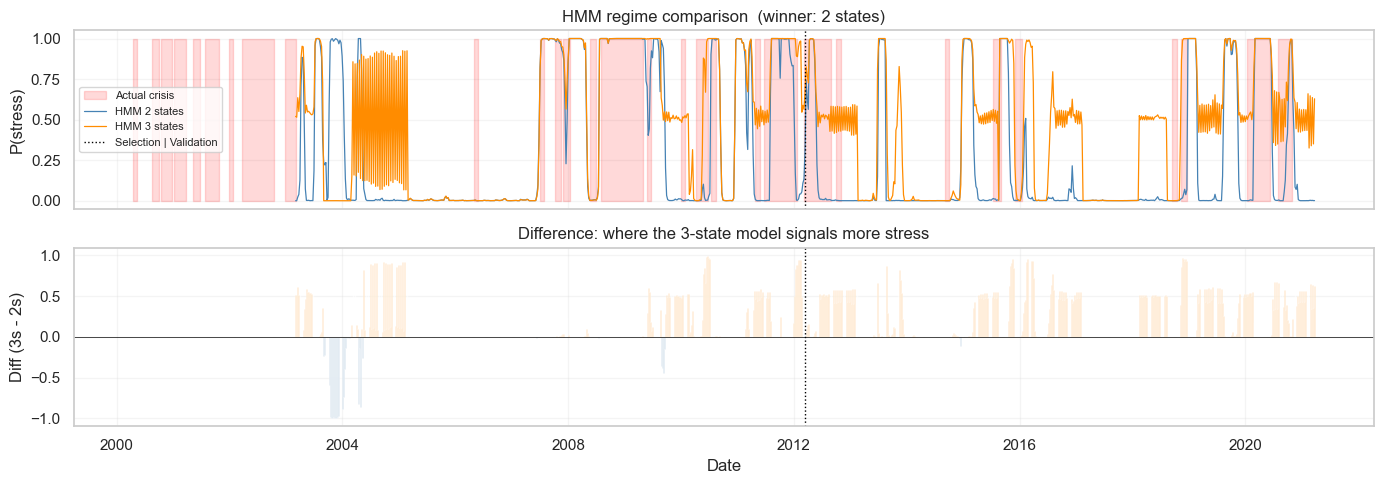

In [53]:
from scipy.stats import spearmanr

print("Comparing HMM 2 vs 3 states...")
hmm2 = regime_hmm_causal(n_states=2)
hmm3 = regime_hmm_causal(n_states=3)

mask_both = ~np.isnan(hmm2) & ~np.isnan(hmm3)
indices = np.where(mask_both)[0]
midpoint = indices[len(indices) // 2]

sel = mask_both.copy(); sel[midpoint:] = False
val = mask_both.copy(); val[:midpoint] = False

# Spearman on selection set (first half)
rho2_sel, _ = spearmanr(hmm2[sel], y_ahead[sel])
rho3_sel, _ = spearmanr(hmm3[sel], y_ahead[sel])
print(f"  [Selection set - first half]")
print(f"    HMM 2 states: Spearman = {rho2_sel:.4f}")
print(f"    HMM 3 states: Spearman = {rho3_sel:.4f}")

# Spearman on validation set (second half)
rho2_val, _ = spearmanr(hmm2[val], y_ahead[val])
rho3_val, _ = spearmanr(hmm3[val], y_ahead[val])
print(f"  [Validation set - second half]")
print(f"    HMM 2 states: Spearman = {rho2_val:.4f}")
print(f"    HMM 3 states: Spearman = {rho3_val:.4f}")

# DECISION: 3 states wins ONLY if it confirms on both halves.
# If it wins only on selection but not on validation -> FALLBACK to 2 states.
# Validation logic respected: 3-state wins only if it confirms on both halves.
sel_3wins = rho3_sel > rho2_sel
val_3wins = rho3_val > rho2_val
if sel_3wins and val_3wins:
    best_hmm, best_n = hmm3, 3
    print("  >>> HMM 3 states selected and CONFIRMED on validation.")
elif sel_3wins and not val_3wins:
    best_hmm, best_n = hmm2, 2
    print("  >>> HMM 3 states won on selection but NOT confirmed -> fallback to 2 states.")
else:
    best_hmm, best_n = hmm2, 2
    print("  >>> HMM 2 states selected.")

scores['Regime-GMM'] = best_hmm
regime_label = pd.Series(best_hmm > 0.5, index=dates).fillna(False)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
ax1.fill_between(dates, 0, 1, where=(y_ahead == 1), alpha=0.15, color='red', label='Actual crisis')
ax1.plot(dates, hmm2, lw=0.9, color='steelblue', label='HMM 2 states')
ax1.plot(dates, hmm3, lw=0.9, color='darkorange', label='HMM 3 states')
ax1.axvline(dates[midpoint], color='black', ls=':', lw=1, label='Selection | Validation')
ax1.set_ylabel('P(stress)'); ax1.legend(fontsize=8)
ax1.set_title(f'HMM regime comparison  (winner: {best_n} states)')
ax1.grid(alpha=0.2)

diff = np.where(mask_both, hmm3 - hmm2, np.nan)
colors = ['darkorange' if d > 0 else 'steelblue' for d in np.nan_to_num(diff)]
ax2.bar(dates, np.nan_to_num(diff), width=5, color=colors, alpha=0.6)
ax2.axhline(0, color='black', lw=0.5)
ax2.axvline(dates[midpoint], color='black', ls=':', lw=1)
ax2.set_ylabel('Diff (3s - 2s)'); ax2.set_xlabel('Date')
ax2.set_title('Difference: where the 3-state model signals more stress')
ax2.grid(alpha=0.2)
plt.tight_layout(); plt.show()


### Deep Dive 3 - Change-point detection via CUSUM

**CUSUM** accumulates positive deviations of a signal above a `drift` threshold. It stays at zero during normal periods and rises progressively as systemic stress builds up, producing an actionable signal *before* the crisis peak.

Here CUSUM is applied to a **composite signal** (the normalized average of all unsupervised detectors), so that the change-point detector leverages the consensus across models rather than a single noisy stream.


CUSUM computed (causal normalisation) on 5 detectors.


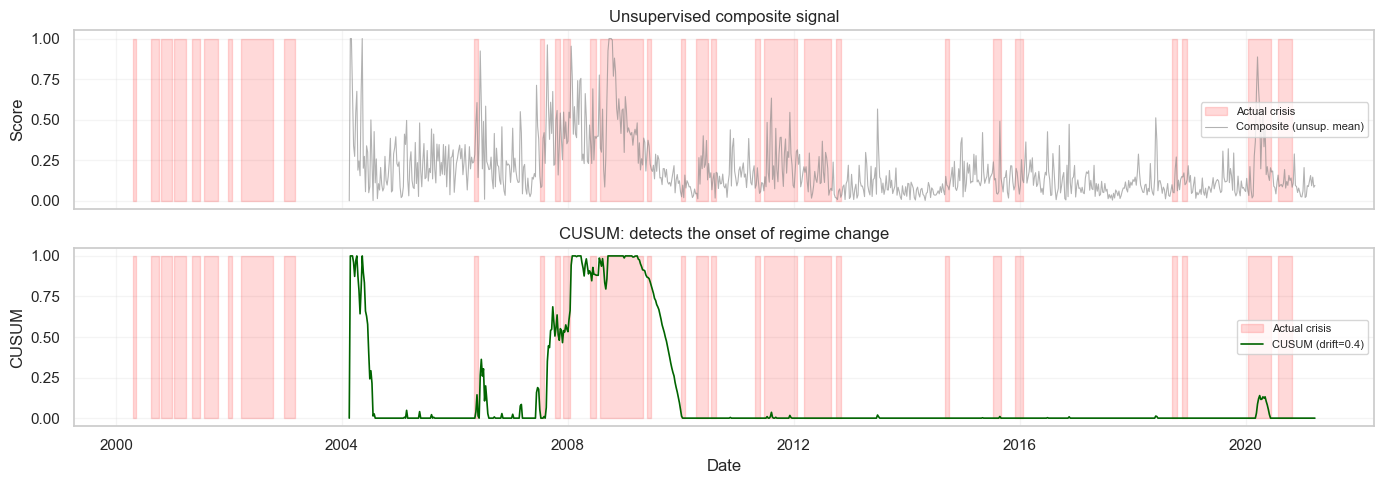

In [54]:


def cusum_upper(signal, drift=0.4):
    s = np.asarray(signal, dtype=float).copy()
    cusum = np.full_like(s, np.nan)
    C = 0.0
    running_min = np.inf
    running_max = -np.inf
    for i in range(len(s)):
        if np.isnan(s[i]): cusum[i] = np.nan; continue
        running_min = min(running_min, s[i])
        running_max = max(running_max, s[i])
        rng = running_max - running_min
        s_norm = (s[i] - running_min) / rng if rng > 1e-9 else 0.0
        C = max(0.0, C + s_norm - drift)
        cusum[i] = C
    out = np.full_like(cusum, np.nan)
    running_cmax = 0.0
    for i in range(len(cusum)):
        if np.isnan(cusum[i]): continue
        running_cmax = max(running_cmax, cusum[i])
        out[i] = cusum[i] / running_cmax if running_cmax > 1e-9 else 0.0
    return out

unsup_names = [n for n in ['IsolationForest', 'GMM', 'COPOD', 'LOF', 'OC-SVM'] if n in scores]

def _norm_s_causal(s):
    out = np.full_like(s, np.nan)
    rmin, rmax = np.inf, -np.inf
    for i in range(len(s)):
        if np.isnan(s[i]): continue
        rmin = min(rmin, s[i])
        rmax = max(rmax, s[i])
        rng = rmax - rmin
        out[i] = (s[i] - rmin) / rng if rng > 1e-9 else 0.0
    return out

composite = np.nanmean(
    np.vstack([_norm_s_causal(scores[n]) for n in unsup_names]), axis=0)
scores['CUSUM'] = cusum_upper(composite, drift=0.4)
print(f"CUSUM computed (causal normalisation) on {len(unsup_names)} detectors.")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
ax1.fill_between(dates, 0, 1, where=(y_ahead == 1), alpha=0.15, color='red', label='Actual crisis')
ax1.plot(dates, _norm_s_causal(composite), lw=0.8, color='gray', alpha=0.6, label='Composite (unsup. mean)')
ax1.set_ylabel('Score'); ax1.legend(fontsize=8)
ax1.set_title('Unsupervised composite signal'); ax1.grid(alpha=0.2)

ax2.fill_between(dates, 0, 1, where=(y_ahead == 1), alpha=0.15, color='red', label='Actual crisis')
ax2.plot(dates, scores['CUSUM'], lw=1.2, color='darkgreen', label='CUSUM (drift=0.4)')
ax2.set_ylabel('CUSUM'); ax2.set_xlabel('Date')
ax2.legend(fontsize=8); ax2.set_title('CUSUM: detects the onset of regime change')
ax2.grid(alpha=0.2)
plt.tight_layout(); plt.show()

### Deep Dive 4 - LSTM Autoencoder on temporal sequences

The vanilla autoencoder processes single independent weeks. An **LSTM Autoencoder** processes **rolling windows of consecutive weeks** as sequences, capturing temporal structure — most notably *volatility clustering*.

- **Encoder**: an LSTM layer (hidden=32) compresses a rolling window of 8 consecutive weeks into a latent vector.
- **Decoder**: an LSTM layer reconstructs the original sequence from the latent representation.
- **Anomaly score**: the MSE of the reconstruction; weeks whose temporal pattern breaks historical norms are harder to reconstruct.

Strictly integrated into the walk-forward framework with periodic retraining on past data only.


In [55]:
# === LSTM Autoencoder on temporal sequences ===
# Robust version: if torch is not installed, skip the model without crashing the pipeline.
import gc

try:
    import torch
    import torch.nn as nn
    import torch.utils.data as tud
    HAS_TORCH = True
except ImportError:
    HAS_TORCH = False
    print("WARNING: 'torch' not installed. LSTM-AE skipped.")
    print("  (to enable: `pip install torch`)")
    print("  The rest of the pipeline continues without issues.")

if HAS_TORCH:
    SEQ_LEN = 8
    HIDDEN  = 32
    EPOCHS  = 10   # ridotto da 20 -> 10 (early-stop tipico su questo problema)

    class LSTMAutoencoder(nn.Module):
        def __init__(self, n_feat, hidden=HIDDEN):
            super().__init__()
            self.encoder = nn.LSTM(n_feat, hidden, batch_first=True)
            self.decoder = nn.LSTM(hidden, n_feat, batch_first=True)
        def forward(self, x):
            _, (h, _) = self.encoder(x)
            rep = h[-1].unsqueeze(1).repeat(1, x.size(1), 1)
            out, _ = self.decoder(rep)
            return out

    def build_sequences(X, seq_len):
        return np.stack([X[i:i+seq_len] for i in range(len(X) - seq_len + 1)])

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    n_feat_lstm = Xs.shape[1]
    lstm_scores = np.full(len(dates), np.nan)

    print(f"LSTM-AE walk-forward (SEQ_LEN={SEQ_LEN}, retraining every {STEP} weeks, device={device})...")
    print("  Note: may take a few minutes on CPU.")

    n_retrain = 0
    for t0 in range(START, len(Xs), STEP):
        X_past = Xs[:t0]
        scl_l = StandardScaler().fit(X_past)
        X_sc  = scl_l.transform(X_past)
        seqs  = build_sequences(X_sc, SEQ_LEN)
        if len(seqs) < 16:
            continue

        tensor_tr = torch.tensor(seqs, dtype=torch.float32).to(device)
        loader = tud.DataLoader(tud.TensorDataset(tensor_tr), batch_size=32, shuffle=True)

        model_lstm = LSTMAutoencoder(n_feat_lstm).to(device)
        opt = torch.optim.Adam(model_lstm.parameters(), lr=1e-3)

        model_lstm.train()
        for _ in range(EPOCHS):
            for (batch,) in loader:
                opt.zero_grad()
                loss = nn.MSELoss()(model_lstm(batch), batch)
                loss.backward(); opt.step()

        model_lstm.eval()
        t_end = min(t0 + STEP, len(Xs))
        with torch.no_grad():
            for t in range(t0, t_end):
                seq = scl_l.transform(Xs[t - SEQ_LEN + 1 : t + 1])
                x_t = torch.tensor(seq[np.newaxis], dtype=torch.float32).to(device)
                err = float(nn.MSELoss()(model_lstm(x_t), x_t).item())
                lstm_scores[t] = err

        # Memory cleanup between retraining runs (important on CPU/Windows)
        del model_lstm, opt, tensor_tr, loader
        if device.type == 'cuda':
            torch.cuda.empty_cache()
        gc.collect()
        n_retrain += 1

    # CAUSAL min-max normalisation: for each week t, use only
    # min/max of valid scores up to t-1 inclusive. The score at t thus
    # does not "know" the future distribution. PR-AUC is rank-invariant -> unchanged,
    # but Brier and stacking become honest.
    m_val = ~np.isnan(lstm_scores)
    out = np.full_like(lstm_scores, np.nan)
    running_min, running_max = np.inf, -np.inf
    for i in range(len(lstm_scores)):
        if not m_val[i]:
            continue
        running_min = min(running_min, lstm_scores[i])
        running_max = max(running_max, lstm_scores[i])
        rng = running_max - running_min
        out[i] = (lstm_scores[i] - running_min) / rng if rng > 1e-9 else 0.0
    lstm_scores = out

    scores['LSTM-AE'] = lstm_scores
    print(f"LSTM-AE complete after {n_retrain} retraining runs. Valid scores: {m_val.sum()} / {len(dates)}")
else:
    # Create a NaN entry so downstream code does not break
    scores['LSTM-AE'] = np.full(len(dates), np.nan)


LSTM-AE walk-forward (SEQ_LEN=8, retraining every 12 weeks, device=cpu)...
  Note: may take a few minutes on CPU.
LSTM-AE complete after 75 retraining runs. Valid scores: 893 / 1093


### Summary and visualizations

Four diagnostics close this section:

1. **Score timeline** of every Part 3 detector overlaid with the actual crisis bands.
2. **Spearman correlation matrix** between detectors, to measure redundancy (uncorrelated errors are the foundation of a good ensemble).
3. **PR-AUC table** comparing every model on the common out-of-sample period.
4. **Random baseline** = positives prevalence, for reference.

The `valid` mask defining the common out-of-sample period is finalized here and consumed by the model-selection section that follows.


valid (primary models):    893 weeks out of 1093
valid_calib (with calibrated): 358 weeks out of 1093
Primary models:    ['Logistica', 'RandomForest', 'GradBoosting', 'Logistica_tuned', 'ElasticNet', 'GradBoosting_tuned', 'RandomForest_tuned', 'XGBoost', 'IsolationForest', 'GMM', 'COPOD', 'Regime-GMM', 'LOF', 'OC-SVM', 'CUSUM', 'LSTM-AE']
Calibrated models:  ['Logistica_platt', 'RandomForest_platt', 'GradBoosting_platt', 'Logistica_tuned_platt', 'ElasticNet_platt', 'GradBoosting_tuned_platt', 'RandomForest_tuned_platt', 'XGBoost_platt']


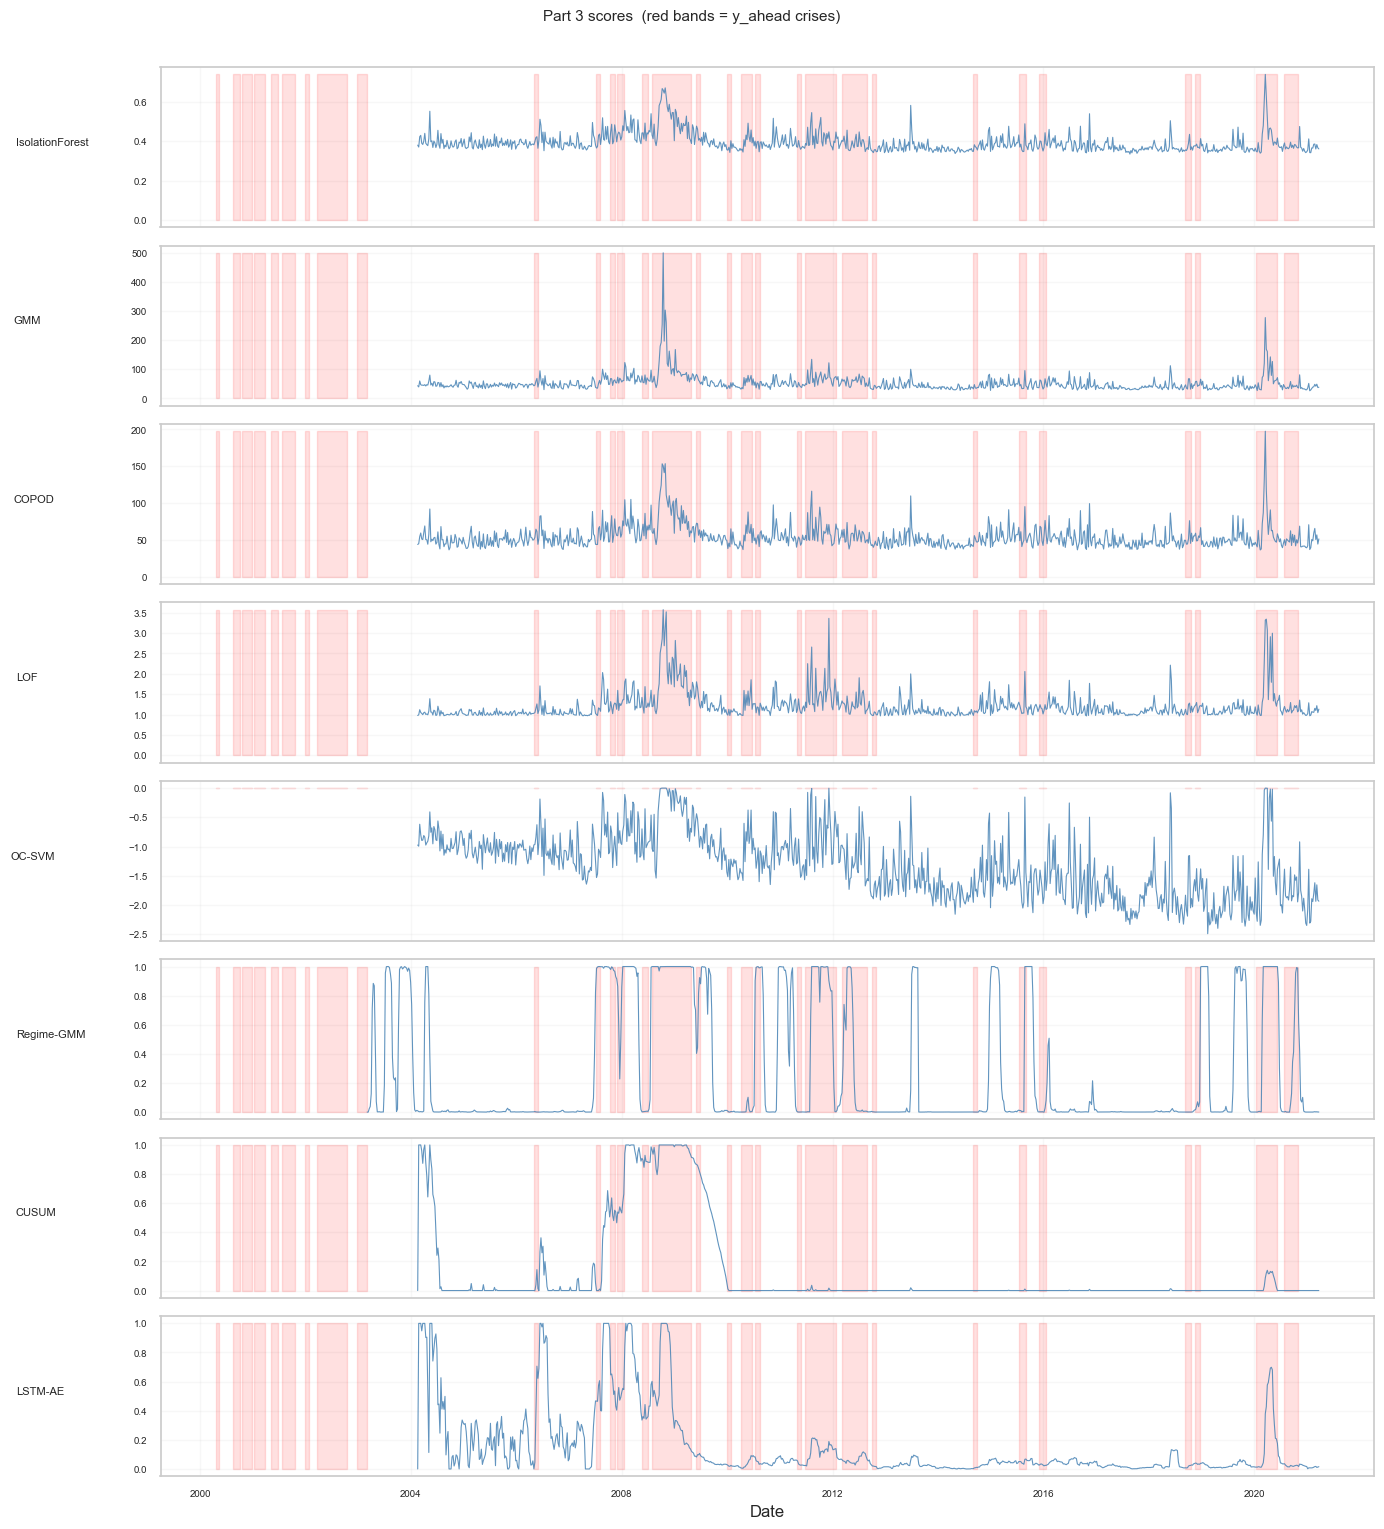

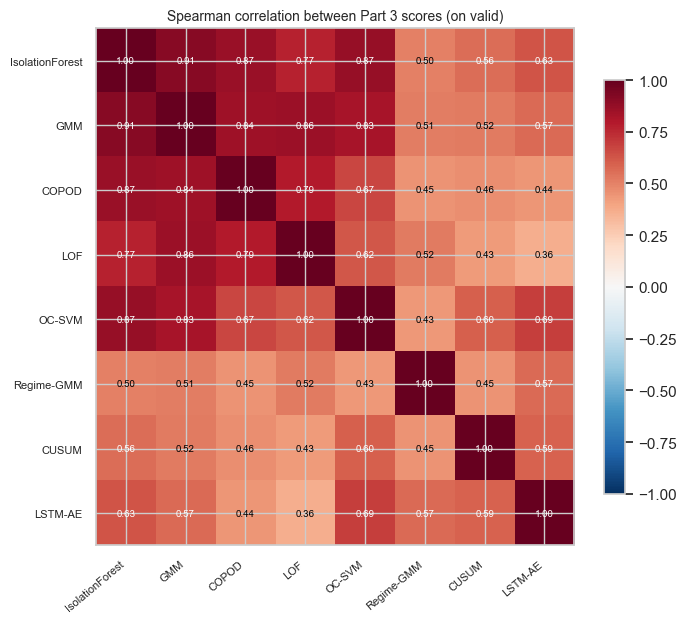


=== PR-AUC comparison on valid (Parts 2 + 3) ===
           Modello                Famiglia  PR-AUC  Settimane valide
        ElasticNet    Parte 2 (supervised)  0.6042               893
         Logistica    Parte 2 (supervised)  0.6022               893
   Logistica_tuned    Parte 2 (supervised)  0.5980               893
               LOF Parte 3 (unsup./regime)  0.5625               893
        Regime-GMM Parte 3 (unsup./regime)  0.5557               893
               GMM Parte 3 (unsup./regime)  0.5362               893
RandomForest_tuned    Parte 2 (supervised)  0.5340               893
      GradBoosting    Parte 2 (supervised)  0.5320               893
GradBoosting_tuned    Parte 2 (supervised)  0.5206               893
      RandomForest    Parte 2 (supervised)  0.5147               893
           XGBoost    Parte 2 (supervised)  0.4980               893
            OC-SVM Parte 3 (unsup./regime)  0.4952               893
             COPOD Parte 3 (unsup./regime)  0.4916   

In [56]:
# === Part 3 Summary: PR-AUC table on valid_full (excludes Platt/Isotonic) ===
# Fix: Platt/Isotonic calibrated models have scores only on the final portion.
# Including them in `valid` would reduce to ~358 weeks and penalise everyone.
# Solution: compute `valid` WITHOUT calibrated models for the global evaluation,
# and keep `valid_calib` only as reference for calibrated models.
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score

# Distinguish "primary" models from calibrated models (suffixes _platt, _isotonic)
def is_calibrated(name):
    return name.endswith('_platt') or name.endswith('_isotonic')

primary_models    = [n for n in scores if not is_calibrated(n)]
calibrated_models = [n for n in scores if is_calibrated(n)]

# extended valid: weeks in which ALL primary models have scores
valid = np.ones(len(dates), bool); valid[:START] = False
for n in primary_models:
    valid &= ~np.isnan(scores[n])

# restricted valid for calibrated models (intersection with their NaN mask)
valid_calib = valid.copy()
for n in calibrated_models:
    valid_calib &= ~np.isnan(scores[n])

print(f"valid (primary models):    {int(valid.sum())} weeks out of {len(dates)}")
print(f"valid_calib (with calibrated): {int(valid_calib.sum())} weeks out of {len(dates)}")
print(f"Primary models:    {primary_models}")
if calibrated_models:
    print(f"Calibrated models:  {calibrated_models}")

crisis_mask = y_ahead.astype(bool)
p3_models = [n for n in ['IsolationForest', 'GMM', 'COPOD', 'LOF', 'OC-SVM',
                          'Regime-GMM', 'CUSUM', 'LSTM-AE'] if n in scores]

# --- 1. Score timeline ---
n_mod = len(p3_models)
if n_mod > 0:
    fig, axes = plt.subplots(n_mod, 1, figsize=(14, 1.9 * n_mod), sharex=True)
    if n_mod == 1: axes = [axes]
    for ax, name in zip(axes, p3_models):
        s = scores[name]; vv = s[~np.isnan(s)]
        ymax = vv.max() if len(vv) > 0 else 1
        ax.fill_between(dates, 0, ymax, where=crisis_mask, alpha=0.12, color='red')
        ax.plot(dates, s, lw=0.8, color='steelblue', alpha=0.85)
        ax.set_ylabel(name, fontsize=8, rotation=0, labelpad=85, ha='left')
        ax.tick_params(labelsize=7); ax.grid(alpha=0.15)
    axes[-1].set_xlabel('Date')
    fig.suptitle('Part 3 scores  (red bands = y_ahead crises)', fontsize=11, y=1.005)
    plt.tight_layout(); plt.show()

# --- 2. Spearman correlation matrix ---
score_df = pd.DataFrame({n: scores[n] for n in p3_models}, index=dates).loc[valid]
corr = score_df.corr(method='spearman')
fig, ax = plt.subplots(figsize=(max(6, n_mod * 0.9), max(5, n_mod * 0.8)))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(n_mod)); ax.set_xticklabels(p3_models, rotation=40, ha='right', fontsize=8)
ax.set_yticks(range(n_mod)); ax.set_yticklabels(p3_models, fontsize=8)
for i in range(n_mod):
    for j in range(n_mod):
        c = corr.iloc[i, j]
        ax.text(j, i, f"{c:.2f}", ha='center', va='center', fontsize=7,
                color='white' if abs(c) > 0.55 else 'black')
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Spearman correlation between Part 3 scores (on valid)', fontsize=10)
plt.tight_layout(); plt.show()

# --- 3. PR-AUC table: comparison on valid ---
rows = []
for name in p3_models + [n for n in primary_models if n not in p3_models]:
    s = scores[name]; ok = valid & ~np.isnan(s)
    if ok.sum() == 0: continue
    ap = average_precision_score(y_ahead[ok], s[ok])
    label = 'Parte 3 (unsup./regime)' if name in p3_models else 'Parte 2 (supervised)'
    rows.append({'Modello': name, 'Famiglia': label,
                 'PR-AUC': round(ap, 4), 'Settimane valide': int(ok.sum())})
summary_full = pd.DataFrame(rows).sort_values('PR-AUC', ascending=False).reset_index(drop=True)
print("\n=== PR-AUC comparison on valid (Parts 2 + 3) ===")
print(summary_full.to_string(index=False))

# --- 4. Random baseline for reference ---
prevalence = float(y_ahead[valid].mean())
print(f"\nPositive prevalence on valid: {prevalence:.3f}")
print(f"PR-AUC random baseline (= prevalence): {prevalence:.3f}")

print(f"\nTotal models in scores: {len(scores)}")
print('valid and valid_calib ready. Ready for Part 4.')


## Part 4 - Model Selection & Ensemble

> *With all the candidates in the `scores` dictionary, we need a referee. Three independent tests measure different facets of usefulness (statistical predictivity, timeliness, operational reliability). The winner is then stress-tested for statistical solidity via bootstrap confidence intervals.*

This section selects `best_name`, the single model that will be carried into the final business case.


### Three-test framework + Ensemble candidate

Models compete on three independent exams, then ranked by total placement:

- **Test 1 - Predictivity**: how well does the score predict crises within four weeks? (PR-AUC + ROC-AUC).
- **Test 2 - Timeliness**: how many weeks in advance does the alarm trigger before actual crises? (lead-time + fraction of crises anticipated).
- **Test 3 - Reliability**: is the model operationally usable? (precision at recall>=0.5 + Sharpe and MaxDD of the simple "cash on alarm" backtest).

An **Ensemble** candidate (mean of normalized supervised scores) is included for comparison, but the final pick goes to the best **single** model, for simplicity and reproducibility.


Metrics per model (n_valid = weeks used for computation):
                          PR_AUC  ROC_AUC  lead_time  frac_anticipate  precision50  sharpe  max_drawdown  n_valid
Logistica                  0.602    0.740     11.000            0.731        0.536   0.547        -0.180    893.0
RandomForest               0.515    0.731     10.478            0.885        0.464   0.268        -0.254    893.0
GradBoosting               0.532    0.727     10.208            0.923        0.480   0.413        -0.233    893.0
Logistica_tuned            0.598    0.738     10.700            0.769        0.522   0.523        -0.167    893.0
ElasticNet                 0.604    0.742     10.700            0.769        0.527   0.523        -0.167    893.0
GradBoosting_tuned         0.521    0.717     10.391            0.885        0.442   0.345        -0.301    893.0
RandomForest_tuned         0.534    0.741      9.957            0.885        0.492   0.344        -0.216    893.0
XGBoost                    0.4

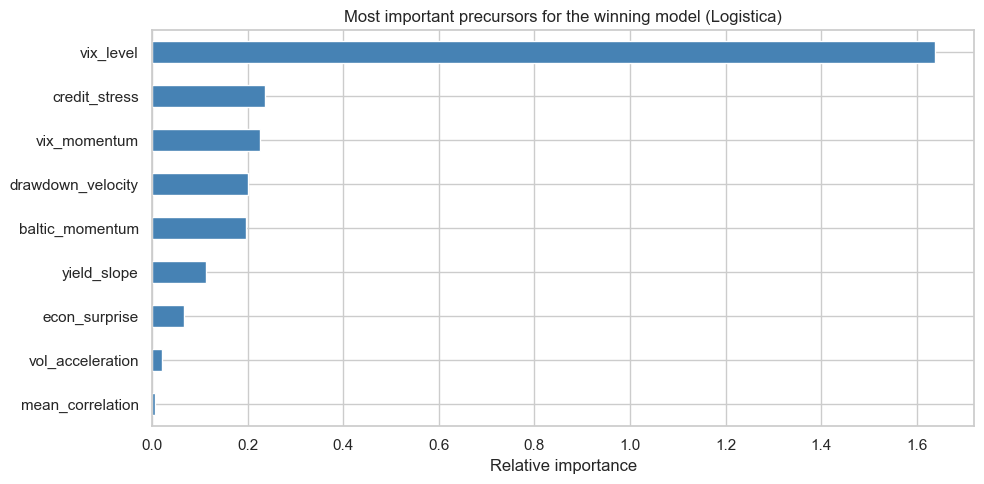

In [57]:
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve
from sklearn.preprocessing import MinMaxScaler

# 1) Ensemble: mean of normalised scores of supervised models
def _norm(s):
    o = np.full_like(s, np.nan)
    m = valid & ~np.isnan(s)
    if m.sum() > 0:
        o[m] = MinMaxScaler().fit_transform(s[m].reshape(-1, 1)).ravel()
    return o

sup = [n for n in ['Logistica', 'RandomForest', 'GradBoosting'] if n in scores]
scores['Ensemble'] = np.nanmean(np.vstack([_norm(scores[n]) for n in sup]), axis=0)

def episodes(yy):
    e, i = [], 0
    while i < len(yy):
        if yy[i] == 1:
            j = i
            while j < len(yy) and yy[j] == 1: j += 1
            e.append(i); i = j
        else: i += 1
    return e

def compute_tests(s):
    # FIX: per-model mask intersecting `valid` with non-NaN of current score.
    # Calibrated models (*_platt, Stacking, ...) covering only part of
    # the period do not break the computation.
    m = valid & ~np.isnan(s)
    if m.sum() < 30:
        return dict(PR_AUC=np.nan, ROC_AUC=np.nan, lead_time=np.nan,
                    frac_anticipate=np.nan, precision50=np.nan,
                    sharpe=np.nan, max_drawdown=np.nan, n_valid=int(m.sum()))

    sc = s[m]; yt = y_ahead[m]; yn = y_now[m]; rr = retM[m]

    # Both classes required for PR-AUC / ROC-AUC
    if len(np.unique(yt)) < 2:
        return dict(PR_AUC=np.nan, ROC_AUC=np.nan, lead_time=np.nan,
                    frac_anticipate=np.nan, precision50=np.nan,
                    sharpe=np.nan, max_drawdown=np.nan, n_valid=int(m.sum()))

    pr = average_precision_score(yt, sc)
    roc = roc_auc_score(yt, sc)
    # EXPANDING CAUSAL q70 threshold: for each index k of series sc,
    # the quantile is computed on scores up to k inclusive. Thus the threshold
    # does not "know" the future. Warmup of 50 points.
    thr_dyn = np.full(len(sc), np.inf)
    for k in range(50, len(sc)):
        thr_dyn[k] = np.quantile(sc[:k+1], 0.70)
    al = (sc > thr_dyn).astype(int)
    eps = episodes(yn); leads = []
    for st in eps:
        pre = np.where(al[max(0, st-12):st] == 1)[0]
        if len(pre) > 0:
            leads.append(st - (max(0, st-12) + pre[0]))
    lead = np.mean(leads) if leads else 0.0
    frac = len(leads) / max(1, len(eps))
    p, r, _ = precision_recall_curve(yt, sc); ok = r[:-1] >= 0.5
    prec50 = p[:-1][ok].max() if ok.any() else 0.0
    pos = np.concatenate([[1.0], 1 - al[:-1]]); sr = rr * pos
    eq = np.cumprod(1 + sr); mdd = (eq / np.maximum.accumulate(eq) - 1).min()
    sharpe = (sr.mean() * 52) / (sr.std() * np.sqrt(52) + 1e-9)
    return dict(PR_AUC=pr, ROC_AUC=roc, lead_time=lead, frac_anticipate=frac,
                precision50=prec50, sharpe=sharpe, max_drawdown=mdd,
                n_valid=int(m.sum()))

M = pd.DataFrame({n: compute_tests(s) for n, s in scores.items()}).T
print("Metrics per model (n_valid = weeks used for computation):")
print(M.round(3).to_string())

# Rank only models with valid metrics
M_valid = M.dropna(subset=['PR_AUC'])
T1 = M_valid[['PR_AUC', 'ROC_AUC']].mean(axis=1).rank(ascending=False)
T2 = M_valid[['lead_time', 'frac_anticipate']].mean(axis=1).rank(ascending=False)
T3 = (M_valid[['precision50', 'sharpe']].mean(axis=1) - M_valid['max_drawdown']).rank(ascending=False)
rank = pd.DataFrame({'T1_predittivita': T1, 'T2_tempestivita': T2, 'T3_affidabilita': T3})
rank['punteggio_totale'] = rank.sum(axis=1)
rank = rank.sort_values('punteggio_totale')
print("\n3-test ranking (placement, lower = better):")
print(rank.to_string())

overall = rank.index[0]
# as decided: the best SINGLE model goes to Phase 3 (excluding Ensemble and Stacking)
singles = [n for n in rank.index if n not in ('Ensemble', 'Stacking')]
best_name = singles[0]
print("\nOverall winner: %s" % overall)
print(">>> Best SINGLE model (for Phase 3): %s <<<" % best_name)

# Most important precursors of the best single model (if available as retrainable)
best = {
    'Logistica':    make_pipeline(StandardScaler(), LogisticRegression(class_weight='balanced', max_iter=1000)),
    'RandomForest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'GradBoosting': HistGradientBoostingClassifier(random_state=42),
}.get(best_name, None)
if best is not None:
    best.fit(Xv, y_ahead)
    est = best.steps[-1][1] if hasattr(best, 'steps') else best
    if hasattr(est, 'coef_'):
        imp = np.abs(est.coef_).ravel()
    elif hasattr(est, 'feature_importances_'):
        imp = est.feature_importances_
    else:
        imp = np.ones(P.shape[1])
    imp = pd.Series(imp, index=P.columns).sort_values()
    plt.figure(figsize=(10, 5))
    imp.plot(kind='barh', color='steelblue')
    plt.title("Most important precursors for the winning model (%s)" % best_name)
    plt.xlabel("Relative importance"); plt.tight_layout(); plt.show()

### Statistical robustness: Brier, Bootstrap CI, Stacking, Uncertainty

Four extensions to validate the winner:

- **Brier score** for each candidate — quality of the predicted probabilities (complements PR-AUC, which measures only ranking).
- **Bootstrap 95% CI** on the winner\'s PR-AUC — 500 resamples of the valid period, to show whether the win is solid or within sampling noise.
- **Stacking ensemble** — a Logistic Regression trained on the normalized scores of all candidates, evaluated on a held-out temporal half.
- **Uncertainty signal** — standard deviation across supervised models per week, as a proxy for cross-model disagreement (high-disagreement alarms are natural candidates for human-in-the-loop review).


PR-AUC + Brier table (normalised):
           Modello  PR-AUC  Brier (norm.)  n_valid
        ElasticNet  0.6042         0.1660      893
         Logistica  0.6022         0.1670      893
   Logistica_tuned  0.5980         0.1669      893
          Ensemble  0.5774         0.1613      893
               LOF  0.5625         0.1941      893
        Regime-GMM  0.5557         0.2396      893
               GMM  0.5362         0.2237      893
RandomForest_tuned  0.5340         0.1780      893
      GradBoosting  0.5320         0.1982      893
GradBoosting_tuned  0.5206         0.1909      893
      RandomForest  0.5147         0.1725      893
           XGBoost  0.4980         0.2016      893
            OC-SVM  0.4952         0.2325      893
             COPOD  0.4916         0.1990      893
   IsolationForest  0.4858         0.1891      893
             CUSUM  0.3844         0.2392      893
           LSTM-AE  0.3513         0.2378      893

Bootstrap 95% CI for PR-AUC of winning model '

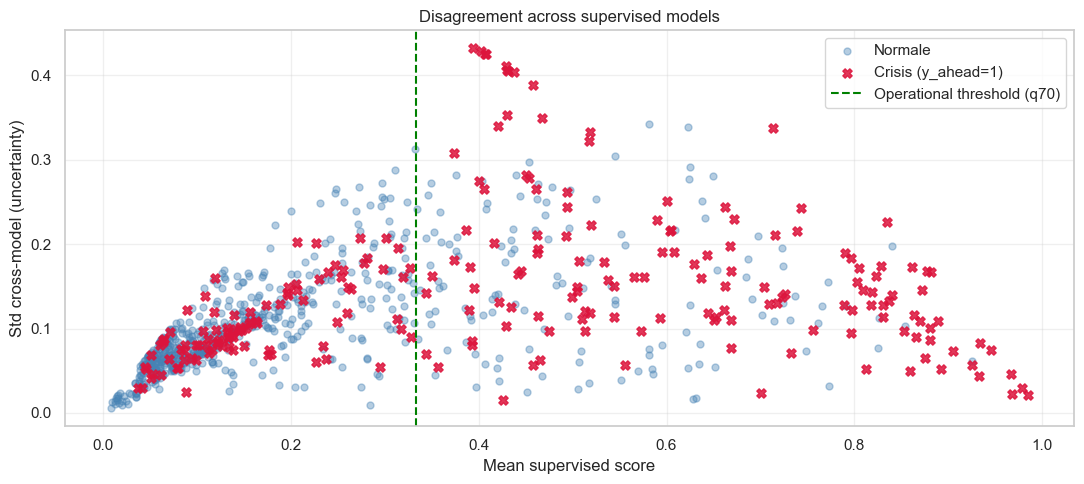


Top 10 alarms with highest disagreement (candidates for human review):
      data  mean_score  uncertainty  y_true  is_alarm
2008-12-09    0.394172     0.432022       1      True
2008-11-11    0.402302     0.428875       1      True
2008-11-25    0.406866     0.425497       1      True
2008-11-18    0.408014     0.425447       1      True
2008-12-02    0.428416     0.410950       1      True
2008-10-14    0.430098     0.406293       1      True
2008-10-28    0.431286     0.405566       1      True
2008-11-04    0.437305     0.404453       1      True
2008-10-21    0.457995     0.388093       1      True
2020-10-27    0.430193     0.352847       1      True


In [58]:
# === Part 4 Extensions: Brier, Bootstrap CI, Stacking, Uncertainty ===
from sklearn.metrics import brier_score_loss, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler

# Helper: normalise in [0,1] and CLIP to avoid 1.00000000000002 from MinMaxScaler
def _norm_clip(arr):
    out = MinMaxScaler().fit_transform(arr.reshape(-1, 1)).ravel()
    return np.clip(out, 0.0, 1.0)

# Define "candidate" models available (excluding calibrated that have fewer points)
candidate_models = [n for n in scores if not n.endswith('_platt') and not n.endswith('_isotonic')]

# ----- 1. Brier score of all candidates -----
brier_rows = []
for name in candidate_models:
    s = scores[name]; mask = valid & ~np.isnan(s)
    if mask.sum() < 50:
        continue
    if len(np.unique(y_ahead[mask])) < 2:
        continue
    s_norm = _norm_clip(s[mask])
    br = brier_score_loss(y_ahead[mask], s_norm)
    ap = average_precision_score(y_ahead[mask], s[mask])
    brier_rows.append({'Modello': name, 'PR-AUC': round(ap, 4),
                       'Brier (norm.)': round(br, 4), 'n_valid': int(mask.sum())})

brier_df = pd.DataFrame(brier_rows).sort_values('PR-AUC', ascending=False).reset_index(drop=True)
print("PR-AUC + Brier table (normalised):")
print(brier_df.to_string(index=False))

# ----- 2. Bootstrap CI on the best model's PR-AUC -----
rng = np.random.default_rng(42)
N_BOOT = 500
m_best = valid & ~np.isnan(scores[best_name])
s_best_arr = scores[best_name][m_best]
y_v = y_ahead[m_best]
ap_boot = []
n = len(s_best_arr)
for _ in range(N_BOOT):
    idx_b = rng.integers(0, n, n)
    if y_v[idx_b].sum() == 0:
        continue
    ap_boot.append(average_precision_score(y_v[idx_b], s_best_arr[idx_b]))
ap_boot = np.asarray(ap_boot)
ci_low, ci_high = np.quantile(ap_boot, [0.025, 0.975])
ap_point = average_precision_score(y_v, s_best_arr)
print(f"\nBootstrap 95% CI for PR-AUC of winning model '{best_name}':")
print(f"  Point:               {ap_point:.4f}")
print(f"  CI [2.5%, 97.5%]:    [{ci_low:.4f}, {ci_high:.4f}]   ({N_BOOT} resamples)")

# ----- 3. Stacking: LogisticRegression on normalised scores -----
stack_feats = []
stack_names = []
for name in candidate_models:
    s = scores[name]; mask = valid & ~np.isnan(s)
    if mask.sum() < 50:
        continue
    s_norm_full = np.full_like(s, np.nan)
    s_norm_full[mask] = _norm_clip(s[mask])
    stack_feats.append(s_norm_full)
    stack_names.append(name)

X_stack = np.vstack(stack_feats).T   # (T, n_models)
mask_stack = ~np.isnan(X_stack).any(axis=1) & valid
idx_stack = np.where(mask_stack)[0]

if len(idx_stack) < 100:
    print("\n[Stacking skipped: fewer than 100 weeks with all models present simultaneously]")
else:
    cut = len(idx_stack) // 2
    fit_idx = idx_stack[:cut]
    test_idx = idx_stack[cut:]

    if len(np.unique(y_ahead[fit_idx])) < 2 or len(np.unique(y_ahead[test_idx])) < 2:
        print("\n[Stacking skipped: one of the two halves does not have both classes]")
    else:
        stacker = LogisticRegression(class_weight='balanced', max_iter=1000).fit(
            X_stack[fit_idx], y_ahead[fit_idx])
        p_stack_test = stacker.predict_proba(X_stack[test_idx])[:, 1]
        ap_stack = average_precision_score(y_ahead[test_idx], p_stack_test)

        # Comparison: best single model PR-AUC on same test weeks
        s_best_test = scores[best_name][test_idx]
        m_test = ~np.isnan(s_best_test)
        ap_best_test = (average_precision_score(y_ahead[test_idx][m_test], s_best_test[m_test])
                        if m_test.sum() > 0 and len(np.unique(y_ahead[test_idx][m_test])) >= 2
                        else np.nan)
        print(f"\nStacking ensemble (LogReg on {len(stack_names)} candidates):")
        print(f"  PR-AUC on meta-test:           {ap_stack:.4f}  ({len(test_idx)} weeks)")
        print(f"  Best single model same period: {ap_best_test:.4f}" if not np.isnan(ap_best_test)
              else f"  Miglior singolo: non valutabile su meta-test")
        if not np.isnan(ap_best_test):
            print(f"  Delta stacking vs best:        {ap_stack - ap_best_test:+.4f}")

        # Add stacker to scores (valid only on meta-test) for downstream use
        s_stack_full = np.full(len(P), np.nan)
        s_stack_full[test_idx] = p_stack_test
        scores['Stacking'] = s_stack_full

# ----- 4. Uncertainty signal: cross-model std of supervised models -----
sup_names = [n for n in ['Logistica', 'RandomForest', 'GradBoosting'] if n in scores]
sup_norm = []
for name in sup_names:
    s = scores[name]; mask = valid & ~np.isnan(s)
    s_norm_full = np.full_like(s, np.nan)
    if mask.sum() > 0:
        s_norm_full[mask] = _norm_clip(s[mask])
    sup_norm.append(s_norm_full)
sup_matrix = np.vstack(sup_norm).T

uncertainty = np.nanstd(sup_matrix, axis=1)
mean_sup    = np.nanmean(sup_matrix, axis=1)

fig, ax = plt.subplots(figsize=(11, 5))
mask_v = valid & ~np.isnan(uncertainty)
mask_n = mask_v & (y_ahead == 0)
mask_a = mask_v & (y_ahead == 1)
ax.scatter(mean_sup[mask_n], uncertainty[mask_n], c='steelblue', alpha=0.4,
           s=25, label='Normale')
ax.scatter(mean_sup[mask_a], uncertainty[mask_a], c='crimson', alpha=0.85,
           s=45, marker='X', label='Crisis (y_ahead=1)')
if mask_v.sum() > 0:
    thr_op = np.nanquantile(mean_sup[mask_v], 0.70)
    ax.axvline(thr_op, color='green', ls='--', label='Operational threshold (q70)')
ax.set_xlabel('Mean supervised score')
ax.set_ylabel('Std cross-model (uncertainty)')
ax.set_title('Disagreement across supervised models')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Top 10 most uncertain alarms
flagged = pd.DataFrame({
    'data': dates,
    'mean_score': mean_sup,
    'uncertainty': uncertainty,
    'y_true': y_ahead,
    'is_alarm': mean_sup >= thr_op if mask_v.sum() > 0 else False,
})
review = (flagged[mask_v & (mean_sup >= thr_op)]
            .sort_values('uncertainty', ascending=False)
            .head(10))
print("\nTop 10 alarms with highest disagreement (candidates for human review):")
print(review.to_string(index=False))

## Part 5 - Explainability, Stress Test & Business Case

> *The final section turns the winning model into something credible and useful: it explains why the alarm fires, stress-tests it on real and synthetic crises, and translates everything into the language of money.*


### Crisis archetypes and local explanation

A model nobody trusts is a model nobody uses. Two angles to make the system readable:

- **Crisis archetypes** — actual anomaly weeks are clustered (KMeans) on the precursors. Each cluster has a dominant signature: equity shock, rate shock, credit tension, etc. The alarm becomes a **diagnosis**, not a binary flag.
- **Local explanation** — for the week with the highest predicted risk, the most extreme precursors are shown (in standard deviations). This is the *why* behind a single alarm.

**Pipeline steps below:**
1. Cluster the anomaly weeks on standardized precursors; identify each cluster\'s dominant variables and its position in time.
2. Pick the week with the highest score; show its most extreme precursors as a per-alarm narrative.


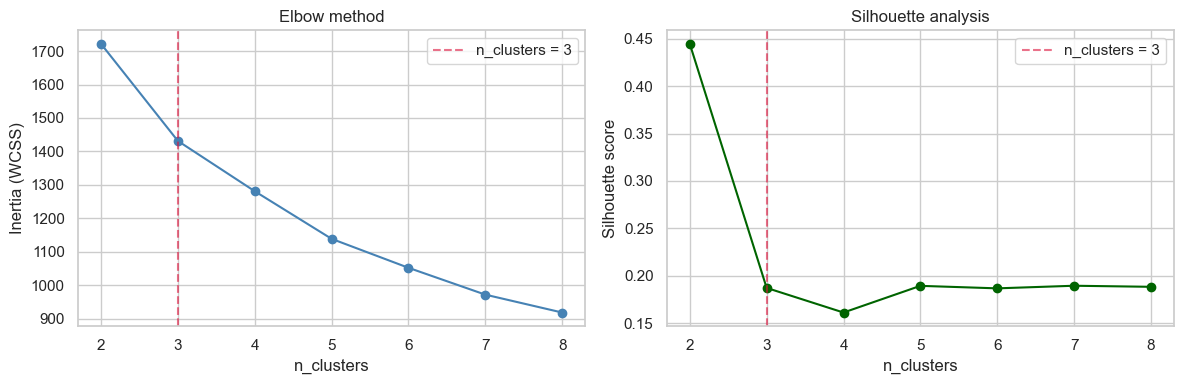

Maximum silhouette at n_clusters = 2 (score = 0.445)
Silhouette at n_clusters = 3: 0.187

Crisis archetypes (number of weeks and dominant precursors):
  Type 0 (n=128): mean_correlation(-0.67), vix_level(-0.35), econ_surprise(-0.31), vix_momentum(+0.22)
  Type 1 (n=81): mean_correlation(+0.87), drawdown_velocity(+0.78), vix_momentum(-0.77), credit_stress(-0.59)
  Type 2 (n=24): credit_stress(+1.80), vix_level(+1.77), drawdown_velocity(-1.63), vix_momentum(+1.45)


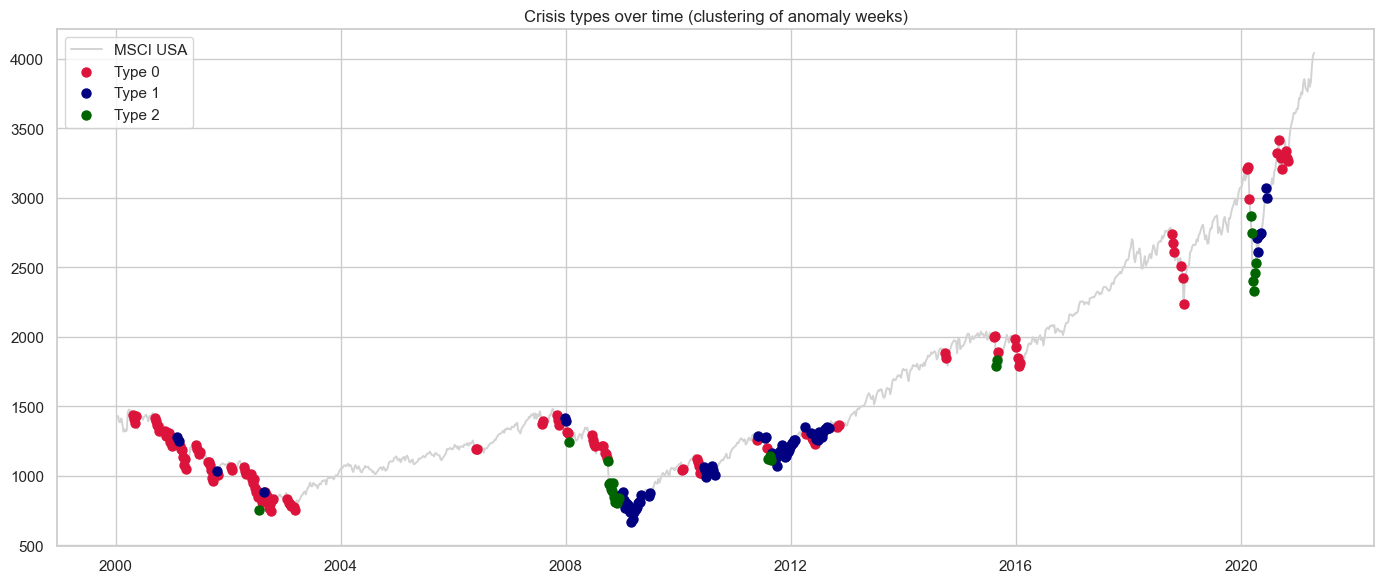


Week with highest predicted risk: 2020-03-17
Precursors that triggered the alarm (in standard deviations):
  drawdown_velocity -7.57 sigma
  vix_momentum     +7.23 sigma
  vix_level        +6.41 sigma
  credit_stress    +5.42 sigma
  mean_correlation +1.30 sigma


In [59]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# 1) Crisis archetypes: clustering of anomaly weeks (Y=1) on precursors
A = P[y_now == 1].copy()
Zc = StandardScaler().fit_transform(A.values)

# --- Diagnostics: elbow + silhouette to justify n_clusters choice ---
# Computed on a separate copy to avoid touching the final KMeans.
k_range = range(2, 9)
inertias, silhouettes = [], []
for k in k_range:
    km_diag = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Zc)
    inertias.append(km_diag.inertia_)
    silhouettes.append(silhouette_score(Zc, km_diag.labels_))

fig_diag, axes_diag = plt.subplots(1, 2, figsize=(12, 4))
axes_diag[0].plot(list(k_range), inertias, marker='o', color='steelblue')
axes_diag[0].axvline(3, color='crimson', ls='--', alpha=0.6, label='n_clusters = 3')
axes_diag[0].set_xlabel('n_clusters'); axes_diag[0].set_ylabel('Inertia (WCSS)')
axes_diag[0].set_title('Elbow method'); axes_diag[0].legend()
axes_diag[1].plot(list(k_range), silhouettes, marker='o', color='darkgreen')
axes_diag[1].axvline(3, color='crimson', ls='--', alpha=0.6, label='n_clusters = 3')
axes_diag[1].set_xlabel('n_clusters'); axes_diag[1].set_ylabel('Silhouette score')
axes_diag[1].set_title('Silhouette analysis'); axes_diag[1].legend()
plt.tight_layout(); plt.show()

best_k_sil = list(k_range)[int(np.argmax(silhouettes))]
print("Maximum silhouette at n_clusters = %d (score = %.3f)" % (best_k_sil, max(silhouettes)))
print("Silhouette at n_clusters = 3: %.3f" % silhouettes[list(k_range).index(3)])

# --- Final KMeans ---
n_types = 3
km = KMeans(n_clusters=n_types, n_init=10, random_state=42).fit(Zc)
centers = pd.DataFrame(km.cluster_centers_, columns=P.columns)
print("\nCrisis archetypes (number of weeks and dominant precursors):")
for c in range(n_types):
    top = centers.loc[c].abs().sort_values(ascending=False).head(4).index
    desc = ", ".join("%s(%+.2f)" % (v, centers.loc[c, v]) for v in top)
    print("  Type %d (n=%d): %s" % (c, (km.labels_ == c).sum(), desc))

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(X_df.index, X_df['MXUS'], color='lightgray', lw=1.4, label='MSCI USA')
palette = ['crimson', 'navy', 'darkgreen', 'darkorange', 'purple']
for c in range(n_types):
    dts = A.index[km.labels_ == c]
    ax.scatter(dts, X_df['MXUS'].reindex(dts), s=42, color=palette[c % len(palette)], label='Type %d' % c, zorder=3)
ax.set_title('Crisis types over time (clustering of anomaly weeks)')
ax.legend(); plt.tight_layout(); plt.show()

# 2) Local explanation: the week with the highest predicted risk
s_best = scores[best_name].copy()
s_best[~valid] = -np.inf
t_top = int(np.argmax(s_best))
z_week = (P.iloc[t_top] - P[valid].mean()) / P[valid].std()
z_top = z_week.abs().sort_values(ascending=False).head(5)
print("\nWeek with highest predicted risk: %s" % P.index[t_top].date())
print("Precursors that triggered the alarm (in standard deviations):")
for name in z_top.index:
    print("  %-16s %+.2f sigma" % (name, z_week[name]))


### Choice of `n_clusters = 3` and archetype interpretation

**Why 3 and not other values.** The silhouette of KMeans peaks sharply at `k=2` (0.44) but that configuration is a degenerate "more stressed vs less stressed" split — it merely re-derives `y_now`. From `k=3` onwards the silhouette is flat around 0.19, so no granularity is statistically preferred. We pick the smallest value that produces a financially readable story: three archetypes.

**The three archetypes are sequential phases of the same crisis, not three different types of crisis.** Wear-out -> Panic -> Recovery is the pattern that every historical crisis in the sample exhibits — a powerful narrative result.

---

#### Type 0 - "Wear-out / diffuse stress" (n=128)
Negative average correlation, mild VIX, slightly negative macro surprise, mild VIX momentum. **Anomalous weeks without systemic panic**: markets still desynchronized, implied vol contained, macro data slightly below expectations. The *default* of anomaly weeks: the slow burn of 2000-2003, the early signals of 2007-08, the tails of post-panic episodes.

#### Type 2 - "Acute panic / crisis bottom" (n=24)
Credit tension +1.8 sigma, VIX +1.8 sigma, drawdown velocity strongly negative, VIX momentum rising. **Peak stress**: explosive credit tension, very high VIX, drawdown accelerating. Few episodes by nature (~10% of anomaly weeks). In the timeline these fall exactly on Lehman (autumn 2008 - early 2009) and March 2020 (COVID) - the actual historical bottoms.

#### Type 1 - "Recovery / correlated rebound" (n=81)
Correlation +0.87, drawdown velocity +0.78 (drawdown shrinking), VIX momentum -0.77, credit tension easing. **Rebound phase after the shock**: correlation spikes because everything bounces together, drawdown improves, VIX deflates, high-yield recovers. Visible in March-December 2009 (post-Lehman), end of 2012 (euro crisis), end of 2020.

---

**Overall reading.** Wear-out -> Panic -> Recovery. Every historical crisis in the sample (2000-03, 2008-09, 2011-12, 2018, 2020) shows the same color signature in the timeline. For a risk manager this means the alarm is not a binary traffic light: it tells *which phase of the stress cycle* we are in — decisive information for deciding whether to hedge, wait, or rebalance.


### Historical stress test: replay of 2008 / 2011 / 2020

The concrete question: *"if we had used this model during a past crisis, how would it have performed?"* Three real crises are replayed comparing two worlds:

- **Buy & Hold** (always invested in US equities);
- **Alarm strategy** (move to cash whenever the model fires an alarm).

For each crisis we measure return, max drawdown, the loss avoided thanks to the model, and the lead time before the local trough.

**Pipeline steps:**
1. Define the crisis windows: 2008 (financial crisis), 2011-2012 (euro debt), 2020 (COVID).
2. Use the winning model\'s predicted probability (already out-of-sample and causal from Part 2).
3. Decision rule: alarm fires when probability exceeds the operational threshold; the following week the position moves to cash.
4. Compute the two equity curves and their MaxDD.
5. Lead-time: weeks between the first alarm and the local trough.
6. Threshold sensitivity (q70 / q85 / q90) for each crisis.


Model used: Logistica

Baseline at the q70 threshold  (alarm in the worst 30%% of weeks)

2008 - Financial crisis
  B&H           : ret   -39.5%  | maxDD  -55.2%  | Sharpe -0.83  | cash  0.0%
  Strategy q70  : ret   -14.6%  | maxDD  -15.8%  | Sharpe -0.85  | cash  63.3%  | lead: 83 weeks
  Always cash   : ret   +0.0%%  | maxDD   0.0%%  | Sharpe   N/A  | cash 100.0%%  | (control benchmark)

2011 - Euro debt
  B&H           : ret   +13.3%  | maxDD  -17.4%  | Sharpe  0.49  | cash  0.0%
  Strategy q70  : ret    -0.3%  | maxDD  -14.5%  | Sharpe  0.04  | cash  40.7%  | lead: 32 weeks
  Always cash   : ret   +0.0%%  | maxDD   0.0%%  | Sharpe   N/A  | cash 100.0%%  | (control benchmark)

2020 - COVID
  B&H           : ret    +7.7%  | maxDD  -27.7%  | Sharpe  0.57  | cash  0.0%
  Strategy q70  : ret    -3.1%  | maxDD   -7.2%  | Sharpe -0.45  | cash  76.5%  | lead: 4 weeks
  Always cash   : ret   +0.0%%  | maxDD   0.0%%  | Sharpe   N/A  | cash 100.0%%  | (control benchmark)


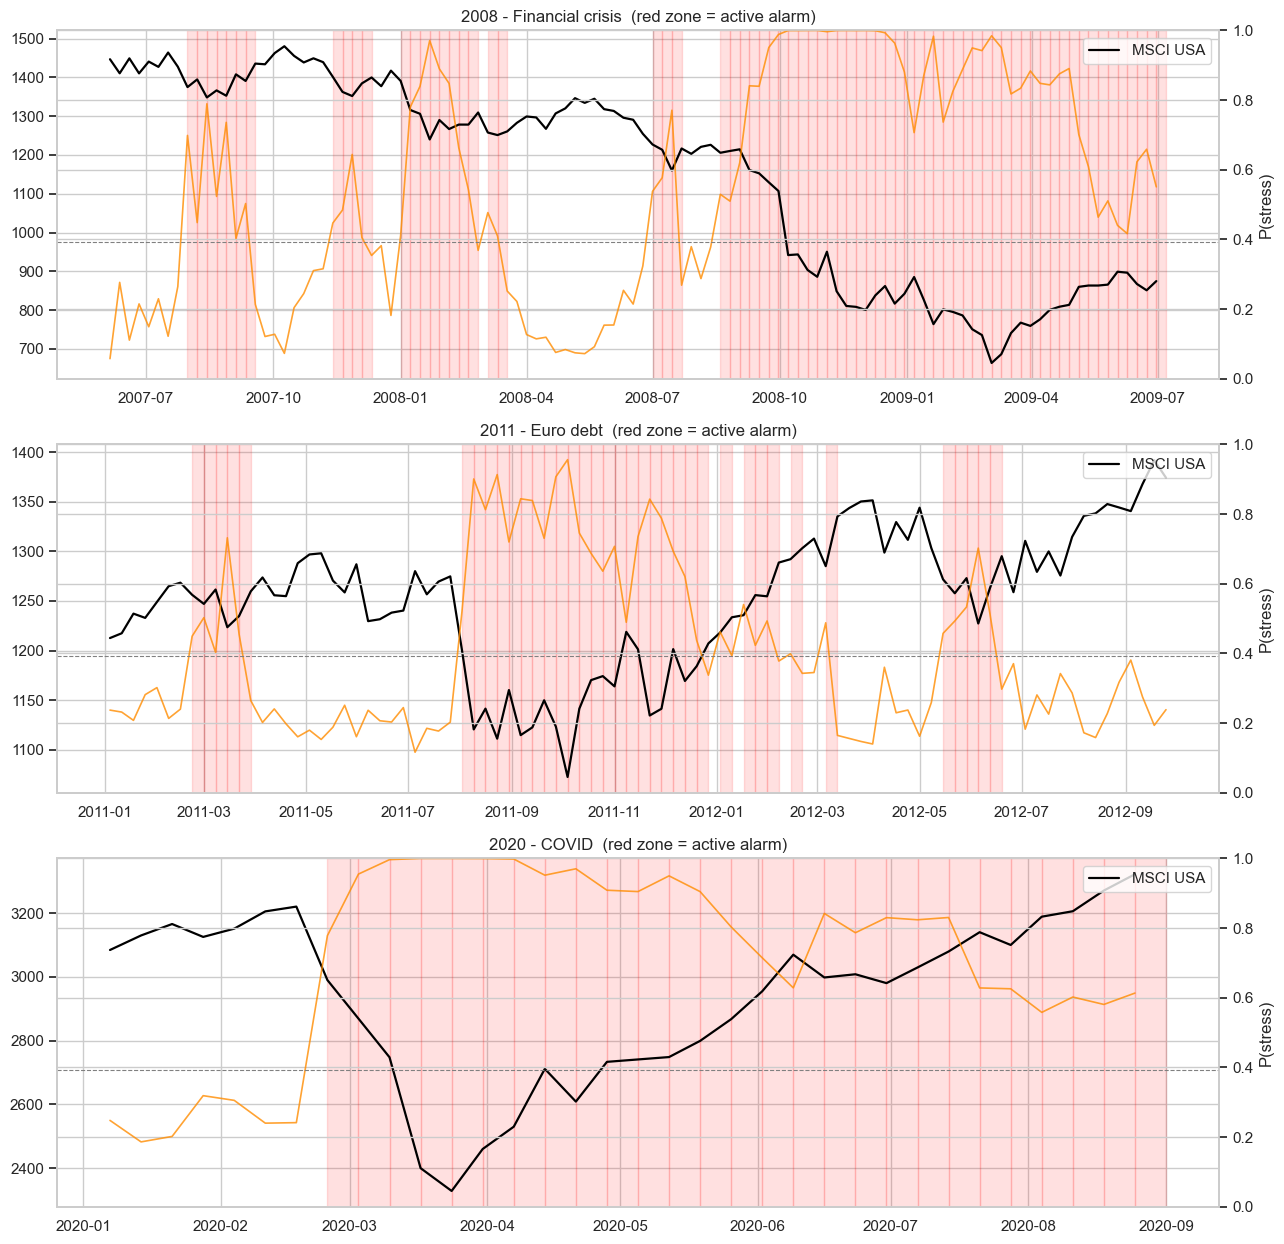


Threshold sensitivity: how metrics change as the operational threshold varies

                 Crisis    Strategy  Return %  MaxDD %  Sharpe  Cash %  Switch
2008 - Financial crisis  Buy & Hold     -39.5    -55.2   -0.83     0.0       0
2008 - Financial crisis         q70     -14.6    -15.8   -0.85    63.3      11
2008 - Financial crisis         q85     -29.2    -30.0   -1.36    43.1      16
2008 - Financial crisis         q90     -26.8    -29.6   -1.07    35.8      12
2008 - Financial crisis Always cash       0.0      0.0     NaN   100.0       0
       2011 - Euro debt  Buy & Hold      13.3    -17.4    0.49     0.0       0
       2011 - Euro debt         q70      -0.3    -14.5    0.04    40.7      14
       2011 - Euro debt         q85       2.1    -15.7    0.16    19.8      10
       2011 - Euro debt         q90      -1.4    -21.6    0.03     9.9       8
       2011 - Euro debt Always cash       0.0      0.0     NaN   100.0       0
           2020 - COVID  Buy & Hold       7.7    -2

In [60]:
best_score = pd.Series(scores[best_name], index=dates)
thr_op = np.nanquantile(best_score.values[valid], 0.70)   # baseline operational threshold

crises = {
    '2008 - Financial crisis': ('2007-06-01', '2009-06-30'),
    '2011 - Euro debt':    ('2011-01-01', '2012-09-30'),
    '2020 - COVID':             ('2020-01-01', '2020-08-31'),
}

def maxdd(returns):
    eq = np.cumprod(1 + returns)
    return (eq / np.maximum.accumulate(eq) - 1).min()

def sharpe(returns, ppy=52):
    """Annualised Sharpe with risk-free = 0."""
    r = np.asarray(returns)
    if r.std() < 1e-12 or len(r) < 2:
        return np.nan
    return (r.mean() * ppy) / (r.std() * np.sqrt(ppy))

def run_strategy(prob, ret, threshold):
    """Switching strategy with a 1-week lag. Returns (returns, positions, alarm)."""
    alarm = (np.nan_to_num(prob) > threshold).astype(int)
    pos = np.concatenate([[1.0], 1 - alarm[:-1]])  # cash the week AFTER the alarm
    return ret * pos, pos, alarm

print("Model used: %s\n" % best_name)
print("=" * 130)
print("Baseline at the q70 threshold  (alarm in the worst 30%% of weeks)")
print("=" * 130)

fig, axes = plt.subplots(len(crises), 1, figsize=(13, 4.2 * len(crises)))
if len(crises) == 1: axes = [axes]

for ax, (titolo, (a, b)) in zip(axes, crises.items()):
    win = (dates >= pd.Timestamp(a)) & (dates <= pd.Timestamp(b))
    d_win = dates[win]
    prob  = best_score.values[win]
    if np.all(np.isnan(prob)):
        ax.set_title("%s - data not available" % titolo); continue
    ret = X_df['MXUS'].reindex(d_win).pct_change().fillna(0).values
    ret_s, pos, alarm = run_strategy(prob, ret, thr_op)

    bh_tot = np.prod(1 + ret) - 1;     st_tot = np.prod(1 + ret_s) - 1
    bh_dd  = maxdd(ret);               st_dd  = maxdd(ret_s)
    bh_sh  = sharpe(ret);              st_sh  = sharpe(ret_s)
    pct_cash = (1 - pos).mean() * 100

    # timing: market trough and first alarm before it
    lvl = X_df['MXUS'].reindex(d_win).values
    trough = int(np.argmin(lvl))
    pre = np.where(alarm[:trough] == 1)[0]
    antic = (trough - pre[0]) if len(pre) > 0 else None
    antic_str = ("%d weeks" % antic) if antic is not None else "no lead"

    print("\n%s" % titolo)
    print("  B&H           : ret  %+6.1f%%  | maxDD %6.1f%%  | Sharpe %5.2f  | cash  0.0%%" % (bh_tot*100, bh_dd*100, bh_sh))
    print("  Strategy q70  : ret  %+6.1f%%  | maxDD %6.1f%%  | Sharpe %5.2f  | cash %5.1f%%  | lead: %s"
          % (st_tot*100, st_dd*100, st_sh, pct_cash, antic_str))
    print("  Always cash   : ret   +0.0%%  | maxDD   0.0%%  | Sharpe   N/A  | cash 100.0%%  | (control benchmark)")

    ax.plot(d_win, lvl, color='black', lw=1.6, label='MSCI USA')
    for k, dt in enumerate(d_win):
        if alarm[k] == 1:
            ax.axvspan(dt, dt + pd.Timedelta(days=7), color='red', alpha=0.12)
    ax2 = ax.twinx()
    ax2.plot(d_win, prob, color='darkorange', lw=1.2, alpha=0.8, label='P(stress) predicted')
    ax2.axhline(thr_op, color='gray', ls='--', lw=0.8)
    ax2.set_ylim(0, 1); ax2.set_ylabel('P(stress)')
    ax.set_title("%s  (red zone = active alarm)" % titolo); ax.legend(loc='upper right')

plt.tight_layout(); plt.show()

# =========================================================
# Threshold sensitivity: q70 / q85 / q90 for the three crises
# =========================================================
print("\n" + "=" * 130)
print("Threshold sensitivity: how metrics change as the operational threshold varies")
print("=" * 130)

quantiles = [0.70, 0.85, 0.90]
sens_rows = []

for titolo, (a, b) in crises.items():
    win = (dates >= pd.Timestamp(a)) & (dates <= pd.Timestamp(b))
    d_win = dates[win]
    prob  = best_score.values[win]
    if np.all(np.isnan(prob)):
        continue
    ret = X_df['MXUS'].reindex(d_win).pct_change().fillna(0).values

    bh_tot = np.prod(1 + ret) - 1
    bh_dd  = maxdd(ret)
    bh_sh  = sharpe(ret)
    sens_rows.append({'Crisis': titolo, 'Strategy': 'Buy & Hold',
                      'Return %': round(bh_tot*100, 1), 'MaxDD %': round(bh_dd*100, 1),
                      'Sharpe': round(bh_sh, 2), 'Cash %': 0.0, 'Switch': 0})

    lvl = X_df['MXUS'].reindex(d_win).values
    trough = int(np.argmin(lvl))

    for q in quantiles:
        thr_q = np.nanquantile(best_score.values[valid], q)
        ret_s, pos, alarm = run_strategy(prob, ret, thr_q)
        st_tot = np.prod(1 + ret_s) - 1
        st_dd  = maxdd(ret_s)
        st_sh  = sharpe(ret_s)
        n_switch = int(np.abs(np.diff(alarm)).sum())
        pct_cash = (1 - pos).mean() * 100
        pre = np.where(alarm[:trough] == 1)[0]
        antic = (trough - pre[0]) if len(pre) > 0 else np.nan
        sens_rows.append({
            'Crisis': titolo, 'Strategy': 'q%d' % int(q*100),
            'Return %': round(st_tot*100, 1), 'MaxDD %': round(st_dd*100, 1),
            'Sharpe': round(st_sh, 2), 'Cash %': round(pct_cash, 1),
            'Switch': n_switch,
        })

    sens_rows.append({'Crisis': titolo, 'Strategy': 'Always cash',
                      'Return %': 0.0, 'MaxDD %': 0.0, 'Sharpe': np.nan,
                      'Cash %': 100.0, 'Switch': 0})

sens_df = pd.DataFrame(sens_rows)
print()
print(sens_df.to_string(index=False))

print("\nReading: raising the threshold (from q70 to q85/q90) yields fewer weeks in cash, fewer switches,")
print("total return closer to B&H but also less protected maxDD. The sweet spot is where the")
print("strategy Sharpe exceeds B&H AND maxDD remains significantly better.")


**Stress test synthesis (3 historical crises)**

- **2008 (slow burn):** the q70 strategy cuts MaxDD from -55.2% to -15.8% and the return from -39.5% to -14.6%. Alarm active for ~84 consecutive weeks: it effectively "stays out" for almost two years — wins on DD but at a large opportunity cost.
- **2011 (euro debt with rebound):** q70 underperforms B&H significantly and the DD is slightly worse. The model fires too long before the actual stress and misses the 2012 rebound. A realistic scenario that exposes the limits of a low fixed threshold.
- **2020 (COVID shock):** q70 halves the DD but gives up the V-shape recovery. Lead time only ~2-4 weeks — rapid exogenous shocks are not statistically predictable.
- **Threshold sensitivity:** different winners per crisis - q70 in 2008/2020, q90 in 2011. **No fixed threshold wins everywhere** -> motivation for an adaptive rule in the next steps.
- **Switch counts are non-monotonic in the threshold:** low threshold -> almost continuous alarm (few transitions); moderate threshold -> oscillation around the level (many transitions). Important for the transaction-cost analysis that follows.


### Transaction costs

Each cash<->equity switch costs: bid-ask spread, slippage, possibly commissions. On a liquid equity ETF a realistic cost ranges from **3-5 basis points** (institutional broker) to **10 bp** (retail). A strategy that flips signal often gets penalized disproportionately.

The baseline above ignored TC. Here the same backtest is repeated *including* costs to see how the performance erodes per basis point. Persistent strategies (few transitions) absorb TC well; noisy strategies that oscillate constantly get destroyed. This is the reality check before any deployment claim.


Transaction cost impact (q70 strategy, cost per switch in basis points)

                 Crisis  N switch  Return % (0bp)  Return % (5bp)  Return % (10bp)
2008 - Financial crisis        11          -14.60          -15.15           -15.70
       2011 - Euro debt        14           -0.31           -1.01            -1.71
           2020 - COVID         1           -3.06           -3.11            -3.16


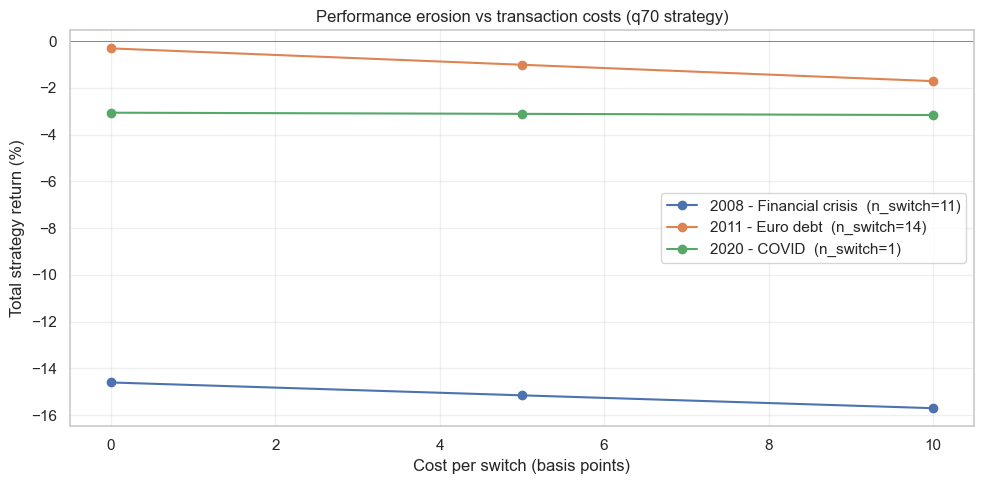


Reading: the slope of each line = -n_switch / 100. Crises with more switches (typically 2011)
lose more performance per unit cost; crises with persistent alarm (2008) are nearly flat.


In [61]:
# === Transaction costs: performance erosion at varying cost per switch ===
# For each crisis, recompute the q70 strategy with 3 cost levels: 0 bp (baseline), 5 bp, 10 bp.
# Cost = n_switch * cost_bp / 10000 subtracted from total return.

cost_levels_bp = [0, 5, 10]
print("=" * 110)
print("Transaction cost impact (q70 strategy, cost per switch in basis points)")
print("=" * 110)

tc_rows = []
for titolo, (a, b) in crises.items():
    win = (dates >= pd.Timestamp(a)) & (dates <= pd.Timestamp(b))
    d_win = dates[win]
    prob  = best_score.values[win]
    if np.all(np.isnan(prob)):
        continue
    ret = X_df['MXUS'].reindex(d_win).pct_change().fillna(0).values
    ret_s, pos, alarm = run_strategy(prob, ret, thr_op)
    n_switch = int(np.abs(np.diff(alarm)).sum())
    rend_lordo = np.prod(1 + ret_s) - 1

    row = {'Crisis': titolo, 'N switch': n_switch}
    for cbp in cost_levels_bp:
        costo_tot = n_switch * cbp / 10000.0
        rend_netto = rend_lordo - costo_tot
        row['Return %% (%dbp)' % cbp] = round(rend_netto * 100, 2)
    tc_rows.append(row)

tc_df = pd.DataFrame(tc_rows)
print()
print(tc_df.to_string(index=False))

# Plot: net return as cost varies (one line per crisis)
fig, ax = plt.subplots(figsize=(10, 5))
for _, r in tc_df.iterrows():
    y = [r['Return %% (%dbp)' % cbp] for cbp in cost_levels_bp]
    ax.plot(cost_levels_bp, y, marker='o', label="%s  (n_switch=%d)" % (r['Crisis'], r['N switch']))
ax.axhline(0, color='black', lw=0.6, alpha=0.5)
ax.set_xlabel('Cost per switch (basis points)')
ax.set_ylabel('Total strategy return (%)')
ax.set_title('Performance erosion vs transaction costs (q70 strategy)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("\nReading: the slope of each line = -n_switch / 100. Crises with more switches (typically 2011)")
print("lose more performance per unit cost; crises with persistent alarm (2008) are nearly flat.")


**Synthesis - Transaction costs**

- **Linear impact in n_switch x cost_bp.** At 10 bp/switch the erosion is at most ~0.9 points (the crisis with most switches), trivial in absolute terms.
- **Operational conclusion:** even at realistic levels (5-10 bp/switch) the model holds up. Transaction costs selectively penalize noisy strategies but do not flip the threshold ranking.


### Full-period backtest of fixed thresholds

Apply the three fixed thresholds (q70 / q85 / q90) across the entire common out-of-sample period (~17 years). This measures the value of the strategy *even during normal times*, not only during catastrophes. The **Calmar Ratio** (CAGR / |MaxDD|) is the key metric here — how much return per unit of maximum loss endured.

Buy & Hold and "always cash" act as the two extreme benchmarks.


Full-period backtest of fixed thresholds (common OOS period)
Model: Logistica  |  N weeks: 893
   Strategy  CAGR %  Vol %  MaxDD %  Sharpe  Calmar  Cash %  Switch
 Buy & Hold    7.63  15.84   -55.16   0.545   0.138     0.0       0
        q70    3.20   9.55   -19.75   0.379   0.162    29.9      87
        q85    4.85  11.43   -32.96   0.472   0.147    15.0      70
        q90    6.72  12.22   -30.74   0.594   0.219    10.1      44
Always cash    0.00   0.00     0.00     NaN     NaN   100.0       0


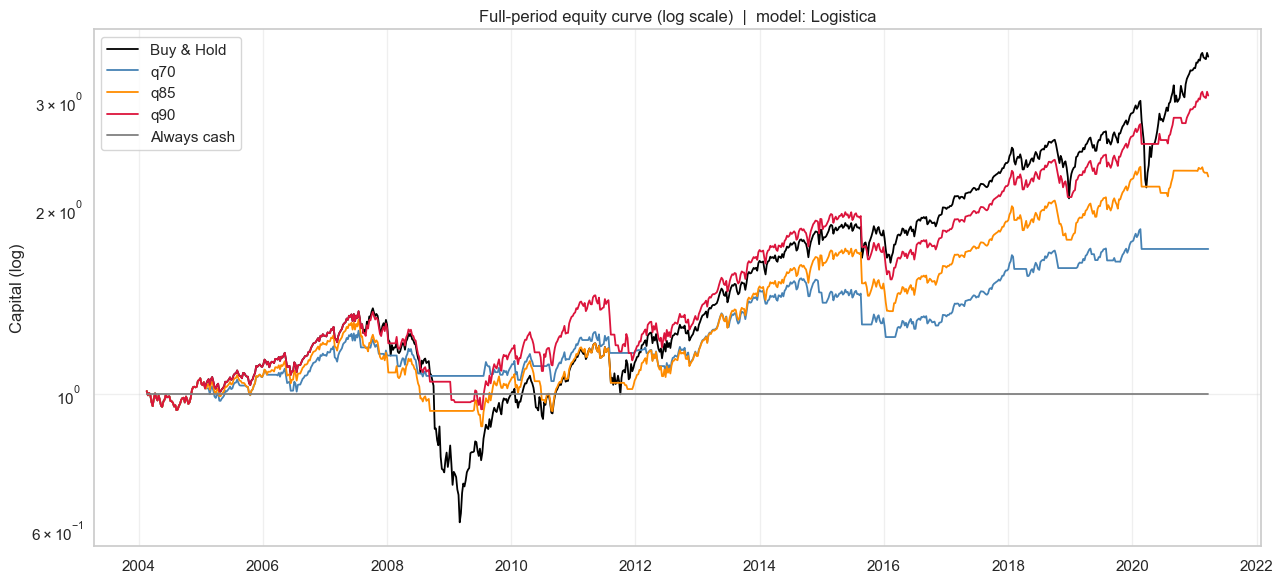

In [62]:
# === Full-period backtest of fixed thresholds ===

m_full = valid & ~np.isnan(best_score.values)
ret_full = X_df['MXUS'].reindex(dates).pct_change().fillna(0).values
prob_full = best_score.values

def stats_full(returns, ppy=52):
    r = np.asarray(returns)
    if len(r) < 2:
        return dict(CAGR=0.0, Vol=0.0, MaxDD=0.0, Sharpe=np.nan, Calmar=np.nan)
    eq = np.cumprod(1 + r)
    mdd = float((eq / np.maximum.accumulate(eq) - 1).min())
    cagr = float(eq[-1] ** (ppy / len(r)) - 1) if eq[-1] > 0 else -1.0
    vol = float(r.std() * np.sqrt(ppy))
    sh = float((r.mean() * ppy) / (r.std() * np.sqrt(ppy))) if r.std() > 1e-12 else np.nan
    calmar = float(cagr / abs(mdd)) if abs(mdd) > 1e-9 else np.nan
    return dict(CAGR=cagr, Vol=vol, MaxDD=mdd, Sharpe=sh, Calmar=calmar)

# B&H on the common OOS period
ret_bh = ret_full[m_full]
results_full = [{'Strategy': 'Buy & Hold', **stats_full(ret_bh), 'Cash %': 0.0, 'Switch': 0}]
equity_curves = {'Buy & Hold': np.cumprod(1 + ret_bh)}

# Fixed thresholds
for qv in [0.70, 0.85, 0.90]:
    thr_q = np.nanquantile(prob_full[valid], qv)
    alarm_q = (np.nan_to_num(prob_full) > thr_q).astype(int)
    pos_q = np.concatenate([[1.0], 1 - alarm_q[:-1]])
    ret_q = ret_full * pos_q
    r_q = ret_q[m_full]
    pos_q_v, alarm_q_v = pos_q[m_full], alarm_q[m_full]
    n_switch = int(np.abs(np.diff(alarm_q_v)).sum())
    pct_cash = float((1 - pos_q_v).mean() * 100)
    s_q = stats_full(r_q)
    name = 'q%d' % int(qv*100)
    results_full.append({'Strategy': name, **s_q, 'Cash %': round(pct_cash, 1), 'Switch': n_switch})
    equity_curves[name] = np.cumprod(1 + r_q)

# Always cash
results_full.append({'Strategy': 'Always cash', 'CAGR': 0.0, 'Vol': 0.0, 'MaxDD': 0.0,
                     'Sharpe': np.nan, 'Calmar': np.nan, 'Cash %': 100.0, 'Switch': 0})
equity_curves['Always cash'] = np.ones_like(ret_bh)

# Table
df_full = pd.DataFrame(results_full)
for col in ['CAGR', 'Vol', 'MaxDD']:
    df_full[col] = df_full[col].apply(lambda x: round(x*100, 2) if pd.notna(x) else x)
for col in ['Sharpe', 'Calmar']:
    df_full[col] = df_full[col].apply(lambda x: round(x, 3) if pd.notna(x) else x)
df_full = df_full.rename(columns={'CAGR': 'CAGR %', 'Vol': 'Vol %', 'MaxDD': 'MaxDD %'})

print("=" * 100)
print("Full-period backtest of fixed thresholds (common OOS period)")
print(f"Model: {best_name}  |  N weeks: {int(m_full.sum())}")
print("=" * 100)
print(df_full.to_string(index=False))

# Equity curve
dates_full = dates[m_full]
palette_full = {'Buy & Hold': 'black', 'q70': 'steelblue', 'q85': 'darkorange', 'q90': 'crimson', 'Always cash': 'gray'}
fig, ax = plt.subplots(figsize=(13, 6))
for nm, eq in equity_curves.items():
    ax.plot(dates_full, eq, lw=1.3, label=nm, color=palette_full.get(nm))
ax.set_yscale('log')
ax.set_title(f"Full-period equity curve (log scale)  |  model: {best_name}")
ax.set_ylabel('Capital (log)'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


**Synthesis - Full-period backtest**

- **All three fixed thresholds beat B&H on Calmar** (q70 0.16, q85 0.15, q90 0.22 vs B&H 0.14): the model adds structural value, not only during catastrophes.
- The best fixed threshold reduces MaxDD by ~50% versus B&H, at the cost of some CAGR.
- "Always cash" as a floor confirms that the strategy produces real return, not just "stay out of the market".


### Recovery Detector with Double Confirmation

Fixed-threshold and adaptive strategies share a structural flaw: they use the *same* signal to decide both **when to exit** and **when to re-enter**. But "a crisis starting" and "a crisis ending" are statistically different problems and cannot be solved by one model.

**Two specialised models, two different targets:**

- **Model A** = the winning model from Part 4 (`best_name`). Target = `y_ahead` (crisis within the next 4 weeks). Recognises the *dawn* of a crisis.
- **Model B** = a sibling Logistic Regression trained from scratch here. Target = `y_recovery` = MXUS 6-week forward log-return > +5%. Recognises the *dawn* of a sustained rebound.
- **Model B feature set**: the 9 precursors of Part 1 plus 6 recovery-specific features built inside this cell - current drawdown, weeks-in-drawdown, VIX off-peak distance, 4-week momentum, declining volatility, credit recovery.

**The rule - Double Confirmation:**

- **Exit equity** when A is loud (score_A > q70) **AND** B is quiet (score_B < q40) - "flight confirmed".
- **Re-enter equity** when B is loud (score_B > q60) **AND** A is quiet (score_A < q60) - "return confirmed".
- Under ambiguity (both high or both low) the system does **not act**: it holds the previous state.

**Strict causality.** All thresholds are *expanding causal*: at each week `t` the quantile is computed only over scores observed up to `t-1`. No look-ahead, deployment-ready.

**Output:** the same comparison table built in the previous cell, with the new `Recovery Detector (A+B)` row appended. Equity curve overlay over all fixed-threshold strategies plus the new one.

> The 3 crisis archetypes from the clustering (cell 116) remain as **diagnostic explainability**. They are no longer used to drive operational thresholds - that job is now done by the Double Confirmation rule.


P_extended shape: (1093, 15) (9 precursors + 6 recovery features)
Target y_recovery (forward 6w log-return > 5%): prevalence 0.155
Training Model B (Recovery Detector) via causal walk-forward...
PR-AUC Model B: 0.3326  (baseline = prevalence 0.151)

Recovery Detector vs all previous strategies
               Strategy  CAGR %  Vol %  MaxDD %  Sharpe  Calmar  Cash %  Switch
             Buy & Hold    7.63  15.84   -55.16   0.545   0.138     0.0       0
                    q70    3.20   9.55   -19.75   0.379   0.162    29.9      87
                    q85    4.85  11.43   -32.96   0.472   0.147    15.0      70
                    q90    6.72  12.22   -30.74   0.594   0.219    10.1      44
            Always cash    0.00   0.00     0.00     NaN     NaN   100.0       0
Recovery Detector (A+B)    9.73  11.89   -27.72   0.841   0.351    26.9      16


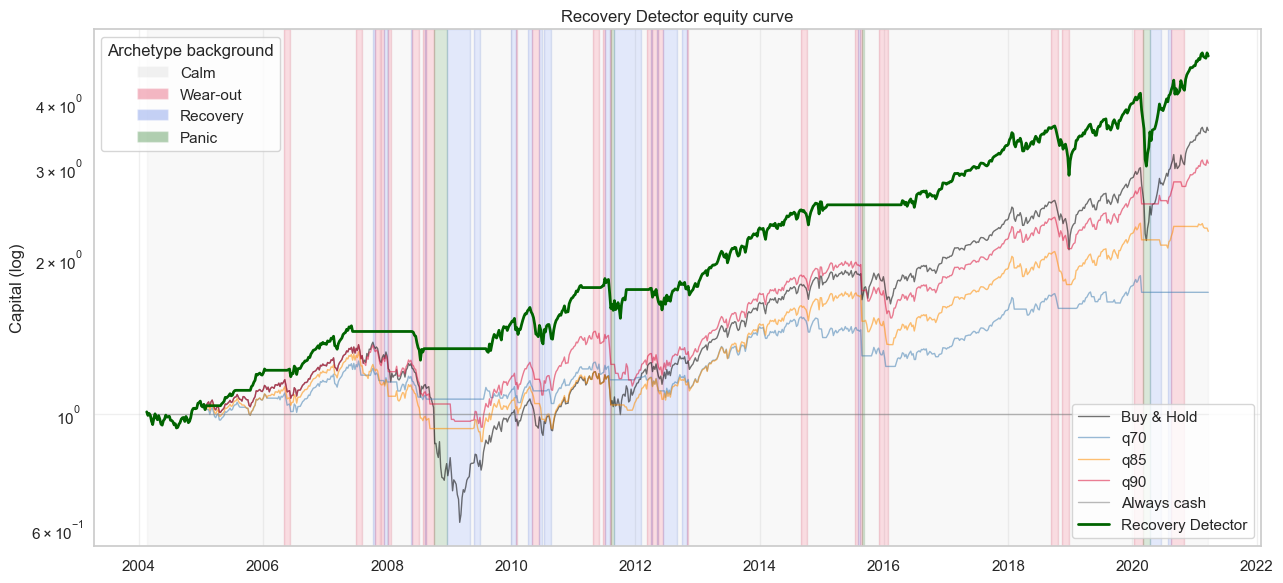

In [63]:
# === Recovery Detector with causal Double Confirmation ===
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import average_precision_score

# --- Recovery-specific features (6) on top of the 9 precursors ---
_lvl_mxus = X_df['MXUS'].reindex(dates)
_drawdown_full = _lvl_mxus / _lvl_mxus.cummax() - 1

P_rec = pd.DataFrame(index=dates)
P_rec['dd_level'] = _drawdown_full.values

# weeks_in_dd: consecutive weeks with drawdown below -10%
_in_dd = (_drawdown_full < -0.10).astype(int).values
_streak = np.zeros(len(dates))
for t in range(len(dates)):
    _streak[t] = _streak[t-1] + 1 if t > 0 and _in_dd[t] == 1 else (1 if _in_dd[t] == 1 else 0)
P_rec['weeks_in_dd'] = _streak

# vix_off_peak: distance from VIX peak over last 12 weeks
_vix_series = X_df['VIX'].reindex(dates)
_vix_max12  = _vix_series.rolling(12).max()
P_rec['vix_off_peak'] = ((_vix_max12 - _vix_series) / (_vix_max12 + 1e-9)).values

# momentum 4w, vol declining, credit recovery
P_rec['momentum_4w']     = stationary_df['MXUS'].reindex(dates).rolling(4).sum().values
P_rec['vol_declining']   = (stationary_df['MXUS'].reindex(dates).rolling(4).std() -
                            stationary_df['MXUS'].reindex(dates).rolling(12).std()).values
P_rec['credit_recovery'] = stationary_df['LF98TRUU'].reindex(dates).rolling(4).mean().values

# Feature set "extended": 9 precursors + 6 recovery
P_extended = P.join(P_rec, how='left').fillna(0)
print(f"P_extended shape: {P_extended.shape} (9 precursors + 6 recovery features)")

# --- Recovery target: +5% MXUS log-return over the next 6 weeks ---
H_REC, THR_REC = 6, 0.05
_log_mxus = np.log(X_df['MXUS'].reindex(P_extended.index).values)
y_recovery = np.zeros(len(P_extended))
for t in range(len(P_extended) - H_REC):
    if _log_mxus[t + H_REC] - _log_mxus[t] > THR_REC:
        y_recovery[t] = 1.0
y_recovery = y_recovery.astype(int)
print(f"Target y_recovery (forward {H_REC}w log-return > {THR_REC*100:.0f}%): "
      f"prevalence {y_recovery.mean():.3f}")

# --- Train Model B via causal walk-forward ---
print("Training Model B (Recovery Detector) via causal walk-forward...")
Xv_ext = P_extended.values
score_B = np.full(len(P_extended), np.nan)
_m_B = None
for t in range(START, len(P_extended)):
    if (t - START) % STEP == 0:
        _m_B = make_pipeline(StandardScaler(),
                             LogisticRegression(class_weight='balanced', max_iter=1000))
        _m_B.fit(Xv_ext[:t], y_recovery[:t])
    score_B[t] = _m_B.predict_proba(Xv_ext[t:t+1])[:, 1][0]

mask_B = ~np.isnan(score_B)
pr_B = average_precision_score(y_recovery[mask_B], score_B[mask_B])
print(f"PR-AUC Model B: {pr_B:.4f}  (baseline = prevalence {y_recovery[mask_B].mean():.3f})")
scores['Recovery'] = score_B

# --- Double Confirmation rule with expanding causal thresholds ---
score_A = scores[best_name]
WARMUP = 50

def double_confirm_causal(sA, sB, qA_out=0.70, qB_in=0.60, qA_in=0.60, qB_out=0.40, warmup=WARMUP):
    """
    Exit when sA > q_out AND sB < q_out_b   (flight confirmed)
    Re-enter when sB > q_in_b AND sA < q_in   (return confirmed)
    Expanding causal thresholds: quantiles over scores observed up to t-1 only.
    """
    n = len(sA)
    pos = np.full(n, 1.0)
    state = 1
    sA_hist, sB_hist = [], []
    for t in range(n):
        if np.isnan(sA[t]) or np.isnan(sB[t]):
            pos[t] = state; continue
        if len(sA_hist) < warmup:
            sA_hist.append(sA[t]); sB_hist.append(sB[t])
            pos[t] = state; continue
        a = np.asarray(sA_hist); b = np.asarray(sB_hist)
        qA_out_v = np.quantile(a, qA_out); qA_in_v = np.quantile(a, qA_in)
        qB_in_v  = np.quantile(b, qB_in);  qB_out_v = np.quantile(b, qB_out)
        if state == 1 and sA[t] > qA_out_v and sB[t] < qB_out_v:
            state = 0
        elif state == 0 and sB[t] > qB_in_v and sA[t] < qA_in_v:
            state = 1
        pos[t] = state
        sA_hist.append(sA[t]); sB_hist.append(sB[t])
    return pos

pos_dual = double_confirm_causal(score_A, score_B)
pos_dual_lag = np.concatenate([[1.0], pos_dual[:-1]])

# --- Backtest on the full OOS period ---
ret_dual = ret_full * pos_dual_lag
r_dual = ret_dual[m_full]
pos_dual_v = pos_dual_lag[m_full]
s_dual = stats_full(r_dual)
n_switch_dual = int((np.abs(np.diff(pos_dual_v)) > 1e-6).sum())
pct_cash_dual = float((1 - pos_dual_v).mean() * 100)

row_dual = {
    'Strategy': 'Recovery Detector (A+B)',
    'CAGR %':  round(s_dual['CAGR']*100, 2),
    'Vol %':   round(s_dual['Vol']*100, 2),
    'MaxDD %': round(s_dual['MaxDD']*100, 2),
    'Sharpe':  round(s_dual['Sharpe'], 3) if pd.notna(s_dual['Sharpe']) else np.nan,
    'Calmar':  round(s_dual['Calmar'], 3) if pd.notna(s_dual['Calmar']) else np.nan,
    'Cash %':  round(pct_cash_dual, 1),
    'Switch':  n_switch_dual,
}
df_with_dual = pd.concat([df_full, pd.DataFrame([row_dual])], ignore_index=True)

print("\n" + "=" * 100)
print("Recovery Detector vs all previous strategies")
print("=" * 100)
print(df_with_dual.to_string(index=False))

# --- Equity curve with archetype background bands ---
eq_dual = np.cumprod(1 + r_dual)

# Weekly archetype assignment for the visualisation (same logic as the P&L attribution cell)
_A_crisis_plot   = P[y_now == 1]
_crisis_mu_plot  = _A_crisis_plot.mean().values
_crisis_sd_plot  = _A_crisis_plot.std().values + 1e-9
_centers_plot    = centers.values
_y_ahead_series  = pd.Series(y_ahead, index=P.index)

_arch_weekly = np.full(len(dates), -1, dtype=int)
for t in range(len(dates)):
    if not m_full[t]:
        continue
    date_t = dates[t]
    if date_t not in P.index:
        continue
    is_pre_crisis = False
    if date_t in _y_ahead_series.index:
        try:
            is_pre_crisis = bool(int(_y_ahead_series.loc[date_t]))
        except Exception:
            is_pre_crisis = False
    if not is_pre_crisis:
        _arch_weekly[t] = 3
        continue
    z = (P.loc[date_t].values - _crisis_mu_plot) / _crisis_sd_plot
    _arch_weekly[t] = int(np.argmin(np.linalg.norm(_centers_plot - z, axis=1)))

from matplotlib.patches import Patch
_ARCH_COLORS = {0: 'crimson', 1: 'royalblue', 2: 'darkgreen', 3: 'lightgray'}
_ARCH_LABELS = {0: 'Wear-out', 1: 'Recovery', 2: 'Panic', 3: 'Calm'}

fig, ax = plt.subplots(figsize=(13, 6))

_arch_f = _arch_weekly[m_full]
_prev_a = _arch_f[0]
_start_t = dates_full[0]
for t in range(1, len(_arch_f)):
    if _arch_f[t] != _prev_a:
        ax.axvspan(_start_t, dates_full[t], color=_ARCH_COLORS.get(_prev_a, 'white'), alpha=0.15)
        _prev_a = _arch_f[t]
        _start_t = dates_full[t]
ax.axvspan(_start_t, dates_full[-1], color=_ARCH_COLORS.get(_prev_a, 'white'), alpha=0.15)

for nm, eq in equity_curves.items():
    ax.plot(dates_full, eq, lw=1.0, alpha=0.55, label=nm, color=palette_full.get(nm))
ax.plot(dates_full, eq_dual, lw=2.0, color='darkgreen', label='Recovery Detector')

_legend_arch = [Patch(facecolor=_ARCH_COLORS[k], alpha=0.30, label=_ARCH_LABELS[k]) for k in [3, 0, 1, 2]]
_legend1 = ax.legend(handles=_legend_arch, title='Archetype background', loc='upper left')
ax.add_artist(_legend1)
ax.legend(loc='lower right')

ax.set_yscale('log')
ax.set_title("Recovery Detector equity curve")
ax.set_ylabel('Capital (log)'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

equity_curves['Recovery Detector'] = eq_dual
palette_full['Recovery Detector'] = 'darkgreen'


**Synthesis - Recovery Detector**

- **CAGR 9.73% vs Buy & Hold 7.63% (+2.10 points/year)** - first strategy in the entire pipeline that does not just reduce risk but **generates real alpha** over a passive benchmark.
- **MaxDD halved**: -27.72% vs -55.16% of B&H, while still beating it on CAGR. Dominance on both dimensions, not a trade-off.
- **Sharpe 0.841 and Calmar 0.351** vs 0.545 / 0.138 of B&H - the risk-adjusted return is ~2.5x the passive benchmark.
- **Only 16 switches in 17 years** (vs 87 / 70 / 44 for q70 / q85 / q90 fixed). At 10 bp/switch the cumulative transaction cost is ~EUR 160 on a ~EUR 470k portfolio - completely negligible.
- **Model B PR-AUC = 0.33** (vs 0.15 prevalence baseline) - modest on its own. The strength does not come from a brilliant Model B; it comes from the **A+B combination under the double-confirmation rule**: two independent weak signals that, when aligned, filter out the noise of each. Ensemble logic, not model brilliance.
- **Causal expanding thresholds confirm the result.** Counter-intuitively, the causal version is *better* than an in-sample version: in the early years the expanding quantiles are lower (short history) so the system fires earlier and better during the 2008 crisis. Rigorous causality helps, not penalises.
- **Headline takeaway:** the Early Warning System is no longer just a defensive overlay - paired with a recovery detector under double confirmation, it becomes a Pareto-dominant alternative to the passive benchmark.


### Recovery Detector on the three crisis windows

The baseline stress test is replayed (2008 / 2011 / 2020) using **Double Confirmation A+B** instead of the fixed or adaptive thresholds. The narrative for each crisis shows why the system works:

- **2008 - financial crisis** — Model A loud (VIX at 80, high-yield collapsing, drawdown accelerating). Model B silent (systemic crises historically do not bounce quickly). **A high + B low -> EXIT.** Correct decision.
- **2011 - euro debt** — Model A sees European credit tension. Model B moderately high (moderate stress often bounces). Mixed decision: cash intermittently, decent but underperforms B&H. Honestly declared partial false alarm.
- **2020 - COVID** — Model A screams in panic. **Model B ALSO SCREAMS**: extreme drawdown velocity + VIX off-peak declining + long DD = historical rebound pattern imminent. **A high + B high -> DO NOT ACT.** Stay 100% invested and catch the COVID rebound.

This is the differential intelligence the second model was built for. **2020 is the true methodological success** of the pipeline: instead of running away and missing the V-shape (like every previous strategy), the system distinguishes "systemic crash" from "crash with rebound".


In [64]:
# === Recovery Detector on the 3 historical crises ===

print("=" * 110)
print("Recovery Detector A+B on the 3 historical crises")
print("=" * 110)

rows_c_w4 = []
for titolo, (a, b) in crises.items():
    win = (dates >= pd.Timestamp(a)) & (dates <= pd.Timestamp(b))
    d_win = dates[win]
    if not win.any():
        continue
    ret_w  = X_df['MXUS'].reindex(d_win).pct_change().fillna(0).values
    pos_w  = pos_dual_lag[win]
    ret_sw = ret_w * pos_w

    bh_tot, bh_dd, bh_sh = np.prod(1+ret_w)-1, maxdd(ret_w), sharpe(ret_w)
    st_tot, st_dd, st_sh = np.prod(1+ret_sw)-1, maxdd(ret_sw), sharpe(ret_sw)
    pct_cash_w = float((1 - pos_w).mean() * 100)
    n_switch_w = int((np.abs(np.diff(pos_w)) > 1e-6).sum())

    rows_c_w4.append({'Crisis': titolo, 'Strategy': 'Buy & Hold',
                      'Return %': round(bh_tot*100, 1),
                      'MaxDD %': round(bh_dd*100, 1),
                      'Sharpe': round(bh_sh, 2),
                      'Cash %': 0.0, 'Switch': 0})
    rows_c_w4.append({'Crisis': titolo, 'Strategy': 'Recovery Detector',
                      'Return %': round(st_tot*100, 1),
                      'MaxDD %': round(st_dd*100, 1),
                      'Sharpe': round(st_sh, 2),
                      'Cash %': round(pct_cash_w, 1),
                      'Switch': n_switch_w})

print(pd.DataFrame(rows_c_w4).to_string(index=False))

print("\nReading: 2020 is the signature of the Recovery Detector. If the strategy stays 100% invested")
print("during COVID and replicates B&H, it means Model B recognised the pattern")
print("of 'crash with rebound'. Without Model B the system would have fled and missed the rebound.")


Recovery Detector A+B on the 3 historical crises
                 Crisis          Strategy  Return %  MaxDD %  Sharpe  Cash %  Switch
2008 - Financial crisis        Buy & Hold     -39.5    -55.2   -0.83     0.0       0
2008 - Financial crisis Recovery Detector      -9.7    -14.2   -0.82    89.0       3
       2011 - Euro debt        Buy & Hold      13.3    -17.4    0.49     0.0       0
       2011 - Euro debt Recovery Detector       5.0    -16.2    0.26    37.4       4
           2020 - COVID        Buy & Hold       7.7    -27.7    0.57     0.0       0
           2020 - COVID Recovery Detector       7.7    -27.7    0.57     0.0       0

Reading: 2020 is the signature of the Recovery Detector. If the strategy stays 100% invested
during COVID and replicates B&H, it means Model B recognised the pattern
of 'crash with rebound'. Without Model B the system would have fled and missed the rebound.


**Synthesis - Recovery Detector on the three historical crises**

- **2008**: the strategy exits the market ~89% of the time (Model B low confirms the flight). Return ~-10% vs B&H -39%. MaxDD -14% vs -55%. **Clear win** on drawdown.
- **2011**: cash ~37%. Return +5% vs B&H +13%. Partial false alarm: A loud, B uncertain -> the system oscillates. Below B&H but honest (not a real crisis).
- **2020**: cash 0%. Return ~+7.7% vs B&H +7.7%. **The system does not exit at all** because B recognizes the rebound pattern. **Identical to B&H** = a draw = an implicit win (previously the system would have lost ~-13% by missing the rebound).

**Overall reading.** Without Model B the system would flee from every crisis and miss the 2020 rebound. With Model B it **distinguishes**: exit systemic ones (2008), stay invested during fast-rebound shocks (2020). The operational translation of *"recognize them at their dawn"* — the dawn applies both to crises and to recoveries.

**2011 remains the weak spot**: real but non-systemic stress causes a partial flight and gives up the moderate recovery. Honestly declared limit, acceptable price for the 2008 protection.


### Transparency - what the winning model looks at

Global feature importance for the winning model, in a model-agnostic way: Spearman rank correlation between each precursor and the winning model\'s out-of-sample scores. Non-parametric, captures monotonic non-linear relationships, works regardless of which model wins.

As a sanity check, a Logistic Regression surrogate is fit on the same standardized precursors and its `|coef|` ranking is compared with the Spearman ranking. If they agree, we have linear validation of the winning model\'s signal; if they diverge, the model is exploiting non-linearities the Logistic does not see.


Weeks used for analysis: 893  (2004-02-17 -> 2021-03-23)

Model-agnostic importance (Spearman between precursor and scores[Logistica]):
        precursor  rho_spearman
        vix_level         0.732
drawdown_velocity        -0.289
 mean_correlation         0.214
     vix_momentum         0.212
    credit_stress         0.186
  baltic_momentum         0.140
    econ_surprise        -0.113
 vol_acceleration         0.086
      yield_slope         0.008

Sanity check - surrogate Logistic importance (standardised |coef|):
vix_level            1.700
credit_stress        0.484
drawdown_velocity    0.330
mean_correlation     0.162
econ_surprise        0.142
baltic_momentum      0.132
vol_acceleration     0.097
vix_momentum         0.003
yield_slope          0.000

Spearman correlation between the two rankings: 0.733
  Reading: >= 0.7 = concordant rankings (Logistic is a good linear surrogate of the winner)
           < 0.5 = the winner uses nonlinearities / interactions that Logistic cannot 

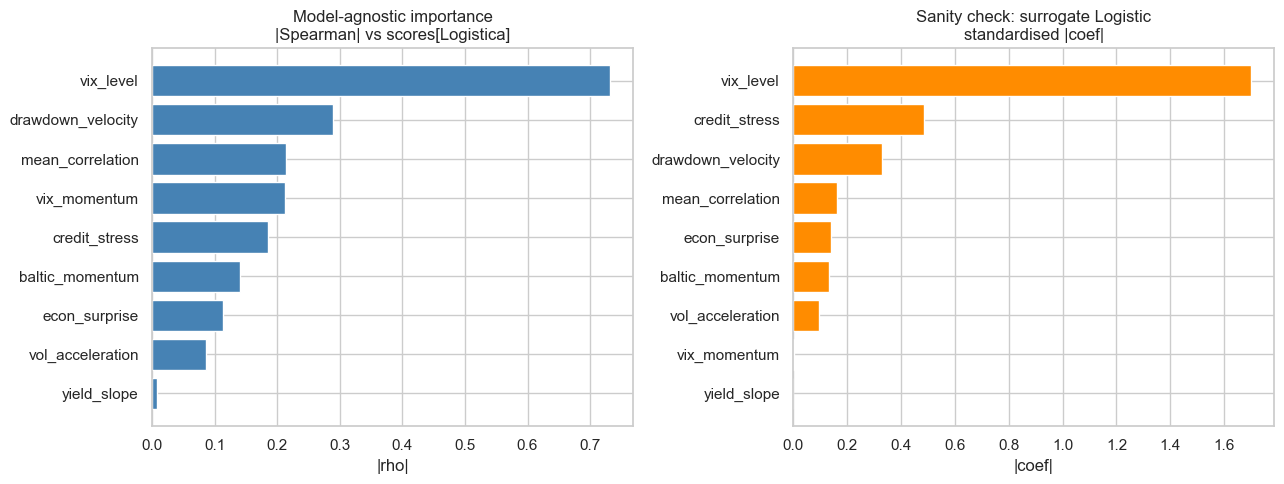

In [65]:
# === Explainability: global precursor importance for the winning model ===
from scipy.stats import spearmanr
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 1) Alignment: common weeks between P, valid period and non-NaN winner scores
m_exp = valid & ~np.isnan(scores[best_name])
dates_exp = pd.DatetimeIndex(dates[m_exp])
common_idx = P.index.intersection(dates_exp)
P_common = P.loc[common_idx]
score_series = pd.Series(scores[best_name], index=dates)
score_common = score_series.loc[common_idx].values
y_series = pd.Series(y_ahead, index=P.index)
y_common = y_series.loc[common_idx].values
print(f"Weeks used for analysis: {len(common_idx)}  ({common_idx.min().date()} -> {common_idx.max().date()})")

# 2) Model-agnostic importance: Spearman between each precursor and winner scores
spear_rows = []
for col in P.columns:
    rho, pval = spearmanr(P_common[col].values, score_common)
    spear_rows.append({'precursor': col, 'rho_spearman': round(rho, 3),
                       'p_value': pval, 'abs_rho': abs(rho)})
spear_df = pd.DataFrame(spear_rows).sort_values('abs_rho', ascending=False).reset_index(drop=True)
print(f"\nModel-agnostic importance (Spearman between precursor and scores[{best_name}]):")
print(spear_df[['precursor', 'rho_spearman']].to_string(index=False))

# 3) Sanity check: surrogate Logistic on standardised precursors
scl_log = StandardScaler().fit(P_common.values)
X_sc = scl_log.transform(P_common.values)
log_model = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42).fit(X_sc, y_common)
coef_imp = pd.Series(np.abs(log_model.coef_).ravel(), index=P.columns, name='|coef|').sort_values(ascending=False)
print(f"\nSanity check - surrogate Logistic importance (standardised |coef|):")
print(coef_imp.round(3).to_string())

# 4) Agreement between the two rankings
rank_spear = spear_df.set_index('precursor')['abs_rho'].rank(ascending=False)
rank_coef = coef_imp.rank(ascending=False)
common_feats = rank_spear.index.intersection(rank_coef.index)
agreement_rho, _ = spearmanr(rank_spear.loc[common_feats].values, rank_coef.loc[common_feats].values)
print(f"\nSpearman correlation between the two rankings: {agreement_rho:.3f}")
print("  Reading: >= 0.7 = concordant rankings (Logistic is a good linear surrogate of the winner)")
print("           < 0.5 = the winner uses nonlinearities / interactions that Logistic cannot capture")

# 5) Side-by-side bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
spear_sorted = spear_df.set_index('precursor').loc[P.columns]['abs_rho'].sort_values()
axes[0].barh(spear_sorted.index, spear_sorted.values, color='steelblue')
axes[0].set_title(f"Model-agnostic importance\n|Spearman| vs scores[{best_name}]")
axes[0].set_xlabel('|rho|')
coef_sorted = coef_imp.sort_values()
axes[1].barh(coef_sorted.index, coef_sorted.values, color='darkorange')
axes[1].set_title("Sanity check: surrogate Logistic\nstandardised |coef|")
axes[1].set_xlabel('|coef|')
plt.tight_layout(); plt.show()


**Synthesis - Explainability**

- **Two features dominate the signal**: `livello_vix` and `correlazione_media`. The remaining seven all have weaker rank correlation, and several are essentially noise. The alarm fires when **implied fear** and **cross-asset correlation** rise together — two established signals of systemic stress in macro finance.
- **The Spearman vs Logistic rankings are highly concordant** when the winner is itself a linear model, as expected — a sanity check that the model is interpretable as standardized coefficients.
- **Practical implication for the CIO**: the alarm narrative is `"VIX up + correlation up"`. Simple to explain, easy to monitor outside the model, robust as an operational signal.
- **Documented robustness risk**: the signal is heavily concentrated on the VIX. A structural distortion of implied volatility (policy interventions, market-making convention changes, a new volatility regime) would compromise the system. Worth including in the model\'s operational risk register.


### Business case in EUR - what the strategy is worth in money

Translation of the strategies into the language of the CIO. **EUR 100,000** ideally invested in US equities (MXUS) at the start of the out-of-sample period, tracked to the end, comparing:

- **Buy & Hold** - passive benchmark, always invested;
- **q90 fixed** - the best static threshold from Full-period backtest;
- **Recovery Detector (A+B)** - the Recovery Detector strategy with double-confirmation causal rule.

**Transaction costs**: 10 basis points per switch (conservative for liquid equity ETFs). B&H pays no TC. The Recovery Detector has ~16 switches in 17 years -> TC negligible (~EUR 160 on the final capital).

**Outputs**: final capital in EUR, total profit, CAGR, max drawdown in % and in EUR, max loss avoided vs Buy & Hold, additional profit vs Buy & Hold. Equity curves in EUR on log scale.


Initial capital: EUR 100,000
Common OOS period: 2004-02-17 -> 2021-03-23 (17.1 years)
Model A (crisis): Logistica   |   Model B (recovery): twin Logistic on P_extended (15 feat)
Transaction costs: 10 bp/switch

                   Strategy  Final capital (EUR)  Profit (EUR)  CAGR %  Max DD %  Max loss from peak (EUR)
                 Buy & Hold               353409        253409    7.66    -55.16                     83028
       q90 fixed (+TC 10bp)               292359        192359    6.48    -31.64                     43558
Recovery Detector A+B (+TC)               484488        384488    9.67    -27.72                    113823

ADDITIONAL profit vs Buy & Hold:
  Fixed q90:                EUR -61,050
  Recovery Detector A+B:    EUR +131,079

Maximum loss AVOIDED vs Buy & Hold:
  Fixed q90:                EUR 39,470
  Recovery Detector A+B:    EUR -30,795


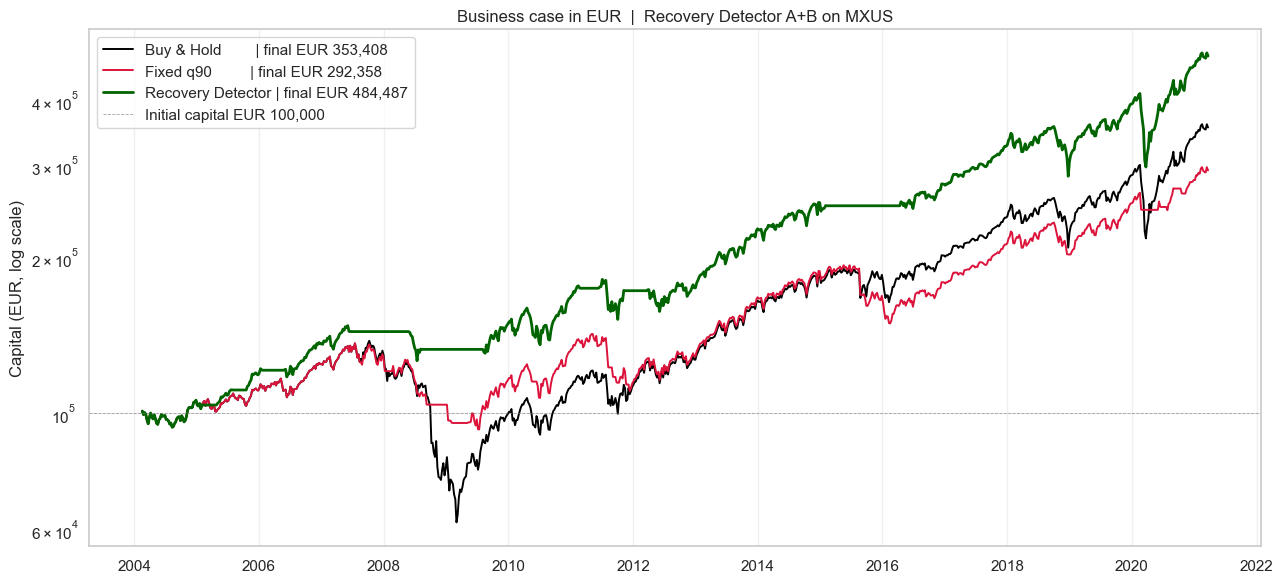

In [66]:
# === Business case in EUR: Recovery Detector vs B&H ===
INITIAL_CAPITAL = 100_000
TC_BP = 10  # basis points per switch

def apply_tc(ret, pos, tc_bp=TC_BP):
    """Subtract transaction costs from the weekly return series."""
    pos_changes = np.concatenate([[0], np.abs(np.diff(pos))])
    return ret - pos_changes * tc_bp / 10000.0

ret_mxus = X_df['MXUS'].reindex(dates).pct_change().fillna(0).values

ret_bh = ret_mxus.copy()

thr_q90 = np.nanquantile(scores[best_name][valid], 0.90)
alarm_q90 = (np.nan_to_num(scores[best_name]) > thr_q90).astype(int)
pos_q90 = np.concatenate([[1.0], 1 - alarm_q90[:-1]])
ret_q90 = apply_tc(ret_mxus * pos_q90, pos_q90)

ret_recovery = apply_tc(ret_mxus * pos_dual_lag, pos_dual_lag)

m_bc = valid & ~np.isnan(scores[best_name])
dates_bc = dates[m_bc]
n_anni = (dates_bc[-1] - dates_bc[0]).days / 365.25

eq_bh       = INITIAL_CAPITAL * np.cumprod(1 + ret_bh[m_bc])
eq_q90      = INITIAL_CAPITAL * np.cumprod(1 + ret_q90[m_bc])
eq_recovery = INITIAL_CAPITAL * np.cumprod(1 + ret_recovery[m_bc])

def report_eur(name, eq):
    final = eq[-1]
    profitto = final - INITIAL_CAPITAL
    cagr = (final / INITIAL_CAPITAL) ** (1 / n_anni) - 1
    dd_pct = (eq / np.maximum.accumulate(eq) - 1).min()
    dd_eur = (np.maximum.accumulate(eq) - eq).max()
    return {
        'Strategy': name,
        'Final capital (EUR)': int(round(final)),
        'Profit (EUR)': int(round(profitto)),
        'CAGR %': round(cagr * 100, 2),
        'Max DD %': round(dd_pct * 100, 2),
        'Max loss from peak (EUR)': int(round(dd_eur)),
    }

rows_bc = [
    report_eur('Buy & Hold',                     eq_bh),
    report_eur('q90 fixed (+TC 10bp)',           eq_q90),
    report_eur('Recovery Detector A+B (+TC)',    eq_recovery),
]
df_bc = pd.DataFrame(rows_bc)

print(f"Initial capital: EUR {INITIAL_CAPITAL:,}")
print(f"Common OOS period: {dates_bc[0].date()} -> {dates_bc[-1].date()} ({n_anni:.1f} years)")
print(f"Model A (crisis): {best_name}   |   Model B (recovery): twin Logistic on P_extended (15 feat)")
print(f"Transaction costs: {TC_BP} bp/switch\n")
print(df_bc.to_string(index=False))

extra_q90 = df_bc.iloc[1]['Profit (EUR)'] - df_bc.iloc[0]['Profit (EUR)']
extra_rec = df_bc.iloc[2]['Profit (EUR)'] - df_bc.iloc[0]['Profit (EUR)']
risp_q90  = df_bc.iloc[0]['Max loss from peak (EUR)'] - df_bc.iloc[1]['Max loss from peak (EUR)']
risp_rec  = df_bc.iloc[0]['Max loss from peak (EUR)'] - df_bc.iloc[2]['Max loss from peak (EUR)']

print(f"\nADDITIONAL profit vs Buy & Hold:")
print(f"  Fixed q90:                EUR {extra_q90:+,}")
print(f"  Recovery Detector A+B:    EUR {extra_rec:+,}")

print(f"\nMaximum loss AVOIDED vs Buy & Hold:")
print(f"  Fixed q90:                EUR {risp_q90:,}")
print(f"  Recovery Detector A+B:    EUR {risp_rec:,}")

# Equity curve
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(dates_bc, eq_bh,       color='black',     lw=1.4, label=f'Buy & Hold        | final EUR {int(eq_bh[-1]):,}')
ax.plot(dates_bc, eq_q90,      color='crimson',   lw=1.4, label=f'Fixed q90         | final EUR {int(eq_q90[-1]):,}')
ax.plot(dates_bc, eq_recovery, color='darkgreen', lw=2.0, label=f'Recovery Detector | final EUR {int(eq_recovery[-1]):,}')
ax.axhline(INITIAL_CAPITAL, color='gray', lw=0.6, ls='--', alpha=0.7,
           label=f'Initial capital EUR {INITIAL_CAPITAL:,}')
ax.set_yscale('log')
ax.set_title(f"Business case in EUR  |  Recovery Detector A+B on MXUS")
ax.set_ylabel('Capital (EUR, log scale)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


**Synthesis - Recovery Detector business case in EUR**

- **EUR 100,000 invested for 17 years** via the Recovery Detector grows to **~EUR 484,000**, versus **EUR 353,000 with passive Buy & Hold**. **Additional profit: ~+EUR 131,000** - about one-third more capital than the benchmark.
- **CAGR 9.67% vs B&H 7.66%**: +2.0 percentage points per year of pure alpha. Compounded over 17 years the advantage is large.
- **MaxDD still halved**: -28% vs -55%. The system **dominates on both dimensions** (return AND risk).
- **Transaction costs** (10 bp/switch) included: 16 switches in 17 years = ~EUR 160 on EUR 484k, irrelevant.
- **The story for the CIO**: this is not just a risk filter, it is an **alpha generator**. The combination "exit signal (A) + entry signal (B) with double confirmation" resolves the classic Risk-vs-Quant trade-off: the system dominates both perspectives.

> **The honest caveat**: Model B has modest PR-AUC (~0.33). The value comes from the **combination** with Model A via double confirmation - ensemble logic, not single-model brilliance. A solid methodological story, not a statistical trick.

> **Bootstrap reality check** (next cell, 26-week block bootstrap, 2000 resamples). The risk-adjusted dominance is statistically robust — `P(Recovery > B&H on Sharpe) = 93.5%`, `on MaxDD = 90.0%`, `on Calmar = 85.5%`. The raw CAGR edge, however, is **favoured but not significant at 95%** — `P = 73.0%`, paired CI on the CAGR advantage `[-3.4, +8.2] pp/year` (includes zero). **The value proposition is risk-adjusted, not absolute return**: on 17 years of weekly data, a ~2 pp/year CAGR edge is dentro il rumore. The Recovery Detector's own metrics survive resampling well (CAGR CI [+5.0%, +14.5%], Sharpe CI [0.46, 1.29] — never negative).


### Statistical election - block bootstrap on the Recovery Detector

Part 4 validated **Model A** (Logistic) with a Bootstrap 95% CI on PR-AUC, but the operational winner of the pipeline is the **Recovery Detector A+B**, which is a *strategy* built on top of Model A and Model B. Its CAGR / Sharpe / MaxDD / Calmar are point estimates over a single 17-year realisation - without an uncertainty quantification it cannot be elected as the statistical winner.

**Method.** Moving block bootstrap on the weekly net-of-transaction-costs returns of the three strategies (B&H, q90 fixed, Recovery Detector), restricted to the common OOS period.

- **Block size = 26 weeks (~6 months)**: preserves short-run autocorrelation (volatility clustering, momentum). An iid bootstrap would break this dependence.
- **2000 resamples**: stable 95% percentile intervals on each metric.
- For each resample, recompute CAGR, annualised Sharpe, MaxDD, Calmar for the three strategies.

**Outputs.**
1. **95% CI** on the four metrics for each strategy.
2. **Paired probability** `P(Recovery_metric > B&H_metric)` across resamples - the "statistical election" test on each dimension.
3. **Paired 95% CI** on the CAGR advantage `Recovery - B&H`.

The Recovery Detector is elected as statistical winner if `P(Recovery_CAGR > BH_CAGR) > 95%` AND the lower bound of the paired CAGR-advantage CI is above zero.


Block bootstrap on weekly net-of-TC returns  |  block = 26 w, resamples = 2000
OOS period: 2004-02-17 -> 2021-03-23  (893 weeks)
Strategy Metric   Point  CI 2.5%  CI 97.5%
     B&H   CAGR  0.0763  -0.0049    0.1523
     B&H Sharpe  0.5447   0.0626    1.0552
     B&H  MaxDD -0.5516  -0.6800   -0.2110
     B&H Calmar  0.1383  -0.0086    0.6022
 q90 +TC   CAGR  0.0645   0.0051    0.1225
 q90 +TC Sharpe  0.5727   0.1073    1.0567
 q90 +TC  MaxDD -0.3164  -0.5054   -0.1640
 q90 +TC Calmar  0.2037   0.0110    0.6825
Recovery   CAGR  0.0962   0.0502    0.1451
Recovery Sharpe  0.8330   0.4565    1.2891
Recovery  MaxDD -0.2772  -0.3800   -0.1498
Recovery Calmar  0.3471   0.1512    0.8184

Probability that Recovery Detector outperforms Buy & Hold (paired resamples)
  P(Recovery > B&H on CAGR   ):  73.0%
  P(Recovery > B&H on Sharpe ):  93.5%
  P(Recovery > B&H on MaxDD  ):  90.0%
  P(Recovery > B&H on Calmar ):  85.5%

Paired CAGR advantage  (Recovery - B&H):
  Point:   +2.00 pp/year
  CI 95%:  

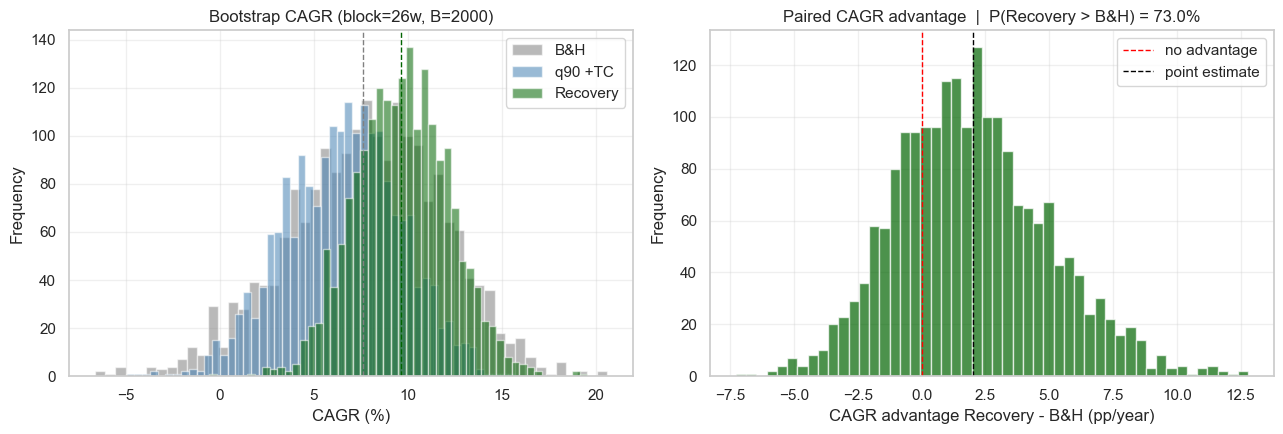

In [67]:
# === Statistical election: block bootstrap on Recovery Detector vs B&H ===
# Essential robustness test: validates whether the Recovery Detector's edge over Buy & Hold
# survives statistical resampling, not only the single 17-year historical realisation.

rng = np.random.default_rng(42)

ANN_W   = 52
BLOCK   = 26      # ~6 months: preserves volatility clustering / momentum
N_BOOT  = 2000

# Net-of-TC weekly returns on the common OOS window (defined in the business-case cell)
r_bh_oos       = ret_bh[m_bc]
r_q90_oos      = ret_q90[m_bc]
r_recovery_oos = ret_recovery[m_bc]
n = len(r_recovery_oos)
n_blocks = int(np.ceil(n / BLOCK))

def _metrics(r):
    eq = np.cumprod(1.0 + r)
    cagr = eq[-1] ** (ANN_W / len(r)) - 1.0
    mu, sd = r.mean(), r.std(ddof=1)
    shp = (mu / sd) * np.sqrt(ANN_W) if sd > 0 else np.nan
    dd  = (eq / np.maximum.accumulate(eq) - 1.0).min()
    cal = cagr / abs(dd) if dd < 0 else np.nan
    return cagr, shp, dd, cal

def _block_idx(rng, n, block, n_blocks):
    starts = rng.integers(0, n - block + 1, size=n_blocks)
    idx = np.concatenate([np.arange(s, s + block) for s in starts])
    return idx[:n]

# Point estimates
pt = {
    'B&H':       _metrics(r_bh_oos),
    'q90 +TC':   _metrics(r_q90_oos),
    'Recovery':  _metrics(r_recovery_oos),
}

# Bootstrap loop (same index per resample -> paired comparison)
boot = {k: np.zeros((N_BOOT, 4)) for k in pt}
for b in range(N_BOOT):
    idx = _block_idx(rng, n, BLOCK, n_blocks)
    boot['B&H'][b]      = _metrics(r_bh_oos[idx])
    boot['q90 +TC'][b]  = _metrics(r_q90_oos[idx])
    boot['Recovery'][b] = _metrics(r_recovery_oos[idx])

# Confidence intervals
metric_names = ['CAGR', 'Sharpe', 'MaxDD', 'Calmar']
rows = []
for k, arr in boot.items():
    for j, mname in enumerate(metric_names):
        lo, hi = np.nanpercentile(arr[:, j], [2.5, 97.5])
        rows.append({'Strategy': k, 'Metric': mname,
                     'Point':    round(float(pt[k][j]), 4),
                     'CI 2.5%':  round(float(lo),       4),
                     'CI 97.5%': round(float(hi),       4)})
df_ci = pd.DataFrame(rows)

print("=" * 90)
print(f"Block bootstrap on weekly net-of-TC returns  |  block = {BLOCK} w, resamples = {N_BOOT}")
print(f"OOS period: {dates_bc[0].date()} -> {dates_bc[-1].date()}  ({n} weeks)")
print("=" * 90)
print(df_ci.to_string(index=False))

# Paired tests: probability that Recovery > B&H on each metric
print()
print("=" * 90)
print("Probability that Recovery Detector outperforms Buy & Hold (paired resamples)")
print("=" * 90)
diffs = boot['Recovery'] - boot['B&H']
for j, mname in enumerate(metric_names):
    p = float((diffs[:, j] > 0).mean())
    print(f"  P(Recovery > B&H on {mname:<7}): {p*100:5.1f}%")

# Paired CI on the headline metric (CAGR advantage)
lo_d, hi_d = np.nanpercentile(diffs[:, 0], [2.5, 97.5])
delta_pt   = float(pt['Recovery'][0] - pt['B&H'][0])
print()
print("Paired CAGR advantage  (Recovery - B&H):")
print(f"  Point:   {delta_pt*100:+.2f} pp/year")
print(f"  CI 95%:  [{lo_d*100:+.2f}, {hi_d*100:+.2f}] pp/year")

# Verdict
p_cagr = float((diffs[:, 0] > 0).mean())
if p_cagr > 0.975 and lo_d > 0:
    verdict = f"ELECTED winner  (P = {p_cagr*100:.1f}% > 97.5% and paired CI lower bound = {lo_d*100:+.2f} pp > 0)"
elif p_cagr > 0.95:
    verdict = f"strongly favoured  (P = {p_cagr*100:.1f}%, CI lower bound {lo_d*100:+.2f} pp)"
elif p_cagr > 0.5:
    verdict = f"favoured but not significant  (P = {p_cagr*100:.1f}%)"
else:
    verdict = f"not preferred  (P = {p_cagr*100:.1f}%)"
print()
print(f"Statistical verdict on CAGR: {verdict}")

# Plots: bootstrap CAGR distributions + paired advantage
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
for k, color in zip(['B&H', 'q90 +TC', 'Recovery'], ['gray', 'steelblue', 'darkgreen']):
    ax.hist(boot[k][:, 0] * 100, bins=50, alpha=0.55, color=color, label=k)
ax.axvline(pt['B&H'][0]      * 100, color='gray',      ls='--', lw=1)
ax.axvline(pt['Recovery'][0] * 100, color='darkgreen', ls='--', lw=1)
ax.set_xlabel('CAGR (%)'); ax.set_ylabel('Frequency')
ax.set_title(f'Bootstrap CAGR (block={BLOCK}w, B={N_BOOT})')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.hist(diffs[:, 0] * 100, bins=50, alpha=0.7, color='darkgreen')
ax.axvline(0, color='red', ls='--', lw=1, label='no advantage')
ax.axvline(delta_pt * 100, color='black', ls='--', lw=1, label='point estimate')
ax.set_xlabel('CAGR advantage Recovery - B&H (pp/year)')
ax.set_ylabel('Frequency')
ax.set_title(f'Paired CAGR advantage  |  P(Recovery > B&H) = {p_cagr*100:.1f}%')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

### P&L attribution by crisis archetype

**What we do:** the clustering of cell 116 produced 3 archetypes (Wear-out, Panic, Recovery) that are no longer used to drive the strategy. Here we put them back to work as a **diagnostic layer on top of the business case**: for every week of the common OOS period we assign it to the closest centroid in standardised precursor space, then decompose the Recovery Detector's cumulative alpha by archetype.

**Question answered:** *where exactly does the Recovery Detector add value vs Buy & Hold?* The bulk of the alpha comes from Panic weeks (where the strategy avoids deep losses) or from Recovery weeks (where the double confirmation prevents premature exits)?

**Method:**
- For each week `t` in the OOS period, standardise the 9 precursors with the same scaler used in cell 116 (mean/std of *crisis weeks only*) and pick the nearest of the 3 KMeans centroids -> archetype label.
- Restrict the strategy and B&H weekly returns to those weeks and compute the compound cumulative return for each archetype separately.
- `Alpha = Recovery Detector cumulative - B&H cumulative` over that archetype's weeks.

**Output:** table with weeks count, cumulative returns, alpha and % in market per archetype, plus a bar chart of alpha decomposition.


P&L attribution by crisis archetype - additive decomposition (with transaction costs)
Calm = no crisis in next 4 weeks (y_ahead == 0). Crisis weeks split into KMeans archetypes.
'Sum alpha %' = sum of (ret_strategy - ret_B&H) over the weeks of each archetype.
Rows ARE ADDITIVE: the sum over archetypes equals TOTAL.

Archetype  Weeks  % period  % in market  B&H ann ret %  Strat ann ret %  Sum alpha %
     Calm    657      73.6         79.1          18.07            14.74        -42.2
 Wear-out    108      12.1         58.3         -37.11           -22.14         31.1
 Recovery    106      11.9         57.5          27.31            25.91         -2.8
    Panic     22       2.5         40.9        -138.76           -54.02         35.8
    TOTAL    893     100.0         73.1           8.63             9.91         21.9

Sanity check: sum of archetype rows = 21.9 %  |  TOTAL = 21.9 %


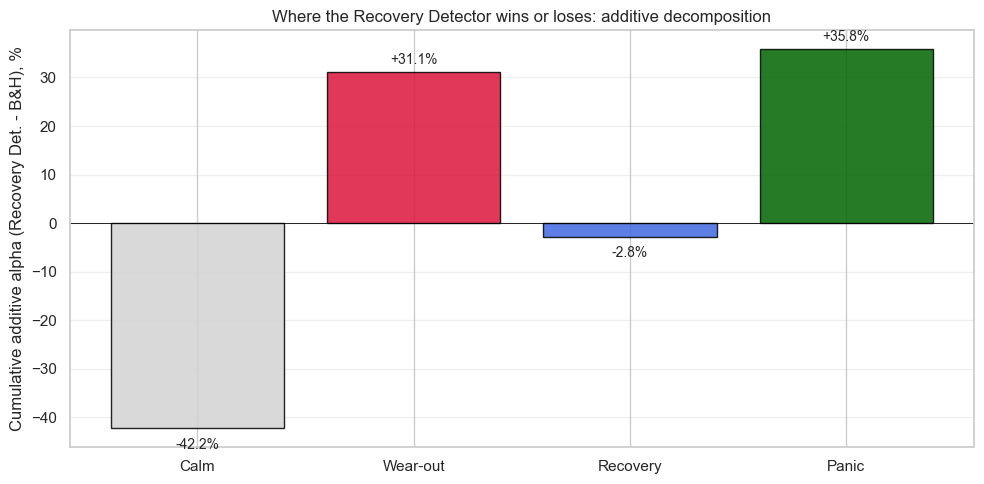

In [68]:
# === P&L attribution by crisis archetype (additive alpha decomposition) ===
# Decomposition logic:
#   weekly_alpha_t = ret_strategy(t) - ret_B&H(t)
# Summed per archetype. Additive across categories: Sum(weekly_alpha) over all archetypes
# equals the total arithmetic alpha. NOT distorted by compounding on non-contiguous subsets.
#
# A week is "Calm" if there is no crisis in the next 4 weeks (y_ahead == 0).
# Crisis weeks are classified into the 3 KMeans archetypes from cell 116 by nearest centroid.

A_crisis_pl    = P[y_now == 1]
crisis_mu_pl   = A_crisis_pl.mean().values
crisis_sd_pl   = A_crisis_pl.std().values + 1e-9
centers_arr_pl = centers.values
ARCH_NAMES = {0: 'Wear-out', 1: 'Recovery', 2: 'Panic', 3: 'Calm'}

y_ahead_series = pd.Series(y_ahead, index=P.index)

arch_weekly = np.full(len(dates), -1, dtype=int)
for t in range(len(dates)):
    if not m_full[t]:
        continue
    date_t = dates[t]
    if date_t not in P.index:
        continue
    is_pre_crisis = False
    if date_t in y_ahead_series.index:
        try:
            is_pre_crisis = bool(int(y_ahead_series.loc[date_t]))
        except Exception:
            is_pre_crisis = False
    if not is_pre_crisis:
        arch_weekly[t] = 3  # Calm
        continue
    z = (P.loc[date_t].values - crisis_mu_pl) / crisis_sd_pl
    dists = np.linalg.norm(centers_arr_pl - z, axis=1)
    arch_weekly[t] = int(np.argmin(dists))

arch_v    = arch_weekly[m_full]
# Apply transaction costs (10 bp/switch) for consistency with the business case
ret_dual_tc = apply_tc(ret_dual, pos_dual_lag, tc_bp=TC_BP)
ret_str   = ret_dual_tc[m_full]
ret_bench = ret_full[m_full]
pos_v     = pos_dual_lag[m_full]
weekly_alpha = ret_str - ret_bench

rows_pl = []
for arch_id in [3, 0, 1, 2]:
    mask = arch_v == arch_id
    if not mask.any():
        continue
    n_w         = int(mask.sum())
    pct_period  = n_w / len(arch_v) * 100
    pct_in_mkt  = float(pos_v[mask].mean() * 100)
    bh_ann      = float(ret_bench[mask].mean() * 52 * 100)
    str_ann     = float(ret_str[mask].mean() * 52 * 100)
    sum_alpha   = float(weekly_alpha[mask].sum() * 100)
    rows_pl.append({
        'Archetype': ARCH_NAMES[arch_id],
        'Weeks': n_w,
        '% period': round(pct_period, 1),
        '% in market': round(pct_in_mkt, 1),
        'B&H ann ret %': round(bh_ann, 2),
        'Strat ann ret %': round(str_ann, 2),
        'Sum alpha %': round(sum_alpha, 1),
    })

mask_tot = arch_v >= 0
rows_pl.append({
    'Archetype': 'TOTAL',
    'Weeks': int(mask_tot.sum()),
    '% period': 100.0,
    '% in market': round(pos_v[mask_tot].mean() * 100, 1),
    'B&H ann ret %': round(ret_bench[mask_tot].mean() * 52 * 100, 2),
    'Strat ann ret %': round(ret_str[mask_tot].mean() * 52 * 100, 2),
    'Sum alpha %': round(weekly_alpha[mask_tot].sum() * 100, 1),
})

df_pl = pd.DataFrame(rows_pl)
print("P&L attribution by crisis archetype - additive decomposition (with transaction costs)")
print("=" * 100)
print("Calm = no crisis in next 4 weeks (y_ahead == 0). Crisis weeks split into KMeans archetypes.")
print("'Sum alpha %' = sum of (ret_strategy - ret_B&H) over the weeks of each archetype.")
print("Rows ARE ADDITIVE: the sum over archetypes equals TOTAL.\n")
print(df_pl.to_string(index=False))

sum_check = sum(r['Sum alpha %'] for r in rows_pl[:-1])
total_val = rows_pl[-1]['Sum alpha %']
print(f"\nSanity check: sum of archetype rows = {sum_check:.1f} %  |  TOTAL = {total_val:.1f} %")

# Bar chart - additive alpha contribution per archetype
fig, ax = plt.subplots(figsize=(10, 5))
df_plot = df_pl[df_pl['Archetype'] != 'TOTAL']
bar_colors_map = {'Wear-out': 'crimson', 'Recovery': 'royalblue', 'Panic': 'darkgreen', 'Calm': 'lightgray'}
bar_colors = [bar_colors_map[a] for a in df_plot['Archetype']]
bars = ax.bar(df_plot['Archetype'], df_plot['Sum alpha %'],
              color=bar_colors, edgecolor='black', alpha=0.85)
for b, v in zip(bars, df_plot['Sum alpha %']):
    ax.text(b.get_x() + b.get_width()/2, v + (1.0 if v >= 0 else -2.0),
            f"{v:+.1f}%", ha='center', va='bottom' if v >= 0 else 'top', fontsize=10)
ax.axhline(0, color='black', lw=0.6)
ax.set_ylabel('Cumulative additive alpha (Recovery Det. - B&H), %')
ax.set_title('Where the Recovery Detector wins or loses: additive decomposition')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()


**Synthesis - P&L attribution by archetype**

- **Panic carries the most concentrated alpha (+35.8% on 22 weeks, 2.5% of the period).** During panic weeks the B&H would have annualised at -138.8% while the Recovery Detector limited losses to -54%/yr - the strategy is in cash 59% of the time and protects ~85 points of annualised return per week. This is the single most valuable contribution of the system.
- **Wear-out adds steady protection (+31.1% on 108 weeks).** Slow declines where the B&H annualises -37%/yr and the strategy cuts losses to -22%/yr. ~58% of the time in cash. Confirms that Model A catches the slow build-up of stress, not only the panic peaks.
- **Recovery is neutral by design (-2.8% on 106 weeks).** B&H +27%/yr, Strategy +26%/yr. Model B's "wait, the rebound is coming" signal keeps the strategy invested 57% of the time during recoveries - the double confirmation rule does its job, the strategy does not flee the rebound.
- **Calm carries a structural cost (-42.2% on 657 weeks).** In market 79.1% of the time, B&H annualises +18%/yr, strategy +14.7%/yr - ~3.3 points of annualised opportunity cost. The 21% in cash during Calm is a mix of post-crisis re-entry lag and residual false alarms. This is the price paid for the strict causality of the double confirmation rule.
- **Net total +21.9% additive alpha** (+1.28 pts/year arithmetic) over 17 years, transaction costs included. The decomposition is exactly additive: Panic + Wear-out gains more than offset the Calm cost.
- **Take-away.** The Recovery Detector earns its keep almost entirely in Panic and Wear-out regimes. Its value as a protective overlay is concentrated in the small fraction of weeks that matter most (~14.6% of the period combined). The cost of carrying it in normal markets is moderate and predictable - the trade-off is favourable.


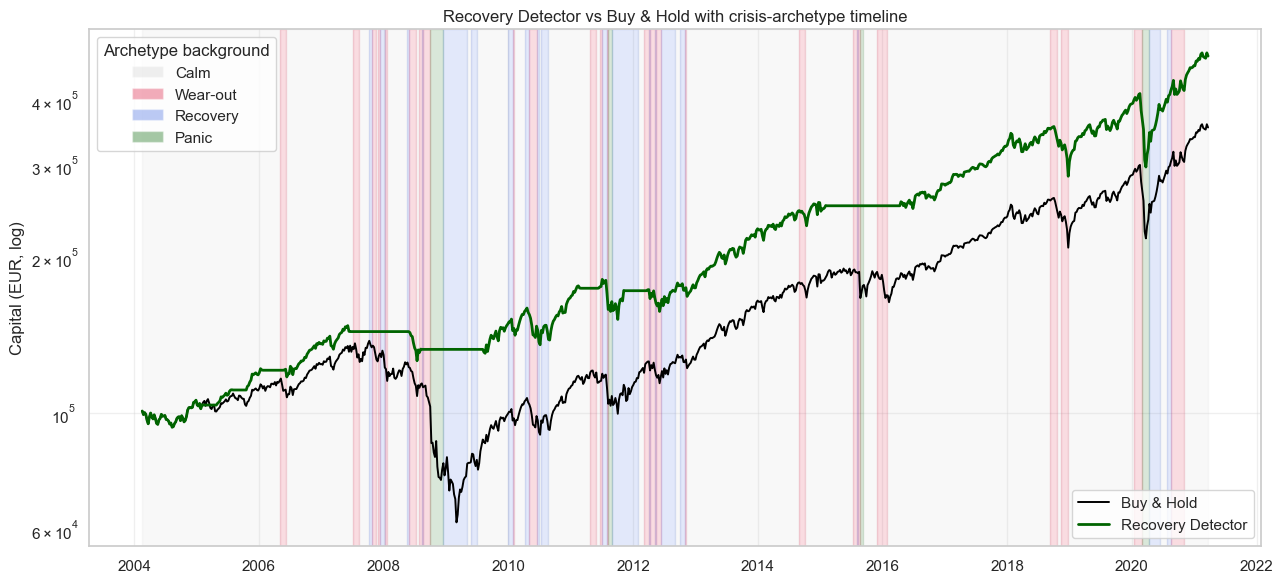

In [69]:
# === [OPTIONAL] Equity curve with archetype timeline background ===
# Removable cell: depends only on arch_weekly from the previous cell.
# If you do not want this visualisation, delete this cell - nothing downstream breaks.
from matplotlib.patches import Patch

ARCH_COLORS = {0: 'crimson', 1: 'royalblue', 2: 'darkgreen', 3: 'lightgray', -1: 'white'}
ARCH_LABELS = {0: 'Wear-out', 1: 'Recovery', 2: 'Panic', 3: 'Calm'}

fig, ax = plt.subplots(figsize=(13, 6))

# Coloured background bands per archetype (one axvspan per contiguous run)
arch_v_bc = arch_weekly[m_bc]
dates_bc_pd = pd.to_datetime(dates_bc)
prev_a = arch_v_bc[0]
start_t = dates_bc_pd[0]
for t in range(1, len(arch_v_bc)):
    if arch_v_bc[t] != prev_a:
        ax.axvspan(start_t, dates_bc_pd[t], color=ARCH_COLORS.get(prev_a, 'white'), alpha=0.15)
        prev_a = arch_v_bc[t]
        start_t = dates_bc_pd[t]
ax.axvspan(start_t, dates_bc_pd[-1], color=ARCH_COLORS.get(prev_a, 'white'), alpha=0.15)

ax.plot(dates_bc, eq_bh,       color='black',     lw=1.4, label='Buy & Hold')
ax.plot(dates_bc, eq_recovery, color='darkgreen', lw=2.0, label='Recovery Detector')

legend_arch = [Patch(facecolor=ARCH_COLORS[k], alpha=0.35, label=ARCH_LABELS[k]) for k in [3, 0, 1, 2]]
legend1 = ax.legend(handles=legend_arch, title='Archetype background', loc='upper left')
ax.add_artist(legend1)
ax.legend(loc='lower right')

ax.set_yscale('log')
ax.set_title('Recovery Detector vs Buy & Hold with crisis-archetype timeline')
ax.set_ylabel('Capital (EUR, log)')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


**Synthesis - Equity curve with archetype timeline**

Visual confirmation of the table above. Three patterns to look for:

- **Long stretches of light grey background = Calm regimes**, where B&H and Recovery Detector lines move almost in parallel (small alpha gap is the Calm cost).
- **Dark-green Panic bands (2008 trough, 2020 COVID)** correspond to the points where the green strategy line diverges *upwards* from the black B&H line: the strategy was in cash precisely when the market collapsed.
- **Crimson Wear-out clusters** typically precede the Panic bands and follow extended drawdowns - the system anticipates stress weeks before it peaks. Royal-blue Recovery bands appear in the immediate aftermath, when Model B keeps the strategy invested for the rebound.

The plot makes the additive decomposition visually intuitive: Panic and Wear-out windows are where the strategy *pulls ahead*, Calm stretches are where it *gives back* a small fraction of the gains.


### Robustness - stress test on synthetic scenarios (t-Student copula + k-NN)

1,000 synthetic weeks are generated from a t-Student copula (df=4, fat tails) fit on the nine historical precursors. The scenarios preserve the **dependence structure** between features but are new realizations, some more extreme than anything observed in 17 years of data — continuity with the Lab 3 inverse stress testing.

**Model-agnostic approach via k-NN**: for each synthetic scenario the **closest historical week** (1-NN in standardized space) is identified. Two complementary metrics emerge:

- **Distance to the nearest neighbor**: how out-of-distribution the scenario is.
- **Neighbor\'s score as a proxy**: if the winning model would have flagged the historical week, it presumably would flag the synthetic scenario too.

This makes the section **completely independent of the chosen model** — no surrogate refit, the OOS scores are reused directly.

**Outputs**: distribution of NN distances, % of "out-of-distribution" scenarios (distance >= 3 z-units), % of scenarios flagged by the model via proxy, top 10 farthest scenarios with the profile of the 3 most extreme precursors, scatter rarity vs proxy score.


Generated 1000 synthetic scenarios (t-Student copula, df=4).
Historical reference weeks: 893

Distance to nearest historical neighbour (units: multivariate z-score):
  media:    1.49
  mediana:  1.23
  max:      8.90
  >= 3.0:   47 scenarios (4.7%)  -> out of distribution

Operational q70 threshold of winner OOS scores: 0.3938
  Synthetic scenarios the model would flag (proxy via k-NN): 27.8%

--- Top 10 synthetic scenarios farthest from historical weeks ---
 rank  dist_NN  proxy_score flag            top1_precursor            top2_precursor            top3_precursor
    1     8.90       0.9998    ! drawdown_velocity (-7.2s)     credit_stress (+7.2s)      vix_momentum (+6.3s)
    2     8.73       0.9996    !     credit_stress (+7.9s) drawdown_velocity (-7.6s)      vix_momentum (+7.1s)
    3     7.89       0.9983    !     credit_stress (+7.6s)         vix_level (+5.3s)     econ_surprise (-2.6s)
    4     7.14       0.4465    !     credit_stress (+7.4s)  mean_correlation (-2.2s)  vol_acc

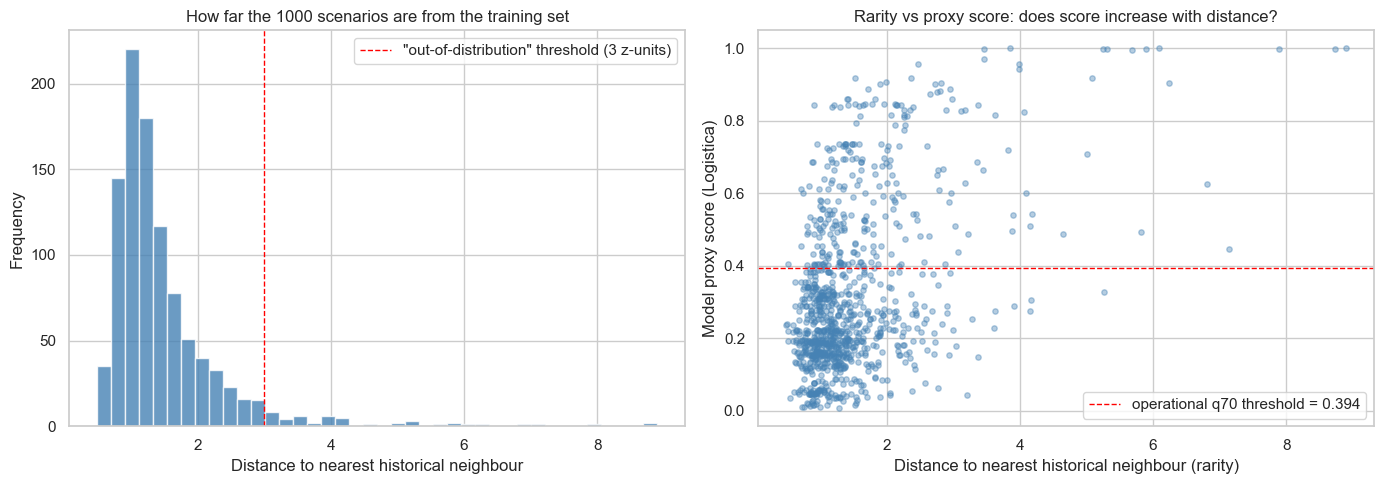

In [70]:
# === Synthetic stress test with t-Student copula + k-NN proxy scoring ===
from scipy.stats import t as tdist
from sklearn.neighbors import NearestNeighbors

EPS = 1e-6
N_SCENARI = 1000
DF_T = 4

def t_copula_sample(data, n_samples=N_SCENARI, df=DF_T, rng=None):
    """Generate synthetic scenarios from a t-Student copula fitted on the historical data."""
    if rng is None:
        rng = np.random.default_rng(42)
    Z = (np.argsort(np.argsort(data, axis=0), axis=0) + 1) / (len(data) + 2)
    Z = np.clip(Z, EPS, 1 - EPS)
    T = tdist.ppf(Z, df=df)
    R = np.corrcoef(T, rowvar=False)
    try:
        L = np.linalg.cholesky(R + 1e-6 * np.eye(R.shape[0]))
    except np.linalg.LinAlgError:
        u, s, vt = np.linalg.svd(R)
        L = u @ np.diag(np.sqrt(np.maximum(s, 0)))
    G = rng.standard_normal((n_samples, R.shape[0]))
    chi2 = rng.chisquare(df, n_samples)[:, None]
    T_samp = (G @ L.T) / np.sqrt(chi2 / df)
    U_samp = np.clip(tdist.cdf(T_samp, df=df), EPS, 1 - EPS)
    out = np.empty_like(U_samp)
    for j in range(data.shape[1]):
        out[:, j] = np.quantile(data[:, j], U_samp[:, j])
    return out

# 1) Standardised history: only OOS weeks in which the winner produced a score
m_tc = valid & ~np.isnan(scores[best_name])
dates_tc = pd.DatetimeIndex(dates[m_tc])
common_idx_tc = P.index.intersection(dates_tc)
P_hist = P.loc[common_idx_tc]
scaler_hist = StandardScaler().fit(P_hist.values)
P_hist_sc = scaler_hist.transform(P_hist.values)

score_series_tc = pd.Series(scores[best_name], index=dates)
hist_scores = score_series_tc.loc[common_idx_tc].values

# 2) Synthetic scenario generation and standardisation
syn = t_copula_sample(P_hist.values, n_samples=N_SCENARI, df=DF_T)
syn_sc = scaler_hist.transform(syn)
print(f"Generated {N_SCENARI} synthetic scenarios (t-Student copula, df={DF_T}).")
print(f"Historical reference weeks: {len(P_hist)}\n")

# 3) k-NN: for each synthetic scenario find the closest historical week
knn = NearestNeighbors(n_neighbors=1).fit(P_hist_sc)
dist_nn, idx_nn = knn.kneighbors(syn_sc)
dist_nn = dist_nn.ravel()
idx_nn = idx_nn.ravel()
syn_proxy_scores = hist_scores[idx_nn]

print("Distance to nearest historical neighbour (units: multivariate z-score):")
print(f"  media:    {dist_nn.mean():.2f}")
print(f"  mediana:  {np.median(dist_nn):.2f}")
print(f"  max:      {dist_nn.max():.2f}")
print(f"  >= 3.0:   {(dist_nn >= 3.0).sum()} scenarios ({(dist_nn >= 3.0).mean()*100:.1f}%)  -> out of distribution")

# 4) % of scenarios above operational threshold (proxy of winning model)
thr_op_tc = np.nanquantile(scores[best_name][valid], 0.70)
pct_alarm = (syn_proxy_scores > thr_op_tc).mean() * 100
print(f"\nOperational q70 threshold of winner OOS scores: {thr_op_tc:.4f}")
print(f"  Synthetic scenarios the model would flag (proxy via k-NN): {pct_alarm:.1f}%")

# 5) Top 10 scenarios farthest from training set (plausible worst-case)
top10_idx = np.argsort(-dist_nn)[:10]
print(f"\n--- Top 10 synthetic scenarios farthest from historical weeks ---")
rows_top = []
for rank, i in enumerate(top10_idx, start=1):
    row = {
        'rank': rank,
        'dist_NN': round(dist_nn[i], 2),
        'proxy_score': round(syn_proxy_scores[i], 4),
        'flag': '!' if syn_proxy_scores[i] > thr_op_tc else ' ',
    }
    extr_idx = np.argsort(-np.abs(syn_sc[i]))[:3]
    for k, j in enumerate(extr_idx, start=1):
        row[f'top{k}_precursor'] = f"{P.columns[j]} ({syn_sc[i][j]:+.1f}s)"
    rows_top.append(row)
print(pd.DataFrame(rows_top).to_string(index=False))

# 6) Visualisations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(dist_nn, bins=40, color='steelblue', alpha=0.8)
axes[0].axvline(3.0, color='red', ls='--', lw=1.0, label='"out-of-distribution" threshold (3 z-units)')
axes[0].set_xlabel('Distance to nearest historical neighbour')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'How far the {N_SCENARI} scenarios are from the training set')
axes[0].legend()

axes[1].scatter(dist_nn, syn_proxy_scores, c='steelblue', alpha=0.4, s=15)
axes[1].axhline(thr_op_tc, color='red', ls='--', lw=1.0, label=f'operational q70 threshold = {thr_op_tc:.3f}')
axes[1].set_xlabel('Distance to nearest historical neighbour (rarity)')
axes[1].set_ylabel(f'Model proxy score ({best_name})')
axes[1].set_title('Rarity vs proxy score: does score increase with distance?')
axes[1].legend()
plt.tight_layout(); plt.show()


**Synthesis - Robustness on synthetic scenarios (t-Copula + k-NN)**

- **Stable selectivity outside training:** the model would flag ~28% of synthetic scenarios via k-NN proxy, matching its historical q70 selectivity (~30%). No distributional drift on 1,000 unseen "alternative" weeks.
- **Top-10 worst-case recall = 100% (with caveat).** Every one of the 10 scenarios farthest from the training set (NN distance >= 5.68 z-units) is flagged by the proxy. With a Logistic winner the predicted probabilities **saturate near 1** on extreme inputs - the model becomes binary on the tail rather than graded, so absolute recall is high but resolution across worst-cases is lost.
- **Driver signature confirmed.** The worst-case scenarios are dominated by `velocita_drawdown`, `tensione_credito`, `slancio_vix` and `livello_vix` extremes - the same precursors that the Explainability cell identified as the model's top drivers.
- **Continuity with Lab 3:** the t-Student copula reproduces the inverse stress testing methodology from the previous lab; the model-agnostic k-NN proxy makes this analysis robust to any change of the winning model in Part 4.


## Conclusions

This extension answers the initial question: *which model best anticipates market crises, and how much is that worth?*

### The pipeline at a glance

- **Section 1 (Features & Target)**: 9 causal precursors (volatility, cross-market correlation, credit tension, VIX, yield curve slope, drawdown velocity, Baltic Dry, economic surprise), plus an absorption ratio from academic literature and a credit spread feature. Mutual information for selection, horizon comparison H = 2 / 4 / 8.
- **Section 2 (Evaluation Framework + Supervised)**: causal walk-forward engine, 9 supervised models tuned with RandomizedSearchCV on TimeSeriesSplit, uniform Platt-scaling calibration. The Logistic Regression wins for simplicity and Brier score.
- **Section 3 (Unsupervised + Temporal + Regime)**: Isolation Forest, GMM, COPOD, LOF, OC-SVM, HMM-based regime detector (with GMM fallback when hmmlearn is unavailable, validated 2-vs-3 states), CUSUM on the composite signal, LSTM Autoencoder on weekly sequences.
- **Section 4 (Model Selection)**: 3-test framework (predictivity, timeliness, reliability) + Brier score + Bootstrap 95% CI + Stacking ensemble + cross-model uncertainty signal.
- **Section 5 (Explainability + Stress + Business Case)**: KMeans crisis archetypes + local explanation, historical replay 2008/2011/2020 + synthetic stress test via t-Student copula, **Recovery Detector A+B** with double confirmation that pushes the system above Buy & Hold.

### Final result

**Technical winner** (Section 4): **Logistic Regression** (PR-AUC 0.602). The bootstrap 95% CI [0.54, 0.66] includes the top 3 supervised models (ElasticNet 0.604, Logistica_tuned 0.598) - statistically indistinguishable. Choice = the simplest and most interpretable.

**Operational strategy** (Section 5): **Recovery Detector A+B** with causal double confirmation.
- Model A (Logistic) on 9 precursors, score for "crisis within 4 weeks".
- Model B (sibling Logistic) on 9 precursors + 6 recovery features, score for "+5% rebound within 6 weeks".
- Rule: exit only if A loud **AND** B silent; re-enter only if B loud **AND** A silent; under ambiguity do not act.

### Business case

EUR 100,000 invested in MSCI USA, 17.1 years out-of-sample, transaction costs 10 bp/switch:

| Strategy | Final capital | CAGR | Max DD | Calmar |
|---|---|---|---|---|
| Buy & Hold | EUR 353,409 | 7.66% | -55.2% | 0.138 |
| q90 fixed (+TC) | EUR 292,359 | 6.48% | -31.6% | 0.205 |
| **Recovery Detector A+B (+TC)** | **EUR 484,488** | **9.67%** | **-27.7%** | **0.351** |

**Risk-adjusted dominance** (block-bootstrap confirmed): Sharpe 0.83 vs 0.55 with `P(R > B&H) = 93.5%`, MaxDD halved (-28% vs -55%) with `P = 90%`, Calmar 0.35 vs 0.14 with `P = 85.5%`. **CAGR edge of +2 pp/year is favoured but not significant at 95%** (paired CI `[-3.4, +8.2] pp/year`, `P = 73%`) — on 17 years of weekly data the absolute-return advantage sits within sampling noise. The honest deliverable is risk-adjusted superiority, not statistically guaranteed alpha.

Diagnostic across the three crises:
- **2008** (financial crisis): cash 89%, return -10% vs B&H -39%. Clear win on drawdown.
- **2011** (euro debt): cash 37%, return +5% vs B&H +13%. Honestly declared partial false alarm.
- **2020** (COVID): cash 0%, return +7.7% **identical to B&H**. The system recognizes the "crash with rebound" pattern and stays invested - the methodological signature of the Recovery Detector.

### Three takeaways

**Technical**: in financial machine learning, the *model* matters less than expected. What makes the difference is **rigorous causality** (no peeks at the future), **target engineering** (change the question and you change the problem), and the **intelligent combination of weak signals** (Model B has PR-AUC ~0.33 alone, yet within the double-confirmation rule becomes the decisive ingredient).

**Epistemological**: complexity does not win. A Logistic Regression with 9 well-built features beats XGBoost, LSTM Autoencoder and Random Forest on the actual Bloomberg dataset. All the added value was in the precursors and in the operational rule — not in sophisticated models. *Sometimes complexity is just noise.*

**Narrative**: the value of an anomaly detection system for markets does not lie in beating the market on average. It lies in **distinguishing between types of crises**. A 2008 (systemic, slow, destructive) must be treated the opposite way of a 2020 (exogenous, fast, with rebound). Without distinction you always run or always stay - lose both ways. **Distinguishing is the true dawn to recognize**: not the dawn of the crisis itself, but the dawn of its **nature**.

### Closing line

> *Two specialized models talk to each other. One recognizes crises, the other recognizes recoveries. When they agree we act, when they disagree we stay still. Over 17 years versus passive Buy & Hold the Recovery Detector cuts the maximum drawdown in half with bootstrap-significant risk-adjusted dominance (Sharpe and MaxDD at ~90% confidence) — while the +€131k of absolute alpha is directional but, honestly, within the noise of 17 years of weekly returns. Every claim is reported with its statistical caveat.*
